# Cross-House Non-Intrusive Load Monitoring — Final Reproduction Pipeline

**Student:** Pranav Panneerselvam  
**Student ID:** 250506804  
**Programme:** MSc Data Science  
**Module:** CSC8639 Dissertation  
**University:** Newcastle University  
**Dataset:** UK-DALE  

## Dissertation

**Evaluating Cross-House Generalisation in Non-Intrusive Load Monitoring Using UK-DALE**

## Notebook purpose

This notebook reproduces the complete experimental pipeline used in the dissertation.

The study develops NILM models using UK-DALE Houses 1 and 2 and evaluates the frozen final policy in two settings:

1. held-out temporal-test periods from Houses 1 and 2; and
2. external House 5 without target-house retraining or adaptation.

Five semantic appliance categories are modelled:

- kettle;
- cold appliance;
- dishwasher;
- laundry appliance; and
- microwave.

The workflow includes data preparation, chronological splitting, causal aggregate-mains feature engineering, baseline and candidate-model comparison, two-stage hurdle modelling, validation-selected post-processing, physical projection and final evaluation.

## Reproducibility and leakage-control principles

The following rules are maintained throughout the notebook:

- random seed = **42**;
- Houses **1 and 2** are the development households;
- source-house data are split chronologically into **60% training, 20% validation and 20% temporal test**;
- House **5** is used for external evaluation;
- predictive inputs are derived from aggregate mains and temporal information only;
- model and post-processing decisions are selected using source validation data;
- final temporal-test and House 5 targets are evaluated only after the final policy is frozen;
- rolling and lagged features use only information available at or before the prediction time.

House 5 had been explored during earlier project development. Therefore, it is treated here as **external evaluation data unseen to the frozen final selection procedure**, rather than as completely unseen throughout the entire research process.

## Execution

The notebook should be executed from a fresh Google Colab runtime from top to bottom.

The reproduction experiment writes to a separate output directory so that the completed development artefacts are not overwritten.

## 1. Reproducible Configuration

This section defines the fixed experimental configuration used throughout the reproduction.

A single random seed is used for reproducibility, the source households and chronological split proportions are fixed before model development, and a separate reproduction directory is used to prevent accidental modification of the original development artefacts.

The default project root is:

`/content/drive/MyDrive/dissertation`

If a different Google Drive location is used, it can be supplied through the `NILM_PROJECT_ROOT` environment variable.

In [1]:
# ============================================================
# Reproducible setup and frozen experiment definition
# ============================================================

from pathlib import Path
import pandas as pd
try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except ImportError:
    pass

import numpy as np
import matplotlib.pyplot as plt
import json
import hashlib
import random
import os
import gc
import warnings

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

SAMPLE_SECONDS = 10
MAX_SHORT_GAP_SECONDS = 60
MAX_SHORT_GAP_SAMPLES = MAX_SHORT_GAP_SECONDS // SAMPLE_SECONDS

SOURCE_HOUSES = [1, 2]
UNSEEN_TEST_HOUSE = 5

TRAIN_FRACTION = 0.60
VALIDATION_FRACTION = 0.20
SOURCE_TEST_FRACTION = 0.20

assert np.isclose(
    TRAIN_FRACTION + VALIDATION_FRACTION + SOURCE_TEST_FRACTION,
    1.0
)

# ------------------------------------------------------------
# Drive paths
# ------------------------------------------------------------

DISSERTATION_DIR = Path(
    os.environ.get(
        "NILM_PROJECT_ROOT",
        "/content/drive/MyDrive/dissertation",
    )
)
DATA_DIR = DISSERTATION_DIR / "data" / "ukdale"

EXPERIMENT_VERSION = "cross_house_transfer_reproduction_v1_2026_08"
OUTPUT_DIR = DISSERTATION_DIR / EXPERIMENT_VERSION

TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
PROCESSED_DIR = OUTPUT_DIR / "processed"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

for directory in [
    OUTPUT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    MODEL_DIR,
    PROCESSED_DIR,
    CHECKPOINT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"UK-DALE directory was not found: {DATA_DIR}"
    )

# ------------------------------------------------------------
# Fixed appliance ontology
# Exact aliases only: composite channels must not match.
# ------------------------------------------------------------

CATEGORY_ALIASES = {
    "kettle": {
        "kettle",
    },
    "cold_appliance": {
        "fridge",
        "fridge_freezer",
    },
    "dishwasher": {
        "dishwasher",
        "dish_washer",
    },
    "laundry_appliance": {
        "washing_machine",
        "washer_dryer",
    },
    "microwave": {
        "microwave",
    },
}

FIXED_CATEGORIES = list(CATEGORY_ALIASES.keys())

# Thresholds are frozen before House 5 prediction.
# They will be used only to derive event metrics.
CATEGORY_ON_THRESHOLDS_W = {
    "kettle": 2000.0,
    "cold_appliance": 50.0,
    "dishwasher": 1500.0,
    "laundry_appliance": 20.0,
    "microwave": 700.0,
}

MODEL_CANDIDATES = {
    "baseline": [
        "Always Off",
        "Training Mean Power",
        "Simple Mains Threshold",
    ],
    "classical_ml": [
        "Ridge Regression",
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Histogram Gradient Boosting",
    ],
    "deep_learning": [
        "MLP",
        "Causal Seq2Point CNN",
        "Unidirectional LSTM",
    ],
}

configuration_summary = pd.DataFrame(
    {
        "setting": [
            "Experiment",
            "Project root",
            "UK-DALE data",
            "Development houses",
            "External test house",
            "Sampling interval (s)",
            "Random seed",
        ],
        "value": [
            EXPERIMENT_VERSION,
            str(DISSERTATION_DIR),
            str(DATA_DIR),
            str(SOURCE_HOUSES),
            str(UNSEEN_TEST_HOUSE),
            SAMPLE_SECONDS,
            RANDOM_STATE,
        ],
    }
)

print("Reproduction configuration loaded successfully.")
display(configuration_summary)

print("\nChronological source split:")
print(f"  Training   : {TRAIN_FRACTION:.0%}")
print(f"  Validation : {VALIDATION_FRACTION:.0%}")
print(f"  Test       : {SOURCE_TEST_FRACTION:.0%}")

print(f"\nDevelopment houses : {SOURCE_HOUSES}")
print(f"External house      : House {UNSEEN_TEST_HOUSE}")
print(f"Random seed         : {RANDOM_STATE}")
print(f"Sampling interval   : {SAMPLE_SECONDS} seconds")

Reproduction configuration loaded successfully.


,setting,value
0,Experiment,cross_house_transfer_reproduction_v1_2026_08
1,Project root,/content/drive/MyDrive/dissertation
2,UK-DALE data,/content/drive/MyDrive/dissertation/data/ukdale
3,Development houses,"[1, 2]"
4,External test house,5
5,Sampling interval (s),10
6,Random seed,42



Chronological source split:
  Training   : 60%
  Validation : 20%
  Test       : 20%

Development houses : [1, 2]
External house      : House 5
Random seed         : 42
Sampling interval   : 10 seconds


## 2. Appliance Compatibility and Leakage-Control Protocol

Before any model training, the notebook verifies that the five fixed semantic appliance categories can be mapped consistently from the UK-DALE metadata.

The compatibility audit uses appliance labels only; appliance power values are not inspected at this stage.

The five categories are:

- kettle;
- cold appliance;
- dishwasher;
- laundry appliance; and
- microwave.

Exact label matching is used to avoid accidentally assigning composite or ambiguous channels to a category.

This section also freezes the chronological source-house boundaries before preprocessing and model selection. Houses 1 and 2 are divided into training, validation and held-out temporal-test periods, while House 5 is reserved for external evaluation.

In [2]:
# ============================================================
# Label-only appliance compatibility audit
# ============================================================

MAINS_LABELS = {
    "aggregate",
    "mains",
    "mains_1",
    "site_meter",
    "utility",
    "whole_house",
}


def normalise_label(label):
    return (
        str(label)
        .strip()
        .strip('"')
        .strip("'")
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


def read_house_labels(house_number):
    labels_path = (
        DATA_DIR
        / f"house_{house_number}"
        / "labels.dat"
    )

    if not labels_path.exists():
        raise FileNotFoundError(labels_path)

    labels = {}

    with open(labels_path, "r") as label_file:
        for line in label_file:
            parts = line.strip().split(maxsplit=1)

            if len(parts) != 2:
                continue

            channel = int(parts[0])
            raw_label = parts[1].strip()

            labels[channel] = {
                "raw_label": raw_label,
                "normalised_label": normalise_label(raw_label),
            }

    return labels


def identify_mains_channel(house_number, labels):
    labelled_mains = [
        channel
        for channel, information in labels.items()
        if information["normalised_label"] in MAINS_LABELS
    ]

    if len(labelled_mains) == 1:
        return int(labelled_mains[0]), "labels.dat"

    channel_1_path = (
        DATA_DIR
        / f"house_{house_number}"
        / "channel_1.dat"
    )

    if channel_1_path.exists():
        return 1, "validated UK-DALE channel-1 fallback"

    raise ValueError(
        f"Could not identify a mains channel for house_{house_number}"
    )


def resolve_fixed_category(labels, category):
    allowed_aliases = CATEGORY_ALIASES[category]

    matches = []

    for channel, information in labels.items():
        normalised = information["normalised_label"]

        # Exact match only. This prevents matching composite channels
        # such as washing_machine+microwave+breadmaker.
        if normalised in allowed_aliases:
            matches.append({
                "channel": int(channel),
                "raw_label": information["raw_label"],
                "normalised_label": normalised,
            })

    return matches


audit_rows = []
unmapped_rows = []
house_labels = {}
mains_channel_by_house = {}

for house_number in SOURCE_HOUSES + [UNSEEN_TEST_HOUSE]:
    role = (
        "source_development"
        if house_number in SOURCE_HOUSES
        else "unseen_final_test"
    )

    labels = read_house_labels(house_number)
    house_labels[house_number] = labels

    mains_channel, mains_source = identify_mains_channel(
        house_number,
        labels
    )
    mains_channel_by_house[house_number] = mains_channel

    matched_channels = {mains_channel}

    for category in FIXED_CATEGORIES:
        matches = resolve_fixed_category(labels, category)

        if len(matches) == 1:
            match = matches[0]
            status = "PASS"
            channel = match["channel"]
            raw_label = match["raw_label"]
            normalised_label = match["normalised_label"]
            matched_channels.add(channel)

        elif len(matches) == 0:
            status = (
                "FAIL_SOURCE_MISSING"
                if house_number in SOURCE_HOUSES
                else "ABSENT_OR_UNMETERED_IN_UNSEEN_HOUSE"
            )
            channel = np.nan
            raw_label = None
            normalised_label = None

        else:
            status = "FAIL_AMBIGUOUS"
            channel = np.nan
            raw_label = " | ".join(
                str(match["raw_label"]) for match in matches
            )
            normalised_label = " | ".join(
                str(match["normalised_label"]) for match in matches
            )

        audit_rows.append({
            "house": f"house_{house_number}",
            "house_number": house_number,
            "role": role,
            "category": category,
            "channel": channel,
            "raw_label": raw_label,
            "normalised_label": normalised_label,
            "status": status,
            "mains_channel": mains_channel,
            "mains_channel_source": mains_source,
        })

    for channel, information in sorted(labels.items()):
        if channel not in matched_channels:
            unmapped_rows.append({
                "house": f"house_{house_number}",
                "role": role,
                "channel": channel,
                "raw_label": information["raw_label"],
                "normalised_label": information["normalised_label"],
                "interpretation": "unmodelled/other category",
            })


category_channel_map_df = pd.DataFrame(audit_rows)
unmapped_label_df = pd.DataFrame(unmapped_rows)

category_channel_map_df.to_csv(
    TABLE_DIR / "fixed_category_channel_mapping.csv",
    index=False,
)

unmapped_label_df.to_csv(
    TABLE_DIR / "unmodelled_house_labels.csv",
    index=False,
)

# ------------------------------------------------------------
# Mandatory source-house gate
# ------------------------------------------------------------

source_mapping = category_channel_map_df[
    category_channel_map_df["house_number"].isin(SOURCE_HOUSES)
].copy()

source_failures = source_mapping[
    source_mapping["status"] != "PASS"
]

if not source_failures.empty:

    raise AssertionError(
        "SOURCE COMPATIBILITY GATE FAILED. "
        "At least one fixed category is missing or ambiguous in "
        "House 1 or House 2. Do not train models yet."
    )

duplicate_source_mappings = (
    source_mapping
    .groupby(["house_number", "channel"])
    .size()
    .reset_index(name="category_count")
)

duplicate_source_mappings = duplicate_source_mappings[
    duplicate_source_mappings["category_count"] > 1
]

if not duplicate_source_mappings.empty:

    raise AssertionError(
        "One source channel was assigned to multiple categories."
    )

# ------------------------------------------------------------
# Concise compatibility summary for the submitted notebook
# ------------------------------------------------------------

display_columns = [
    "house",
    "role",
    "category",
    "channel",
    "raw_label",
    "status",
]

print("Appliance compatibility audit completed successfully.")

display(
    category_channel_map_df
    .sort_values(["house_number", "category"])
    [display_columns]
    .reset_index(drop=True)
)

print(
    "\nSource compatibility gate:",
    "PASS" if source_failures.empty else "FAIL"
)

print(
    f"Mapped source categories: "
    f"{len(source_mapping[source_mapping['status'] == 'PASS'])}"
)

Appliance compatibility audit completed successfully.


,house,role,category,channel,raw_label,status
0,house_1,source_development,cold_appliance,12,fridge,PASS
1,house_1,source_development,dishwasher,6,dishwasher,PASS
2,house_1,source_development,kettle,10,kettle,PASS
3,house_1,source_development,laundry_appliance,5,washing_machine,PASS
4,house_1,source_development,microwave,13,microwave,PASS
5,house_2,source_development,cold_appliance,14,fridge,PASS
6,house_2,source_development,dishwasher,13,dish_washer,PASS
7,house_2,source_development,kettle,8,kettle,PASS
8,house_2,source_development,laundry_appliance,12,washing_machine,PASS
9,house_2,source_development,microwave,15,microwave,PASS



Source compatibility gate: PASS
Mapped source categories: 10


In [3]:
# ============================================================
# Freeze source temporal tests and House 5 boundary
# ============================================================

def audit_mains_time_range(house_number, chunksize=1_000_000):
    mains_channel = mains_channel_by_house[house_number]

    mains_path = (
        DATA_DIR
        / f"house_{house_number}"
        / f"channel_{mains_channel}.dat"
    )

    if not mains_path.exists():
        raise FileNotFoundError(mains_path)

    first_timestamp = None
    last_timestamp = None
    previous_timestamp = None
    total_rows = 0
    monotonic = True

    reader = pd.read_csv(
        mains_path,
        sep=r"\s+",
        header=None,
        names=["timestamp", "power_w"],
        usecols=[0],
        chunksize=chunksize,
    )

    for chunk in reader:
        timestamps = (
            pd.to_numeric(chunk["timestamp"], errors="coerce")
            .dropna()
            .astype("int64")
        )

        if timestamps.empty:
            continue

        if first_timestamp is None:
            first_timestamp = int(timestamps.iloc[0])

        if not timestamps.is_monotonic_increasing:
            monotonic = False

        current_first = int(timestamps.iloc[0])
        current_last = int(timestamps.iloc[-1])

        if (
            previous_timestamp is not None
            and current_first < previous_timestamp
        ):
            monotonic = False

        previous_timestamp = current_last
        last_timestamp = current_last
        total_rows += len(timestamps)

    if first_timestamp is None or last_timestamp is None:
        raise ValueError(
            f"No valid mains timestamps found for house_{house_number}"
        )

    return {
        "house": f"house_{house_number}",
        "house_number": house_number,
        "mains_channel": mains_channel,
        "raw_mains_rows": int(total_rows),
        "start_unix": int(first_timestamp),
        "end_unix": int(last_timestamp),
        "data_start": pd.to_datetime(first_timestamp, unit="s"),
        "data_end": pd.to_datetime(last_timestamp, unit="s"),
        "raw_timestamp_order_monotonic": bool(monotonic),
    }


range_rows = [
    audit_mains_time_range(house_number)
    for house_number in SOURCE_HOUSES + [UNSEEN_TEST_HOUSE]
]

mains_range_df = pd.DataFrame(range_rows)

boundary_rows = []

for _, row in mains_range_df.iterrows():
    house_number = int(row["house_number"])
    start_unix = int(row["start_unix"])
    end_unix = int(row["end_unix"])

    if end_unix <= start_unix:
        raise ValueError(
            f"Invalid time range for house_{house_number}"
        )

    duration_seconds = end_unix - start_unix

    if house_number in SOURCE_HOUSES:
        train_end_exclusive_unix = (
            start_unix
            + int(duration_seconds * TRAIN_FRACTION)
        )

        validation_end_exclusive_unix = (
            start_unix
            + int(
                duration_seconds
                * (TRAIN_FRACTION + VALIDATION_FRACTION)
            )
        )

        boundary_rows.append({
            "house": f"house_{house_number}",
            "house_number": house_number,
            "role": "source_development",
            "data_start": pd.to_datetime(start_unix, unit="s"),
            "train_end_exclusive": pd.to_datetime(
                train_end_exclusive_unix,
                unit="s",
            ),
            "validation_end_exclusive": pd.to_datetime(
                validation_end_exclusive_unix,
                unit="s",
            ),
            "data_end_inclusive": pd.to_datetime(
                end_unix,
                unit="s",
            ),
            "train_interval": (
                "[data_start, train_end_exclusive)"
            ),
            "validation_interval": (
                "[train_end_exclusive, "
                "validation_end_exclusive)"
            ),
            "test_interval": (
                "[validation_end_exclusive, "
                "data_end_inclusive]"
            ),
        })

    else:
        boundary_rows.append({
            "house": f"house_{house_number}",
            "house_number": house_number,
            "role": "unseen_final_test",
            "data_start": pd.to_datetime(start_unix, unit="s"),
            "train_end_exclusive": pd.NaT,
            "validation_end_exclusive": pd.NaT,
            "data_end_inclusive": pd.to_datetime(
                end_unix,
                unit="s",
            ),
            "train_interval": "NOT USED",
            "validation_interval": "NOT USED",
            "test_interval": (
                "[data_start, data_end_inclusive]"
            ),
        })


frozen_boundaries_df = pd.DataFrame(boundary_rows)

if not mains_range_df[
    "raw_timestamp_order_monotonic"
].all():

    raise AssertionError(
        "At least one raw mains timestamp sequence is not monotonic."
    )

for house_number in SOURCE_HOUSES:
    boundary = frozen_boundaries_df[
        frozen_boundaries_df["house_number"] == house_number
    ].iloc[0]

    assert (
        boundary["data_start"]
        < boundary["train_end_exclusive"]
        < boundary["validation_end_exclusive"]
        < boundary["data_end_inclusive"]
    )

frozen_boundaries_df.to_csv(
    TABLE_DIR / "frozen_experiment_boundaries.csv",
    index=False,
)

# ------------------------------------------------------------
# Freeze and fingerprint the experimental protocol
# ------------------------------------------------------------

protocol = {
    "experiment_version": EXPERIMENT_VERSION,
    "random_state": RANDOM_STATE,
    "sample_seconds": SAMPLE_SECONDS,
    "source_houses": SOURCE_HOUSES,
    "unseen_test_house": UNSEEN_TEST_HOUSE,
    "source_split": {
        "train_fraction": TRAIN_FRACTION,
        "validation_fraction": VALIDATION_FRACTION,
        "temporal_test_fraction": SOURCE_TEST_FRACTION,
    },
    "fixed_categories": FIXED_CATEGORIES,
    "category_aliases": {
        category: sorted(list(aliases))
        for category, aliases in CATEGORY_ALIASES.items()
    },
    "on_thresholds_w": CATEGORY_ON_THRESHOLDS_W,
    "candidate_models": MODEL_CANDIDATES,
    "boundaries": (
        frozen_boundaries_df
        .astype(str)
        .to_dict(orient="records")
    ),
    "house_5_rule": (
        "House 5 appliance power and performance must not be used "
        "for preprocessing fitting, threshold tuning, hyperparameter "
        "selection, model selection or early stopping."
    ),
}

protocol_text = json.dumps(
    protocol,
    indent=2,
    sort_keys=True,
)

protocol_hash = hashlib.sha256(
    protocol_text.encode("utf-8")
).hexdigest()

protocol["protocol_sha256_before_hash_field"] = protocol_hash

with open(
    CHECKPOINT_DIR / "frozen_experiment_protocol.json",
    "w",
) as protocol_file:
    json.dump(
        protocol,
        protocol_file,
        indent=2,
        sort_keys=True,
    )

print("Raw mains time ranges audited successfully.")

display(
    mains_range_df[
        [
            "house",
            "mains_channel",
            "raw_mains_rows",
            "data_start",
            "data_end",
            "raw_timestamp_order_monotonic",
        ]
    ]
)

Raw mains time ranges audited successfully.


,house,mains_channel,raw_mains_rows,data_start,data_end,raw_timestamp_order_monotonic
0,house_1,1,21837636,2012-11-09 22:28:15,2017-04-26 17:32:40,True
1,house_2,1,2780373,2013-02-17 16:17:34,2013-10-10 05:15:50,True
2,house_5,1,1763101,2014-06-29 16:23:48,2014-11-13 17:52:24,True


In [4]:
# ============================================================
# Align frozen boundaries to the 10-second grid
# ============================================================

def floor_to_sample_grid(timestamp, sample_seconds=10):
    unix_seconds = int(pd.Timestamp(timestamp).timestamp())
    aligned_unix = (
        unix_seconds // sample_seconds
    ) * sample_seconds

    return pd.to_datetime(aligned_unix, unit="s")


frozen_boundaries_df = frozen_boundaries_df.copy()

for index, row in frozen_boundaries_df.iterrows():
    if row["role"] != "source_development":
        continue

    frozen_boundaries_df.loc[
        index, "train_end_exclusive"
    ] = floor_to_sample_grid(
        row["train_end_exclusive"],
        SAMPLE_SECONDS,
    )

    frozen_boundaries_df.loc[
        index, "validation_end_exclusive"
    ] = floor_to_sample_grid(
        row["validation_end_exclusive"],
        SAMPLE_SECONDS,
    )


for house_number in SOURCE_HOUSES:
    boundary = frozen_boundaries_df[
        frozen_boundaries_df["house_number"] == house_number
    ].iloc[0]

    assert (
        boundary["data_start"]
        < boundary["train_end_exclusive"]
        < boundary["validation_end_exclusive"]
        < boundary["data_end_inclusive"]
    )

    assert (
        int(boundary["train_end_exclusive"].timestamp())
        % SAMPLE_SECONDS
        == 0
    )

    assert (
        int(boundary["validation_end_exclusive"].timestamp())
        % SAMPLE_SECONDS
        == 0
    )


frozen_boundaries_df.to_csv(
    TABLE_DIR / "frozen_experiment_boundaries.csv",
    index=False,
)

# Update and refingerprint the saved protocol.
protocol["boundaries"] = (
    frozen_boundaries_df
    .astype(str)
    .to_dict(orient="records")
)

protocol_without_hash = protocol.copy()
protocol_without_hash.pop(
    "protocol_sha256_before_hash_field",
    None,
)

protocol_text = json.dumps(
    protocol_without_hash,
    indent=2,
    sort_keys=True,
)

protocol_hash = hashlib.sha256(
    protocol_text.encode("utf-8")
).hexdigest()

protocol[
    "protocol_sha256_before_hash_field"
] = protocol_hash

with open(
    CHECKPOINT_DIR / "frozen_experiment_protocol.json",
    "w",
) as protocol_file:
    json.dump(
        protocol,
        protocol_file,
        indent=2,
        sort_keys=True,
    )

print("Chronological evaluation boundaries frozen successfully.")

display(
    frozen_boundaries_df[
        [
            "house",
            "role",
            "data_start",
            "train_end_exclusive",
            "validation_end_exclusive",
            "data_end_inclusive",
        ]
    ]
)

print(f"\nProtocol SHA-256: {protocol_hash}")

Chronological evaluation boundaries frozen successfully.


,house,role,data_start,train_end_exclusive,validation_end_exclusive,data_end_inclusive
0,house_1,source_development,2012-11-09 22:28:15,2015-07-15 05:06:50,2016-06-04 23:19:40,2017-04-26 17:32:40
1,house_2,source_development,2013-02-17 16:17:34,2013-07-08 09:40:30,2013-08-24 07:28:10,2013-10-10 05:15:50
2,house_5,unseen_final_test,2014-06-29 16:23:48,NaT,NaT,2014-11-13 17:52:24



Protocol SHA-256: 7baed04ef31453a04e6122ce80cad993f4a6d206a05ecadaf011fa167fb05df0


## 3. Source-House Preprocessing and Training-Only EDA

This section converts the raw UK-DALE measurements to the fixed 10-second sampling interval used throughout the study and constructs the chronological source-house datasets.

Preprocessing is performed independently within each split to prevent information from crossing training, validation and temporal-test boundaries.

The main preprocessing rules are:

- power is aggregated to 10-second intervals;
- negative power values are clipped to zero;
- short missing intervals are handled using past-only information;
- longer unresolved gaps are excluded;
- rolling and lagged information is reset across discontinuities; and
- exploratory analysis is performed using source-house training data only.

The held-out temporal-test periods are not used for exploratory analysis or model selection.

In [5]:
# ============================================================
# Resumable 10-second resampling of source channels
# ============================================================

import pyarrow.parquet as pq

INTERMEDIATE_DIR = OUTPUT_DIR / "intermediate_resampled_channels"
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

RAW_CHUNK_SIZE = 1_000_000
FORCE_REBUILD_RESAMPLED_CHANNELS = False


def get_resampled_channel_path(
    house_number,
    output_name,
):
    house_directory = (
        INTERMEDIATE_DIR
        / f"house_{house_number}"
    )
    house_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    return (
        house_directory
        / f"{output_name}_10s.parquet"
    )


def resample_raw_channel_to_parquet(
    house_number,
    channel_number,
    output_name,
    sample_seconds=10,
    chunksize=1_000_000,
    force_rebuild=False,
):
    raw_path = (
        DATA_DIR
        / f"house_{house_number}"
        / f"channel_{int(channel_number)}.dat"
    )

    output_path = get_resampled_channel_path(
        house_number,
        output_name,
    )

    if not raw_path.exists():
        raise FileNotFoundError(raw_path)

    if output_path.exists() and not force_rebuild:
        parquet_metadata = pq.ParquetFile(
            str(output_path)
        ).metadata


        return {
            "house": f"house_{house_number}",
            "house_number": house_number,
            "channel": int(channel_number),
            "output_name": output_name,
            "resampled_rows": int(
                parquet_metadata.num_rows
            ),
            "path": str(output_path),
            "status": "restored_existing",
        }


    partial_aggregates = []
    raw_rows_read = 0

    reader = pd.read_csv(
        raw_path,
        sep=r"\s+",
        header=None,
        names=["timestamp", "power_w"],
        usecols=[0, 1],
        chunksize=chunksize,
    )

    for chunk_number, chunk in enumerate(reader, start=1):
        chunk["timestamp"] = pd.to_numeric(
            chunk["timestamp"],
            errors="coerce",
        )
        chunk["power_w"] = pd.to_numeric(
            chunk["power_w"],
            errors="coerce",
        )

        chunk = chunk.dropna()

        if chunk.empty:
            continue

        chunk["timestamp"] = chunk[
            "timestamp"
        ].astype("int64")

        chunk["power_w"] = (
            chunk["power_w"]
            .astype("float64")
            .clip(lower=0)
        )

        raw_rows_read += len(chunk)

        chunk["timestamp_unix"] = (
            chunk["timestamp"]
            // sample_seconds
            * sample_seconds
        )

        partial = (
            chunk
            .groupby(
                "timestamp_unix",
                as_index=False,
            )["power_w"]
            .agg(["sum", "count"])
            .reset_index()
            .rename(
                columns={
                    "sum": "power_sum",
                    "count": "sample_count",
                }
            )
        )

        partial_aggregates.append(
            partial[
                [
                    "timestamp_unix",
                    "power_sum",
                    "sample_count",
                ]
            ]
        )

        if chunk_number % 5 == 0:
            pass  # Diagnostic-only branch.

        del chunk
        _ = gc.collect()
    if not partial_aggregates:
        raise ValueError(
            f"No valid samples found in {raw_path}"
        )

    aggregated = (
        pd.concat(
            partial_aggregates,
            ignore_index=True,
        )
        .groupby(
            "timestamp_unix",
            as_index=False,
        )[["power_sum", "sample_count"]]
        .sum()
        .sort_values("timestamp_unix")
        .reset_index(drop=True)
    )

    aggregated[output_name] = (
        aggregated["power_sum"]
        / aggregated["sample_count"]
    ).astype("float32")

    resampled = aggregated[
        ["timestamp_unix", output_name]
    ].copy()

    if not resampled[
        "timestamp_unix"
    ].is_monotonic_increasing:
        raise AssertionError(
            "Resampled timestamps are not monotonic."
        )

    if resampled[
        "timestamp_unix"
    ].duplicated().any():
        raise AssertionError(
            "Duplicate resampled timestamps remain."
        )

    temporary_path = output_path.with_suffix(
        ".temporary.parquet"
    )

    if temporary_path.exists():
        temporary_path.unlink()

    resampled.to_parquet(
        temporary_path,
        index=False,
        compression="zstd",
    )

    temporary_path.replace(output_path)

    result = {
        "house": f"house_{house_number}",
        "house_number": house_number,
        "channel": int(channel_number),
        "output_name": output_name,
        "raw_rows_read": int(raw_rows_read),
        "resampled_rows": int(len(resampled)),
        "start": pd.to_datetime(
            int(resampled["timestamp_unix"].min()),
            unit="s",
        ),
        "end": pd.to_datetime(
            int(resampled["timestamp_unix"].max()),
            unit="s",
        ),
        "path": str(output_path),
        "status": "created",
    }


    del partial_aggregates
    del aggregated
    del resampled
    _ = gc.collect()
    return result


# ------------------------------------------------------------
# Build the source-house resampling jobs
# ------------------------------------------------------------

resampling_jobs = []

for house_number in SOURCE_HOUSES:
    resampling_jobs.append({
        "house_number": house_number,
        "channel_number": (
            mains_channel_by_house[house_number]
        ),
        "output_name": "mains",
    })

    house_category_mapping = (
        category_channel_map_df[
            (
                category_channel_map_df[
                    "house_number"
                ] == house_number
            )
            & (
                category_channel_map_df[
                    "status"
                ] == "PASS"
            )
        ]
        .sort_values("category")
    )

    for _, mapping_row in (
        house_category_mapping.iterrows()
    ):
        resampling_jobs.append({
            "house_number": house_number,
            "channel_number": int(
                mapping_row["channel"]
            ),
            "output_name": (
                mapping_row["category"]
            ),
        })


resampling_manifest_rows = []

for job_number, job in enumerate(
    resampling_jobs,
    start=1,
):

    result = resample_raw_channel_to_parquet(
        house_number=job["house_number"],
        channel_number=job["channel_number"],
        output_name=job["output_name"],
        sample_seconds=SAMPLE_SECONDS,
        chunksize=RAW_CHUNK_SIZE,
        force_rebuild=(
            FORCE_REBUILD_RESAMPLED_CHANNELS
        ),
    )

    resampling_manifest_rows.append(result)

    pd.DataFrame(
        resampling_manifest_rows
    ).to_csv(
        TABLE_DIR
        / "source_resampled_channel_manifest.csv",
        index=False,
    )

gc.collect()

0

In [6]:
resampling_manifest_df = pd.DataFrame(
    resampling_manifest_rows
)


expected_jobs = (
    len(SOURCE_HOUSES)
    * (1 + len(FIXED_CATEGORIES))
)

assert len(resampling_manifest_df) == expected_jobs

assert all(
    Path(path).exists()
    for path in resampling_manifest_df["path"]
)
display(
    resampling_manifest_df[
        [
            "house",
            "channel",
            "output_name",
            "resampled_rows",
            "status",
        ]
    ]
)

print(
    f"\nCompleted resampling jobs: "
    f"{len(resampling_manifest_df)}/{expected_jobs}"
)

print(
    "Freshly created jobs:",
    (resampling_manifest_df["status"] == "created").sum()
)

print(
    "Restored existing jobs:",
    (resampling_manifest_df["status"] == "restored_existing").sum()
)

Source-channel resampling completed successfully.


,house,channel,output_name,resampled_rows,status
0,house_1,1,mains,13476158,created
1,house_1,12,cold_appliance,13377079,created
2,house_1,6,dishwasher,13629396,created
3,house_1,10,kettle,13071172,created
4,house_1,5,laundry_appliance,13474453,created
5,house_1,13,microwave,13394206,created
6,house_2,1,mains,1720568,created
7,house_2,14,cold_appliance,1036464,created
8,house_2,13,dishwasher,1036426,created
9,house_2,8,kettle,1287315,created



Completed resampling jobs: 12/12
Freshly created jobs: 12
Restored existing jobs: 0


In [7]:
# ============================================================
# Assemble causal source-house split datasets
# ============================================================

SOURCE_SPLIT_DIR = PROCESSED_DIR / "source_splits"
SOURCE_SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def timestamp_to_unix(timestamp):
    return int(pd.Timestamp(timestamp).timestamp())


def source_split_intervals(house_number):
    boundary = frozen_boundaries_df[
        frozen_boundaries_df[
            "house_number"
        ] == house_number
    ].iloc[0]

    data_start = timestamp_to_unix(
        boundary["data_start"]
    )
    train_end = timestamp_to_unix(
        boundary["train_end_exclusive"]
    )
    validation_end = timestamp_to_unix(
        boundary[
            "validation_end_exclusive"
        ]
    )
    data_end_exclusive = (
        timestamp_to_unix(
            boundary["data_end_inclusive"]
        )
        + 1
    )

    return {
        "train": (
            data_start,
            train_end,
        ),
        "validation": (
            train_end,
            validation_end,
        ),
        "test": (
            validation_end,
            data_end_exclusive,
        ),
    }


def load_resampled_interval(
    path,
    value_column,
    start_unix,
    end_exclusive_unix,
):
    frame = pd.read_parquet(
        path,
        filters=[
            (
                "timestamp_unix",
                ">=",
                int(start_unix),
            ),
            (
                "timestamp_unix",
                "<",
                int(end_exclusive_unix),
            ),
        ],
    )

    if frame.empty:
        raise ValueError(
            f"No rows in interval for {path}"
        )

    frame = (
        frame[
            ["timestamp_unix", value_column]
        ]
        .drop_duplicates(
            subset="timestamp_unix",
            keep="last",
        )
        .sort_values("timestamp_unix")
        .set_index("timestamp_unix")
    )

    return frame


def create_source_split(
    house_number,
    split_name,
    start_unix,
    end_exclusive_unix,
):
    output_path = (
        SOURCE_SPLIT_DIR
        / f"house_{house_number}_{split_name}.parquet"
    )

    audit_path = (
        SOURCE_SPLIT_DIR
        / f"house_{house_number}_{split_name}_audit.json"
    )

    if output_path.exists() and audit_path.exists():
        with open(audit_path, "r") as audit_file:
            restored_audit = json.load(audit_file)


        return restored_audit

    series_frames = []

    required_columns = [
        "mains",
        *FIXED_CATEGORIES,
    ]

    for column in required_columns:
        channel_path = get_resampled_channel_path(
            house_number,
            column,
        )

        frame = load_resampled_interval(
            channel_path,
            column,
            start_unix,
            end_exclusive_unix,
        )

        series_frames.append(frame)

    combined = pd.concat(
        series_frames,
        axis=1,
        join="outer",
    ).sort_index()

    # Build a complete regular 10-second index.
    first_complete_bin = (
        (int(start_unix) + SAMPLE_SECONDS - 1)
        // SAMPLE_SECONDS
        * SAMPLE_SECONDS
    )

    final_complete_bin = (
        (int(end_exclusive_unix) - 1)
        // SAMPLE_SECONDS
        * SAMPLE_SECONDS
    )

    regular_index = pd.RangeIndex(
        start=first_complete_bin,
        stop=final_complete_bin + SAMPLE_SECONDS,
        step=SAMPLE_SECONDS,
        name="timestamp_unix",
    )

    combined = combined.reindex(regular_index)

    missing_cells_before = int(
        combined.isna().sum().sum()
    )
    rows_missing_before = int(
        combined.isna().any(axis=1).sum()
    )

    # Past-only gap treatment.
    filled = combined.ffill(
        limit=MAX_SHORT_GAP_SAMPLES
    )

    unresolved_mask = filled.isna().any(axis=1)

    rows_removed_long_gaps = int(
        unresolved_mask.sum()
    )

    retained = (
        filled.loc[~unresolved_mask]
        .copy()
        .clip(lower=0)
        .astype("float32")
    )

    if retained.empty:
        raise ValueError(
            f"No complete rows remain for "
            f"house_{house_number}/{split_name}"
        )

    if retained.isna().any().any():
        raise AssertionError(
            "Missing values remain after preprocessing."
        )

    if not retained.index.is_monotonic_increasing:
        raise AssertionError(
            "Retained index is not monotonic."
        )

    if not retained.index.is_unique:
        raise AssertionError(
            "Retained index is not unique."
        )

    selected_sum = retained[
        FIXED_CATEGORIES
    ].sum(axis=1)

    excess = (
        selected_sum - retained["mains"]
    ).clip(lower=0)

    retained_to_save = (
        retained
        .reset_index()
    )

    temporary_path = output_path.with_suffix(
        ".temporary.parquet"
    )

    if temporary_path.exists():
        temporary_path.unlink()

    retained_to_save.to_parquet(
        temporary_path,
        index=False,
        compression="zstd",
    )

    temporary_path.replace(output_path)

    audit = {
        "house": f"house_{house_number}",
        "house_number": int(house_number),
        "split": split_name,
        "split_start_requested": str(
            pd.to_datetime(start_unix, unit="s")
        ),
        "split_end_exclusive_requested": str(
            pd.to_datetime(
                end_exclusive_unix,
                unit="s",
            )
        ),
        "rows_regular_grid": int(len(regular_index)),
        "missing_cells_before_short_fill": (
            missing_cells_before
        ),
        "rows_missing_before_short_fill": (
            rows_missing_before
        ),
        "short_gap_fill_limit_seconds": (
            MAX_SHORT_GAP_SECONDS
        ),
        "rows_removed_unresolved_long_gaps": (
            rows_removed_long_gaps
        ),
        "rows_retained": int(len(retained)),
        "retained_start": str(
            pd.to_datetime(
                int(retained.index.min()),
                unit="s",
            )
        ),
        "retained_end": str(
            pd.to_datetime(
                int(retained.index.max()),
                unit="s",
            )
        ),
        "remaining_missing_values": int(
            retained.isna().sum().sum()
        ),
        "index_unique": bool(
            retained.index.is_unique
        ),
        "index_monotonic": bool(
            retained.index.is_monotonic_increasing
        ),
        "selected_sum_exceeds_mains_rows": int(
            (excess > 0).sum()
        ),
        "selected_sum_excess_energy_kwh": float(
            excess.sum()
            * SAMPLE_SECONDS
            / 3_600_000
        ),
        "output_path": str(output_path),
    }

    with open(audit_path, "w") as audit_file:
        json.dump(
            audit,
            audit_file,
            indent=2,
        )


    del series_frames
    del combined
    del filled
    del retained
    del retained_to_save
    _ = gc.collect()
    return audit

In [14]:
split_audit_rows = []

for house_number in SOURCE_HOUSES:
    intervals = source_split_intervals(
        house_number
    )

    for split_name in [
        "train",
        "validation",
        "test",
    ]:
        start_unix, end_exclusive_unix = (
            intervals[split_name]
        )

        split_audit_rows.append(
            create_source_split(
                house_number=house_number,
                split_name=split_name,
                start_unix=start_unix,
                end_exclusive_unix=end_exclusive_unix,
            )
        )

        pd.DataFrame(
            split_audit_rows
        ).to_csv(
            TABLE_DIR
            / "source_split_preprocessing_audit.csv",
            index=False,
        )


source_split_audit_df = pd.DataFrame(
    split_audit_rows
)

# ------------------------------------------------------------
# Split non-overlap gate using retained boundaries
# ------------------------------------------------------------

for house_number in SOURCE_HOUSES:
    house_audit = (
        source_split_audit_df[
            source_split_audit_df[
                "house_number"
            ] == house_number
        ]
        .set_index("split")
    )

    train_end = pd.Timestamp(
        house_audit.loc[
            "train", "retained_end"
        ]
    )
    validation_start = pd.Timestamp(
        house_audit.loc[
            "validation", "retained_start"
        ]
    )
    validation_end = pd.Timestamp(
        house_audit.loc[
            "validation", "retained_end"
        ]
    )
    test_start = pd.Timestamp(
        house_audit.loc[
            "test", "retained_start"
        ]
    )

    assert train_end < validation_start
    assert validation_end < test_start

print("Chronological source-split preprocessing completed successfully.")

display(
    source_split_audit_df[
        [
            "house",
            "split",
            "rows_regular_grid",
            "rows_retained",
            "rows_removed_unresolved_long_gaps",
            "retained_start",
            "retained_end",
            "remaining_missing_values",
        ]
    ]
)

print(
    f"\nCompleted source splits: "
    f"{len(source_split_audit_df)}/6"
)

Chronological source-split preprocessing completed successfully.


,house,split,rows_regular_grid,rows_retained,rows_removed_unresolved_long_gaps,retained_start,retained_end,remaining_missing_values
0,house_1,train,8443671,7710566,733105,2012-12-14 22:21:30,2015-07-15 05:06:40,0
1,house_1,validation,2814557,2673575,140982,2015-07-15 05:06:50,2016-06-04 23:19:30,0
2,house_1,test,2814559,2683768,130791,2016-06-04 23:19:40,2017-04-26 17:32:40,0
3,house_2,train,1215857,418956,796901,2013-05-20 21:28:30,2013-07-08 09:40:20,0
4,house_2,validation,405286,247394,157892,2013-07-08 09:40:30,2013-08-24 07:28:00,0
5,house_2,test,405287,370150,35137,2013-08-24 07:28:10,2013-10-10 05:15:50,0



Completed source splits: 6/6


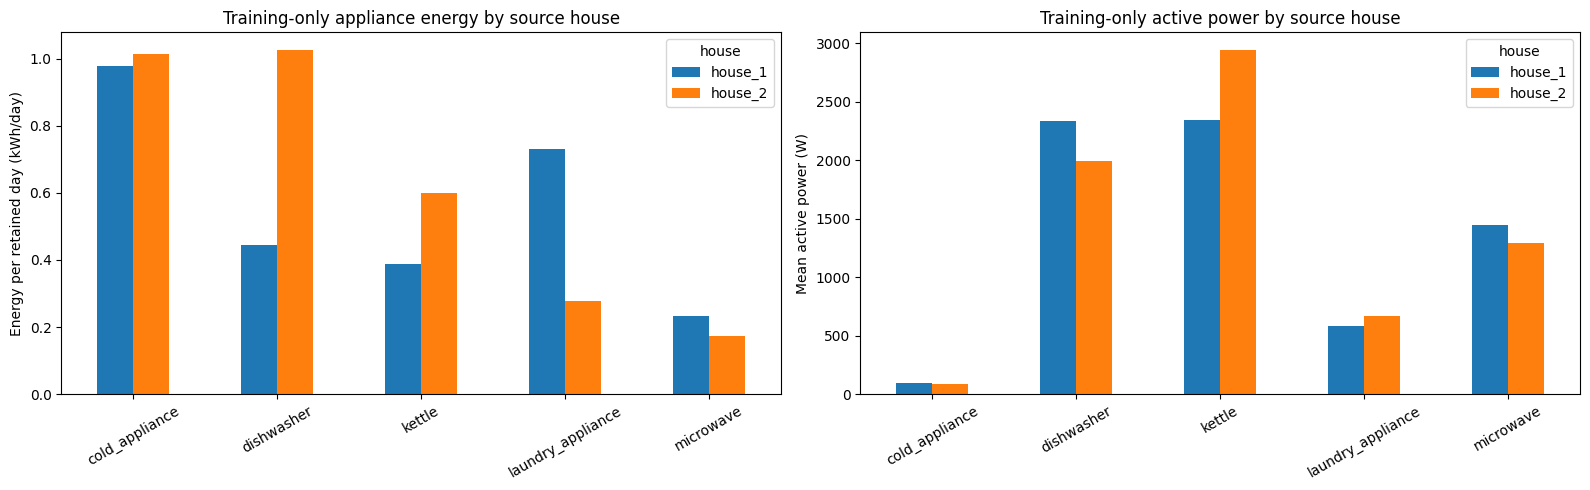


House-level training summary:


,house,split,retained_rows,retained_duration_days,mains_energy_kwh,selected_category_energy_kwh,selected_share_of_mains_pct
0,house_1,train_only,7710566,892.427,8170.231,2476.319,30.309
1,house_2,train_only,418956,48.490,338.221,149.872,44.312



Appliance-level training summary:


,house,category,threshold_w,energy_kwh_per_retained_day,on_percentage,activation_count,mean_active_power_w
0,house_1,kettle,2000.0,0.389,0.625,4277,2345.354
1,house_1,cold_appliance,50.0,0.977,42.868,24903,94.739
2,house_1,dishwasher,1500.0,0.445,0.680,922,2335.431
3,house_1,laundry_appliance,20.0,0.731,5.234,35467,580.629
4,house_1,microwave,700.0,0.233,0.590,7952,1446.851
5,house_2,kettle,2000.0,0.599,0.794,213,2947.508
6,house_2,cold_appliance,50.0,1.013,39.772,1685,89.894
7,house_2,dishwasher,1500.0,1.027,2.048,89,1995.391
8,house_2,laundry_appliance,20.0,0.277,1.287,324,671.753
9,house_2,microwave,700.0,0.175,0.522,234,1297.748


In [15]:
# ============================================================
# Training-only EDA for Houses 1 and 2
# ============================================================

def count_gap_safe_activations(
    timestamps_unix,
    power,
    threshold_w,
):
    active = (
        power.to_numpy(dtype=float)
        >= float(threshold_w)
    )

    timestamps = np.asarray(
        timestamps_unix,
        dtype=np.int64,
    )

    gap_start = np.ones(
        len(timestamps),
        dtype=bool,
    )

    if len(timestamps) > 1:
        gap_start[1:] = (
            np.diff(timestamps)
            != SAMPLE_SECONDS
        )

    previous_active = np.zeros(
        len(active),
        dtype=bool,
    )

    if len(active) > 1:
        previous_active[1:] = active[:-1]

    activation_starts = (
        active
        & (
            ~previous_active
            | gap_start
        )
    )

    return int(activation_starts.sum())

eda_rows = []
house_energy_rows = []
source_train_gate_rows = []

for house_number in SOURCE_HOUSES:
    train_path = (
        SOURCE_SPLIT_DIR
        / f"house_{house_number}_train.parquet"
    )

    train_df = pd.read_parquet(train_path)

    required_columns = [
        "timestamp_unix",
        "mains",
        *FIXED_CATEGORIES,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in train_df.columns
    ]

    if missing_columns:
        raise AssertionError(
            f"Missing columns in house_{house_number}: "
            f"{missing_columns}"
        )

    train_df = train_df.sort_values(
        "timestamp_unix"
    )

    duration_days = (
        len(train_df)
        * SAMPLE_SECONDS
        / 86_400
    )

    mains_energy_kwh = (
        train_df["mains"].sum()
        * SAMPLE_SECONDS
        / 3_600_000
    )

    selected_energy_kwh = (
        train_df[FIXED_CATEGORIES]
        .sum(axis=1)
        .sum()
        * SAMPLE_SECONDS
        / 3_600_000
    )

    house_energy_rows.append({
        "house": f"house_{house_number}",
        "split": "train_only",
        "retained_rows": int(len(train_df)),
        "retained_duration_days": float(
            duration_days
        ),
        "mains_energy_kwh": float(
            mains_energy_kwh
        ),
        "selected_category_energy_kwh": float(
            selected_energy_kwh
        ),
        "selected_share_of_mains_pct": float(
            selected_energy_kwh
            / mains_energy_kwh
            * 100
        ) if mains_energy_kwh > 0 else np.nan,
    })

    source_train_gate_rows.append({
        "house": f"house_{house_number}",
        "rows_positive": len(train_df) > 0,
        "all_values_finite": bool(
            np.isfinite(
                train_df[
                    ["mains", *FIXED_CATEGORIES]
                ].to_numpy()
            ).all()
        ),
        "no_missing_values": bool(
            not train_df[
                ["mains", *FIXED_CATEGORIES]
            ].isna().any().any()
        ),
        "index_unique": bool(
            train_df[
                "timestamp_unix"
            ].is_unique
        ),
        "index_monotonic": bool(
            train_df[
                "timestamp_unix"
            ].is_monotonic_increasing
        ),
    })

    for category in FIXED_CATEGORIES:
        power = train_df[category]
        threshold_w = (
            CATEGORY_ON_THRESHOLDS_W[
                category
            ]
        )

        active_power = power[
            power >= threshold_w
        ]

        energy_kwh = (
            power.sum()
            * SAMPLE_SECONDS
            / 3_600_000
        )

        activation_count = (
            count_gap_safe_activations(
                train_df["timestamp_unix"],
                power,
                threshold_w,
            )
        )

        eda_rows.append({
            "house": f"house_{house_number}",
            "split": "train_only",
            "category": category,
            "threshold_w": threshold_w,
            "retained_rows": int(
                len(train_df)
            ),
            "energy_kwh": float(
                energy_kwh
            ),
            "energy_kwh_per_retained_day": float(
                energy_kwh / duration_days
            ) if duration_days > 0 else np.nan,
            "on_percentage": float(
                (power >= threshold_w).mean()
                * 100
            ),
            "activation_count": int(
                activation_count
            ),
            "mean_power_w": float(
                power.mean()
            ),
            "mean_active_power_w": float(
                active_power.mean()
            ) if len(active_power) else 0.0,
            "median_active_power_w": float(
                active_power.median()
            ) if len(active_power) else 0.0,
            "p95_active_power_w": float(
                active_power.quantile(0.95)
            ) if len(active_power) else 0.0,
            "maximum_power_w": float(
                power.max()
            ),
        })

    del train_df
    _ = gc.collect()
source_train_eda_df = pd.DataFrame(
    eda_rows
)

source_train_house_energy_df = pd.DataFrame(
    house_energy_rows
)

source_train_gate_df = pd.DataFrame(
    source_train_gate_rows
)

source_train_eda_df.to_csv(
    TABLE_DIR / "source_training_only_appliance_eda.csv",
    index=False,
)

source_train_house_energy_df.to_csv(
    TABLE_DIR / "source_training_only_house_energy.csv",
    index=False,
)

source_train_gate_df.to_csv(
    TABLE_DIR / "source_training_only_eda_gate.csv",
    index=False,
)

if not (
    source_train_gate_df[
        [
            "rows_positive",
            "all_values_finite",
            "no_missing_values",
            "index_unique",
            "index_monotonic",
        ]
    ].all().all()
):
    raise AssertionError(
        "SOURCE TRAINING EDA GATE FAILED."
    )

# ------------------------------------------------------------
# Cross-house source comparison
# ------------------------------------------------------------

energy_comparison = (
    source_train_eda_df
    .pivot(
        index="category",
        columns="house",
        values="energy_kwh_per_retained_day",
    )
)

active_power_comparison = (
    source_train_eda_df
    .pivot(
        index="category",
        columns="house",
        values="mean_active_power_w",
    )
)

# ------------------------------------------------------------
# Training-only EDA figures
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
)

energy_comparison.plot(
    kind="bar",
    ax=axes[0],
)

axes[0].set_title(
    "Training-only appliance energy by source house"
)
axes[0].set_ylabel(
    "Energy per retained day (kWh/day)"
)

axes[0].set_xlabel("")
axes[0].tick_params(
    axis="x",
    rotation=30,
)

active_power_comparison.plot(
    kind="bar",
    ax=axes[1],
)

axes[1].set_title(
    "Training-only active power by source house"
)
axes[1].set_ylabel(
    "Mean active power (W)"
)
axes[1].set_xlabel("")
axes[1].tick_params(
    axis="x",
    rotation=30,
)

plt.tight_layout()

eda_figure_path = (
    FIGURE_DIR
    / "source_training_only_cross_house_eda.png"
)

plt.savefig(
    eda_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("\nHouse-level training summary:")
display(
    source_train_house_energy_df.round(3)
)

print("\nAppliance-level training summary:")
display(
    source_train_eda_df[
        [
            "house",
            "category",
            "threshold_w",
            "energy_kwh_per_retained_day",
            "on_percentage",
            "activation_count",
            "mean_active_power_w",
        ]
    ].round(3)
)

### 3.1 Category-Specific Pairwise Dataset Construction

A separate mains-target dataset is created for each appliance category.

This prevents missing measurements from an unrelated appliance from removing otherwise valid observations for another appliance. Each dataset therefore requires only:

- aggregate mains; and
- the corresponding appliance target.

Short-gap treatment is applied independently to each mains-target pair, and all chronological split boundaries remain unchanged.

This pairwise strategy is used for the final modelling pipeline.

In [10]:
# ============================================================
# Category-specific causal source datasets
# ============================================================

SOURCE_CATEGORY_SPLIT_DIR = (
    PROCESSED_DIR / "source_category_splits"
)

SOURCE_CATEGORY_SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FORCE_REBUILD_CATEGORY_SPLITS = False


def get_category_split_path(
    house_number,
    category,
    split_name,
):
    return (
        SOURCE_CATEGORY_SPLIT_DIR
        / (
            f"house_{house_number}_"
            f"{category}_{split_name}.parquet"
        )
    )


def get_category_split_audit_path(
    house_number,
    category,
    split_name,
):
    return (
        SOURCE_CATEGORY_SPLIT_DIR
        / (
            f"house_{house_number}_"
            f"{category}_{split_name}_audit.json"
        )
    )


def create_category_datasets_for_house_split(
    house_number,
    split_name,
    start_unix,
    end_exclusive_unix,
    force_rebuild=False,
):
    """
    Build one independent mains-target dataset per category.

    Mains is loaded once for the house/split.
    Each category is then aligned only with mains.
    """


    first_complete_bin = (
        (
            int(start_unix)
            + SAMPLE_SECONDS
            - 1
        )
        // SAMPLE_SECONDS
        * SAMPLE_SECONDS
    )

    final_complete_bin = (
        (
            int(end_exclusive_unix)
            - 1
        )
        // SAMPLE_SECONDS
        * SAMPLE_SECONDS
    )

    regular_index = pd.RangeIndex(
        start=first_complete_bin,
        stop=(
            final_complete_bin
            + SAMPLE_SECONDS
        ),
        step=SAMPLE_SECONDS,
        name="timestamp_unix",
    )

    mains_path = get_resampled_channel_path(
        house_number,
        "mains",
    )

    mains_frame = load_resampled_interval(
        mains_path,
        "mains",
        start_unix,
        end_exclusive_unix,
    )

    mains_regular = mains_frame.reindex(
        regular_index
    )

    house_split_audits = []

    for category in FIXED_CATEGORIES:
        output_path = get_category_split_path(
            house_number,
            category,
            split_name,
        )

        audit_path = (
            get_category_split_audit_path(
                house_number,
                category,
                split_name,
            )
        )

        if (
            output_path.exists()
            and audit_path.exists()
            and not force_rebuild
        ):
            with open(
                audit_path,
                "r",
            ) as audit_file:
                restored_audit = json.load(
                    audit_file
                )


            house_split_audits.append(
                restored_audit
            )
            continue

        target_path = get_resampled_channel_path(
            house_number,
            category,
        )

        target_frame = load_resampled_interval(
            target_path,
            category,
            start_unix,
            end_exclusive_unix,
        )

        target_regular = target_frame.reindex(
            regular_index
        )

        paired = pd.concat(
            [
                mains_regular,
                target_regular,
            ],
            axis=1,
        )

        paired = paired[
            ["mains", category]
        ]

        missing_cells_before = int(
            paired.isna().sum().sum()
        )

        rows_missing_before = int(
            paired.isna().any(axis=1).sum()
        )

        # Past-only short-gap treatment.
        filled = paired.ffill(
            limit=MAX_SHORT_GAP_SAMPLES
        )

        unresolved_mask = (
            filled.isna().any(axis=1)
        )

        rows_removed_long_gaps = int(
            unresolved_mask.sum()
        )

        retained = (
            filled.loc[~unresolved_mask]
            .copy()
            .clip(lower=0)
            .astype("float32")
        )

        if retained.empty:
            raise ValueError(
                f"No rows remain for "
                f"house_{house_number}/"
                f"{category}/{split_name}"
            )

        if retained.isna().any().any():
            raise AssertionError(
                "Missing values remain."
            )

        if not retained.index.is_unique:
            raise AssertionError(
                "Duplicate timestamps remain."
            )

        if not retained.index.is_monotonic_increasing:
            raise AssertionError(
                "Timestamps are not chronological."
            )

        retained_to_save = (
            retained.reset_index()
        )

        temporary_path = (
            output_path.with_suffix(
                ".temporary.parquet"
            )
        )

        if temporary_path.exists():
            temporary_path.unlink()

        retained_to_save.to_parquet(
            temporary_path,
            index=False,
            compression="zstd",
        )

        temporary_path.replace(output_path)

        audit = {
            "house": f"house_{house_number}",
            "house_number": int(
                house_number
            ),
            "category": category,
            "split": split_name,
            "strategy": (
                "category_specific_pairwise_"
                "mains_target_validity"
            ),
            "requested_start": str(
                pd.to_datetime(
                    start_unix,
                    unit="s",
                )
            ),
            "requested_end_exclusive": str(
                pd.to_datetime(
                    end_exclusive_unix,
                    unit="s",
                )
            ),
            "rows_regular_grid": int(
                len(regular_index)
            ),
            "missing_cells_before_short_fill": (
                missing_cells_before
            ),
            "rows_missing_before_short_fill": (
                rows_missing_before
            ),
            "short_gap_fill_limit_seconds": int(
                MAX_SHORT_GAP_SECONDS
            ),
            "rows_removed_unresolved_long_gaps": (
                rows_removed_long_gaps
            ),
            "rows_retained": int(
                len(retained)
            ),
            "retained_start": str(
                pd.to_datetime(
                    int(retained.index.min()),
                    unit="s",
                )
            ),
            "retained_end": str(
                pd.to_datetime(
                    int(retained.index.max()),
                    unit="s",
                )
            ),
            "remaining_missing_values": int(
                retained.isna().sum().sum()
            ),
            "index_unique": bool(
                retained.index.is_unique
            ),
            "index_monotonic": bool(
                retained.index.is_monotonic_increasing
            ),
            "output_path": str(output_path),
        }

        with open(
            audit_path,
            "w",
        ) as audit_file:
            json.dump(
                audit,
                audit_file,
                indent=2,
            )


        house_split_audits.append(audit)

        del target_frame
        del target_regular
        del paired
        del filled
        del retained
        del retained_to_save
        _ = gc.collect()
    del mains_frame
    del mains_regular
    _ = gc.collect()
    return house_split_audits

In [16]:
category_split_audit_rows = []

for house_number in SOURCE_HOUSES:
    intervals = source_split_intervals(
        house_number
    )

    for split_name in [
        "train",
        "validation",
        "test",
    ]:
        start_unix, end_exclusive_unix = (
            intervals[split_name]
        )

        split_audits = (
            create_category_datasets_for_house_split(
                house_number=house_number,
                split_name=split_name,
                start_unix=start_unix,
                end_exclusive_unix=(
                    end_exclusive_unix
                ),
                force_rebuild=(
                    FORCE_REBUILD_CATEGORY_SPLITS
                ),
            )
        )

        category_split_audit_rows.extend(
            split_audits
        )

        pd.DataFrame(
            category_split_audit_rows
        ).to_csv(
            TABLE_DIR
            / "source_category_split_audit.csv",
            index=False,
        )


category_split_audit_df = pd.DataFrame(
    category_split_audit_rows
)

# ------------------------------------------------------------
# Expected artifact count
# ------------------------------------------------------------

expected_category_datasets = (
    len(SOURCE_HOUSES)
    * len(FIXED_CATEGORIES)
    * 3
)

assert (
    len(category_split_audit_df)
    == expected_category_datasets
)

assert category_split_audit_df[
    "remaining_missing_values"
].eq(0).all()

assert category_split_audit_df[
    "index_unique"
].all()

assert category_split_audit_df[
    "index_monotonic"
].all()

# ------------------------------------------------------------
# Per-category split non-overlap gate
# ------------------------------------------------------------

for house_number in SOURCE_HOUSES:
    for category in FIXED_CATEGORIES:
        category_audit = (
            category_split_audit_df[
                (
                    category_split_audit_df[
                        "house_number"
                    ] == house_number
                )
                & (
                    category_split_audit_df[
                        "category"
                    ] == category
                )
            ]
            .set_index("split")
        )

        train_end = pd.Timestamp(
            category_audit.loc[
                "train",
                "retained_end",
            ]
        )

        validation_start = pd.Timestamp(
            category_audit.loc[
                "validation",
                "retained_start",
            ]
        )

        validation_end = pd.Timestamp(
            category_audit.loc[
                "validation",
                "retained_end",
            ]
        )

        test_start = pd.Timestamp(
            category_audit.loc[
                "test",
                "retained_start",
            ]
        )

        assert train_end < validation_start
        assert validation_end < test_start

# ------------------------------------------------------------
# Compare old common-intersection and new pairwise coverage
# ------------------------------------------------------------

old_training_rows = (
    source_split_audit_df[
        source_split_audit_df["split"]
        == "train"
    ][
        [
            "house_number",
            "rows_retained",
        ]
    ]
    .rename(
        columns={
            "rows_retained": (
                "old_all_category_"
                "intersection_rows"
            )
        }
    )
)

new_training_rows = (
    category_split_audit_df[
        category_split_audit_df["split"]
        == "train"
    ][
        [
            "house",
            "house_number",
            "category",
            "rows_retained",
        ]
    ]
    .rename(
        columns={
            "rows_retained": (
                "new_pairwise_rows"
            )
        }
    )
)

coverage_gain_df = new_training_rows.merge(
    old_training_rows,
    on="house_number",
    how="left",
)

coverage_gain_df["rows_recovered"] = (
    coverage_gain_df[
        "new_pairwise_rows"
    ]
    - coverage_gain_df[
        "old_all_category_intersection_rows"
    ]
)

coverage_gain_df[
    "coverage_gain_pct"
] = (
    coverage_gain_df["rows_recovered"]
    / coverage_gain_df[
        "old_all_category_intersection_rows"
    ].replace(0, np.nan)
    * 100
)

coverage_gain_df.to_csv(
    TABLE_DIR
    / "category_specific_training_coverage_gain.csv",
    index=False,
)

print("Category-specific pairwise datasets created successfully.")

print(
    f"\nCompleted category/split datasets: "
    f"{len(category_split_audit_df)}/30"
)

print("\nTraining-set pairwise coverage:")
display(
    coverage_gain_df[
        [
            "house",
            "category",
            "old_all_category_intersection_rows",
            "new_pairwise_rows",
            "rows_recovered",
            "coverage_gain_pct",
        ]
    ].round(2)
)

Category-specific pairwise datasets created successfully.

Completed category/split datasets: 30/30

Training-set pairwise coverage:


,house,category,old_all_category_intersection_rows,new_pairwise_rows,rows_recovered,coverage_gain_pct
0,house_1,kettle,7710566,7849880,139314,1.81
1,house_1,cold_appliance,7710566,7875154,164588,2.13
2,house_1,dishwasher,7710566,8055617,345051,4.48
3,house_1,laundry_appliance,7710566,7978586,268020,3.48
4,house_1,microwave,7710566,7881605,171039,2.22
5,house_2,kettle,418956,669876,250920,59.89
6,house_2,cold_appliance,418956,419062,106,0.03
7,house_2,dishwasher,418956,419062,106,0.03
8,house_2,laundry_appliance,418956,418960,4,0.00
9,house_2,microwave,418956,419058,102,0.02


In [17]:
# ============================================================
# Revised pairwise training-only EDA
# ============================================================

def count_pairwise_activations(
    timestamps_unix,
    power_values,
    threshold_w,
):
    timestamps = np.asarray(
        timestamps_unix,
        dtype=np.int64,
    )

    active = (
        np.asarray(
            power_values,
            dtype=float,
        )
        >= float(threshold_w)
    )

    gap_start = np.ones(
        len(timestamps),
        dtype=bool,
    )

    if len(timestamps) > 1:
        gap_start[1:] = (
            np.diff(timestamps)
            != SAMPLE_SECONDS
        )

    previous_active = np.zeros(
        len(active),
        dtype=bool,
    )

    if len(active) > 1:
        previous_active[1:] = active[:-1]

    starts = (
        active
        & (
            ~previous_active
            | gap_start
        )
    )

    return int(starts.sum())


pairwise_eda_rows = []
pairwise_training_gate_rows = []

for house_number in SOURCE_HOUSES:
    for category in FIXED_CATEGORIES:
        train_path = get_category_split_path(
            house_number,
            category,
            "train",
        )

        train_df = pd.read_parquet(
            train_path
        ).sort_values("timestamp_unix")

        required_columns = [
            "timestamp_unix",
            "mains",
            category,
        ]

        missing_columns = [
            column
            for column in required_columns
            if column not in train_df.columns
        ]

        if missing_columns:
            raise AssertionError(
                f"Missing columns in {train_path}: "
                f"{missing_columns}"
            )

        power = train_df[category]
        mains = train_df["mains"]

        threshold_w = (
            CATEGORY_ON_THRESHOLDS_W[
                category
            ]
        )

        active_mask = (
            power >= threshold_w
        )

        active_power = power[
            active_mask
        ]

        retained_days = (
            len(train_df)
            * SAMPLE_SECONDS
            / 86_400
        )

        appliance_energy_kwh = (
            power.sum()
            * SAMPLE_SECONDS
            / 3_600_000
        )

        mains_energy_kwh = (
            mains.sum()
            * SAMPLE_SECONDS
            / 3_600_000
        )

        activation_count = (
            count_pairwise_activations(
                train_df["timestamp_unix"],
                power,
                threshold_w,
            )
        )

        pairwise_eda_rows.append({
            "house": f"house_{house_number}",
            "house_number": house_number,
            "split": "train_only",
            "category": category,
            "threshold_w": threshold_w,
            "retained_rows": int(
                len(train_df)
            ),
            "retained_equivalent_days": float(
                retained_days
            ),
            "mains_energy_kwh": float(
                mains_energy_kwh
            ),
            "appliance_energy_kwh": float(
                appliance_energy_kwh
            ),
            "appliance_energy_kwh_per_day": float(
                appliance_energy_kwh
                / retained_days
            ) if retained_days > 0 else np.nan,
            "appliance_share_of_paired_mains_pct": float(
                appliance_energy_kwh
                / mains_energy_kwh
                * 100
            ) if mains_energy_kwh > 0 else np.nan,
            "on_percentage": float(
                active_mask.mean() * 100
            ),
            "activation_count": int(
                activation_count
            ),
            "mean_power_w": float(
                power.mean()
            ),
            "mean_active_power_w": float(
                active_power.mean()
            ) if len(active_power) else 0.0,
            "median_active_power_w": float(
                active_power.median()
            ) if len(active_power) else 0.0,
            "p95_active_power_w": float(
                active_power.quantile(0.95)
            ) if len(active_power) else 0.0,
            "maximum_power_w": float(
                power.max()
            ),
        })

        pairwise_training_gate_rows.append({
            "house": f"house_{house_number}",
            "category": category,
            "rows_positive": bool(
                len(train_df) > 0
            ),
            "all_values_finite": bool(
                np.isfinite(
                    train_df[
                        ["mains", category]
                    ].to_numpy()
                ).all()
            ),
            "no_missing_values": bool(
                not train_df[
                    ["mains", category]
                ].isna().any().any()
            ),
            "index_unique": bool(
                train_df[
                    "timestamp_unix"
                ].is_unique
            ),
            "index_monotonic": bool(
                train_df[
                    "timestamp_unix"
                ].is_monotonic_increasing
            ),
        })

        del train_df
        _ = gc.collect()
pairwise_training_eda_df = pd.DataFrame(
    pairwise_eda_rows
)

pairwise_training_gate_df = pd.DataFrame(
    pairwise_training_gate_rows
)

pairwise_training_eda_df.to_csv(
    TABLE_DIR
    / "pairwise_source_training_only_eda.csv",
    index=False,
)

pairwise_training_gate_df.to_csv(
    TABLE_DIR
    / "pairwise_source_training_gate.csv",
    index=False,
)

gate_columns = [
    "rows_positive",
    "all_values_finite",
    "no_missing_values",
    "index_unique",
    "index_monotonic",
]

if not pairwise_training_gate_df[
    gate_columns
].all().all():
    raise AssertionError(
        "PAIRWISE TRAINING GATE FAILED."
    )


# ------------------------------------------------------------
# Source-house comparison
# ------------------------------------------------------------

pairwise_energy_comparison = (
    pairwise_training_eda_df
    .pivot(
        index="category",
        columns="house",
        values=(
            "appliance_energy_kwh_per_day"
        ),
    )
)

pairwise_active_power_comparison = (
    pairwise_training_eda_df
    .pivot(
        index="category",
        columns="house",
        values="mean_active_power_w",
    )
)

pairwise_duration_comparison = (
    pairwise_training_eda_df
    .pivot(
        index="category",
        columns="house",
        values="retained_equivalent_days",
    )
)


display(
    pairwise_training_eda_df[
        [
            "house",
            "category",
            "retained_equivalent_days",
            "appliance_energy_kwh_per_day",
            "on_percentage",
            "activation_count",
            "mean_active_power_w",
        ]
    ].round(3)
)

,house,category,retained_equivalent_days,appliance_energy_kwh_per_day,on_percentage,activation_count,mean_active_power_w
0,house_1,kettle,908.551,0.384,0.617,4299,2345.295
1,house_1,cold_appliance,911.476,0.975,42.762,24063,94.722
2,house_1,dishwasher,932.363,0.443,0.676,920,2335.284
3,house_1,laundry_appliance,923.447,0.722,5.184,36096,578.807
4,house_1,microwave,912.223,0.229,0.580,7984,1446.790
5,house_2,kettle,77.532,0.765,1.025,427,2954.084
6,house_2,cold_appliance,48.503,1.013,39.775,1681,89.893
7,house_2,dishwasher,48.503,1.027,2.047,89,1995.391
8,house_2,laundry_appliance,48.491,0.277,1.287,324,671.753
9,house_2,microwave,48.502,0.175,0.522,234,1297.748


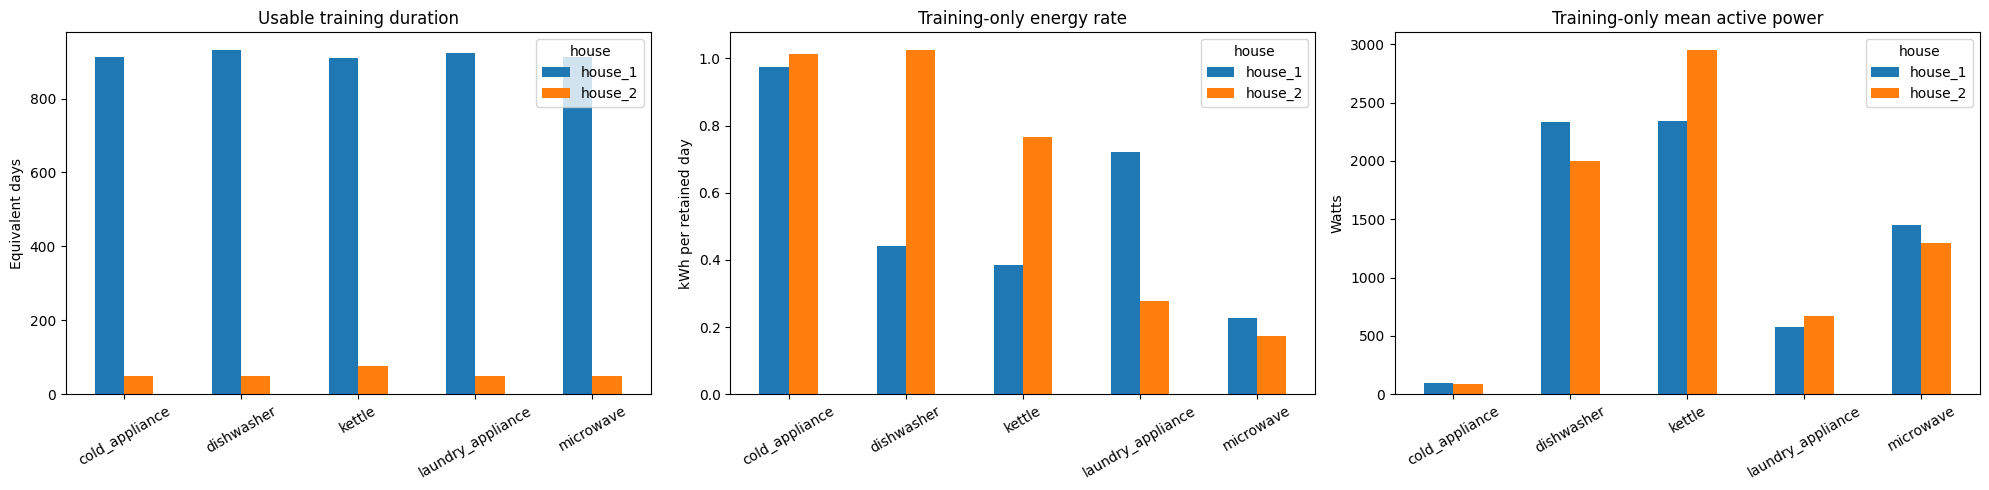

Section 3 data preparation and pairwise dataset construction completed successfully.


In [18]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5),
)

pairwise_duration_comparison.plot(
    kind="bar",
    ax=axes[0],
)

axes[0].set_title(
    "Usable training duration"
)
axes[0].set_ylabel("Equivalent days")
axes[0].set_xlabel("")
axes[0].tick_params(
    axis="x",
    rotation=30,
)

pairwise_energy_comparison.plot(
    kind="bar",
    ax=axes[1],
)

axes[1].set_title(
    "Training-only energy rate"
)
axes[1].set_ylabel("kWh per retained day")
axes[1].set_xlabel("")
axes[1].tick_params(
    axis="x",
    rotation=30,
)

pairwise_active_power_comparison.plot(
    kind="bar",
    ax=axes[2],
)

axes[2].set_title(
    "Training-only mean active power"
)
axes[2].set_ylabel("Watts")
axes[2].set_xlabel("")
axes[2].tick_params(
    axis="x",
    rotation=30,
)

plt.tight_layout()

pairwise_eda_figure_path = (
    FIGURE_DIR
    / "pairwise_source_training_only_eda.png"
)

plt.savefig(
    pairwise_eda_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Freeze the revised dataset strategy
# ------------------------------------------------------------

protocol["source_dataset_strategy"] = {
    "name": (
        "category_specific_pairwise_"
        "mains_target_validity"
    ),
    "reason": (
        "A separate NILM model is trained for every "
        "appliance category; missing unrelated appliance "
        "channels must not remove otherwise valid samples."
    ),
    "decision_stage": (
        "Before feature engineering, model training, "
        "validation inspection, temporal-test inspection "
        "and House 5 appliance loading."
    ),
}

protocol_without_hash = protocol.copy()
protocol_without_hash.pop(
    "protocol_sha256_before_hash_field",
    None,
)

protocol_text = json.dumps(
    protocol_without_hash,
    indent=2,
    sort_keys=True,
)

updated_protocol_hash = hashlib.sha256(
    protocol_text.encode("utf-8")
).hexdigest()

protocol[
    "protocol_sha256_before_hash_field"
] = updated_protocol_hash

with open(
    CHECKPOINT_DIR
    / "frozen_experiment_protocol.json",
    "w",
) as protocol_file:
    json.dump(
        protocol,
        protocol_file,
        indent=2,
        sort_keys=True,
    )
    print("Section 3 data preparation and pairwise dataset construction completed successfully.")

## 4. Causal Aggregate-Mains Feature Engineering

The final models use 24 features derived only from aggregate mains measurements and temporal information.

No appliance target values are used as predictive inputs.

The feature interface contains:

- current mains power and short-term change;
- trailing 1-, 5- and 10-minute statistics;
- lagged mains observations from 10 seconds to 10 minutes;
- hour, weekday and weekend indicators; and
- cyclical hour-of-day features.

All rolling windows are trailing rather than centred, and all lagged values refer only to observations already available at prediction time.

Feature construction is performed independently for each chronological split and is reset across unresolved gaps.

In [19]:
# ============================================================
# Causal mains-only feature engineering
# ============================================================

SOURCE_FEATURE_DIR = (
    PROCESSED_DIR / "source_mains_features"
)

SOURCE_FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FORCE_REBUILD_FEATURES = False

ROLLING_WINDOWS = {
    "1min": 6,
    "5min": 30,
    "10min": 60,
}

LAG_WINDOWS = {
    "10s": 1,
    "1min": 6,
    "5min": 30,
    "10min": 60,
}

def get_source_feature_path(
    house_number,
    split_name,
):
    return (
        SOURCE_FEATURE_DIR
        / (
            f"house_{house_number}_"
            f"{split_name}_mains_features.parquet"
        )
    )

def get_source_feature_audit_path(
    house_number,
    split_name,
):
    return (
        SOURCE_FEATURE_DIR
        / (
            f"house_{house_number}_"
            f"{split_name}_mains_features_audit.json"
        )
    )

def rolling_feature(
    grouped_mains,
    original_index,
    window,
    statistic,
):
    rolling_object = grouped_mains.rolling(
        window=window,
        min_periods=1,
    )

    if statistic == "mean":
        result = rolling_object.mean()

    elif statistic == "max":
        result = rolling_object.max()

    elif statistic == "min":
        result = rolling_object.min()

    elif statistic == "std":
        result = rolling_object.std(
            ddof=0
        )

    else:
        raise ValueError(
            f"Unknown statistic: {statistic}"
        )

    result = result.reset_index(
        level=0,
        drop=True,
    )

    return (
        result
        .reindex(original_index)
        .fillna(0)
        .astype("float32")
    )


def build_causal_mains_features(
    timestamp_index,
    mains_values,
):
    """
    Create gap-aware trailing features.

    Every gap larger than 10 seconds begins a new segment.
    Rolling and lag features never cross segment boundaries.
    """

    mains = pd.Series(
        np.asarray(
            mains_values,
            dtype=np.float32,
        ),
        index=pd.Index(
            timestamp_index,
            name="timestamp_unix",
        ),
        name="mains_w",
    )

    timestamp_differences = (
        mains.index
        .to_series()
        .diff()
    )

    segment_start = (
        timestamp_differences
        .ne(SAMPLE_SECONDS)
    )

    segment_start.iloc[0] = True

    segment_id = (
        segment_start
        .cumsum()
        .astype("int32")
    )

    grouped_mains = mains.groupby(
        segment_id,
        sort=False,
    )

    features = pd.DataFrame(
        index=mains.index
    )

    # Current aggregate power.
    features["mains_w"] = mains

    # Immediate changes.
    mains_difference = (
        grouped_mains
        .diff()
        .fillna(0)
        .astype("float32")
    )

    features[
        "mains_diff_10s"
    ] = mains_difference

    features[
        "mains_abs_diff_10s"
    ] = mains_difference.abs()

    # Trailing rolling statistics.
    for window_name, window_samples in (
        ROLLING_WINDOWS.items()
    ):
        for statistic in [
            "mean",
            "max",
            "min",
            "std",
        ]:
            feature_name = (
                f"mains_{statistic}_"
                f"{window_name}"
            )

            features[feature_name] = (
                rolling_feature(
                    grouped_mains=grouped_mains,
                    original_index=mains.index,
                    window=window_samples,
                    statistic=statistic,
                )
            )

    # Past-only lag features.
    first_value_in_segment = (
        grouped_mains
        .transform("first")
        .astype("float32")
    )

    for lag_name, lag_samples in (
        LAG_WINDOWS.items()
    ):
        lagged = grouped_mains.shift(
            lag_samples
        )

        # At the start of a segment, use that segment's
        # first already-observed mains value.
        lagged = lagged.fillna(
            first_value_in_segment
        )

        features[
            f"mains_lag_{lag_name}"
        ] = lagged.astype("float32")

    # Time features contain no absolute year/date identifier.
    datetime_index = pd.to_datetime(
        mains.index.to_numpy(),
        unit="s",
    )

    hour_decimal = (
        datetime_index.hour
        + datetime_index.minute / 60.0
        + datetime_index.second / 3600.0
    )

    day_of_week = datetime_index.dayofweek

    features["hour_of_day"] = (
        hour_decimal.astype("float32")
    )

    features["day_of_week"] = (
        day_of_week.astype("float32")
    )

    features["is_weekend"] = (
        (day_of_week >= 5)
        .astype("float32")
    )

    features["hour_sin"] = (
        np.sin(
            2
            * np.pi
            * hour_decimal
            / 24.0
        )
        .astype("float32")
    )

    features["hour_cos"] = (
        np.cos(
            2
            * np.pi
            * hour_decimal
            / 24.0
        )
        .astype("float32")
    )

    features = features.astype(
        "float32"
    )

    return features, segment_id

def create_source_feature_matrix(
    house_number,
    split_name,
    start_unix,
    end_exclusive_unix,
    force_rebuild=False,
):
    output_path = get_source_feature_path(
        house_number,
        split_name,
    )

    audit_path = (
        get_source_feature_audit_path(
            house_number,
            split_name,
        )
    )

    if (
        output_path.exists()
        and audit_path.exists()
        and not force_rebuild
    ):
        with open(
            audit_path,
            "r",
        ) as audit_file:
            restored_audit = json.load(
                audit_file
            )


        return restored_audit

    first_complete_bin = (
        (
            int(start_unix)
            + SAMPLE_SECONDS
            - 1
        )
        // SAMPLE_SECONDS
        * SAMPLE_SECONDS
    )

    final_complete_bin = (
        (
            int(end_exclusive_unix)
            - 1
        )
        // SAMPLE_SECONDS
        * SAMPLE_SECONDS
    )

    regular_index = pd.RangeIndex(
        start=first_complete_bin,
        stop=(
            final_complete_bin
            + SAMPLE_SECONDS
        ),
        step=SAMPLE_SECONDS,
        name="timestamp_unix",
    )

    mains_path = get_resampled_channel_path(
        house_number,
        "mains",
    )

    mains_frame = load_resampled_interval(
        mains_path,
        "mains",
        start_unix,
        end_exclusive_unix,
    )

    mains_regular = mains_frame.reindex(
        regular_index
    )

    mains_filled = mains_regular.ffill(
        limit=MAX_SHORT_GAP_SAMPLES
    )

    unresolved_mains_mask = (
        mains_filled["mains"].isna()
    )

    mains_retained = (
        mains_filled.loc[
            ~unresolved_mains_mask,
            "mains",
        ]
        .clip(lower=0)
        .astype("float32")
    )

    if mains_retained.empty:
        raise ValueError(
            f"No mains rows remain for "
            f"house_{house_number}/{split_name}"
        )

    features, segment_id = (
        build_causal_mains_features(
            timestamp_index=(
                mains_retained.index
            ),
            mains_values=(
                mains_retained.to_numpy()
            ),
        )
    )

    expected_feature_columns = [
        "mains_w",
        "mains_diff_10s",
        "mains_abs_diff_10s",

        "mains_mean_1min",
        "mains_max_1min",
        "mains_min_1min",
        "mains_std_1min",

        "mains_mean_5min",
        "mains_max_5min",
        "mains_min_5min",
        "mains_std_5min",

        "mains_mean_10min",
        "mains_max_10min",
        "mains_min_10min",
        "mains_std_10min",

        "mains_lag_10s",
        "mains_lag_1min",
        "mains_lag_5min",
        "mains_lag_10min",

        "hour_of_day",
        "day_of_week",
        "is_weekend",
        "hour_sin",
        "hour_cos",
    ]

    assert (
        list(features.columns)
        == expected_feature_columns
    )

    if features.isna().any().any():
        raise AssertionError(
            "Feature matrix contains missing values."
        )

    if not np.isfinite(
        features.to_numpy()
    ).all():
        raise AssertionError(
            "Feature matrix contains nonfinite values."
        )

    if not features.index.is_unique:
        raise AssertionError(
            "Feature timestamps are not unique."
        )

    if not features.index.is_monotonic_increasing:
        raise AssertionError(
            "Feature timestamps are not chronological."
        )

    feature_output = (
        features.reset_index()
    )

    temporary_path = output_path.with_suffix(
        ".temporary.parquet"
    )

    if temporary_path.exists():
        temporary_path.unlink()

    feature_output.to_parquet(
        temporary_path,
        index=False,
        compression="zstd",
    )

    temporary_path.replace(output_path)

    audit = {
        "house": f"house_{house_number}",
        "house_number": int(
            house_number
        ),
        "split": split_name,
        "feature_source": (
            "aggregate_mains_only"
        ),
        "causal": True,
        "gap_aware": True,
        "feature_rows": int(
            len(features)
        ),
        "feature_count": int(
            features.shape[1]
        ),
        "continuous_segments": int(
            segment_id.nunique()
        ),
        "regular_grid_rows": int(
            len(regular_index)
        ),
        "unresolved_mains_rows_removed": int(
            unresolved_mains_mask.sum()
        ),
        "remaining_missing_values": int(
            features.isna().sum().sum()
        ),
        "all_values_finite": bool(
            np.isfinite(
                features.to_numpy()
            ).all()
        ),
        "index_unique": bool(
            features.index.is_unique
        ),
        "index_monotonic": bool(
            features.index.is_monotonic_increasing
        ),
        "first_timestamp": str(
            pd.to_datetime(
                int(features.index.min()),
                unit="s",
            )
        ),
        "last_timestamp": str(
            pd.to_datetime(
                int(features.index.max()),
                unit="s",
            )
        ),
        "feature_columns": (
            expected_feature_columns
        ),
        "output_path": str(output_path),
    }

    with open(
        audit_path,
        "w",
    ) as audit_file:
        json.dump(
            audit,
            audit_file,
            indent=2,
        )

    del mains_frame
    del mains_regular
    del mains_filled
    del mains_retained
    del features
    del feature_output
    del segment_id
    _ = gc.collect()
    return audit

In [20]:
feature_audit_rows = []

for house_number in SOURCE_HOUSES:
    intervals = source_split_intervals(
        house_number
    )

    for split_name in [
        "train",
        "validation",
        "test",
    ]:
        start_unix, end_exclusive_unix = (
            intervals[split_name]
        )

        feature_audit_rows.append(
            create_source_feature_matrix(
                house_number=house_number,
                split_name=split_name,
                start_unix=start_unix,
                end_exclusive_unix=(
                    end_exclusive_unix
                ),
                force_rebuild=(
                    FORCE_REBUILD_FEATURES
                ),
            )
        )

        pd.DataFrame(
            feature_audit_rows
        ).to_csv(
            TABLE_DIR
            / "source_mains_feature_audit.csv",
            index=False,
        )

        _ = gc.collect()
source_feature_audit_df = pd.DataFrame(
    feature_audit_rows
)


assert len(source_feature_audit_df) == 6
assert source_feature_audit_df[
    "feature_count"
].eq(24).all()
assert source_feature_audit_df[
    "remaining_missing_values"
].eq(0).all()
assert source_feature_audit_df[
    "all_values_finite"
].all()
assert source_feature_audit_df[
    "index_unique"
].all()
assert source_feature_audit_df[
    "index_monotonic"
].all()

print("Causal feature matrices created successfully.")

display(
    source_feature_audit_df[
        [
            "house",
            "split",
            "feature_rows",
            "feature_count",
            "continuous_segments",
            "remaining_missing_values",
            "all_values_finite",
            "index_monotonic",
        ]
    ]
)

Causal feature matrices created successfully.


,house,split,feature_rows,feature_count,continuous_segments,remaining_missing_values,all_values_finite,index_monotonic
0,house_1,train,8059118,24,312,0,True,True
1,house_1,validation,2763194,24,3,0,True,True
2,house_1,test,2781345,24,5,0,True,True
3,house_2,train,1107875,24,23,0,True,True
4,house_2,validation,247405,24,7,0,True,True
5,house_2,test,370179,24,5,0,True,True


In [21]:
# ============================================================
# Feature-target timestamp alignment gate
# ============================================================

alignment_audit_rows = []

for house_number in SOURCE_HOUSES:
    for split_name in [
        "train",
        "validation",
        "test",
    ]:
        feature_path = get_source_feature_path(
            house_number,
            split_name,
        )

        feature_timestamps = (
            pd.read_parquet(
                feature_path,
                columns=["timestamp_unix"],
            )["timestamp_unix"]
            .astype("int64")
        )

        feature_index = pd.Index(
            feature_timestamps,
            name="timestamp_unix",
        )

        feature_columns = (
            pd.read_parquet(
                feature_path,
            )
            .columns
            .tolist()
        )

        forbidden_feature_columns = [
            column
            for column in feature_columns
            if (
                column in FIXED_CATEGORIES
                or column in [
                    "target",
                    "appliance",
                    "power_target",
                ]
            )
        ]

        if forbidden_feature_columns:
            raise AssertionError(
                "Target leakage columns found: "
                f"{forbidden_feature_columns}"
            )

        for category in FIXED_CATEGORIES:
            target_path = get_category_split_path(
                house_number,
                category,
                split_name,
            )

            target_timestamps = (
                pd.read_parquet(
                    target_path,
                    columns=["timestamp_unix"],
                )["timestamp_unix"]
                .astype("int64")
            )

            target_index = pd.Index(
                target_timestamps,
                name="timestamp_unix",
            )

            missing_from_features = (
                target_index.difference(
                    feature_index
                )
            )

            aligned_rows = int(
                len(target_index)
                - len(missing_from_features)
            )

            alignment_audit_rows.append({
                "house": f"house_{house_number}",
                "house_number": house_number,
                "category": category,
                "split": split_name,
                "feature_rows_available": int(
                    len(feature_index)
                ),
                "target_rows_available": int(
                    len(target_index)
                ),
                "aligned_model_rows": (
                    aligned_rows
                ),
                "target_timestamps_missing_from_features": int(
                    len(missing_from_features)
                ),
                "feature_columns": int(
                    len(feature_columns) - 1
                ),
                "features_contain_target": bool(
                    forbidden_feature_columns
                ),
            })

        del feature_timestamps
        del feature_index
        _ = gc.collect()
feature_target_alignment_df = pd.DataFrame(
    alignment_audit_rows
)

feature_target_alignment_df.to_csv(
    TABLE_DIR
    / "source_feature_target_alignment_audit.csv",
    index=False,
)


assert len(feature_target_alignment_df) == 30

assert feature_target_alignment_df[
    "target_timestamps_missing_from_features"
].eq(0).all()

assert feature_target_alignment_df[
    "features_contain_target"
].eq(False).all()

assert feature_target_alignment_df[
    "feature_columns"
].eq(24).all()

assert (
    feature_target_alignment_df[
        "aligned_model_rows"
    ]
    == feature_target_alignment_df[
        "target_rows_available"
    ]
).all()

print("Feature-target alignment verified.")

display(
    feature_target_alignment_df[
        [
            "house",
            "category",
            "split",
            "feature_rows_available",
            "target_rows_available",
            "aligned_model_rows",
            "target_timestamps_missing_from_features",
            "features_contain_target",
        ]
    ]
)

Feature-target alignment verified.


,house,category,split,feature_rows_available,target_rows_available,aligned_model_rows,target_timestamps_missing_from_features,features_contain_target
0,house_1,kettle,train,8059118,7849880,7849880,0,False
1,house_1,cold_appliance,train,8059118,7875154,7875154,0,False
2,house_1,dishwasher,train,8059118,8055617,8055617,0,False
3,house_1,laundry_appliance,train,8059118,7978586,7978586,0,False
4,house_1,microwave,train,8059118,7881605,7881605,0,False
5,house_1,kettle,validation,2763194,2678180,2678180,0,False
6,house_1,cold_appliance,validation,2763194,2762233,2762233,0,False
7,house_1,dishwasher,validation,2763194,2763077,2763077,0,False
8,house_1,laundry_appliance,validation,2763194,2761988,2761988,0,False
9,house_1,microwave,validation,2763194,2759706,2759706,0,False


## 5. House-Balanced Training Sample Construction

House 1 contains substantially more observations than House 2.

To prevent the longer household from dominating training, equal numbers of selected observations are drawn from Houses 1 and 2 for each appliance category.

The frozen training design uses:

- up to 100,000 active observations per house and category;
- a maximum OFF-to-ON ratio of 3:1;
- deterministic sampling across the chronological training period; and
- sample weights that restore natural within-house class prevalence while giving both houses equal total importance.

Validation and test datasets remain unbalanced and retain their natural distributions.

In [22]:
# ============================================================
# Freeze house-balanced training design
# ============================================================

TABULAR_TRAINING_SAMPLE_DIR = (
    PROCESSED_DIR / "tabular_training_samples"
)

TABULAR_TRAINING_SAMPLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MAX_ACTIVE_ROWS_PER_HOUSE = 100_000
MAX_OFF_TO_ON_RATIO = 3

# Frozen causal sequence windows for later CNN/LSTM training.
SEQUENCE_WINDOW_SAMPLES = {
    "kettle": 60,              # 10 minutes
    "cold_appliance": 120,     # 20 minutes
    "dishwasher": 360,         # 60 minutes
    "laundry_appliance": 360,  # 60 minutes
    "microwave": 60,           # 10 minutes
}

SEQUENCE_WINDOW_MINUTES = {
    category: (
        samples
        * SAMPLE_SECONDS
        / 60
    )
    for category, samples in (
        SEQUENCE_WINDOW_SAMPLES.items()
    )
}

In [23]:
# ============================================================
# Build balanced tabular training samples
# ============================================================

def deterministic_even_sample(
    ordered_indices,
    requested_count,
):
    """
    Select observations evenly across an ordered timeline.

    This avoids concentrating the sample in one short period.
    """
    ordered_indices = np.asarray(
        ordered_indices,
        dtype=np.int64,
    )

    available_count = len(
        ordered_indices
    )

    if requested_count >= available_count:
        return ordered_indices.copy()

    if requested_count <= 0:
        return np.array(
            [],
            dtype=np.int64,
        )

    positions = np.floor(
        np.arange(requested_count)
        * available_count
        / requested_count
    ).astype(np.int64)

    selected = ordered_indices[
        positions
    ]

    if len(np.unique(selected)) != len(selected):
        raise AssertionError(
            "Deterministic sampling created duplicates."
        )

    return selected

# ------------------------------------------------------------
# Get the fixed 24 feature names from Parquet metadata
# ------------------------------------------------------------

example_feature_path = (
    get_source_feature_path(
        SOURCE_HOUSES[0],
        "train",
    )
)

all_feature_file_columns = (
    pq.ParquetFile(
        str(example_feature_path)
    )
    .schema
    .names
)

TABULAR_FEATURE_COLUMNS = [
    column
    for column in all_feature_file_columns
    if column != "timestamp_unix"
]

assert len(TABULAR_FEATURE_COLUMNS) == 24

assert not any(
    category in TABULAR_FEATURE_COLUMNS
    for category in FIXED_CATEGORIES
)

# ------------------------------------------------------------
# Pass 1: measure source training populations
# ------------------------------------------------------------

population_rows = []
training_target_cache = {}

for category in FIXED_CATEGORIES:
    threshold_w = (
        CATEGORY_ON_THRESHOLDS_W[
            category
        ]
    )

    for house_number in SOURCE_HOUSES:
        target_path = get_category_split_path(
            house_number,
            category,
            "train",
        )

        target_df = (
            pd.read_parquet(
                target_path,
                columns=[
                    "timestamp_unix",
                    category,
                ],
            )
            .sort_values("timestamp_unix")
            .drop_duplicates(
                subset="timestamp_unix",
                keep="last",
            )
            .reset_index(drop=True)
        )

        target_df["is_on"] = (
            target_df[category]
            >= threshold_w
        )

        on_count = int(
            target_df["is_on"].sum()
        )

        off_count = int(
            (~target_df["is_on"]).sum()
        )

        if on_count == 0:
            raise AssertionError(
                f"No active training rows for "
                f"house_{house_number}/{category}"
            )

        if off_count == 0:
            raise AssertionError(
                f"No inactive training rows for "
                f"house_{house_number}/{category}"
            )

        population_rows.append({
            "house": f"house_{house_number}",
            "house_number": house_number,
            "category": category,
            "threshold_w": threshold_w,
            "population_rows": int(
                len(target_df)
            ),
            "population_on_rows": on_count,
            "population_off_rows": off_count,
            "population_on_percentage": float(
                on_count
                / len(target_df)
                * 100
            ),
        })

        training_target_cache[
            (house_number, category)
        ] = target_df


training_population_df = pd.DataFrame(
    population_rows
)

training_population_df.to_csv(
    TABLE_DIR
    / "source_training_population_by_house_category.csv",
    index=False,
)

# ------------------------------------------------------------
# Derive one common quota per category
# ------------------------------------------------------------

sampling_plan_rows = []

for category in FIXED_CATEGORIES:
    category_population = (
        training_population_df[
            training_population_df[
                "category"
            ] == category
        ]
    )

    common_active_rows = min(
        MAX_ACTIVE_ROWS_PER_HOUSE,
        int(
            category_population[
                "population_on_rows"
            ].min()
        ),
    )

    maximum_off_from_ratio = int(
        common_active_rows
        * MAX_OFF_TO_ON_RATIO
    )

    common_off_rows = min(
        maximum_off_from_ratio,
        int(
            category_population[
                "population_off_rows"
            ].min()
        ),
    )

    if common_active_rows <= 0:
        raise AssertionError(
            f"Invalid active quota for {category}"
        )

    if common_off_rows <= 0:
        raise AssertionError(
            f"Invalid inactive quota for {category}"
        )

    sampling_plan_rows.append({
        "category": category,
        "active_rows_per_house": (
            common_active_rows
        ),
        "off_rows_per_house": (
            common_off_rows
        ),
        "total_rows_per_house": (
            common_active_rows
            + common_off_rows
        ),
        "combined_source_rows": (
            2
            * (
                common_active_rows
                + common_off_rows
            )
        ),
        "sampled_on_percentage": (
            common_active_rows
            / (
                common_active_rows
                + common_off_rows
            )
            * 100
        ),
    })


training_sampling_plan_df = pd.DataFrame(
    sampling_plan_rows
)

training_sampling_plan_df.to_csv(
    TABLE_DIR
    / "frozen_training_sampling_plan.csv",
    index=False,
)

# ------------------------------------------------------------
# Select target timestamps before loading large feature files
# ------------------------------------------------------------

selected_target_tables = {}

for _, plan_row in (
    training_sampling_plan_df.iterrows()
):
    category = plan_row["category"]

    active_quota = int(
        plan_row[
            "active_rows_per_house"
        ]
    )

    off_quota = int(
        plan_row[
            "off_rows_per_house"
        ]
    )

    for house_number in SOURCE_HOUSES:
        target_df = training_target_cache[
            (house_number, category)
        ]

        on_timestamps = (
            target_df.loc[
                target_df["is_on"],
                "timestamp_unix",
            ]
            .to_numpy(dtype=np.int64)
        )

        off_timestamps = (
            target_df.loc[
                ~target_df["is_on"],
                "timestamp_unix",
            ]
            .to_numpy(dtype=np.int64)
        )

        selected_on = (
            deterministic_even_sample(
                on_timestamps,
                active_quota,
            )
        )

        selected_off = (
            deterministic_even_sample(
                off_timestamps,
                off_quota,
            )
        )

        selected_timestamps = np.concatenate(
            [
                selected_on,
                selected_off,
            ]
        )

        selected_class = np.concatenate(
            [
                np.ones(
                    len(selected_on),
                    dtype=np.int8,
                ),
                np.zeros(
                    len(selected_off),
                    dtype=np.int8,
                ),
            ]
        )

        selected_df = pd.DataFrame({
            "timestamp_unix": (
                selected_timestamps
            ),
            "is_on": selected_class,
        })

        target_lookup = (
            target_df
            .set_index("timestamp_unix")[
                category
            ]
        )

        selected_df["target_w"] = (
            selected_df[
                "timestamp_unix"
            ]
            .map(target_lookup)
            .astype("float32")
        )

        if selected_df[
            "target_w"
        ].isna().any():
            raise AssertionError(
                "Selected target lookup failed."
            )

        if selected_df[
            "timestamp_unix"
        ].duplicated().any():
            raise AssertionError(
                "Duplicate selected timestamps."
            )

        selected_target_tables[
            (house_number, category)
        ] = selected_df

In [24]:
del training_target_cache
_ = gc.collect()
# ------------------------------------------------------------
# Load each house's feature matrix once
# ------------------------------------------------------------

category_sample_parts = {
    category: []
    for category in FIXED_CATEGORIES
}

for house_number in SOURCE_HOUSES:

    feature_path = get_source_feature_path(
        house_number,
        "train",
    )

    feature_df = (
        pd.read_parquet(
            feature_path
        )
        .sort_values("timestamp_unix")
        .drop_duplicates(
            subset="timestamp_unix",
            keep="last",
        )
        .set_index("timestamp_unix")
    )

    for category in FIXED_CATEGORIES:
        selected_targets = (
            selected_target_tables[
                (house_number, category)
            ]
            .copy()
        )

        selected_timestamps = (
            selected_targets[
                "timestamp_unix"
            ].to_numpy(dtype=np.int64)
        )

        missing_features = pd.Index(
            selected_timestamps
        ).difference(
            feature_df.index
        )

        if len(missing_features) != 0:
            raise AssertionError(
                f"{len(missing_features)} feature "
                f"rows missing for "
                f"house_{house_number}/{category}"
            )

        selected_features = (
            feature_df.loc[
                selected_timestamps,
                TABULAR_FEATURE_COLUMNS,
            ]
            .copy()
            .reset_index()
        )

        selected_features[
            "house_number"
        ] = int(house_number)

        selected_features[
            "category"
        ] = category

        selected_features[
            "target_w"
        ] = selected_targets[
            "target_w"
        ].to_numpy(dtype=np.float32)

        selected_features[
            "is_on"
        ] = selected_targets[
            "is_on"
        ].to_numpy(dtype=np.int8)

        category_sample_parts[
            category
        ].append(selected_features)

    del feature_df
    _ = gc.collect()
# ------------------------------------------------------------
# Apply house-balanced, prevalence-restoring sample weights
# ------------------------------------------------------------

training_sample_audit_rows = []

for category in FIXED_CATEGORIES:
    combined_sample = pd.concat(
        category_sample_parts[
            category
        ],
        ignore_index=True,
    )

    combined_sample[
        "sample_weight"
    ] = 0.0

    category_population = (
        training_population_df[
            training_population_df[
                "category"
            ] == category
        ]
        .set_index("house_number")
    )

    for house_number in SOURCE_HOUSES:
        house_mask = (
            combined_sample[
                "house_number"
            ] == house_number
        )

        on_mask = (
            house_mask
            & (
                combined_sample[
                    "is_on"
                ] == 1
            )
        )

        off_mask = (
            house_mask
            & (
                combined_sample[
                    "is_on"
                ] == 0
            )
        )

        population_on = int(
            category_population.loc[
                house_number,
                "population_on_rows",
            ]
        )

        population_off = int(
            category_population.loc[
                house_number,
                "population_off_rows",
            ]
        )

        population_total = (
            population_on
            + population_off
        )

        natural_on_fraction = (
            population_on
            / population_total
        )

        natural_off_fraction = (
            population_off
            / population_total
        )

        sampled_on = int(
            on_mask.sum()
        )

        sampled_off = int(
            off_mask.sum()
        )

        # Each house receives total importance 0.5.
        # Within a house, weights restore natural prevalence.
        combined_sample.loc[
            on_mask,
            "sample_weight",
        ] = (
            0.5
            * natural_on_fraction
            / sampled_on
        )

        combined_sample.loc[
            off_mask,
            "sample_weight",
        ] = (
            0.5
            * natural_off_fraction
            / sampled_off
        )

    # Normalise to a mean sample weight of one.
    combined_sample[
        "sample_weight"
    ] *= (
        len(combined_sample)
        / combined_sample[
            "sample_weight"
        ].sum()
    )

    if (
        combined_sample[
            "sample_weight"
        ] <= 0
    ).any():
        raise AssertionError(
            "Nonpositive sample weight found."
        )

    if not np.isfinite(
        combined_sample[
            "sample_weight"
        ].to_numpy()
    ).all():
        raise AssertionError(
            "Nonfinite sample weight found."
        )

    combined_sample = (
        combined_sample
        .sample(
            frac=1.0,
            random_state=RANDOM_STATE,
        )
        .reset_index(drop=True)
    )

    output_path = (
        TABULAR_TRAINING_SAMPLE_DIR
        / (
            f"{category}_"
            f"house_balanced_train.parquet"
        )
    )

    temporary_path = output_path.with_suffix(
        ".temporary.parquet"
    )

    if temporary_path.exists():
        temporary_path.unlink()

    combined_sample.to_parquet(
        temporary_path,
        index=False,
        compression="zstd",
    )

    temporary_path.replace(output_path)

    for house_number in SOURCE_HOUSES:
        house_sample = combined_sample[
            combined_sample[
                "house_number"
            ] == house_number
        ]

        training_sample_audit_rows.append({
            "category": category,
            "house": f"house_{house_number}",
            "house_number": house_number,
            "sample_rows": int(
                len(house_sample)
            ),
            "sample_on_rows": int(
                house_sample[
                    "is_on"
                ].sum()
            ),
            "sample_off_rows": int(
                (
                    house_sample[
                        "is_on"
                    ] == 0
                ).sum()
            ),
            "sample_on_percentage_unweighted": float(
                house_sample[
                    "is_on"
                ].mean()
                * 100
            ),
            "total_sample_weight": float(
                house_sample[
                    "sample_weight"
                ].sum()
            ),
            "minimum_sample_weight": float(
                house_sample[
                    "sample_weight"
                ].min()
            ),
            "maximum_sample_weight": float(
                house_sample[
                    "sample_weight"
                ].max()
            ),
            "feature_count": len(
                TABULAR_FEATURE_COLUMNS
            ),
            "output_path": str(
                output_path
            ),
        })

    del combined_sample
    _ = gc.collect()

In [25]:
training_sample_audit_df = pd.DataFrame(
    training_sample_audit_rows
)

training_sample_audit_df.to_csv(
    TABLE_DIR
    / "house_balanced_training_sample_audit.csv",
    index=False,
)

# ------------------------------------------------------------
# Mandatory gates
# ------------------------------------------------------------

for category in FIXED_CATEGORIES:
    category_audit = (
        training_sample_audit_df[
            training_sample_audit_df[
                "category"
            ] == category
        ]
        .sort_values("house_number")
    )

    assert (
        category_audit[
            "sample_rows"
        ].nunique()
        == 1
    )

    assert (
        category_audit[
            "sample_on_rows"
        ].nunique()
        == 1
    )

    assert (
        category_audit[
            "sample_off_rows"
        ].nunique()
        == 1
    )

    assert np.allclose(
        category_audit[
            "total_sample_weight"
        ].to_numpy(),
        category_audit[
            "total_sample_weight"
        ].iloc[0],
        rtol=1e-6,
        atol=1e-6,
    )

assert training_sample_audit_df[
    "feature_count"
].eq(24).all()


# ------------------------------------------------------------
# Freeze sampling plan in the protocol
# ------------------------------------------------------------

protocol["training_sampling"] = {
    "house_balancing": (
        "equal selected rows from Houses 1 and 2"
    ),
    "maximum_active_rows_per_house": (
        MAX_ACTIVE_ROWS_PER_HOUSE
    ),
    "maximum_off_to_on_ratio": (
        MAX_OFF_TO_ON_RATIO
    ),
    "time_selection": (
        "deterministic evenly spaced sampling "
        "within ON and OFF classes"
    ),
    "sample_weighting": (
        "equal total house importance with natural "
        "within-house ON/OFF prevalence restored"
    ),
    "validation_and_test_rule": (
        "validation and tests retain natural prevalence"
    ),
    "sequence_windows_samples": (
        SEQUENCE_WINDOW_SAMPLES
    ),
}

protocol_without_hash = protocol.copy()
protocol_without_hash.pop(
    "protocol_sha256_before_hash_field",
    None,
)

protocol_text = json.dumps(
    protocol_without_hash,
    indent=2,
    sort_keys=True,
)

updated_protocol_hash = hashlib.sha256(
    protocol_text.encode("utf-8")
).hexdigest()

protocol[
    "protocol_sha256_before_hash_field"
] = updated_protocol_hash

with open(
    CHECKPOINT_DIR
    / "frozen_experiment_protocol.json",
    "w",
) as protocol_file:
    json.dump(
        protocol,
        protocol_file,
        indent=2,
        sort_keys=True,
    )

print("House-balanced training samples created successfully.")

display(
    training_sample_audit_df[
        [
            "category",
            "house",
            "sample_rows",
            "sample_on_rows",
            "sample_off_rows",
            "sample_on_percentage_unweighted",
            "total_sample_weight",
            "feature_count",
        ]
    ].round(4)
)

House-balanced training samples created successfully.


,category,house,sample_rows,sample_on_rows,sample_off_rows,sample_on_percentage_unweighted,total_sample_weight,feature_count
0,kettle,house_1,27464,6866,20598,25.0000,27464.0,24
1,kettle,house_2,27464,6866,20598,25.0000,27464.0,24
2,cold_appliance,house_1,352381,100000,252381,28.3784,352381.0,24
3,cold_appliance,house_2,352381,100000,252381,28.3784,352381.0,24
4,dishwasher,house_1,34320,8580,25740,25.0000,34320.0,24
5,dishwasher,house_2,34320,8580,25740,25.0000,34320.0,24
6,laundry_appliance,house_1,21560,5390,16170,25.0000,21560.0,24
7,laundry_appliance,house_2,21560,5390,16170,25.0000,21560.0,24
8,microwave,house_1,8752,2188,6564,25.0000,8752.0,24
9,microwave,house_2,8752,2188,6564,25.0000,8752.0,24


## 6. Candidate Models: Baselines, Classical ML and MLP

The first modelling experiment compares simple reference baselines with classical machine-learning regressors and a multilayer perceptron.

Three baselines are included:

- Always Off;
- House-Balanced Mean Power; and
- Simple Mains Threshold.

The classical candidates are:

- Ridge Regression;
- Decision Tree;
- Random Forest;
- Extra Trees; and
- Histogram Gradient Boosting.

All models are trained using the house-balanced training samples constructed above and evaluated only on the natural source-house validation periods.

Validation metrics are calculated separately for Houses 1 and 2 and subsequently macro-averaged with equal house weight. Final model selection is not performed at this stage because the causal CNN and unidirectional LSTM candidates must first be evaluated through the common validation interface.

In [26]:
# ============================================================
# Classical model and evaluation definitions
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)

import joblib
import time


TABULAR_MODEL_DIR = (
    MODEL_DIR / "cross_house_tabular_models"
)

TABULAR_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABULAR_RESULT_PATH = (
    TABLE_DIR
    / "baseline_classical_validation_results.csv"
)

TABULAR_SUMMARY_PATH = (
    TABLE_DIR
    / "baseline_classical_validation_macro_summary.csv"
)

PREDICTION_CHUNK_SIZE = 200_000


BASELINE_MODEL_NAMES = [
    "Always Off",
    "House-Balanced Mean Power",
    "Simple Mains Threshold",
]


CLASSICAL_MODEL_NAMES = [
    "Ridge Regression",
    "Decision Tree",
    "Random Forest",
    "Extra Trees",
    "Histogram Gradient Boosting",
]


ALL_TABULAR_CANDIDATES = (
    BASELINE_MODEL_NAMES
    + CLASSICAL_MODEL_NAMES
)


CLASSICAL_MODEL_HYPERPARAMETERS = {
    "Ridge Regression": {
        "alpha": 1.0,
    },
    "Decision Tree": {
        "max_depth": 16,
        "min_samples_leaf": 20,
    },
    "Random Forest": {
        "n_estimators": 80,
        "max_depth": 18,
        "min_samples_leaf": 10,
        "max_features": 1.0,
    },
    "Extra Trees": {
        "n_estimators": 80,
        "max_depth": 18,
        "min_samples_leaf": 10,
        "max_features": 1.0,
    },
    "Histogram Gradient Boosting": {
        "max_iter": 120,
        "learning_rate": 0.08,
        "max_leaf_nodes": 31,
        "l2_regularization": 0.1,
    },
}


def safe_model_name(model_name):
    return (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


def weighted_mean(values, weights):
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    weights = np.asarray(
        weights,
        dtype=np.float64,
    )

    return float(
        np.average(
            values,
            weights=weights,
        )
    )


def weighted_standard_deviation(
    values,
    weights,
):
    mean_value = weighted_mean(
        values,
        weights,
    )

    variance = np.average(
        (
            np.asarray(
                values,
                dtype=np.float64,
            )
            - mean_value
        ) ** 2,
        weights=np.asarray(
            weights,
            dtype=np.float64,
        ),
    )

    return float(
        np.sqrt(max(variance, 0))
    )

def create_baseline_parameters(
    training_sample,
    category,
):
    y_train = training_sample[
        "target_w"
    ].to_numpy(dtype=np.float64)

    mains_train = training_sample[
        "mains_w"
    ].to_numpy(dtype=np.float64)

    weights = training_sample[
        "sample_weight"
    ].to_numpy(dtype=np.float64)

    category_threshold = (
        CATEGORY_ON_THRESHOLDS_W[
            category
        ]
    )

    active_mask = (
        y_train >= category_threshold
    )

    mean_power = weighted_mean(
        y_train,
        weights,
    )

    mains_mean = weighted_mean(
        mains_train,
        weights,
    )

    mains_std = (
        weighted_standard_deviation(
            mains_train,
            weights,
        )
    )

    mains_threshold = (
        mains_mean + mains_std
    )

    if active_mask.any():
        active_mean_power = weighted_mean(
            y_train[active_mask],
            weights[active_mask],
        )
    else:
        active_mean_power = mean_power

    return {
        "always_off_power_w": 0.0,
        "house_balanced_mean_power_w": float(
            mean_power
        ),
        "simple_mains_threshold_w": float(
            mains_threshold
        ),
        "simple_active_mean_power_w": float(
            active_mean_power
        ),
        "event_threshold_w": float(
            category_threshold
        ),
    }


def build_classical_model(
    model_name,
):
    if model_name == "Ridge Regression":
        return Ridge(
            alpha=1.0,
        )

    if model_name == "Decision Tree":
        return DecisionTreeRegressor(
            max_depth=16,
            min_samples_leaf=20,
            random_state=RANDOM_STATE,
        )

    if model_name == "Random Forest":
        return RandomForestRegressor(
            n_estimators=80,
            max_depth=18,
            min_samples_leaf=10,
            max_features=1.0,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    if model_name == "Extra Trees":
        return ExtraTreesRegressor(
            n_estimators=80,
            max_depth=18,
            min_samples_leaf=10,
            max_features=1.0,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    if (
        model_name
        == "Histogram Gradient Boosting"
    ):
        return HistGradientBoostingRegressor(
            max_iter=120,
            learning_rate=0.08,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            early_stopping=False,
            random_state=RANDOM_STATE,
        )

    raise ValueError(
        f"Unknown model: {model_name}"
    )


def predict_baseline(
    model_name,
    X_chunk,
    baseline_parameters,
):
    row_count = len(X_chunk)

    mains_position = (
        TABULAR_FEATURE_COLUMNS.index(
            "mains_w"
        )
    )

    mains_values = X_chunk[
        :, mains_position
    ]

    if model_name == "Always Off":
        return np.zeros(
            row_count,
            dtype=np.float32,
        )

    if (
        model_name
        == "House-Balanced Mean Power"
    ):
        return np.full(
            row_count,
            baseline_parameters[
                "house_balanced_mean_power_w"
            ],
            dtype=np.float32,
        )

    if (
        model_name
        == "Simple Mains Threshold"
    ):
        return np.where(
            mains_values
            >= baseline_parameters[
                "simple_mains_threshold_w"
            ],
            baseline_parameters[
                "simple_active_mean_power_w"
            ],
            0.0,
        ).astype("float32")

    raise ValueError(
        f"Unknown baseline: {model_name}"
    )

In [27]:
def predict_model_bundle(
    model_bundle,
    X_chunk,
):
    transformed = X_chunk

    if model_bundle["scaler"] is not None:
        transformed = model_bundle[
            "scaler"
        ].transform(X_chunk)

    return model_bundle[
        "estimator"
    ].predict(transformed)


def evaluate_predictor_chunked(
    X,
    y_true,
    event_threshold_w,
    predictor,
    chunk_size=200_000,
):
    y_true = np.asarray(
        y_true,
        dtype=np.float64,
    )

    mains_position = (
        TABULAR_FEATURE_COLUMNS.index(
            "mains_w"
        )
    )

    n_rows = len(y_true)

    sum_absolute_error = 0.0
    sum_squared_error = 0.0
    sum_actual_squared = 0.0

    sum_actual_power = 0.0
    sum_predicted_power = 0.0

    true_positive = 0
    false_positive = 0
    false_negative = 0
    true_negative = 0

    all_predictions_finite = True
    physically_adjusted_rows = 0

    for start in range(
        0,
        n_rows,
        chunk_size,
    ):
        end = min(
            start + chunk_size,
            n_rows,
        )

        X_chunk = X[start:end]
        y_chunk = y_true[start:end]

        raw_prediction = np.asarray(
            predictor(X_chunk),
            dtype=np.float64,
        ).reshape(-1)

        if len(raw_prediction) != len(y_chunk):
            raise AssertionError(
                "Prediction length mismatch."
            )

        if not np.isfinite(
            raw_prediction
        ).all():
            all_predictions_finite = False

        raw_prediction = np.nan_to_num(
            raw_prediction,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        mains_chunk = X_chunk[
            :, mains_position
        ].astype(np.float64)

        constrained_prediction = np.clip(
            raw_prediction,
            0.0,
            mains_chunk,
        )

        physically_adjusted_rows += int(
            np.sum(
                np.abs(
                    raw_prediction
                    - constrained_prediction
                )
                > 1e-6
            )
        )

        error = (
            constrained_prediction
            - y_chunk
        )

        sum_absolute_error += float(
            np.abs(error).sum()
        )

        sum_squared_error += float(
            np.square(error).sum()
        )

        sum_actual_squared += float(
            np.square(y_chunk).sum()
        )

        sum_actual_power += float(
            y_chunk.sum()
        )

        sum_predicted_power += float(
            constrained_prediction.sum()
        )

        actual_on = (
            y_chunk
            >= event_threshold_w
        )

        predicted_on = (
            constrained_prediction
            >= event_threshold_w
        )

        true_positive += int(
            np.sum(
                actual_on
                & predicted_on
            )
        )

        false_positive += int(
            np.sum(
                ~actual_on
                & predicted_on
            )
        )

        false_negative += int(
            np.sum(
                actual_on
                & ~predicted_on
            )
        )

        true_negative += int(
            np.sum(
                ~actual_on
                & ~predicted_on
            )
        )

    mae = (
        sum_absolute_error / n_rows
    )

    rmse = np.sqrt(
        sum_squared_error / n_rows
    )

    actual_energy_kwh = (
        sum_actual_power
        * SAMPLE_SECONDS
        / 3_600_000
    )

    predicted_energy_kwh = (
        sum_predicted_power
        * SAMPLE_SECONDS
        / 3_600_000
    )

    if actual_energy_kwh > 0:
        sae_pct = (
            abs(
                predicted_energy_kwh
                - actual_energy_kwh
            )
            / actual_energy_kwh
            * 100
        )
    else:
        sae_pct = np.nan

    if sum_actual_squared > 0:
        nde = (
            sum_squared_error
            / sum_actual_squared
        )
    else:
        nde = np.nan

    precision_denominator = (
        true_positive
        + false_positive
    )

    recall_denominator = (
        true_positive
        + false_negative
    )

    precision = (
        true_positive
        / precision_denominator
        if precision_denominator > 0
        else 0.0
    )

    recall = (
        true_positive
        / recall_denominator
        if recall_denominator > 0
        else 0.0
    )

    f1_score = (
        2
        * precision
        * recall
        / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    accuracy = (
        true_positive
        + true_negative
    ) / n_rows

    return {
        "rows": int(n_rows),
        "mae_w": float(mae),
        "rmse_w": float(rmse),
        "actual_energy_kwh": float(
            actual_energy_kwh
        ),
        "predicted_energy_kwh": float(
            predicted_energy_kwh
        ),
        "sae_pct": float(sae_pct),
        "nde": float(nde),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1_score),
        "true_positive": int(
            true_positive
        ),
        "false_positive": int(
            false_positive
        ),
        "false_negative": int(
            false_negative
        ),
        "true_negative": int(
            true_negative
        ),
        "physically_adjusted_rows": int(
            physically_adjusted_rows
        ),
        "physically_adjusted_pct": float(
            physically_adjusted_rows
            / n_rows
            * 100
        ),
        "raw_predictions_all_finite": bool(
            all_predictions_finite
        ),
    }

In [28]:
# ============================================================
# Train and validate baseline/classical candidates
# ============================================================

if TABULAR_RESULT_PATH.exists():
    existing_validation_results = (
        pd.read_csv(
            TABULAR_RESULT_PATH
        )
    )
else:
    existing_validation_results = (
        pd.DataFrame()
    )

expected_results_per_category = (
    len(SOURCE_HOUSES)
    * len(ALL_TABULAR_CANDIDATES)
)

completed_categories = set()

if not existing_validation_results.empty:
    category_counts = (
        existing_validation_results
        .groupby("category")
        .size()
    )

    completed_categories = set(
        category_counts[
            category_counts
            == expected_results_per_category
        ].index
    )


validation_result_rows = (
    existing_validation_results
    .to_dict(orient="records")
    if not existing_validation_results.empty
    else []
)


for category_number, category in enumerate(
    FIXED_CATEGORIES,
    start=1,
):

    if category in completed_categories:
        continue

    # Remove incomplete previous rows for this category.
    validation_result_rows = [
        row
        for row in validation_result_rows
        if row["category"] != category
    ]

    training_sample_path = (
        TABULAR_TRAINING_SAMPLE_DIR
        / (
            f"{category}_"
            f"house_balanced_train.parquet"
        )
    )

    training_sample = pd.read_parquet(
        training_sample_path
    )

    X_train = training_sample[
        TABULAR_FEATURE_COLUMNS
    ].to_numpy(dtype=np.float32)

    y_train = training_sample[
        "target_w"
    ].to_numpy(dtype=np.float32)

    training_weights = training_sample[
        "sample_weight"
    ].to_numpy(dtype=np.float64)

    if not np.isfinite(X_train).all():
        raise AssertionError(
            "Nonfinite training features."
        )

    if not np.isfinite(y_train).all():
        raise AssertionError(
            "Nonfinite training target."
        )

    if not np.isfinite(
        training_weights
    ).all():
        raise AssertionError(
            "Nonfinite training weights."
        )

    # --------------------------------------------------------
    # Baseline parameters
    # --------------------------------------------------------

    baseline_parameters = (
        create_baseline_parameters(
            training_sample,
            category,
        )
    )

    baseline_path = (
        TABULAR_MODEL_DIR
        / f"{category}_baseline_parameters.json"
    )

    with open(
        baseline_path,
        "w",
    ) as baseline_file:
        json.dump(
            baseline_parameters,
            baseline_file,
            indent=2,
        )

    # --------------------------------------------------------
    # Classical models
    # --------------------------------------------------------

    trained_model_bundles = {}
    training_seconds_by_model = {}

    for model_name in CLASSICAL_MODEL_NAMES:

        start_time = time.perf_counter()

        scaler = None
        X_for_model = X_train

        if model_name == "Ridge Regression":
            scaler = StandardScaler()

            scaler.fit(
                X_train,
                sample_weight=training_weights,
            )

            X_for_model = scaler.transform(
                X_train
            )

        estimator = build_classical_model(
            model_name
        )

        estimator.fit(
            X_for_model,
            y_train,
            sample_weight=training_weights,
        )

        training_seconds = (
            time.perf_counter()
            - start_time
        )

        model_bundle = {
            "experiment_version": (
                EXPERIMENT_VERSION
            ),
            "category": category,
            "model_family": "Classical ML",
            "model_name": model_name,
            "feature_columns": (
                TABULAR_FEATURE_COLUMNS
            ),
            "event_threshold_w": (
                CATEGORY_ON_THRESHOLDS_W[
                    category
                ]
            ),
            "scaler": scaler,
            "estimator": estimator,
            "training_rows": int(
                len(X_train)
            ),
            "training_seconds": float(
                training_seconds
            ),
            "uses_sample_weight": True,
            "prediction_constraint": (
                "clip to [0, aggregate mains]"
            ),
        }

        model_path = (
            TABULAR_MODEL_DIR
            / (
                f"{category}_"
                f"{safe_model_name(model_name)}"
                f".joblib"
            )
        )

        joblib.dump(
            model_bundle,
            model_path,
            compress=3,
        )

        trained_model_bundles[
            model_name
        ] = model_bundle

        training_seconds_by_model[
            model_name
        ] = training_seconds

    # Training arrays are no longer required.
    del X_train
    del y_train
    del training_weights
    del training_sample
    del X_for_model
    _ = gc.collect()
    # --------------------------------------------------------
    # Natural-distribution validation
    # --------------------------------------------------------

    for house_number in SOURCE_HOUSES:

        feature_path = (
            get_source_feature_path(
                house_number,
                "validation",
            )
        )

        target_path = (
            get_category_split_path(
                house_number,
                category,
                "validation",
            )
        )

        validation_features = (
            pd.read_parquet(
                feature_path
            )
            .sort_values("timestamp_unix")
            .drop_duplicates(
                subset="timestamp_unix",
                keep="last",
            )
            .set_index("timestamp_unix")
        )

        validation_target = (
            pd.read_parquet(
                target_path,
                columns=[
                    "timestamp_unix",
                    category,
                ],
            )
            .sort_values("timestamp_unix")
            .drop_duplicates(
                subset="timestamp_unix",
                keep="last",
            )
            .set_index("timestamp_unix")
        )

        missing_feature_rows = (
            validation_target.index.difference(
                validation_features.index
            )
        )

        if len(missing_feature_rows) != 0:
            raise AssertionError(
                "Validation feature-target "
                "alignment failed."
            )

        aligned_features = (
            validation_features.loc[
                validation_target.index,
                TABULAR_FEATURE_COLUMNS,
            ]
        )

        X_validation = (
            aligned_features.to_numpy(
                dtype=np.float32
            )
        )

        y_validation = (
            validation_target[
                category
            ].to_numpy(
                dtype=np.float64
            )
        )

        event_threshold = (
            CATEGORY_ON_THRESHOLDS_W[
                category
            ]
        )

        # Baselines
        for model_name in (
            BASELINE_MODEL_NAMES
        ):
            predictor = (
                lambda X_chunk,
                current_model=model_name: (
                    predict_baseline(
                        current_model,
                        X_chunk,
                        baseline_parameters,
                    )
                )
            )

            metrics = (
                evaluate_predictor_chunked(
                    X=X_validation,
                    y_true=y_validation,
                    event_threshold_w=(
                        event_threshold
                    ),
                    predictor=predictor,
                    chunk_size=(
                        PREDICTION_CHUNK_SIZE
                    ),
                )
            )

            validation_result_rows.append({
                "experiment_version": (
                    EXPERIMENT_VERSION
                ),
                "category": category,
                "house": (
                    f"house_{house_number}"
                ),
                "house_number": (
                    house_number
                ),
                "split": "validation",
                "model_family": "Baseline",
                "model": model_name,
                "training_rows": 0,
                "training_seconds": 0.0,
                **metrics,
            })


        # Classical ML
        for model_name in (
            CLASSICAL_MODEL_NAMES
        ):
            model_bundle = (
                trained_model_bundles[
                    model_name
                ]
            )

            predictor = (
                lambda X_chunk,
                current_bundle=model_bundle: (
                    predict_model_bundle(
                        current_bundle,
                        X_chunk,
                    )
                )
            )

            metrics = (
                evaluate_predictor_chunked(
                    X=X_validation,
                    y_true=y_validation,
                    event_threshold_w=(
                        event_threshold
                    ),
                    predictor=predictor,
                    chunk_size=(
                        PREDICTION_CHUNK_SIZE
                    ),
                )
            )

            validation_result_rows.append({
                "experiment_version": (
                    EXPERIMENT_VERSION
                ),
                "category": category,
                "house": (
                    f"house_{house_number}"
                ),
                "house_number": (
                    house_number
                ),
                "split": "validation",
                "model_family": (
                    "Classical ML"
                ),
                "model": model_name,
                "training_rows": int(
                    model_bundle[
                        "training_rows"
                    ]
                ),
                "training_seconds": float(
                    training_seconds_by_model[
                        model_name
                    ]
                ),
                **metrics,
            })


        del validation_features
        del validation_target
        del aligned_features
        del X_validation
        del y_validation
        _ = gc.collect()
    # --------------------------------------------------------
    # Save checkpoint after each complete category
    # --------------------------------------------------------

    validation_results_df = pd.DataFrame(
        validation_result_rows
    )

    validation_results_df.to_csv(
        TABULAR_RESULT_PATH,
        index=False,
    )


    del trained_model_bundles
    _ = gc.collect()

In [29]:
# ============================================================
# Consolidated validation results
# ============================================================

baseline_classical_validation_df = (
    pd.DataFrame(
        validation_result_rows
    )
)

expected_result_rows = (
    len(FIXED_CATEGORIES)
    * len(SOURCE_HOUSES)
    * len(ALL_TABULAR_CANDIDATES)
)

assert (
    len(baseline_classical_validation_df)
    == expected_result_rows
)

assert baseline_classical_validation_df[
    "split"
].eq("validation").all()

assert set(
    baseline_classical_validation_df[
        "house_number"
    ].unique()
) == set(SOURCE_HOUSES)

assert baseline_classical_validation_df[
    "raw_predictions_all_finite"
].all()


baseline_classical_macro_summary = (
    baseline_classical_validation_df
    .groupby(
        [
            "category",
            "model_family",
            "model",
        ],
        as_index=False,
    )
    .agg(
        validation_houses=(
            "house_number",
            "nunique",
        ),
        macro_mae_w=(
            "mae_w",
            "mean",
        ),
        macro_rmse_w=(
            "rmse_w",
            "mean",
        ),
        macro_sae_pct=(
            "sae_pct",
            "mean",
        ),
        macro_nde=(
            "nde",
            "mean",
        ),
        macro_precision=(
            "precision",
            "mean",
        ),
        macro_recall=(
            "recall",
            "mean",
        ),
        macro_f1_score=(
            "f1_score",
            "mean",
        ),
        worst_house_mae_w=(
            "mae_w",
            "max",
        ),
        worst_house_sae_pct=(
            "sae_pct",
            "max",
        ),
        worst_house_f1_score=(
            "f1_score",
            "min",
        ),
    )
    .sort_values(
        [
            "category",
            "macro_mae_w",
        ]
    )
    .reset_index(drop=True)
)

baseline_classical_macro_summary.to_csv(
    TABULAR_SUMMARY_PATH,
    index=False,
)

# ------------------------------------------------------------
# Freeze model settings in protocol
# ------------------------------------------------------------

protocol[
    "baseline_classical_models"
] = {
    "baselines": BASELINE_MODEL_NAMES,
    "classical_models": (
        CLASSICAL_MODEL_HYPERPARAMETERS
    ),
    "validation_aggregation": (
        "equal-house macro average"
    ),
    "prediction_constraint": (
        "each appliance prediction clipped "
        "to [0, aggregate mains]"
    ),
    "test_usage": (
        "no temporal-test or House 5 "
        "performance used"
    ),
}

protocol_without_hash = protocol.copy()
protocol_without_hash.pop(
    "protocol_sha256_before_hash_field",
    None,
)

protocol_text = json.dumps(
    protocol_without_hash,
    indent=2,
    sort_keys=True,
)

updated_protocol_hash = hashlib.sha256(
    protocol_text.encode("utf-8")
).hexdigest()

protocol[
    "protocol_sha256_before_hash_field"
] = updated_protocol_hash

with open(
    CHECKPOINT_DIR
    / "frozen_experiment_protocol.json",
    "w",
) as protocol_file:
    json.dump(
        protocol,
        protocol_file,
        indent=2,
        sort_keys=True,
    )
print("Baseline and classical validation completed.")

diagnostic_top3_df = (
    baseline_classical_macro_summary
    .sort_values(
        ["category", "macro_mae_w"]
    )
    .groupby(
        "category",
        group_keys=False
    )
    .head(3)
    .reset_index(drop=True)
)

print(
    "\nLowest-MAE baseline/classical candidates "
    "(diagnostic only — not final model selection):"
)

display(
    diagnostic_top3_df[
        [
            "category",
            "model_family",
            "model",
            "macro_mae_w",
            "macro_sae_pct",
            "macro_f1_score",
            "worst_house_mae_w",
            "worst_house_f1_score",
        ]
    ].round(4)
)

Baseline and classical validation completed.

Lowest-MAE baseline/classical candidates (diagnostic only — not final model selection):


,category,model_family,model,macro_mae_w,macro_sae_pct,macro_f1_score,worst_house_mae_w,worst_house_f1_score
0,cold_appliance,Classical ML,Random Forest,24.4568,15.0906,0.7367,25.8442,0.7271
1,cold_appliance,Classical ML,Decision Tree,25.0745,15.6930,0.7265,26.7478,0.7225
2,cold_appliance,Classical ML,Histogram Gradient Boosting,26.1165,16.6664,0.7393,28.9007,0.7359
3,dishwasher,Classical ML,Histogram Gradient Boosting,15.9960,25.9344,0.8611,25.5644,0.7745
4,dishwasher,Classical ML,Extra Trees,16.6452,25.4588,0.8561,26.0271,0.7624
5,dishwasher,Classical ML,Decision Tree,16.9792,28.1074,0.8270,26.7894,0.7221
6,kettle,Classical ML,Histogram Gradient Boosting,9.6302,39.9804,0.8624,15.6107,0.7578
7,kettle,Classical ML,Decision Tree,9.6739,37.2305,0.7965,15.0655,0.6590
8,kettle,Classical ML,Extra Trees,10.0504,40.0905,0.8611,15.4994,0.7562
9,laundry_appliance,Classical ML,Histogram Gradient Boosting,16.7520,20.5852,0.4728,25.0052,0.3993


In [30]:
# ============================================================
# House-balanced validation samples for MLP stopping
# ============================================================

MLP_VALIDATION_SAMPLE_DIR = (
    PROCESSED_DIR / "mlp_validation_samples"
)

MLP_VALIDATION_SAMPLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MAX_VALIDATION_ACTIVE_ROWS_PER_HOUSE = 25_000
VALIDATION_OFF_TO_ON_RATIO = 3


validation_population_rows = []
validation_target_cache = {}

for category in FIXED_CATEGORIES:
    threshold_w = (
        CATEGORY_ON_THRESHOLDS_W[
            category
        ]
    )

    for house_number in SOURCE_HOUSES:
        target_path = get_category_split_path(
            house_number,
            category,
            "validation",
        )

        target_df = (
            pd.read_parquet(
                target_path,
                columns=[
                    "timestamp_unix",
                    category,
                ],
            )
            .sort_values("timestamp_unix")
            .drop_duplicates(
                subset="timestamp_unix",
                keep="last",
            )
            .reset_index(drop=True)
        )

        target_df["is_on"] = (
            target_df[category]
            >= threshold_w
        )

        on_rows = int(
            target_df["is_on"].sum()
        )

        off_rows = int(
            (~target_df["is_on"]).sum()
        )

        if on_rows == 0 or off_rows == 0:
            raise AssertionError(
                f"Validation requires both ON and OFF "
                f"rows: house_{house_number}/{category}"
            )

        validation_population_rows.append({
            "house": f"house_{house_number}",
            "house_number": house_number,
            "category": category,
            "population_rows": int(
                len(target_df)
            ),
            "population_on_rows": on_rows,
            "population_off_rows": off_rows,
            "population_on_percentage": float(
                on_rows
                / len(target_df)
                * 100
            ),
        })

        validation_target_cache[
            (house_number, category)
        ] = target_df


validation_population_df = pd.DataFrame(
    validation_population_rows
)

validation_sampling_plan_rows = []

for category in FIXED_CATEGORIES:
    category_population = (
        validation_population_df[
            validation_population_df[
                "category"
            ] == category
        ]
    )

    active_rows_per_house = min(
        MAX_VALIDATION_ACTIVE_ROWS_PER_HOUSE,
        int(
            category_population[
                "population_on_rows"
            ].min()
        ),
    )

    off_rows_per_house = min(
        int(
            active_rows_per_house
            * VALIDATION_OFF_TO_ON_RATIO
        ),
        int(
            category_population[
                "population_off_rows"
            ].min()
        ),
    )

    validation_sampling_plan_rows.append({
        "category": category,
        "active_rows_per_house": (
            active_rows_per_house
        ),
        "off_rows_per_house": (
            off_rows_per_house
        ),
        "total_rows_per_house": (
            active_rows_per_house
            + off_rows_per_house
        ),
    })


validation_sampling_plan_df = pd.DataFrame(
    validation_sampling_plan_rows
)




selected_validation_targets = {}

for _, plan_row in (
    validation_sampling_plan_df.iterrows()
):
    category = plan_row["category"]

    active_quota = int(
        plan_row["active_rows_per_house"]
    )

    off_quota = int(
        plan_row["off_rows_per_house"]
    )

    for house_number in SOURCE_HOUSES:
        target_df = validation_target_cache[
            (house_number, category)
        ]

        on_timestamps = target_df.loc[
            target_df["is_on"],
            "timestamp_unix",
        ].to_numpy(dtype=np.int64)

        off_timestamps = target_df.loc[
            ~target_df["is_on"],
            "timestamp_unix",
        ].to_numpy(dtype=np.int64)

        selected_on = (
            deterministic_even_sample(
                on_timestamps,
                active_quota,
            )
        )

        selected_off = (
            deterministic_even_sample(
                off_timestamps,
                off_quota,
            )
        )

        selected_timestamps = np.concatenate(
            [selected_on, selected_off]
        )

        is_on = np.concatenate([
            np.ones(
                len(selected_on),
                dtype=np.int8,
            ),
            np.zeros(
                len(selected_off),
                dtype=np.int8,
            ),
        ])

        target_lookup = (
            target_df
            .set_index("timestamp_unix")[
                category
            ]
        )

        selected_df = pd.DataFrame({
            "timestamp_unix": (
                selected_timestamps
            ),
            "is_on": is_on,
        })

        selected_df["target_w"] = (
            selected_df["timestamp_unix"]
            .map(target_lookup)
            .astype("float32")
        )

        selected_validation_targets[
            (house_number, category)
        ] = selected_df


del validation_target_cache
_ = gc.collect()
validation_sample_parts = {
    category: []
    for category in FIXED_CATEGORIES
}


for house_number in SOURCE_HOUSES:

    feature_path = get_source_feature_path(
        house_number,
        "validation",
    )

    feature_df = (
        pd.read_parquet(feature_path)
        .sort_values("timestamp_unix")
        .drop_duplicates(
            subset="timestamp_unix",
            keep="last",
        )
        .set_index("timestamp_unix")
    )

    for category in FIXED_CATEGORIES:
        selected_targets = (
            selected_validation_targets[
                (house_number, category)
            ]
        )

        timestamps = selected_targets[
            "timestamp_unix"
        ].to_numpy(dtype=np.int64)

        missing = pd.Index(
            timestamps
        ).difference(feature_df.index)

        if len(missing) != 0:
            raise AssertionError(
                "Validation feature lookup failed."
            )

        sample = (
            feature_df.loc[
                timestamps,
                TABULAR_FEATURE_COLUMNS,
            ]
            .copy()
            .reset_index()
        )

        sample["house_number"] = (
            house_number
        )

        sample["category"] = category

        sample["target_w"] = (
            selected_targets[
                "target_w"
            ].to_numpy(dtype=np.float32)
        )

        sample["is_on"] = (
            selected_targets[
                "is_on"
            ].to_numpy(dtype=np.int8)
        )

        validation_sample_parts[
            category
        ].append(sample)

    del feature_df
    _ = gc.collect()

In [31]:
validation_sample_audit_rows = []

for category in FIXED_CATEGORIES:
    combined_sample = pd.concat(
        validation_sample_parts[category],
        ignore_index=True,
    )

    combined_sample["sample_weight"] = 0.0

    category_population = (
        validation_population_df[
            validation_population_df[
                "category"
            ] == category
        ]
        .set_index("house_number")
    )

    for house_number in SOURCE_HOUSES:
        house_mask = (
            combined_sample[
                "house_number"
            ] == house_number
        )

        on_mask = (
            house_mask
            & (combined_sample["is_on"] == 1)
        )

        off_mask = (
            house_mask
            & (combined_sample["is_on"] == 0)
        )

        population_on = int(
            category_population.loc[
                house_number,
                "population_on_rows",
            ]
        )

        population_off = int(
            category_population.loc[
                house_number,
                "population_off_rows",
            ]
        )

        population_total = (
            population_on + population_off
        )

        on_fraction = (
            population_on / population_total
        )

        off_fraction = (
            population_off / population_total
        )

        sampled_on = int(on_mask.sum())
        sampled_off = int(off_mask.sum())

        combined_sample.loc[
            on_mask,
            "sample_weight",
        ] = (
            0.5
            * on_fraction
            / sampled_on
        )

        combined_sample.loc[
            off_mask,
            "sample_weight",
        ] = (
            0.5
            * off_fraction
            / sampled_off
        )

    combined_sample[
        "sample_weight"
    ] *= (
        len(combined_sample)
        / combined_sample[
            "sample_weight"
        ].sum()
    )

    combined_sample = (
        combined_sample
        .sample(
            frac=1.0,
            random_state=RANDOM_STATE,
        )
        .reset_index(drop=True)
    )

    output_path = (
        MLP_VALIDATION_SAMPLE_DIR
        / f"{category}_validation_sample.parquet"
    )

    temporary_path = output_path.with_suffix(
        ".temporary.parquet"
    )

    if temporary_path.exists():
        temporary_path.unlink()

    combined_sample.to_parquet(
        temporary_path,
        index=False,
        compression="zstd",
    )

    temporary_path.replace(output_path)

    for house_number in SOURCE_HOUSES:
        house_sample = combined_sample[
            combined_sample[
                "house_number"
            ] == house_number
        ]

        validation_sample_audit_rows.append({
            "category": category,
            "house": f"house_{house_number}",
            "sample_rows": int(
                len(house_sample)
            ),
            "sample_on_rows": int(
                house_sample["is_on"].sum()
            ),
            "sample_off_rows": int(
                (
                    house_sample["is_on"] == 0
                ).sum()
            ),
            "total_sample_weight": float(
                house_sample[
                    "sample_weight"
                ].sum()
            ),
            "output_path": str(output_path),
        })

    del combined_sample
    _ = gc.collect()
mlp_validation_sample_audit_df = pd.DataFrame(
    validation_sample_audit_rows
)


for category in FIXED_CATEGORIES:
    audit = (
        mlp_validation_sample_audit_df[
            mlp_validation_sample_audit_df[
                "category"
            ] == category
        ]
    )

    assert audit["sample_rows"].nunique() == 1
    assert audit["sample_on_rows"].nunique() == 1
    assert audit["sample_off_rows"].nunique() == 1
    assert np.allclose(
        audit["total_sample_weight"],
        audit[
            "total_sample_weight"
        ].iloc[0],
    )

print("MLP validation samples prepared.")

display(
    mlp_validation_sample_audit_df[
        [
            "category",
            "house",
            "sample_rows",
            "sample_on_rows",
            "sample_off_rows",
            "total_sample_weight",
        ]
    ].round(4)
)

MLP validation samples prepared.


,category,house,sample_rows,sample_on_rows,sample_off_rows,total_sample_weight
0,kettle,house_1,7628,1907,5721,7628.0
1,kettle,house_2,7628,1907,5721,7628.0
2,cold_appliance,house_1,100000,25000,75000,100000.0
3,cold_appliance,house_2,100000,25000,75000,100000.0
4,dishwasher,house_1,18764,4691,14073,18764.0
5,dishwasher,house_2,18764,4691,14073,18764.0
6,laundry_appliance,house_1,16492,4123,12369,16492.0
7,laundry_appliance,house_2,16492,4123,12369,16492.0
8,microwave,house_1,4676,1169,3507,4676.0
9,microwave,house_2,4676,1169,3507,4676.0


### 6.1 Multilayer Perceptron Candidate

A multilayer perceptron is trained separately for each appliance category using the same 24 causal aggregate-mains features as the classical models.

House-balanced training and validation samples are used during model fitting, while reported validation performance is subsequently calculated on the complete natural validation periods for Houses 1 and 2.

The MLP is included as a candidate in Experiment 1; it is not assumed to outperform the classical or sequence models.

In [32]:
# ============================================================
# Train and validate one MLP per category
# ============================================================

import tensorflow as tf

tf.keras.utils.set_random_seed(
    RANDOM_STATE
)

MLP_MODEL_DIR = MODEL_DIR / "cross_house_mlp"
MLP_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MLP_RESULT_PATH = (
    TABLE_DIR / "mlp_validation_results.csv"
)

MLP_MACRO_SUMMARY_PATH = (
    TABLE_DIR
    / "mlp_validation_macro_summary.csv"
)

MLP_MAX_EPOCHS = 30
MLP_BATCH_SIZE = 2048
MLP_LEARNING_RATE = 0.001


def build_mlp_model(input_features):
    inputs = tf.keras.Input(
        shape=(input_features,),
        name="causal_mains_features",
    )

    x = tf.keras.layers.Dense(
        128,
        use_bias=True,
    )(inputs)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.20)(x)

    x = tf.keras.layers.Dense(
        64,
        use_bias=True,
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.15)(x)

    x = tf.keras.layers.Dense(
        32,
        activation="relu",
    )(x)

    # Linear output avoids dead-ReLU collapse.
    output = tf.keras.layers.Dense(
        1,
        activation="linear",
        name="predicted_scaled_power",
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=output,
        name="cross_house_mlp",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=(
                MLP_LEARNING_RATE
            )
        ),
        loss=tf.keras.losses.Huber(
            delta=1.0
        ),
    )

    return model


def calculate_house_balanced_target_scale(
    training_sample,
    category,
):
    threshold = (
        CATEGORY_ON_THRESHOLDS_W[
            category
        ]
    )

    house_scales = []

    for house_number in SOURCE_HOUSES:
        active_values = (
            training_sample.loc[
                (
                    training_sample[
                        "house_number"
                    ] == house_number
                )
                & (
                    training_sample[
                        "target_w"
                    ] >= threshold
                ),
                "target_w",
            ]
            .to_numpy(dtype=np.float64)
        )

        if len(active_values) == 0:
            raise AssertionError(
                "No active target values for scale."
            )

        house_scales.append(
            float(
                np.quantile(
                    active_values,
                    0.95,
                )
            )
        )

    return float(
        max(
            np.mean(house_scales),
            1.0,
        )
    )


if MLP_RESULT_PATH.exists():
    existing_mlp_results = pd.read_csv(
        MLP_RESULT_PATH
    )
else:
    existing_mlp_results = pd.DataFrame()


mlp_result_rows = (
    existing_mlp_results.to_dict(
        orient="records"
    )
    if not existing_mlp_results.empty
    else []
)


completed_mlp_categories = set()

if not existing_mlp_results.empty:
    completed_counts = (
        existing_mlp_results
        .groupby("category")
        .size()
    )

    completed_mlp_categories = set(
        completed_counts[
            completed_counts
            == len(SOURCE_HOUSES)
        ].index
    )


for category_number, category in enumerate(
    FIXED_CATEGORIES,
    start=1,
):

    model_path = (
        MLP_MODEL_DIR
        / f"{category}_mlp.keras"
    )

    scaler_path = (
        MLP_MODEL_DIR
        / f"{category}_mlp_scaler.joblib"
    )

    metadata_path = (
        MLP_MODEL_DIR
        / f"{category}_mlp_metadata.json"
    )

    history_path = (
        TABLE_DIR
        / f"{category}_mlp_training_history.csv"
    )

    if (
        category in completed_mlp_categories
        and model_path.exists()
        and scaler_path.exists()
        and metadata_path.exists()
    ):
        continue

    mlp_result_rows = [
        row
        for row in mlp_result_rows
        if row["category"] != category
    ]

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(
        RANDOM_STATE
    )

    training_path = (
        TABULAR_TRAINING_SAMPLE_DIR
        / (
            f"{category}_"
            f"house_balanced_train.parquet"
        )
    )

    validation_sample_path = (
        MLP_VALIDATION_SAMPLE_DIR
        / f"{category}_validation_sample.parquet"
    )

    training_sample = pd.read_parquet(
        training_path
    )

    validation_sample = pd.read_parquet(
        validation_sample_path
    )

    X_train = training_sample[
        TABULAR_FEATURE_COLUMNS
    ].to_numpy(dtype=np.float32)

    y_train_w = training_sample[
        "target_w"
    ].to_numpy(dtype=np.float32)

    train_weights = training_sample[
        "sample_weight"
    ].to_numpy(dtype=np.float32)

    X_early_validation = validation_sample[
        TABULAR_FEATURE_COLUMNS
    ].to_numpy(dtype=np.float32)

    y_early_validation_w = validation_sample[
        "target_w"
    ].to_numpy(dtype=np.float32)

    validation_weights = validation_sample[
        "sample_weight"
    ].to_numpy(dtype=np.float32)

    scaler = StandardScaler()

    scaler.fit(
        X_train,
        sample_weight=train_weights,
    )

    X_train_scaled = scaler.transform(
        X_train
    ).astype("float32")

    X_validation_scaled = scaler.transform(
        X_early_validation
    ).astype("float32")

    target_scale_w = (
        calculate_house_balanced_target_scale(
            training_sample,
            category,
        )
    )

    y_train_scaled = (
        y_train_w / target_scale_w
    ).astype("float32")

    y_validation_scaled = (
        y_early_validation_w
        / target_scale_w
    ).astype("float32")

    model = build_mlp_model(
        len(TABULAR_FEATURE_COLUMNS)
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            min_delta=1e-5,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1,
        ),
    ]

    training_start = time.perf_counter()

    history = model.fit(
        X_train_scaled,
        y_train_scaled,
        sample_weight=train_weights,
        validation_data=(
            X_validation_scaled,
            y_validation_scaled,
            validation_weights,
        ),
        epochs=MLP_MAX_EPOCHS,
        batch_size=MLP_BATCH_SIZE,
        callbacks=callbacks,
        shuffle=True,
        verbose=1,
    )

    training_seconds = (
        time.perf_counter()
        - training_start
    )

    model.save(model_path)

    joblib.dump(
        scaler,
        scaler_path,
        compress=3,
    )

    history_df = pd.DataFrame(
        history.history
    )

    history_df.to_csv(
        history_path,
        index=False,
    )

    metadata = {
        "experiment_version": (
            EXPERIMENT_VERSION
        ),
        "category": category,
        "model_family": (
            "Neural Network"
        ),
        "model_name": "MLP",
        "feature_columns": (
            TABULAR_FEATURE_COLUMNS
        ),
        "target_scale_w": float(
            target_scale_w
        ),
        "parameter_count": int(
            model.count_params()
        ),
        "training_rows": int(
            len(X_train)
        ),
        "early_stopping_validation_rows": int(
            len(X_early_validation)
        ),
        "epochs_completed": int(
            len(history.history["loss"])
        ),
        "best_validation_loss": float(
            np.min(
                history.history["val_loss"]
            )
        ),
        "training_seconds": float(
            training_seconds
        ),
        "linear_output": True,
        "prediction_constraint": (
            "clip to [0, aggregate mains]"
        ),
    }

    with open(
        metadata_path,
        "w",
    ) as metadata_file:
        json.dump(
            metadata,
            metadata_file,
            indent=2,
        )


    # Release training arrays before full validation.
    del X_train
    del y_train_w
    del train_weights
    del X_early_validation
    del y_early_validation_w
    del validation_weights
    del X_train_scaled
    del X_validation_scaled
    del y_train_scaled
    del y_validation_scaled
    del training_sample
    del validation_sample
    _ = gc.collect()
    for house_number in SOURCE_HOUSES:

        feature_path = (
            get_source_feature_path(
                house_number,
                "validation",
            )
        )

        target_path = (
            get_category_split_path(
                house_number,
                category,
                "validation",
            )
        )

        validation_features = (
            pd.read_parquet(feature_path)
            .sort_values("timestamp_unix")
            .drop_duplicates(
                subset="timestamp_unix",
                keep="last",
            )
            .set_index("timestamp_unix")
        )

        validation_target = (
            pd.read_parquet(
                target_path,
                columns=[
                    "timestamp_unix",
                    category,
                ],
            )
            .sort_values("timestamp_unix")
            .drop_duplicates(
                subset="timestamp_unix",
                keep="last",
            )
            .set_index("timestamp_unix")
        )

        missing = (
            validation_target.index
            .difference(
                validation_features.index
            )
        )

        if len(missing) != 0:
            raise AssertionError(
                "MLP full-validation alignment failed."
            )

        X_validation = (
            validation_features.loc[
                validation_target.index,
                TABULAR_FEATURE_COLUMNS,
            ]
            .to_numpy(dtype=np.float32)
        )

        y_validation = (
            validation_target[category]
            .to_numpy(dtype=np.float64)
        )

        def mlp_predictor(X_chunk):
            transformed = scaler.transform(
                X_chunk
            ).astype("float32")

            prediction_scaled = (
                model(
                    transformed,
                    training=False,
                )
                .numpy()
                .reshape(-1)
            )

            return (
                prediction_scaled
                * target_scale_w
            )

        metrics = evaluate_predictor_chunked(
            X=X_validation,
            y_true=y_validation,
            event_threshold_w=(
                CATEGORY_ON_THRESHOLDS_W[
                    category
                ]
            ),
            predictor=mlp_predictor,
            chunk_size=PREDICTION_CHUNK_SIZE,
        )

        mlp_result_rows.append({
            "experiment_version": (
                EXPERIMENT_VERSION
            ),
            "category": category,
            "house": f"house_{house_number}",
            "house_number": house_number,
            "split": "validation",
            "model_family": (
                "Neural Network"
            ),
            "model": "MLP",
            "training_rows": int(
                metadata["training_rows"]
            ),
            "training_seconds": float(
                training_seconds
            ),
            "parameter_count": int(
                model.count_params()
            ),
            **metrics,
        })


        del validation_features
        del validation_target
        del X_validation
        del y_validation
        _ = gc.collect()
    pd.DataFrame(
        mlp_result_rows
    ).to_csv(
        MLP_RESULT_PATH,
        index=False,
    )


    del model
    del scaler
    tf.keras.backend.clear_session()
    _ = gc.collect()

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0501 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0115 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0073 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0056 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0045 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0039 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0036 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0031 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 9/30
23/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0028
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00050000002

In [33]:
mlp_validation_df = pd.DataFrame(
    mlp_result_rows
)

assert len(mlp_validation_df) == (
    len(FIXED_CATEGORIES)
    * len(SOURCE_HOUSES)
)

assert mlp_validation_df[
    "split"
].eq("validation").all()

assert mlp_validation_df[
    "raw_predictions_all_finite"
].all()


mlp_macro_summary_df = (
    mlp_validation_df
    .groupby(
        [
            "category",
            "model_family",
            "model",
        ],
        as_index=False,
    )
    .agg(
        validation_houses=(
            "house_number",
            "nunique",
        ),
        macro_mae_w=(
            "mae_w",
            "mean",
        ),
        macro_rmse_w=(
            "rmse_w",
            "mean",
        ),
        macro_sae_pct=(
            "sae_pct",
            "mean",
        ),
        macro_nde=(
            "nde",
            "mean",
        ),
        macro_precision=(
            "precision",
            "mean",
        ),
        macro_recall=(
            "recall",
            "mean",
        ),
        macro_f1_score=(
            "f1_score",
            "mean",
        ),
        worst_house_mae_w=(
            "mae_w",
            "max",
        ),
        worst_house_sae_pct=(
            "sae_pct",
            "max",
        ),
        worst_house_f1_score=(
            "f1_score",
            "min",
        ),
    )
)

mlp_macro_summary_df.to_csv(
    MLP_MACRO_SUMMARY_PATH,
    index=False,
)

current_all_tabular_candidates_df = (
    pd.concat(
        [
            baseline_classical_macro_summary,
            mlp_macro_summary_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "category",
            "macro_mae_w",
        ]
    )
    .reset_index(drop=True)
)
print("MLP validation completed.")

display(
    mlp_macro_summary_df[
        [
            "category",
            "model",
            "macro_mae_w",
            "macro_sae_pct",
            "macro_f1_score",
            "worst_house_mae_w",
            "worst_house_f1_score",
        ]
    ].round(4)
)

tabular_diagnostic_df = (
    current_all_tabular_candidates_df
    .sort_values(
        ["category", "macro_mae_w"]
    )
    .groupby(
        "category",
        group_keys=False
    )
    .head(3)
    .reset_index(drop=True)
)

print(
    "\nCurrent lowest-MAE tabular candidates "
    "(diagnostic only — final selection still pending CNN/LSTM):"
)

display(
    tabular_diagnostic_df[
        [
            "category",
            "model_family",
            "model",
            "macro_mae_w",
            "macro_sae_pct",
            "macro_f1_score",
        ]
    ].round(4)
)

MLP validation completed.


,category,model,macro_mae_w,macro_sae_pct,macro_f1_score,worst_house_mae_w,worst_house_f1_score
0,cold_appliance,MLP,26.5703,20.0375,0.7423,29.7687,0.7413
1,dishwasher,MLP,26.6953,9.4375,0.6358,32.4615,0.5735
2,kettle,MLP,19.4561,29.8614,0.5127,22.1389,0.2559
3,laundry_appliance,MLP,24.9122,15.2207,0.2413,30.7253,0.2042
4,microwave,MLP,11.7971,24.1407,0.0007,13.7106,0.0000



Current lowest-MAE tabular candidates (diagnostic only — final selection still pending CNN/LSTM):


,category,model_family,model,macro_mae_w,macro_sae_pct,macro_f1_score
0,cold_appliance,Classical ML,Random Forest,24.4568,15.0906,0.7367
1,cold_appliance,Classical ML,Decision Tree,25.0745,15.6930,0.7265
2,cold_appliance,Classical ML,Histogram Gradient Boosting,26.1165,16.6664,0.7393
3,dishwasher,Classical ML,Histogram Gradient Boosting,15.9960,25.9344,0.8611
4,dishwasher,Classical ML,Extra Trees,16.6452,25.4588,0.8561
5,dishwasher,Classical ML,Decision Tree,16.9792,28.1074,0.8270
6,kettle,Classical ML,Histogram Gradient Boosting,9.6302,39.9804,0.8624
7,kettle,Classical ML,Decision Tree,9.6739,37.2305,0.7965
8,kettle,Classical ML,Extra Trees,10.0504,40.0905,0.8611
9,laundry_appliance,Classical ML,Histogram Gradient Boosting,16.7520,20.5852,0.4728


## 7. Causal Sequence Models: CNN and Unidirectional LSTM

The second neural comparison uses sequence models that receive trailing windows of aggregate mains measurements.

Two architectures are evaluated:

- a causal sequence-to-point convolutional neural network (CNN); and
- a unidirectional long short-term memory (LSTM) network.

Both architectures use the same category-specific training and validation endpoints so that their comparison is matched.

Only Houses 1 and 2 training and validation periods are used in this stage. Held-out source temporal-test targets and House 5 targets remain inaccessible.

The category-specific causal windows are:

| Category | Samples | Duration |
|---|---:|---:|
| Kettle | 60 | 10 min |
| Cold appliance | 120 | 20 min |
| Dishwasher | 360 | 60 min |
| Laundry appliance | 360 | 60 min |
| Microwave | 60 | 10 min |

Every sequence contains only the current and preceding aggregate-mains observations. No bidirectional architecture or future context is used.

In [34]:
# ============================================================
# MATCHED CAUSAL CNN/LSTM ENDPOINT DESIGN
# Houses 1 and 2 only; train + validation only
# No source test and no House 5 access
# ============================================================

from pathlib import Path
import json
import hashlib
import re
import gc

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Frozen experimental constants
# ------------------------------------------------------------

ROOT = Path(
    str(
        globals().get(
            "OUTPUT_DIR",
            "/content/drive/MyDrive/dissertation/"
            "cross_house_transfer_reproduction_v1_2026_08"
        )
    )
)

SEQUENCE_ROOT = ROOT / "sequence_models"
ENDPOINT_DIR = SEQUENCE_ROOT / "matched_endpoints"
SEQUENCE_ROOT.mkdir(parents=True, exist_ok=True)
ENDPOINT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_HOUSE_NAMES = ["house_1", "house_2"]

SEQUENCE_CATEGORIES = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

CATEGORY_THRESHOLDS_W = {
    "kettle": 2000.0,
    "cold_appliance": 50.0,
    "dishwasher": 1500.0,
    "laundry_appliance": 20.0,
    "microwave": 700.0,
}

SEQUENCE_WINDOWS = {
    "kettle": 60,              # 10 minutes
    "cold_appliance": 120,     # 20 minutes
    "dishwasher": 360,         # 60 minutes
    "laundry_appliance": 360,  # 60 minutes
    "microwave": 60,           # 10 minutes
}

SAMPLE_SECONDS = 10

# Maximum active endpoints per house.
# OFF endpoints are limited to three times the ON endpoints.
TRAIN_MAX_ACTIVE_PER_HOUSE = 25_000
EARLY_STOP_MAX_ACTIVE_PER_HOUSE = 5_000
MAX_OFF_TO_ON_RATIO = 3

SEQUENCE_RANDOM_STATE = 42

# ------------------------------------------------------------
# Find an existing category-specific dataset manifest
# ------------------------------------------------------------

def find_manifest_candidates():
    candidates = []

    for variable_name, value in list(globals().items()):
        if not isinstance(value, pd.DataFrame):
            continue

        required = {"house", "category", "split"}
        if not required.issubset(value.columns):
            continue

        path_columns = [
            column for column in value.columns
            if "path" in str(column).lower()
        ]

        for path_column in path_columns:
            candidate = value.copy()

            score = 0
            score += 10 if len(candidate) == 30 else 0
            score += int(candidate["category"].astype(str).nunique())
            score += int(candidate["split"].astype(str).nunique())
            score += int(candidate["house"].astype(str).nunique())

            candidates.append(
                (score, variable_name, path_column, candidate)
            )

    return sorted(candidates, key=lambda item: item[0], reverse=True)


MANIFEST_CANDIDATES = find_manifest_candidates()

if MANIFEST_CANDIDATES:
    pass  # Diagnostic-only branch.
else:
    pass  # Diagnostic-only branch.

# ------------------------------------------------------------
# Pairwise-dataset path resolution
# ------------------------------------------------------------

PATH_EXCLUSIONS = [
    "feature",
    "sample",
    "endpoint",
    "prediction",
    "result",
    "history",
    "model",
    "resampled_channel",
]

def normalise_text(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_")


def path_from_manifest(house, category, split):
    target_house = normalise_text(house)
    target_category = normalise_text(category)
    target_split = normalise_text(split)

    for _, _, path_column, manifest in MANIFEST_CANDIDATES:
        working = manifest.copy()

        house_mask = (
            working["house"].astype(str).map(normalise_text)
            == target_house
        )
        category_mask = (
            working["category"].astype(str).map(normalise_text)
            == target_category
        )
        split_mask = (
            working["split"].astype(str).map(normalise_text)
            == target_split
        )

        matches = working.loc[
            house_mask & category_mask & split_mask,
            path_column
        ]

        for value in matches:
            candidate = Path(str(value))
            if candidate.exists() and candidate.suffix.lower() == ".parquet":
                return candidate

    return None


ALL_PARQUET_FILES = list(ROOT.rglob("*.parquet"))


def path_schema_names(path):
    try:
        import pyarrow.parquet as pq
        return [
            normalise_text(name)
            for name in pq.ParquetFile(path).schema_arrow.names
        ]
    except Exception:
        return []


def filesystem_pairwise_path(house, category, split):
    house_token = normalise_text(house)
    category_token = normalise_text(category)
    split_token = normalise_text(split)

    ranked = []

    for path in ALL_PARQUET_FILES:
        text = normalise_text(path.as_posix())

        if house_token not in text:
            continue
        if category_token not in text:
            continue
        if split_token not in text:
            continue
        if any(exclusion in text for exclusion in PATH_EXCLUSIONS):
            continue

        schema_names = path_schema_names(path)

        # A category-specific pairwise dataset must contain mains.
        if not any("mains" in name for name in schema_names):
            continue

        score = 0
        score += 5 if "pairwise" in text else 0
        score += 5 if "category_specific" in text else 0
        score += 3 if "processed" in text else 0
        score += 2 if "dataset" in text else 0
        score += 2 if category_token in normalise_text(path.stem) else 0
        score += 2 if split_token in normalise_text(path.stem) else 0

        ranked.append((score, len(str(path)), path))

    if not ranked:
        return None

    ranked.sort(key=lambda item: (-item[0], item[1]))
    return ranked[0][2]


def resolve_pairwise_path(house, category, split):
    candidate = path_from_manifest(house, category, split)

    if candidate is None:
        candidate = filesystem_pairwise_path(house, category, split)

    if candidate is None:
        raise FileNotFoundError(
            f"Could not locate the category-specific dataset for "
            f"{house} / {category} / {split}."
        )

    return candidate

# ------------------------------------------------------------
# Robust pairwise data loader
# ------------------------------------------------------------

def detect_mains_column(frame):
    exact_candidates = [
        "mains_w",
        "mains",
        "aggregate_mains_w",
        "aggregate_w",
        "aggregate",
    ]

    normalised = {
        normalise_text(column): column
        for column in frame.columns
    }

    for candidate in exact_candidates:
        if candidate in normalised:
            return normalised[candidate]

    candidates = [
        column for column in frame.columns
        if "mains" in normalise_text(column)
    ]

    if len(candidates) == 1:
        return candidates[0]

    raise ValueError(
        "Unable to identify the mains column. "
        f"Available columns: {list(frame.columns)}"
    )


def detect_target_column(frame, category, mains_column, timestamp_column):
    normalised = {
        normalise_text(column): column
        for column in frame.columns
    }

    preferred = [
        "target_w",
        "appliance_w",
        "target_power_w",
        f"{category}_w",
        category,
        "target",
        "y",
    ]

    for candidate in preferred:
        key = normalise_text(candidate)
        if key in normalised:
            column = normalised[key]
            if column not in {mains_column, timestamp_column}:
                return column

    keyword_candidates = []

    for column in frame.columns:
        if column in {mains_column, timestamp_column}:
            continue

        name = normalise_text(column)

        if (
            "target" in name
            or "appliance" in name
            or normalise_text(category) in name
        ):
            keyword_candidates.append(column)

    if len(keyword_candidates) == 1:
        return keyword_candidates[0]

    ignored_tokens = [
        "segment",
        "gap",
        "weight",
        "house_number",
        "row_position",
    ]

    numeric_candidates = []

    for column in frame.select_dtypes(include=[np.number]).columns:
        if column == mains_column:
            continue

        name = normalise_text(column)

        if any(token in name for token in ignored_tokens):
            continue

        numeric_candidates.append(column)

    if len(numeric_candidates) == 1:
        return numeric_candidates[0]

    raise ValueError(
        f"Unable to identify the target column for {category}. "
        f"Available columns: {list(frame.columns)}"
    )

In [35]:
def load_pairwise_sequence_frame(house, category, split):
    path = resolve_pairwise_path(house, category, split)
    frame = pd.read_parquet(path)

    timestamp_column = None

    if isinstance(frame.index, pd.DatetimeIndex):
        timestamps = pd.DatetimeIndex(frame.index)
    else:
        time_candidates = [
            column for column in frame.columns
            if normalise_text(column) in {
                "timestamp",
                "datetime",
                "date_time",
                "time",
            }
        ]

        if not time_candidates:
            time_candidates = [
                column for column in frame.columns
                if (
                    "time" in normalise_text(column)
                    or "date" in normalise_text(column)
                )
            ]

        if not time_candidates:
            raise ValueError(
                f"No timestamp column was found in {path}. "
                f"Columns: {list(frame.columns)}"
            )

        timestamp_column = time_candidates[0]
        timestamps = pd.to_datetime(
            frame[timestamp_column],
            errors="raise",
        )

    mains_column = detect_mains_column(frame)
    target_column = detect_target_column(
        frame,
        category,
        mains_column,
        timestamp_column,
    )

    result = pd.DataFrame(
        {
            "timestamp": pd.DatetimeIndex(timestamps),
            "mains_w": pd.to_numeric(
                frame[mains_column],
                errors="coerce",
            ).to_numpy(dtype=np.float32),
            "target_w": pd.to_numeric(
                frame[target_column],
                errors="coerce",
            ).to_numpy(dtype=np.float32),
        }
    )

    if not result["timestamp"].is_monotonic_increasing:
        raise AssertionError(
            f"Timestamps are not monotonic: {house}/{category}/{split}"
        )

    if result["timestamp"].duplicated().any():
        raise AssertionError(
            f"Duplicate timestamps: {house}/{category}/{split}"
        )

    if not np.isfinite(result[["mains_w", "target_w"]].to_numpy()).all():
        raise AssertionError(
            f"Non-finite values: {house}/{category}/{split}"
        )

    result.attrs["source_path"] = str(path)
    return result

# ------------------------------------------------------------
# Deterministic sampling
# ------------------------------------------------------------

def deterministic_spaced_sample(population_positions, number_to_take):
    population_positions = np.asarray(
        population_positions,
        dtype=np.int64,
    )

    number_to_take = int(number_to_take)

    if number_to_take <= 0:
        return np.empty(0, dtype=np.int64)

    if number_to_take >= len(population_positions):
        return population_positions.copy()

    selector = np.linspace(
        0,
        len(population_positions) - 1,
        number_to_take,
    )

    selector = np.rint(selector).astype(np.int64)
    selected = population_positions[selector]

    if len(np.unique(selected)) != number_to_take:
        raise AssertionError(
            "Deterministic sequence sampling produced duplicate endpoints."
        )

    return selected

def build_house_endpoint_frame(
    house,
    category,
    split,
    payload,
    selected_on_rows,
    selected_off_rows,
):
    timestamps = payload["timestamps"]
    population_on = payload["population_on"]
    population_off = payload["population_off"]

    on_positions = deterministic_spaced_sample(
        payload["on_positions"],
        selected_on_rows,
    )
    off_positions = deterministic_spaced_sample(
        payload["off_positions"],
        selected_off_rows,
    )

    selected_positions = np.concatenate(
        [on_positions, off_positions]
    )

    is_on = np.concatenate(
        [
            np.ones(len(on_positions), dtype=np.int8),
            np.zeros(len(off_positions), dtype=np.int8),
        ]
    )

    raw_weights = np.concatenate(
        [
            np.full(
                len(on_positions),
                population_on / max(len(on_positions), 1),
                dtype=np.float64,
            ),
            np.full(
                len(off_positions),
                population_off / max(len(off_positions), 1),
                dtype=np.float64,
            ),
        ]
    )

    # Each source house has equal total weight while retaining
    # its natural internal ON/OFF prevalence.
    raw_weights *= (
        len(raw_weights) / max(raw_weights.sum(), 1e-12)
    )

    endpoint_frame = pd.DataFrame(
        {
            "house": house,
            "category": category,
            "split": split,
            "row_position": selected_positions,
            "timestamp": timestamps[selected_positions],
            "is_on": is_on,
            "sample_weight": raw_weights.astype(np.float32),
            "window_samples": SEQUENCE_WINDOWS[category],
            "threshold_w": CATEGORY_THRESHOLDS_W[category],
            "population_rows": (
                population_on + population_off
            ),
            "population_on_rows": population_on,
            "population_off_rows": population_off,
        }
    )

    endpoint_frame = endpoint_frame.sort_values(
        ["row_position"],
        kind="mergesort",
    ).reset_index(drop=True)

    return endpoint_frame

# ------------------------------------------------------------
# Build one shared endpoint set for CNN and LSTM
# ------------------------------------------------------------

plan_rows = []
resolved_path_rows = []
endpoint_files = []

for category in SEQUENCE_CATEGORIES:

    for split in ["train", "validation"]:

        payloads = {}

        for house in SOURCE_HOUSE_NAMES:
            frame = load_pairwise_sequence_frame(
                house,
                category,
                split,
            )

            threshold = CATEGORY_THRESHOLDS_W[category]
            target = frame["target_w"].to_numpy(dtype=np.float32)

            on_mask = target >= threshold
            on_positions = np.flatnonzero(on_mask).astype(np.int64)
            off_positions = np.flatnonzero(~on_mask).astype(np.int64)

            payloads[house] = {
                "timestamps": frame["timestamp"].to_numpy(),
                "on_positions": on_positions,
                "off_positions": off_positions,
                "population_on": int(len(on_positions)),
                "population_off": int(len(off_positions)),
                "source_path": frame.attrs["source_path"],
            }

            resolved_path_rows.append(
                {
                    "house": house,
                    "category": category,
                    "split": split,
                    "source_path": frame.attrs["source_path"],
                }
            )

            del frame, target, on_mask
            _ = gc.collect()
        active_cap = (
            TRAIN_MAX_ACTIVE_PER_HOUSE
            if split == "train"
            else EARLY_STOP_MAX_ACTIVE_PER_HOUSE
        )

        selected_on_rows = min(
            active_cap,
            *[
                payloads[house]["population_on"]
                for house in SOURCE_HOUSE_NAMES
            ],
        )

        if selected_on_rows <= 0:
            raise AssertionError(
                f"No ON examples are jointly available for "
                f"{category}/{split}."
            )

        selected_off_rows = min(
            MAX_OFF_TO_ON_RATIO * selected_on_rows,
            *[
                payloads[house]["population_off"]
                for house in SOURCE_HOUSE_NAMES
            ],
        )

        if selected_off_rows <= 0:
            raise AssertionError(
                f"No OFF examples are jointly available for "
                f"{category}/{split}."
            )

        category_split_endpoints = []

        for house in SOURCE_HOUSE_NAMES:
            endpoint_frame = build_house_endpoint_frame(
                house=house,
                category=category,
                split=split,
                payload=payloads[house],
                selected_on_rows=selected_on_rows,
                selected_off_rows=selected_off_rows,
            )

            category_split_endpoints.append(endpoint_frame)

            plan_rows.append(
                {
                    "category": category,
                    "split": split,
                    "house": house,
                    "window_samples": SEQUENCE_WINDOWS[category],
                    "window_minutes": (
                        SEQUENCE_WINDOWS[category]
                        * SAMPLE_SECONDS
                        / 60.0
                    ),
                    "population_rows": (
                        payloads[house]["population_on"]
                        + payloads[house]["population_off"]
                    ),
                    "population_on_rows": (
                        payloads[house]["population_on"]
                    ),
                    "population_off_rows": (
                        payloads[house]["population_off"]
                    ),
                    "selected_on_rows": selected_on_rows,
                    "selected_off_rows": selected_off_rows,
                    "selected_total_rows": (
                        selected_on_rows + selected_off_rows
                    ),
                    "selected_on_percentage": (
                        100.0
                        * selected_on_rows
                        / (selected_on_rows + selected_off_rows)
                    ),
                    "total_sample_weight": float(
                        endpoint_frame["sample_weight"].sum()
                    ),
                }
            )

        matched_endpoints = pd.concat(
            category_split_endpoints,
            ignore_index=True,
        )

        endpoint_path = (
            ENDPOINT_DIR
            / f"{category}_{split}_matched_endpoints.parquet"
        )

        matched_endpoints.to_parquet(
            endpoint_path,
            index=False,
        )
        endpoint_files.append(str(endpoint_path))

        del payloads
        del category_split_endpoints
        del matched_endpoints
        _ = gc.collect()

In [39]:
sequence_endpoint_plan_df = pd.DataFrame(plan_rows)
resolved_pairwise_paths_df = (
    pd.DataFrame(resolved_path_rows)
    .drop_duplicates()
    .sort_values(["category", "split", "house"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Save frozen protocol and manifests
# ------------------------------------------------------------

protocol = {
    "experiment": "cross_house_transfer_reproduction_v1_2026_08",
    "stage": "matched_causal_sequence_endpoints",
    "source_houses": SOURCE_HOUSE_NAMES,
    "permitted_splits": ["train", "validation"],
    "sealed_splits": [
        "house_1_test",
        "house_2_test",
        "house_5_all",
    ],
    "categories": SEQUENCE_CATEGORIES,
    "thresholds_w": CATEGORY_THRESHOLDS_W,
    "windows_samples": SEQUENCE_WINDOWS,
    "sample_seconds": SAMPLE_SECONDS,
    "causal_window_definition": (
        "Current and preceding aggregate-mains samples only"
    ),
    "gap_policy": (
        "Windows reset at gaps; later construction will left-pad "
        "a segment using its first observed mains value"
    ),
    "matched_architectures": [
        "Causal Seq2Point CNN",
        "Unidirectional LSTM",
    ],
    "train_max_active_per_house": TRAIN_MAX_ACTIVE_PER_HOUSE,
    "early_stop_max_active_per_house": (
        EARLY_STOP_MAX_ACTIVE_PER_HOUSE
    ),
    "maximum_off_to_on_ratio": MAX_OFF_TO_ON_RATIO,
    "house_weighting": (
        "Equal total source-house weight; natural ON/OFF prevalence "
        "restored within each source house"
    ),
    "random_state": SEQUENCE_RANDOM_STATE,
}

protocol_text = json.dumps(
    protocol,
    sort_keys=True,
    indent=2,
)

protocol_sha256 = hashlib.sha256(
    protocol_text.encode("utf-8")
).hexdigest()

protocol["protocol_sha256"] = protocol_sha256

with open(
    SEQUENCE_ROOT / "sequence_protocol.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(protocol, file, indent=2, sort_keys=True)

sequence_endpoint_plan_df.to_csv(
    SEQUENCE_ROOT / "sequence_endpoint_plan.csv",
    index=False,
)

resolved_pairwise_paths_df.to_csv(
    SEQUENCE_ROOT / "resolved_pairwise_paths.csv",
    index=False,
)

# ------------------------------------------------------------
# Scientific gates
# ------------------------------------------------------------

expected_plan_rows = (
    len(SEQUENCE_CATEGORIES)
    * 2       # train and validation
    * 2       # Houses 1 and 2
)

assert len(sequence_endpoint_plan_df) == expected_plan_rows

for (category, split), group in sequence_endpoint_plan_df.groupby(
    ["category", "split"]
):
    assert group["selected_on_rows"].nunique() == 1
    assert group["selected_off_rows"].nunique() == 1
    assert group["selected_total_rows"].nunique() == 1

    weights = group["total_sample_weight"].to_numpy()
    assert np.allclose(weights, weights[0], rtol=1e-5, atol=1e-3)

assert set(sequence_endpoint_plan_df["house"]) == {
    "house_1",
    "house_2",
}

assert set(sequence_endpoint_plan_df["split"]) == {
    "train",
    "validation",
}

assert len(endpoint_files) == len(SEQUENCE_CATEGORIES) * 2
assert all(Path(path).exists() for path in endpoint_files)
print("Matched CNN/LSTM endpoint plan created.")

display(
    sequence_endpoint_plan_df[
        [
            "category",
            "house",
            "split",
            "window_samples",
            "selected_on_rows",
            "selected_off_rows",
            "selected_total_rows",
        ]
    ]
)

Matched CNN/LSTM endpoint plan created.


,category,house,split,window_samples,selected_on_rows,selected_off_rows,selected_total_rows
0,kettle,house_1,train,60,6866,20598,27464
1,kettle,house_2,train,60,6866,20598,27464
2,kettle,house_1,validation,60,1907,5721,7628
3,kettle,house_2,validation,60,1907,5721,7628
4,cold_appliance,house_1,train,120,25000,75000,100000
5,cold_appliance,house_2,train,120,25000,75000,100000
6,cold_appliance,house_1,validation,120,5000,15000,20000
7,cold_appliance,house_2,validation,120,5000,15000,20000
8,dishwasher,house_1,train,360,8580,25740,34320
9,dishwasher,house_2,train,360,8580,25740,34320


In [40]:
# ============================================================
# CAUSAL SEQUENCE ARRAY HELPERS
# Creates gap-safe, past-only windows for saved endpoints
# ============================================================

from pathlib import Path
import json
import hashlib
import gc

import numpy as np
import pandas as pd

required_sequence_objects = [
    "ROOT",
    "SEQUENCE_ROOT",
    "ENDPOINT_DIR",
    "SOURCE_HOUSE_NAMES",
    "SEQUENCE_CATEGORIES",
    "SEQUENCE_WINDOWS",
    "CATEGORY_THRESHOLDS_W",
    "load_pairwise_sequence_frame",
]

missing_objects = [
    name for name in required_sequence_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run the matched sequence-endpoint cell first. "
        f"Missing objects: {missing_objects}"
    )

SEQUENCE_ARRAY_DIR = SEQUENCE_ROOT / "matched_arrays"
SEQUENCE_METADATA_DIR = SEQUENCE_ROOT / "preprocessing_metadata"

SEQUENCE_ARRAY_DIR.mkdir(parents=True, exist_ok=True)
SEQUENCE_METADATA_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_INTERVAL_NS = 10 * 1_000_000_000
WINDOW_BUILD_BATCH_SIZE = 8192


def load_sequence_source_payload(house, category, split):
    """
    Load one category-specific mains/target dataset and identify
    continuous temporal segments.

    Appliance target power is retained only as the supervised label.
    Input windows contain aggregate mains only.
    """
    frame = load_pairwise_sequence_frame(
        house=house,
        category=category,
        split=split,
    )

    timestamp_ns = (
        pd.to_datetime(frame["timestamp"])
        .astype("int64")
        .to_numpy(dtype=np.int64)
    )

    mains_w = frame["mains_w"].to_numpy(dtype=np.float32)
    target_w = frame["target_w"].to_numpy(dtype=np.float32)

    break_mask = np.ones(len(frame), dtype=bool)

    if len(frame) > 1:
        break_mask[1:] = (
            np.diff(timestamp_ns) != EXPECTED_INTERVAL_NS
        )

    segment_start_candidates = np.where(
        break_mask,
        np.arange(len(frame), dtype=np.int64),
        0,
    )

    segment_start_for_row = np.maximum.accumulate(
        segment_start_candidates
    )

    payload = {
        "house": house,
        "category": category,
        "split": split,
        "timestamp_ns": timestamp_ns,
        "mains_w": mains_w,
        "target_w": target_w,
        "segment_start_for_row": segment_start_for_row,
        "segment_count": int(break_mask.sum()),
        "source_path": frame.attrs.get("source_path", ""),
    }

    del frame, break_mask, segment_start_candidates
    _ = gc.collect()
    return payload


def verify_endpoint_timestamps(endpoint_frame, payload):
    positions = endpoint_frame["row_position"].to_numpy(
        dtype=np.int64
    )

    if positions.min() < 0 or positions.max() >= len(
        payload["timestamp_ns"]
    ):
        raise AssertionError(
            f"Endpoint position outside dataset: "
            f"{payload['house']}/{payload['category']}/"
            f"{payload['split']}"
        )

    saved_timestamp_ns = (
        pd.to_datetime(endpoint_frame["timestamp"])
        .astype("int64")
        .to_numpy(dtype=np.int64)
    )

    source_timestamp_ns = payload["timestamp_ns"][positions]

    if not np.array_equal(
        saved_timestamp_ns,
        source_timestamp_ns,
    ):
        raise AssertionError(
            f"Endpoint timestamp mismatch: "
            f"{payload['house']}/{payload['category']}/"
            f"{payload['split']}"
        )

    return True

def build_causal_windows(
    mains_w,
    endpoint_positions,
    segment_start_for_row,
    window_samples,
    mains_mean_w,
    mains_std_w,
):
    """
    Construct [oldest ... current] mains-only windows.

    At a segment boundary, unavailable historical readings are replaced
    by that segment's first observed mains value. This is causal because
    no future observation is used.
    """
    endpoint_positions = np.asarray(
        endpoint_positions,
        dtype=np.int64,
    )

    window_samples = int(window_samples)

    output = np.empty(
        (len(endpoint_positions), window_samples),
        dtype=np.float32,
    )

    offsets = np.arange(
        window_samples - 1,
        -1,
        -1,
        dtype=np.int64,
    )

    for start in range(
        0,
        len(endpoint_positions),
        WINDOW_BUILD_BATCH_SIZE,
    ):
        stop = min(
            start + WINDOW_BUILD_BATCH_SIZE,
            len(endpoint_positions),
        )

        batch_positions = endpoint_positions[start:stop]
        batch_segment_starts = segment_start_for_row[
            batch_positions
        ]

        source_indices = (
            batch_positions[:, None] - offsets[None, :]
        )

        # Causal left-padding at a segment boundary.
        source_indices = np.maximum(
            source_indices,
            batch_segment_starts[:, None],
        )

        # Scientific causality checks.
        if np.any(source_indices > batch_positions[:, None]):
            raise AssertionError(
                "A sequence window contains a future observation."
            )

        if np.any(
            source_indices < batch_segment_starts[:, None]
        ):
            raise AssertionError(
                "A sequence window crossed a temporal gap."
            )

        if not np.array_equal(
            source_indices[:, -1],
            batch_positions,
        ):
            raise AssertionError(
                "The final sequence element is not its endpoint."
            )

        raw_windows = mains_w[source_indices]

        output[start:stop] = (
            raw_windows - mains_mean_w
        ) / mains_std_w

    if not np.isfinite(output).all():
        raise AssertionError(
            "Non-finite values found in causal sequence windows."
        )

    return output

def build_arrays_for_split(
    category,
    split,
    source_payloads,
    mains_mean_w,
    mains_std_w,
    target_scale_w,
):
    endpoint_path = (
        ENDPOINT_DIR
        / f"{category}_{split}_matched_endpoints.parquet"
    )

    if not endpoint_path.exists():
        raise FileNotFoundError(endpoint_path)

    endpoints = pd.read_parquet(endpoint_path)

    arrays = {
        "X": [],
        "y_scaled": [],
        "y_raw_w": [],
        "sample_weight": [],
        "house_number": [],
        "is_on": [],
        "timestamp_ns": [],
        "row_position": [],
    }

    audit_rows = []

    for house_number, house in enumerate(
        SOURCE_HOUSE_NAMES,
        start=1,
    ):
        house_endpoints = (
            endpoints.loc[endpoints["house"] == house]
            .sort_values("row_position")
            .reset_index(drop=True)
        )

        if house_endpoints.empty:
            raise AssertionError(
                f"No endpoints for {house}/{category}/{split}"
            )

        payload = source_payloads[house]

        verify_endpoint_timestamps(
            house_endpoints,
            payload,
        )

        positions = house_endpoints[
            "row_position"
        ].to_numpy(dtype=np.int64)

        X_house = build_causal_windows(
            mains_w=payload["mains_w"],
            endpoint_positions=positions,
            segment_start_for_row=payload[
                "segment_start_for_row"
            ],
            window_samples=SEQUENCE_WINDOWS[category],
            mains_mean_w=mains_mean_w,
            mains_std_w=mains_std_w,
        )

        y_raw_house = payload["target_w"][positions]
        y_scaled_house = y_raw_house / target_scale_w

        arrays["X"].append(X_house)
        arrays["y_scaled"].append(
            y_scaled_house.astype(np.float32)
        )
        arrays["y_raw_w"].append(
            y_raw_house.astype(np.float32)
        )
        arrays["sample_weight"].append(
            house_endpoints["sample_weight"].to_numpy(
                dtype=np.float32
            )
        )
        arrays["house_number"].append(
            np.full(
                len(house_endpoints),
                house_number,
                dtype=np.int8,
            )
        )
        arrays["is_on"].append(
            house_endpoints["is_on"].to_numpy(
                dtype=np.int8
            )
        )
        arrays["timestamp_ns"].append(
            payload["timestamp_ns"][positions]
        )
        arrays["row_position"].append(positions)

        audit_rows.append(
            {
                "category": category,
                "split": split,
                "house": house,
                "window_samples": SEQUENCE_WINDOWS[category],
                "endpoint_rows": len(house_endpoints),
                "on_rows": int(
                    house_endpoints["is_on"].sum()
                ),
                "off_rows": int(
                    len(house_endpoints)
                    - house_endpoints["is_on"].sum()
                ),
                "continuous_segments": payload[
                    "segment_count"
                ],
                "endpoint_timestamp_match": True,
                "future_values_used": False,
                "crossed_temporal_gap": False,
                "total_sample_weight": float(
                    house_endpoints[
                        "sample_weight"
                    ].sum()
                ),
            }
        )

        del X_house
        _ = gc.collect()
    combined = {
        key: np.concatenate(value, axis=0)
        for key, value in arrays.items()
    }

    return combined, audit_rows

In [41]:
# ============================================================
# COMPLETE UNIX-TIMESTAMP UNIT REPAIR
# Repairs loader and existing matched endpoint timestamps
# ============================================================

from pathlib import Path
import gc
import numpy as np
import pandas as pd

EXPECTED_INTERVAL_NS = int(
    pd.Timedelta(seconds=10).value
)

def robust_parse_ukdale_timestamps(values):
    """
    Parse UK-DALE timestamps regardless of whether Parquet returns:
      - Unix seconds,
      - milliseconds,
      - microseconds,
      - nanoseconds,
      - correct datetime values, or
      - incorrectly interpreted 1970 datetime values.
    """
    array = np.asarray(values)

    # Datetime input may already be correct, or it may be Unix
    # seconds that were incorrectly interpreted as nanoseconds.
    if pd.api.types.is_datetime64_any_dtype(array.dtype):
        datetime_index = pd.DatetimeIndex(values)

        if datetime_index.tz is not None:
            datetime_index = (
                datetime_index
                .tz_convert("UTC")
                .tz_localize(None)
            )

        values_ns = (
            datetime_index
            .to_numpy(dtype="datetime64[ns]")
            .astype(np.int64)
        )

        magnitude = float(
            np.median(np.abs(values_ns))
        )

        # A valid UK-DALE timestamp from 2012 onwards has a
        # nanosecond magnitude around 1e18. A much smaller value
        # means Unix seconds were previously treated as ns.
        if magnitude >= 1e17:
            return pd.DatetimeIndex(
                values_ns.astype("datetime64[ns]")
            )

        numeric_values = values_ns

    elif pd.api.types.is_numeric_dtype(array.dtype):
        numeric_values = pd.to_numeric(
            array,
            errors="raise",
        ).astype(np.float64)

    else:
        parsed = pd.DatetimeIndex(
            pd.to_datetime(
                values,
                errors="raise",
                utc=True,
            )
        )

        return parsed.tz_convert(None)

    finite_values = numeric_values[
        np.isfinite(numeric_values)
    ]

    if len(finite_values) == 0:
        raise ValueError("No finite timestamps found.")

    magnitude = float(
        np.median(np.abs(finite_values))
    )

    if magnitude < 1e11:
        unit = "s"
    elif magnitude < 1e14:
        unit = "ms"
    elif magnitude < 1e17:
        unit = "us"
    else:
        unit = "ns"

    parsed = pd.DatetimeIndex(
        pd.to_datetime(
            numeric_values,
            unit=unit,
            errors="raise",
            utc=True,
        )
    )

    return parsed.tz_convert(None)


def datetime_values_to_nanoseconds(values):
    return (
        robust_parse_ukdale_timestamps(values)
        .to_numpy(dtype="datetime64[ns]")
        .astype(np.int64)
    )


def load_pairwise_sequence_frame(house, category, split):
    """
    Correct replacement for the earlier pairwise sequence loader.
    """
    path = resolve_pairwise_path(
        house,
        category,
        split,
    )

    frame = pd.read_parquet(path)

    timestamp_column = None

    # Prefer an explicitly named timestamp column.
    time_candidates = [
        column for column in frame.columns
        if normalise_text(column) in {
            "timestamp",
            "datetime",
            "date_time",
            "time",
        }
    ]

    if not time_candidates:
        time_candidates = [
            column for column in frame.columns
            if (
                "timestamp" in normalise_text(column)
                or "datetime" in normalise_text(column)
            )
        ]

    if time_candidates:
        timestamp_column = time_candidates[0]

        timestamps = robust_parse_ukdale_timestamps(
            frame[timestamp_column]
        )

    elif isinstance(frame.index, pd.DatetimeIndex):
        timestamps = robust_parse_ukdale_timestamps(
            frame.index
        )

    elif (
        frame.index.name is not None
        and any(
            token in normalise_text(frame.index.name)
            for token in ["timestamp", "datetime", "time"]
        )
    ):
        timestamps = robust_parse_ukdale_timestamps(
            frame.index.to_numpy()
        )

    else:
        raise ValueError(
            f"No timestamp field found in {path}. "
            f"Columns={list(frame.columns)}, "
            f"index name={frame.index.name}"
        )

    mains_column = detect_mains_column(frame)

    target_column = detect_target_column(
        frame=frame,
        category=category,
        mains_column=mains_column,
        timestamp_column=timestamp_column,
    )

    result = pd.DataFrame(
        {
            "timestamp": timestamps,
            "mains_w": pd.to_numeric(
                frame[mains_column],
                errors="coerce",
            ).to_numpy(dtype=np.float32),
            "target_w": pd.to_numeric(
                frame[target_column],
                errors="coerce",
            ).to_numpy(dtype=np.float32),
        }
    )

    if not result["timestamp"].is_monotonic_increasing:
        raise AssertionError(
            f"Non-monotonic timestamps: "
            f"{house}/{category}/{split}"
        )

    if result["timestamp"].duplicated().any():
        raise AssertionError(
            f"Duplicate timestamps: "
            f"{house}/{category}/{split}"
        )

    if not np.isfinite(
        result[["mains_w", "target_w"]].to_numpy()
    ).all():
        raise AssertionError(
            f"Non-finite power values: "
            f"{house}/{category}/{split}"
        )

    result.attrs["source_path"] = str(path)

    return result

def load_sequence_source_payload(house, category, split):
    frame = load_pairwise_sequence_frame(
        house=house,
        category=category,
        split=split,
    )

    timestamp_ns = datetime_values_to_nanoseconds(
        frame["timestamp"]
    )

    mains_w = frame["mains_w"].to_numpy(
        dtype=np.float32
    )

    target_w = frame["target_w"].to_numpy(
        dtype=np.float32
    )

    timestamp_differences_ns = np.diff(timestamp_ns)

    break_mask = np.ones(len(frame), dtype=bool)

    if len(frame) > 1:
        break_mask[1:] = (
            timestamp_differences_ns
            != EXPECTED_INTERVAL_NS
        )

        regular_step_percentage = float(
            100.0
            * np.mean(
                timestamp_differences_ns
                == EXPECTED_INTERVAL_NS
            )
        )

        positive_differences = (
            timestamp_differences_ns[
                timestamp_differences_ns > 0
            ]
        )

        median_step_seconds = float(
            np.median(positive_differences)
            / 1_000_000_000
        )
    else:
        regular_step_percentage = 100.0
        median_step_seconds = 10.0

    if regular_step_percentage < 80.0:
        raise AssertionError(
            f"Only {regular_step_percentage:.2f}% of steps "
            f"are 10 seconds for {house}/{category}/{split}. "
            f"Median step={median_step_seconds:.6f} seconds."
        )

    segment_start_candidates = np.where(
        break_mask,
        np.arange(len(frame), dtype=np.int64),
        0,
    )

    segment_start_for_row = np.maximum.accumulate(
        segment_start_candidates
    )

    segment_count = int(break_mask.sum())

    if len(frame) > 100 and segment_count >= len(frame) * 0.10:
        raise AssertionError(
            f"Implausible segmentation: {segment_count:,} "
            f"segments from {len(frame):,} rows."
        )

    payload = {
        "house": house,
        "category": category,
        "split": split,
        "timestamp_ns": timestamp_ns,
        "mains_w": mains_w,
        "target_w": target_w,
        "segment_start_for_row": segment_start_for_row,
        "segment_count": segment_count,
        "regular_step_percentage": (
            regular_step_percentage
        ),
        "median_step_seconds": median_step_seconds,
        "source_path": frame.attrs.get(
            "source_path",
            "",
        ),
    }

    del frame
    del timestamp_differences_ns
    del break_mask
    del segment_start_candidates
    _ = gc.collect()
    return payload

In [42]:
def verify_endpoint_timestamps(endpoint_frame, payload):
    positions = endpoint_frame[
        "row_position"
    ].to_numpy(dtype=np.int64)

    if positions.min() < 0:
        raise AssertionError(
            "Negative endpoint position detected."
        )

    if positions.max() >= len(payload["timestamp_ns"]):
        raise AssertionError(
            f"Endpoint outside source dataset: "
            f"{payload['house']}/{payload['category']}/"
            f"{payload['split']}"
        )

    saved_timestamp_ns = (
        datetime_values_to_nanoseconds(
            endpoint_frame["timestamp"]
        )
    )

    source_timestamp_ns = payload[
        "timestamp_ns"
    ][positions]

    if not np.array_equal(
        saved_timestamp_ns,
        source_timestamp_ns,
    ):
        raise AssertionError(
            f"Endpoint timestamp mismatch: "
            f"{payload['house']}/{payload['category']}/"
            f"{payload['split']}"
        )

    return True

# ------------------------------------------------------------
# Repair timestamps in the already selected endpoint manifests
# Row positions and ON/OFF selections remain unchanged.
# ------------------------------------------------------------


for category in SEQUENCE_CATEGORIES:
    for split in ["train", "validation"]:
        endpoint_path = (
            ENDPOINT_DIR
            / f"{category}_{split}_matched_endpoints.parquet"
        )

        endpoints = pd.read_parquet(endpoint_path)
        repaired_parts = []

        for house in SOURCE_HOUSE_NAMES:
            house_endpoints = (
                endpoints.loc[
                    endpoints["house"] == house
                ]
                .copy()
                .sort_values("row_position")
            )

            source_frame = (
                load_pairwise_sequence_frame(
                    house=house,
                    category=category,
                    split=split,
                )
            )

            positions = house_endpoints[
                "row_position"
            ].to_numpy(dtype=np.int64)

            if positions.max() >= len(source_frame):
                raise AssertionError(
                    f"Endpoint position exceeds source data: "
                    f"{house}/{category}/{split}"
                )

            corrected_timestamps = (
                source_frame["timestamp"]
                .iloc[positions]
                .to_numpy(dtype="datetime64[ns]")
            )

            house_endpoints["timestamp"] = (
                corrected_timestamps
            )

            repaired_parts.append(house_endpoints)

            del source_frame
            _ = gc.collect()
        repaired_endpoints = pd.concat(
            repaired_parts,
            ignore_index=True,
        )

        repaired_endpoints.to_parquet(
            endpoint_path,
            index=False,
        )

        del endpoints
        del repaired_parts
        del repaired_endpoints
        _ = gc.collect()
# ------------------------------------------------------------
# Final proof
# ------------------------------------------------------------

example_payload = load_sequence_source_payload(
    house="house_1",
    category="kettle",
    split="train",
)

start_time = pd.to_datetime(
    example_payload["timestamp_ns"][0],
    unit="ns",
)

end_time = pd.to_datetime(
    example_payload["timestamp_ns"][-1],
    unit="ns",
)

assert 2012 <= start_time.year <= 2017
assert 2012 <= end_time.year <= 2017
assert example_payload["median_step_seconds"] == 10.0
assert (
    example_payload["regular_step_percentage"]
    >= 80.0
)
assert (
    example_payload["segment_count"]
    < len(example_payload["timestamp_ns"]) * 0.10
)

del example_payload
_ = gc.collect()

In [43]:
# ============================================================
# REPAIR TIMESTAMP RESOLUTION FOR CAUSAL SEQUENCE WINDOWS
# ============================================================

import gc
import numpy as np
import pandas as pd

EXPECTED_INTERVAL_NS = int(
    pd.Timedelta(seconds=10).value
)


def datetime_values_to_nanoseconds(values):
    """
    Convert timestamps explicitly to datetime64[ns].

    This avoids pandas/Parquet returning datetime64[us] while the
    continuity check expects nanoseconds.
    """
    datetime_index = pd.DatetimeIndex(
        pd.to_datetime(values, errors="raise")
    )

    if datetime_index.tz is not None:
        datetime_index = (
            datetime_index
            .tz_convert("UTC")
            .tz_localize(None)
        )

    return (
        datetime_index
        .to_numpy(dtype="datetime64[ns]")
        .astype(np.int64)
    )


def load_sequence_source_payload(house, category, split):
    frame = load_pairwise_sequence_frame(
        house=house,
        category=category,
        split=split,
    )

    timestamp_ns = datetime_values_to_nanoseconds(
        frame["timestamp"]
    )

    mains_w = frame["mains_w"].to_numpy(
        dtype=np.float32
    )

    target_w = frame["target_w"].to_numpy(
        dtype=np.float32
    )

    break_mask = np.ones(len(frame), dtype=bool)

    if len(frame) > 1:
        timestamp_differences_ns = np.diff(timestamp_ns)

        break_mask[1:] = (
            timestamp_differences_ns
            != EXPECTED_INTERVAL_NS
        )

        regular_step_percentage = float(
            100.0
            * np.mean(
                timestamp_differences_ns
                == EXPECTED_INTERVAL_NS
            )
        )

        positive_differences = (
            timestamp_differences_ns[
                timestamp_differences_ns > 0
            ]
        )

        median_step_seconds = float(
            np.median(positive_differences)
            / 1_000_000_000
        )

        # Most retained adjacent samples must follow the 10-second grid.
        if regular_step_percentage < 80.0:
            raise AssertionError(
                f"Only {regular_step_percentage:.2f}% of steps "
                f"are 10 seconds for {house}/{category}/{split}. "
                f"Median step={median_step_seconds:.6f} seconds."
            )
    else:
        regular_step_percentage = 100.0
        median_step_seconds = 10.0

    segment_start_candidates = np.where(
        break_mask,
        np.arange(len(frame), dtype=np.int64),
        0,
    )

    segment_start_for_row = np.maximum.accumulate(
        segment_start_candidates
    )

    segment_count = int(break_mask.sum())

    # Prevent the original one-segment-per-row failure.
    if len(frame) > 100 and segment_count >= len(frame) * 0.10:
        raise AssertionError(
            f"Implausible segment count for "
            f"{house}/{category}/{split}: "
            f"{segment_count:,} segments from {len(frame):,} rows."
        )

    payload = {
        "house": house,
        "category": category,
        "split": split,
        "timestamp_ns": timestamp_ns,
        "mains_w": mains_w,
        "target_w": target_w,
        "segment_start_for_row": segment_start_for_row,
        "segment_count": segment_count,
        "regular_step_percentage": (
            regular_step_percentage
        ),
        "median_step_seconds": median_step_seconds,
        "source_path": frame.attrs.get(
            "source_path",
            "",
        ),
    }

    del frame
    del break_mask
    del segment_start_candidates
    _ = gc.collect()
    return payload


def verify_endpoint_timestamps(endpoint_frame, payload):
    positions = endpoint_frame[
        "row_position"
    ].to_numpy(dtype=np.int64)

    if positions.min() < 0:
        raise AssertionError(
            "Negative endpoint position detected."
        )

    if positions.max() >= len(payload["timestamp_ns"]):
        raise AssertionError(
            f"Endpoint outside source dataset: "
            f"{payload['house']}/{payload['category']}/"
            f"{payload['split']}"
        )

    saved_timestamp_ns = (
        datetime_values_to_nanoseconds(
            endpoint_frame["timestamp"]
        )
    )

    source_timestamp_ns = payload[
        "timestamp_ns"
    ][positions]

    if not np.array_equal(
        saved_timestamp_ns,
        source_timestamp_ns,
    ):
        raise AssertionError(
            f"Endpoint timestamp mismatch: "
            f"{payload['house']}/{payload['category']}/"
            f"{payload['split']}"
        )

    return True


def build_causal_windows(
    mains_w,
    endpoint_positions,
    segment_start_for_row,
    window_samples,
    mains_mean_w,
    mains_std_w,
):
    endpoint_positions = np.asarray(
        endpoint_positions,
        dtype=np.int64,
    )

    window_samples = int(window_samples)

    output = np.empty(
        (len(endpoint_positions), window_samples),
        dtype=np.float32,
    )

    offsets = np.arange(
        window_samples - 1,
        -1,
        -1,
        dtype=np.int64,
    )

    for start in range(
        0,
        len(endpoint_positions),
        WINDOW_BUILD_BATCH_SIZE,
    ):
        stop = min(
            start + WINDOW_BUILD_BATCH_SIZE,
            len(endpoint_positions),
        )

        batch_positions = endpoint_positions[start:stop]

        batch_segment_starts = (
            segment_start_for_row[batch_positions]
        )

        source_indices = (
            batch_positions[:, None]
            - offsets[None, :]
        )

        # Left-pad using only the first already-observed value
        # from the current continuous segment.
        source_indices = np.maximum(
            source_indices,
            batch_segment_starts[:, None],
        )

        if np.any(
            source_indices
            > batch_positions[:, None]
        ):
            raise AssertionError(
                "Future observation detected in a window."
            )

        if np.any(
            source_indices
            < batch_segment_starts[:, None]
        ):
            raise AssertionError(
                "A sequence crossed a temporal gap."
            )

        if not np.array_equal(
            source_indices[:, -1],
            batch_positions,
        ):
            raise AssertionError(
                "Sequence endpoint alignment failed."
            )

        raw_windows = mains_w[source_indices]

        output[start:stop] = (
            raw_windows - mains_mean_w
        ) / mains_std_w

    if not np.isfinite(output).all():
        raise AssertionError(
            "Non-finite values found in sequence arrays."
        )

    # This catches the original failure where every window
    # became one repeated current value.
    if len(output) >= 100:
        checked_windows = output[
            : min(len(output), 10_000)
        ]

        variable_window_percentage = float(
            100.0
            * np.mean(
                np.ptp(
                    checked_windows,
                    axis=1,
                ) > 1e-7
            )
        )

        if variable_window_percentage < 1.0:
            raise AssertionError(
                "Sequence windows remain effectively constant: "
                f"only {variable_window_percentage:.3f}% contain "
                "temporal variation."
            )

    return output


# Quick proof that timestamp resolution is now nanoseconds.
example_payload = load_sequence_source_payload(
    house="house_1",
    category="kettle",
    split="train",
)

In [44]:
assert (
    example_payload["segment_count"]
    < len(example_payload["timestamp_ns"]) * 0.10
)

del example_payload
_ = gc.collect()

In [45]:
# ============================================================
# MATERIALISE MATCHED CNN/LSTM ARRAYS
# Train + early-stopping validation only
# ============================================================

sequence_array_audit_rows = []
sequence_preprocessing_rows = []
sequence_array_files = []

for category_index, category in enumerate(
    SEQUENCE_CATEGORIES
):

    # --------------------------------------------------------
    # Load training data from both source houses
    # --------------------------------------------------------

    train_payloads = {}

    for house in SOURCE_HOUSE_NAMES:

        train_payloads[house] = (
            load_sequence_source_payload(
                house=house,
                category=category,
                split="train",
            )
        )

    # --------------------------------------------------------
    # Equal-house training-only mains normalisation
    # --------------------------------------------------------

    house_mains_means = []
    house_mains_variances = []
    house_target_p95 = []

    threshold_w = CATEGORY_THRESHOLDS_W[category]

    for house in SOURCE_HOUSE_NAMES:
        mains = train_payloads[house]["mains_w"]
        target = train_payloads[house]["target_w"]

        house_mains_means.append(
            float(np.mean(mains, dtype=np.float64))
        )

        house_mains_variances.append(
            float(np.var(mains, dtype=np.float64))
        )

        active_target = target[target >= threshold_w]

        if len(active_target) == 0:
            raise AssertionError(
                f"No active training target values for "
                f"{house}/{category}."
            )

        house_target_p95.append(
            float(np.percentile(active_target, 95))
        )

    mains_mean_w = float(np.mean(house_mains_means))

    # Equal-house pooled variance, including the difference
    # between the two house means.
    mains_variance_w = float(
        np.mean(
            [
                variance
                + (mean - mains_mean_w) ** 2
                for mean, variance in zip(
                    house_mains_means,
                    house_mains_variances,
                )
            ]
        )
    )

    mains_std_w = float(
        max(np.sqrt(mains_variance_w), 1.0)
    )

    # Equal-house target scale.
    target_scale_w = float(
        max(
            np.mean(house_target_p95),
            threshold_w,
            1.0,
        )
    )


    # --------------------------------------------------------
    # Materialise matched training windows
    # --------------------------------------------------------

    train_arrays, train_audit = build_arrays_for_split(
        category=category,
        split="train",
        source_payloads=train_payloads,
        mains_mean_w=mains_mean_w,
        mains_std_w=mains_std_w,
        target_scale_w=target_scale_w,
    )

    sequence_array_audit_rows.extend(train_audit)

    del train_payloads
    _ = gc.collect()
    # --------------------------------------------------------
    # Load validation data from both source houses
    # Used only for neural-network early stopping
    # --------------------------------------------------------

    validation_payloads = {}

    for house in SOURCE_HOUSE_NAMES:

        validation_payloads[house] = (
            load_sequence_source_payload(
                house=house,
                category=category,
                split="validation",
            )
        )

    validation_arrays, validation_audit = (
        build_arrays_for_split(
            category=category,
            split="validation",
            source_payloads=validation_payloads,
            mains_mean_w=mains_mean_w,
            mains_std_w=mains_std_w,
            target_scale_w=target_scale_w,
        )
    )

    sequence_array_audit_rows.extend(validation_audit)

    del validation_payloads
    _ = gc.collect()
    # --------------------------------------------------------
    # One deterministic permutation, reused by CNN and LSTM
    # --------------------------------------------------------

    category_seed = (
        SEQUENCE_RANDOM_STATE
        + category_index * 1000
    )

    rng = np.random.default_rng(category_seed)

    train_permutation = rng.permutation(
        len(train_arrays["X"])
    )

    validation_permutation = rng.permutation(
        len(validation_arrays["X"])
    )

    for key in train_arrays:
        train_arrays[key] = train_arrays[key][
            train_permutation
        ]

    for key in validation_arrays:
        validation_arrays[key] = (
            validation_arrays[key][
                validation_permutation
            ]
        )

    # --------------------------------------------------------
    # Final array checks
    # --------------------------------------------------------

    expected_train_window = (
        SEQUENCE_WINDOWS[category]
    )

    assert train_arrays["X"].ndim == 2
    assert validation_arrays["X"].ndim == 2

    assert (
        train_arrays["X"].shape[1]
        == expected_train_window
    )

    assert (
        validation_arrays["X"].shape[1]
        == expected_train_window
    )

    assert len(train_arrays["X"]) == len(
        train_arrays["y_scaled"]
    )

    assert len(validation_arrays["X"]) == len(
        validation_arrays["y_scaled"]
    )

    assert np.isfinite(train_arrays["X"]).all()
    assert np.isfinite(validation_arrays["X"]).all()
    assert np.isfinite(
        train_arrays["y_scaled"]
    ).all()
    assert np.isfinite(
        validation_arrays["y_scaled"]
    ).all()

    assert set(
        np.unique(train_arrays["house_number"])
    ) == {1, 2}

    assert set(
        np.unique(
            validation_arrays["house_number"]
        )
    ) == {1, 2}

    # --------------------------------------------------------
    # Save a single array file to be shared by both models
    # --------------------------------------------------------

    array_path = (
        SEQUENCE_ARRAY_DIR
        / f"{category}_matched_causal_arrays.npz"
    )

    np.savez_compressed(
        array_path,

        X_train=train_arrays["X"],
        y_train_scaled=train_arrays["y_scaled"],
        y_train_raw_w=train_arrays["y_raw_w"],
        train_sample_weight=train_arrays[
            "sample_weight"
        ],
        train_house_number=train_arrays[
            "house_number"
        ],
        train_is_on=train_arrays["is_on"],
        train_timestamp_ns=train_arrays[
            "timestamp_ns"
        ],
        train_row_position=train_arrays[
            "row_position"
        ],

        X_early_validation=validation_arrays["X"],
        y_early_validation_scaled=validation_arrays[
            "y_scaled"
        ],
        y_early_validation_raw_w=validation_arrays[
            "y_raw_w"
        ],
        early_validation_sample_weight=(
            validation_arrays["sample_weight"]
        ),
        early_validation_house_number=(
            validation_arrays["house_number"]
        ),
        early_validation_is_on=validation_arrays[
            "is_on"
        ],
        early_validation_timestamp_ns=(
            validation_arrays["timestamp_ns"]
        ),
        early_validation_row_position=(
            validation_arrays["row_position"]
        ),
    )

    sequence_array_files.append(str(array_path))

    # --------------------------------------------------------
    # Save training-only preprocessing metadata
    # --------------------------------------------------------

    metadata = {
        "category": category,
        "source_houses": SOURCE_HOUSE_NAMES,
        "permitted_splits": [
            "train",
            "validation",
        ],
        "window_samples": int(
            SEQUENCE_WINDOWS[category]
        ),
        "window_minutes": float(
            SEQUENCE_WINDOWS[category]
            * SAMPLE_SECONDS
            / 60.0
        ),
        "sample_seconds": SAMPLE_SECONDS,
        "threshold_w": float(threshold_w),
        "mains_mean_w": mains_mean_w,
        "mains_std_w": mains_std_w,
        "house_mains_means_w": {
            house: float(value)
            for house, value in zip(
                SOURCE_HOUSE_NAMES,
                house_mains_means,
            )
        },
        "house_target_active_p95_w": {
            house: float(value)
            for house, value in zip(
                SOURCE_HOUSE_NAMES,
                house_target_p95,
            )
        },
        "target_scale_w": target_scale_w,
        "train_rows": int(
            len(train_arrays["X"])
        ),
        "early_validation_rows": int(
            len(validation_arrays["X"])
        ),
        "input_channels": [
            "aggregate_mains_only"
        ],
        "window_direction": (
            "oldest_past_sample_to_current_sample"
        ),
        "segment_start_policy": (
            "causal left-padding with first observed "
            "mains value of the current segment"
        ),
        "future_values_used": False,
        "source_test_used": False,
        "house_5_used": False,
        "shared_by_models": [
            "Causal Seq2Point CNN",
            "Unidirectional LSTM",
        ],
        "array_path": str(array_path),
        "random_state": int(category_seed),
    }

    metadata_without_hash = json.dumps(
        metadata,
        sort_keys=True,
    )

    metadata["metadata_sha256"] = (
        hashlib.sha256(
            metadata_without_hash.encode("utf-8")
        ).hexdigest()
    )

    metadata_path = (
        SEQUENCE_METADATA_DIR
        / f"{category}_sequence_preprocessing.json"
    )

    with open(
        metadata_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            metadata,
            file,
            indent=2,
            sort_keys=True,
        )

    sequence_preprocessing_rows.append(
        {
            "category": category,
            "window_samples": (
                SEQUENCE_WINDOWS[category]
            ),
            "window_minutes": metadata[
                "window_minutes"
            ],
            "mains_mean_w": mains_mean_w,
            "mains_std_w": mains_std_w,
            "target_scale_w": target_scale_w,
            "train_rows": len(train_arrays["X"]),
            "early_validation_rows": len(
                validation_arrays["X"]
            ),
            "array_path": str(array_path),
            "metadata_path": str(metadata_path),
            "metadata_sha256": metadata[
                "metadata_sha256"
            ],
        }
    )


    del train_arrays
    del validation_arrays
    _ = gc.collect()

In [46]:
# ------------------------------------------------------------
# Final audit and checkpoint
# ------------------------------------------------------------
sequence_array_audit_df = pd.DataFrame(
    sequence_array_audit_rows
)

sequence_preprocessing_df = pd.DataFrame(
    sequence_preprocessing_rows
)

sequence_array_audit_df.to_csv(
    SEQUENCE_ROOT / "sequence_array_audit.csv",
    index=False,
)

sequence_preprocessing_df.to_csv(
    SEQUENCE_ROOT / "sequence_preprocessing_summary.csv",
    index=False,
)

# Two houses × two splits × five categories
assert len(sequence_array_audit_df) == 20

assert sequence_array_audit_df[
    "endpoint_timestamp_match"
].all()

assert not sequence_array_audit_df[
    "future_values_used"
].any()

assert not sequence_array_audit_df[
    "crossed_temporal_gap"
].any()

assert len(sequence_array_files) == 5
assert all(
    Path(path).exists()
    for path in sequence_array_files
)

# Equal endpoint and weight contribution from both houses.
for (category, split), group in (
    sequence_array_audit_df.groupby(
        ["category", "split"]
    )
):
    assert group["endpoint_rows"].nunique() == 1

    weights = group[
        "total_sample_weight"
    ].to_numpy()

    assert np.allclose(
        weights,
        weights[0],
        rtol=1e-5,
        atol=1e-3,
    )
print("Matched causal sequence arrays created successfully.")

display(
    sequence_preprocessing_df[
        [
            "category",
            "window_samples",
            "window_minutes",
            "train_rows",
            "target_scale_w",
        ]
    ].round(4)
)
display(sequence_array_audit_df)

Matched causal sequence arrays created successfully.


,category,window_samples,window_minutes,train_rows,target_scale_w
0,kettle,60,10.0,54928,2718.75
1,cold_appliance,120,20.0,200000,100.50
2,dishwasher,360,60.0,68640,2212.25
3,laundry_appliance,360,60.0,43120,2084.75
4,microwave,60,10.0,17504,1487.00


,category,split,house,window_samples,endpoint_rows,on_rows,off_rows,continuous_segments,endpoint_timestamp_match,future_values_used,crossed_temporal_gap,total_sample_weight
0,kettle,train,house_1,60,27464,6866,20598,2690,True,False,False,27463.998047
1,kettle,train,house_2,60,27464,6866,20598,9,True,False,False,27463.996094
2,kettle,validation,house_1,60,7628,1907,5721,2983,True,False,False,7628.000000
3,kettle,validation,house_2,60,7628,1907,5721,7,True,False,False,7628.001465
4,cold_appliance,train,house_1,120,100000,25000,75000,1090,True,False,False,100000.007812
5,cold_appliance,train,house_2,120,100000,25000,75000,4,True,False,False,100000.015625
6,cold_appliance,validation,house_1,120,20000,5000,15000,137,True,False,False,20000.000000
7,cold_appliance,validation,house_2,120,20000,5000,15000,7,True,False,False,19999.996094
8,dishwasher,train,house_1,360,34320,8580,25740,485,True,False,False,34320.007812
9,dishwasher,train,house_2,360,34320,8580,25740,4,True,False,False,34320.000000


In [48]:
# ============================================================
# SHARED CNN/LSTM TRAINING DESIGN AND METRIC FUNCTIONS
# Standalone after sequence-array checkpoints exist
# ============================================================

from pathlib import Path
import json
import time
import gc
import os

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

ROOT = Path(
    "/content/drive/MyDrive/dissertation/"
    "cross_house_transfer_reproduction_v1_2026_08"
)

SEQUENCE_ROOT = ROOT / "sequence_models"
SEQUENCE_ARRAY_DIR = SEQUENCE_ROOT / "matched_arrays"
SEQUENCE_METADATA_DIR = (
    SEQUENCE_ROOT / "preprocessing_metadata"
)

SEQUENCE_CATEGORIES = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

CATEGORY_THRESHOLDS_W = {
    "kettle": 2000.0,
    "cold_appliance": 50.0,
    "dishwasher": 1500.0,
    "laundry_appliance": 20.0,
    "microwave": 700.0,
}

SEQUENCE_WINDOWS = {
    "kettle": 60,
    "cold_appliance": 120,
    "dishwasher": 360,
    "laundry_appliance": 360,
    "microwave": 60,
}

DEEP_RANDOM_STATE = 42
DEEP_MAX_EPOCHS = 20
DEEP_BATCH_SIZE = 512
DEEP_EARLY_STOPPING_PATIENCE = 4
DEEP_LR_PATIENCE = 2
DEEP_LEARNING_RATE = 1e-3

tf.keras.utils.set_random_seed(
    DEEP_RANDOM_STATE
)


if not tf.config.list_physical_devices("GPU"):
    pass  # Diagnostic-only branch.


def build_causal_seq2point_cnn(window_samples):
    """
    Causal sequence-to-point CNN.

    The prediction is made from the final position of a causal
    convolutional representation, so only present and past mains
    readings can affect the output.
    """
    inputs = keras.Input(
        shape=(window_samples, 1),
        name="standardised_mains_window",
    )

    x = layers.Conv1D(
        filters=32,
        kernel_size=9,
        padding="causal",
        use_bias=False,
        name="causal_conv_1",
    )(inputs)

    x = layers.BatchNormalization(
        name="batch_norm_1"
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_1",
    )(x)

    x = layers.Conv1D(
        filters=64,
        kernel_size=5,
        padding="causal",
        use_bias=False,
        name="causal_conv_2",
    )(x)

    x = layers.BatchNormalization(
        name="batch_norm_2"
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_2",
    )(x)

    # Use the representation at the current/last timestamp.
    x = layers.Lambda(
        lambda tensor: tensor[:, -1, :],
        name="current_timestamp_representation",
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        name="dense_64",
    )(x)

    x = layers.Dropout(
        0.20,
        name="dropout_20",
    )(x)

    x = layers.Dense(
        32,
        activation="relu",
        name="dense_32",
    )(x)

    # Linear output prevents a dead-output ReLU collapse.
    outputs = layers.Dense(
        1,
        activation="linear",
        name="scaled_appliance_power",
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="causal_seq2point_cnn",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=DEEP_LEARNING_RATE
        ),
        loss=keras.losses.Huber(delta=0.1),
    )

    return model


def weighted_nilm_metrics(
    y_true_w,
    y_pred_w,
    sample_weight,
    threshold_w,
):
    y_true_w = np.asarray(
        y_true_w,
        dtype=np.float64,
    ).reshape(-1)

    y_pred_w = np.asarray(
        y_pred_w,
        dtype=np.float64,
    ).reshape(-1)

    sample_weight = np.asarray(
        sample_weight,
        dtype=np.float64,
    ).reshape(-1)

    weight_sum = max(
        sample_weight.sum(),
        1e-12,
    )

    error = y_pred_w - y_true_w

    mae_w = float(
        np.sum(
            sample_weight * np.abs(error)
        ) / weight_sum
    )

    rmse_w = float(
        np.sqrt(
            np.sum(
                sample_weight * error**2
            ) / weight_sum
        )
    )

    actual_weighted_sum = float(
        np.sum(sample_weight * y_true_w)
    )

    predicted_weighted_sum = float(
        np.sum(sample_weight * y_pred_w)
    )

    sae_pct = float(
        100.0
        * abs(
            predicted_weighted_sum
            - actual_weighted_sum
        )
        / max(actual_weighted_sum, 1e-12)
    )

    nde = float(
        np.sum(sample_weight * error**2)
        / max(
            np.sum(
                sample_weight * y_true_w**2
            ),
            1e-12,
        )
    )

    actual_on = y_true_w >= threshold_w
    predicted_on = y_pred_w >= threshold_w

    true_positive = float(
        np.sum(
            sample_weight
            * (actual_on & predicted_on)
        )
    )

    false_positive = float(
        np.sum(
            sample_weight
            * (~actual_on & predicted_on)
        )
    )

    false_negative = float(
        np.sum(
            sample_weight
            * (actual_on & ~predicted_on)
        )
    )

    precision = float(
        true_positive
        / max(
            true_positive + false_positive,
            1e-12,
        )
    )

    recall = float(
        true_positive
        / max(
            true_positive + false_negative,
            1e-12,
        )
    )

    f1_score = float(
        2.0 * precision * recall
        / max(precision + recall, 1e-12)
    )

    predicted_on_percentage = float(
        100.0
        * np.sum(
            sample_weight * predicted_on
        )
        / weight_sum
    )

    actual_on_percentage = float(
        100.0
        * np.sum(
            sample_weight * actual_on
        )
        / weight_sum
    )

    return {
        "mae_w": mae_w,
        "rmse_w": rmse_w,
        "sae_pct": sae_pct,
        "nde": nde,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "actual_on_percentage": (
            actual_on_percentage
        ),
        "predicted_on_percentage": (
            predicted_on_percentage
        ),
        "all_off_collapse": bool(
            predicted_on.sum() == 0
        ),
    }


def evaluate_weighted_validation_by_house(
    category,
    model,
    arrays,
    metadata,
):
    X_validation = arrays[
        "X_early_validation"
    ][..., np.newaxis]

    predicted_scaled = (
        model.predict(
            X_validation,
            batch_size=DEEP_BATCH_SIZE,
            verbose=0,
        )
        .reshape(-1)
    )

    target_scale_w = float(
        metadata["target_scale_w"]
    )

    mains_mean_w = float(
        metadata["mains_mean_w"]
    )

    mains_std_w = float(
        metadata["mains_std_w"]
    )

    predicted_w = (
        predicted_scaled * target_scale_w
    )

    # Physical projection: appliance power cannot be negative
    # or exceed aggregate mains at the same endpoint.
    endpoint_mains_w = (
        arrays["X_early_validation"][:, -1]
        * mains_std_w
        + mains_mean_w
    )

    endpoint_mains_w = np.maximum(
        endpoint_mains_w,
        0.0,
    )

    predicted_w = np.clip(
        predicted_w,
        0.0,
        endpoint_mains_w,
    )

    y_true_w = arrays[
        "y_early_validation_raw_w"
    ]

    sample_weight = arrays[
        "early_validation_sample_weight"
    ]

    house_numbers = arrays[
        "early_validation_house_number"
    ]

    result_rows = []

    for house_number in [1, 2]:
        mask = house_numbers == house_number

        metrics = weighted_nilm_metrics(
            y_true_w=y_true_w[mask],
            y_pred_w=predicted_w[mask],
            sample_weight=sample_weight[mask],
            threshold_w=(
                CATEGORY_THRESHOLDS_W[category]
            ),
        )

        result_rows.append(
            {
                "category": category,
                "model_family": (
                    "Sequence Deep Learning"
                ),
                "model": (
                    "Causal Seq2Point CNN"
                ),
                "evaluation_stage": (
                    "weighted_early_validation_diagnostic"
                ),
                "house": f"house_{house_number}",
                "validation_rows": int(mask.sum()),
                **metrics,
            }
        )

    return result_rows

In [49]:
# ============================================================
# TRAIN FIVE CAUSAL SEQ2POINT CNN MODELS
# Houses 1 and 2 only; no source test; no House 5
# ============================================================

CNN_VERSION = "causal_seq2point_cnn_v1_matched"
CNN_ROOT = SEQUENCE_ROOT / CNN_VERSION
CNN_MODEL_DIR = CNN_ROOT / "models"
CNN_HISTORY_DIR = CNN_ROOT / "histories"
CNN_METADATA_DIR = CNN_ROOT / "metadata"

for directory in [
    CNN_ROOT,
    CNN_MODEL_DIR,
    CNN_HISTORY_DIR,
    CNN_METADATA_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

CNN_RESULTS_PATH = (
    CNN_ROOT
    / "cnn_weighted_early_validation_results.csv"
)

CNN_MACRO_PATH = (
    CNN_ROOT
    / "cnn_weighted_early_validation_macro.csv"
)

# Resume safely after a runtime interruption.
if CNN_RESULTS_PATH.exists():
    cnn_result_rows = (
        pd.read_csv(CNN_RESULTS_PATH)
        .to_dict("records")
    )
else:
    cnn_result_rows = []

completed_categories = {
    row["category"]
    for row in cnn_result_rows
    if row.get("model") == "Causal Seq2Point CNN"
}

for category_index, category in enumerate(
    SEQUENCE_CATEGORIES
):
    model_path = (
        CNN_MODEL_DIR
        / f"{category}_causal_cnn.keras"
    )

    if (
        category in completed_categories
        and model_path.exists()
    ):
        continue


    tf.keras.backend.clear_session()

    category_seed = (
        DEEP_RANDOM_STATE
        + category_index * 1000
    )

    tf.keras.utils.set_random_seed(
        category_seed
    )

    array_path = (
        SEQUENCE_ARRAY_DIR
        / f"{category}_matched_causal_arrays.npz"
    )

    metadata_path = (
        SEQUENCE_METADATA_DIR
        / f"{category}_sequence_preprocessing.json"
    )

    if not array_path.exists():
        raise FileNotFoundError(array_path)

    if not metadata_path.exists():
        raise FileNotFoundError(metadata_path)

    with open(
        metadata_path,
        "r",
        encoding="utf-8",
    ) as file:
        metadata = json.load(file)

    with np.load(
        array_path,
        allow_pickle=False,
    ) as saved:
        arrays = {
            key: saved[key]
            for key in saved.files
        }

    X_train = arrays["X_train"][
        ..., np.newaxis
    ]

    y_train = arrays["y_train_scaled"]

    train_weight = arrays[
        "train_sample_weight"
    ]

    X_early_validation = arrays[
        "X_early_validation"
    ][..., np.newaxis]

    y_early_validation = arrays[
        "y_early_validation_scaled"
    ]

    early_validation_weight = arrays[
        "early_validation_sample_weight"
    ]

    window_samples = int(
        metadata["window_samples"]
    )

    assert X_train.shape[1:] == (
        window_samples,
        1,
    )

    assert X_early_validation.shape[1:] == (
        window_samples,
        1,
    )

    model = build_causal_seq2point_cnn(
        window_samples=window_samples
    )


    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=(
                DEEP_EARLY_STOPPING_PATIENCE
            ),
            restore_best_weights=True,
            min_delta=1e-5,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=DEEP_LR_PATIENCE,
            min_lr=1e-5,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
        keras.callbacks.TerminateOnNaN(),
    ]

    training_start = time.time()

    history = model.fit(
        X_train,
        y_train,
        sample_weight=train_weight,
        validation_data=(
            X_early_validation,
            y_early_validation,
            early_validation_weight,
        ),
        epochs=DEEP_MAX_EPOCHS,
        batch_size=DEEP_BATCH_SIZE,
        shuffle=True,
        callbacks=callbacks,
        verbose=2,
    )

    training_seconds = float(
        time.time() - training_start
    )

    # EarlyStopping restored the best weights.
    model.save(model_path)

    history_frame = pd.DataFrame(
        history.history
    )

    history_frame.insert(
        0,
        "epoch",
        np.arange(1, len(history_frame) + 1),
    )

    history_path = (
        CNN_HISTORY_DIR
        / f"{category}_cnn_history.csv"
    )

    history_frame.to_csv(
        history_path,
        index=False,
    )

    category_results = (
        evaluate_weighted_validation_by_house(
            category=category,
            model=model,
            arrays=arrays,
            metadata=metadata,
        )
    )

    for row in category_results:
        row["training_seconds"] = training_seconds
        row["epochs_completed"] = int(
            len(history_frame)
        )
        row["parameter_count"] = int(
            model.count_params()
        )
        row["window_samples"] = window_samples
        row["window_minutes"] = float(
            metadata["window_minutes"]
        )
        row["target_scale_w"] = float(
            metadata["target_scale_w"]
        )
        row["model_path"] = str(model_path)
        row["history_path"] = str(history_path)
        row["source_test_used"] = False
        row["house_5_used"] = False

    # Replace any incomplete/older rows for this category.
    cnn_result_rows = [
        row for row in cnn_result_rows
        if row.get("category") != category
    ]

    cnn_result_rows.extend(
        category_results
    )

    cnn_results_df = pd.DataFrame(
        cnn_result_rows
    )

    cnn_results_df.to_csv(
        CNN_RESULTS_PATH,
        index=False,
    )

    model_metadata = {
        "version": CNN_VERSION,
        "category": category,
        "model": "Causal Seq2Point CNN",
        "model_family": (
            "Sequence Deep Learning"
        ),
        "source_houses": [
            "house_1",
            "house_2",
        ],
        "window_samples": window_samples,
        "window_minutes": float(
            metadata["window_minutes"]
        ),
        "input": (
            "standardised aggregate mains only"
        ),
        "window_direction": (
            "past and present only"
        ),
        "output_activation": "linear",
        "physical_evaluation_clip": (
            "[0, aggregate mains at endpoint]"
        ),
        "loss": "Huber(delta=0.1)",
        "optimizer": "Adam",
        "initial_learning_rate": (
            DEEP_LEARNING_RATE
        ),
        "maximum_epochs": DEEP_MAX_EPOCHS,
        "batch_size": DEEP_BATCH_SIZE,
        "early_stopping_patience": (
            DEEP_EARLY_STOPPING_PATIENCE
        ),
        "training_seconds": training_seconds,
        "epochs_completed": int(
            len(history_frame)
        ),
        "parameter_count": int(
            model.count_params()
        ),
        "array_path": str(array_path),
        "preprocessing_metadata_path": str(
            metadata_path
        ),
        "model_path": str(model_path),
        "history_path": str(history_path),
        "source_test_used": False,
        "house_5_used": False,
        "random_state": category_seed,
    }

    with open(
        CNN_METADATA_DIR
        / f"{category}_cnn_metadata.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            model_metadata,
            file,
            indent=2,
            sort_keys=True,
        )

    del arrays
    del X_train
    del y_train
    del train_weight
    del X_early_validation
    del y_early_validation
    del early_validation_weight
    del model
    del history
    del history_frame

    tf.keras.backend.clear_session()
    _ = gc.collect()

Epoch 1/20
108/108 - 5s - 43ms/step - loss: 0.0028 - val_loss: 6.5733e-04 - learning_rate: 0.0010
Epoch 2/20
108/108 - 3s - 27ms/step - loss: 8.3202e-04 - val_loss: 5.8896e-04 - learning_rate: 0.0010
Epoch 3/20
108/108 - 3s - 27ms/step - loss: 6.9963e-04 - val_loss: 4.9651e-04 - learning_rate: 0.0010
Epoch 4/20
108/108 - 3s - 30ms/step - loss: 6.2673e-04 - val_loss: 4.6327e-04 - learning_rate: 0.0010
Epoch 5/20

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
108/108 - 3s - 28ms/step - loss: 5.7283e-04 - val_loss: 4.2955e-04 - learning_rate: 0.0010
Epoch 6/20
108/108 - 3s - 28ms/step - loss: 5.1653e-04 - val_loss: 4.1574e-04 - learning_rate: 5.0000e-04
Epoch 7/20

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
108/108 - 3s - 27ms/step - loss: 4.9800e-04 - val_loss: 4.1940e-04 - learning_rate: 5.0000e-04
Epoch 8/20
108/108 - 3s - 29ms/step - loss: 4.8009e-04 - val_loss: 3.9664e-04 - learning_rate: 2.5000e-04
Epoch 9/20
108/108 - 3

In [50]:
# ------------------------------------------------------------
# CNN macro summary
# ------------------------------------------------------------
cnn_results_df = pd.read_csv(
    CNN_RESULTS_PATH
)

expected_result_rows = (
    len(SEQUENCE_CATEGORIES) * 2
)

assert len(cnn_results_df) == expected_result_rows
assert set(cnn_results_df["house"]) == {
    "house_1",
    "house_2",
}
assert not cnn_results_df["source_test_used"].any()
assert not cnn_results_df["house_5_used"].any()

cnn_macro_rows = []

for category, group in cnn_results_df.groupby(
    "category"
):
    cnn_macro_rows.append(
        {
            "category": category,
            "model_family": (
                "Sequence Deep Learning"
            ),
            "model": "Causal Seq2Point CNN",
            "validation_houses": 2,
            "macro_mae_w": float(
                group["mae_w"].mean()
            ),
            "macro_rmse_w": float(
                group["rmse_w"].mean()
            ),
            "macro_sae_pct": float(
                group["sae_pct"].mean()
            ),
            "macro_nde": float(
                group["nde"].mean()
            ),
            "macro_precision": float(
                group["precision"].mean()
            ),
            "macro_recall": float(
                group["recall"].mean()
            ),
            "macro_f1_score": float(
                group["f1_score"].mean()
            ),
            "worst_house_mae_w": float(
                group["mae_w"].max()
            ),
            "worst_house_sae_pct": float(
                group["sae_pct"].max()
            ),
            "worst_house_f1_score": float(
                group["f1_score"].min()
            ),
            "collapsed_houses": int(
                group["all_off_collapse"].sum()
            ),
            "evaluation_stage": (
                "weighted_early_validation_diagnostic"
            ),
        }
    )

cnn_macro_df = pd.DataFrame(
    cnn_macro_rows
).sort_values("category")

cnn_macro_df.to_csv(
    CNN_MACRO_PATH,
    index=False,
)
print("Causal CNN validation completed.")

display(
    cnn_macro_df[
        [
            "category",
            "model",
            "macro_mae_w",
            "macro_sae_pct",
            "macro_f1_score",
            "worst_house_mae_w",
            "worst_house_f1_score",
            "collapsed_houses",
        ]
    ].round(4)
)

Causal CNN validation completed.


,category,model,macro_mae_w,macro_sae_pct,macro_f1_score,worst_house_mae_w,worst_house_f1_score,collapsed_houses
0,cold_appliance,Causal Seq2Point CNN,28.5902,22.8051,0.7072,34.6389,0.6493,0
1,dishwasher,Causal Seq2Point CNN,22.1457,16.5381,0.7318,30.7651,0.5955,0
2,kettle,Causal Seq2Point CNN,13.7641,16.5843,0.4926,15.6457,0.2092,0
3,laundry_appliance,Causal Seq2Point CNN,21.7355,56.1729,0.2705,28.8983,0.2379,0
4,microwave,Causal Seq2Point CNN,10.2993,45.0173,0.0000,11.0944,0.0000,2


In [51]:
# ============================================================
# MATCHED UNIDIRECTIONAL LSTM DEFINITION
# Uses the same arrays and training budget as the CNN
# ============================================================

required_lstm_objects = [
    "SEQUENCE_ROOT",
    "SEQUENCE_ARRAY_DIR",
    "SEQUENCE_METADATA_DIR",
    "SEQUENCE_CATEGORIES",
    "CATEGORY_THRESHOLDS_W",
    "DEEP_RANDOM_STATE",
    "DEEP_MAX_EPOCHS",
    "DEEP_BATCH_SIZE",
    "DEEP_EARLY_STOPPING_PATIENCE",
    "DEEP_LR_PATIENCE",
    "DEEP_LEARNING_RATE",
    "weighted_nilm_metrics",
]

missing_lstm_objects = [
    name for name in required_lstm_objects
    if name not in globals()
]

if missing_lstm_objects:
    raise RuntimeError(
        "Rerun the shared CNN/LSTM definition cell first. "
        f"Missing: {missing_lstm_objects}"
    )


def build_unidirectional_seq2point_lstm(
    window_samples,
):
    inputs = keras.Input(
        shape=(window_samples, 1),
        name="standardised_mains_window",
    )

    # Unidirectional: reads from oldest past sample to current
    # sample and never processes future observations.
    x = layers.LSTM(
        64,
        return_sequences=False,
        name="unidirectional_lstm_64",
    )(inputs)

    x = layers.Dense(
        64,
        activation="relu",
        name="dense_64",
    )(x)

    x = layers.Dropout(
        0.20,
        name="dropout_20",
    )(x)

    x = layers.Dense(
        32,
        activation="relu",
        name="dense_32",
    )(x)

    outputs = layers.Dense(
        1,
        activation="linear",
        name="scaled_appliance_power",
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="unidirectional_seq2point_lstm",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=DEEP_LEARNING_RATE
        ),
        loss=keras.losses.Huber(delta=0.1),
    )

    return model


def evaluate_lstm_validation_by_house(
    category,
    model,
    arrays,
    metadata,
):
    X_validation = arrays[
        "X_early_validation"
    ][..., np.newaxis]

    predicted_scaled = (
        model.predict(
            X_validation,
            batch_size=DEEP_BATCH_SIZE,
            verbose=0,
        )
        .reshape(-1)
    )

    target_scale_w = float(
        metadata["target_scale_w"]
    )

    mains_mean_w = float(
        metadata["mains_mean_w"]
    )

    mains_std_w = float(
        metadata["mains_std_w"]
    )

    predicted_w = (
        predicted_scaled * target_scale_w
    )

    endpoint_mains_w = (
        arrays["X_early_validation"][:, -1]
        * mains_std_w
        + mains_mean_w
    )

    endpoint_mains_w = np.maximum(
        endpoint_mains_w,
        0.0,
    )

    predicted_w = np.clip(
        predicted_w,
        0.0,
        endpoint_mains_w,
    )

    y_true_w = arrays[
        "y_early_validation_raw_w"
    ]

    sample_weight = arrays[
        "early_validation_sample_weight"
    ]

    house_numbers = arrays[
        "early_validation_house_number"
    ]

    result_rows = []

    for house_number in [1, 2]:
        mask = house_numbers == house_number

        metrics = weighted_nilm_metrics(
            y_true_w=y_true_w[mask],
            y_pred_w=predicted_w[mask],
            sample_weight=sample_weight[mask],
            threshold_w=(
                CATEGORY_THRESHOLDS_W[category]
            ),
        )

        result_rows.append(
            {
                "category": category,
                "model_family": (
                    "Sequence Deep Learning"
                ),
                "model": "Unidirectional LSTM",
                "evaluation_stage": (
                    "weighted_early_validation_diagnostic"
                ),
                "house": f"house_{house_number}",
                "validation_rows": int(mask.sum()),
                **metrics,
            }
        )

    return result_rows

In [52]:
# ============================================================
# TRAIN FIVE MATCHED UNIDIRECTIONAL LSTMS
# Houses 1 and 2 only; no source test; no House 5
# ============================================================

LSTM_VERSION = "unidirectional_lstm_v1_matched"
LSTM_ROOT = SEQUENCE_ROOT / LSTM_VERSION
LSTM_MODEL_DIR = LSTM_ROOT / "models"
LSTM_HISTORY_DIR = LSTM_ROOT / "histories"
LSTM_METADATA_DIR = LSTM_ROOT / "metadata"

for directory in [
    LSTM_ROOT,
    LSTM_MODEL_DIR,
    LSTM_HISTORY_DIR,
    LSTM_METADATA_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

LSTM_RESULTS_PATH = (
    LSTM_ROOT
    / "lstm_weighted_early_validation_results.csv"
)

LSTM_MACRO_PATH = (
    LSTM_ROOT
    / "lstm_weighted_early_validation_macro.csv"
)

# Resume safely if Colab disconnects.
if LSTM_RESULTS_PATH.exists():
    lstm_result_rows = (
        pd.read_csv(LSTM_RESULTS_PATH)
        .to_dict("records")
    )
else:
    lstm_result_rows = []

completed_lstm_categories = {
    row["category"]
    for row in lstm_result_rows
    if row.get("model") == "Unidirectional LSTM"
}

for category_index, category in enumerate(
    SEQUENCE_CATEGORIES
):
    model_path = (
        LSTM_MODEL_DIR
        / f"{category}_unidirectional_lstm.keras"
    )

    if (
        category in completed_lstm_categories
        and model_path.exists()
    ):
        continue

    tf.keras.backend.clear_session()

    # Same category seed used for the matched CNN.
    category_seed = (
        DEEP_RANDOM_STATE
        + category_index * 1000
    )

    tf.keras.utils.set_random_seed(
        category_seed
    )

    array_path = (
        SEQUENCE_ARRAY_DIR
        / f"{category}_matched_causal_arrays.npz"
    )

    metadata_path = (
        SEQUENCE_METADATA_DIR
        / f"{category}_sequence_preprocessing.json"
    )

    if not array_path.exists():
        raise FileNotFoundError(array_path)

    if not metadata_path.exists():
        raise FileNotFoundError(metadata_path)

    with open(
        metadata_path,
        "r",
        encoding="utf-8",
    ) as file:
        metadata = json.load(file)

    with np.load(
        array_path,
        allow_pickle=False,
    ) as saved:
        arrays = {
            key: saved[key]
            for key in saved.files
        }

    X_train = arrays[
        "X_train"
    ][..., np.newaxis]

    y_train = arrays[
        "y_train_scaled"
    ]

    train_weight = arrays[
        "train_sample_weight"
    ]

    X_early_validation = arrays[
        "X_early_validation"
    ][..., np.newaxis]

    y_early_validation = arrays[
        "y_early_validation_scaled"
    ]

    early_validation_weight = arrays[
        "early_validation_sample_weight"
    ]

    window_samples = int(
        metadata["window_samples"]
    )

    assert X_train.shape[1:] == (
        window_samples,
        1,
    )

    assert X_early_validation.shape[1:] == (
        window_samples,
        1,
    )

    model = (
        build_unidirectional_seq2point_lstm(
            window_samples=window_samples
        )
    )


    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=(
                DEEP_EARLY_STOPPING_PATIENCE
            ),
            restore_best_weights=True,
            min_delta=1e-5,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=DEEP_LR_PATIENCE,
            min_lr=1e-5,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
        keras.callbacks.TerminateOnNaN(),
    ]

    training_start = time.time()

    history = model.fit(
        X_train,
        y_train,
        sample_weight=train_weight,
        validation_data=(
            X_early_validation,
            y_early_validation,
            early_validation_weight,
        ),
        epochs=DEEP_MAX_EPOCHS,
        batch_size=DEEP_BATCH_SIZE,
        shuffle=True,
        callbacks=callbacks,
        verbose=2,
    )

    training_seconds = float(
        time.time() - training_start
    )

    model.save(model_path)

    history_frame = pd.DataFrame(
        history.history
    )

    history_frame.insert(
        0,
        "epoch",
        np.arange(1, len(history_frame) + 1),
    )

    history_path = (
        LSTM_HISTORY_DIR
        / f"{category}_lstm_history.csv"
    )

    history_frame.to_csv(
        history_path,
        index=False,
    )

    category_results = (
        evaluate_lstm_validation_by_house(
            category=category,
            model=model,
            arrays=arrays,
            metadata=metadata,
        )
    )

    for row in category_results:
        row["training_seconds"] = training_seconds
        row["epochs_completed"] = int(
            len(history_frame)
        )
        row["parameter_count"] = int(
            model.count_params()
        )
        row["window_samples"] = window_samples
        row["window_minutes"] = float(
            metadata["window_minutes"]
        )
        row["target_scale_w"] = float(
            metadata["target_scale_w"]
        )
        row["model_path"] = str(model_path)
        row["history_path"] = str(history_path)
        row["source_test_used"] = False
        row["house_5_used"] = False

    lstm_result_rows = [
        row for row in lstm_result_rows
        if row.get("category") != category
    ]

    lstm_result_rows.extend(
        category_results
    )

    lstm_results_df = pd.DataFrame(
        lstm_result_rows
    )

    lstm_results_df.to_csv(
        LSTM_RESULTS_PATH,
        index=False,
    )

    model_metadata = {
        "version": LSTM_VERSION,
        "category": category,
        "model": "Unidirectional LSTM",
        "model_family": (
            "Sequence Deep Learning"
        ),
        "source_houses": [
            "house_1",
            "house_2",
        ],
        "window_samples": window_samples,
        "window_minutes": float(
            metadata["window_minutes"]
        ),
        "input": (
            "standardised aggregate mains only"
        ),
        "direction": (
            "unidirectional oldest-to-current"
        ),
        "output_activation": "linear",
        "physical_evaluation_clip": (
            "[0, aggregate mains at endpoint]"
        ),
        "loss": "Huber(delta=0.1)",
        "optimizer": "Adam",
        "initial_learning_rate": (
            DEEP_LEARNING_RATE
        ),
        "maximum_epochs": DEEP_MAX_EPOCHS,
        "batch_size": DEEP_BATCH_SIZE,
        "early_stopping_patience": (
            DEEP_EARLY_STOPPING_PATIENCE
        ),
        "training_seconds": training_seconds,
        "epochs_completed": int(
            len(history_frame)
        ),
        "parameter_count": int(
            model.count_params()
        ),
        "array_path": str(array_path),
        "preprocessing_metadata_path": str(
            metadata_path
        ),
        "model_path": str(model_path),
        "history_path": str(history_path),
        "source_test_used": False,
        "house_5_used": False,
        "random_state": category_seed,
    }

    with open(
        LSTM_METADATA_DIR
        / f"{category}_lstm_metadata.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            model_metadata,
            file,
            indent=2,
            sort_keys=True,
        )
    del arrays
    del X_train
    del y_train
    del train_weight
    del X_early_validation
    del y_early_validation
    del early_validation_weight
    del model
    del history
    del history_frame

    tf.keras.backend.clear_session()
    _ = gc.collect()

Epoch 1/20
108/108 - 11s - 102ms/step - loss: 5.6702e-04 - val_loss: 3.1750e-04 - learning_rate: 0.0010
Epoch 2/20
108/108 - 9s - 84ms/step - loss: 3.6050e-04 - val_loss: 2.6695e-04 - learning_rate: 0.0010
Epoch 3/20

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
108/108 - 9s - 86ms/step - loss: 3.3055e-04 - val_loss: 2.6154e-04 - learning_rate: 0.0010
Epoch 4/20
108/108 - 10s - 90ms/step - loss: 2.8810e-04 - val_loss: 2.3947e-04 - learning_rate: 5.0000e-04
Epoch 5/20

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
108/108 - 9s - 85ms/step - loss: 2.5594e-04 - val_loss: 2.3962e-04 - learning_rate: 5.0000e-04
Epoch 6/20
108/108 - 9s - 82ms/step - loss: 2.3923e-04 - val_loss: 2.4096e-04 - learning_rate: 2.5000e-04
Epoch 7/20

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
108/108 - 9s - 83ms/step - loss: 2.2961e-04 - val_loss: 2.3210e-04 - learning_rate: 2.5000e-04
Epoch 8/20
108/108 - 9s - 83ms/step 

In [53]:
# ------------------------------------------------------------
# LSTM macro summary
# ------------------------------------------------------------
lstm_results_df = pd.read_csv(
    LSTM_RESULTS_PATH
)

assert len(lstm_results_df) == (
    len(SEQUENCE_CATEGORIES) * 2
)

assert set(lstm_results_df["house"]) == {
    "house_1",
    "house_2",
}

assert not lstm_results_df[
    "source_test_used"
].any()

assert not lstm_results_df[
    "house_5_used"
].any()

lstm_macro_rows = []

for category, group in lstm_results_df.groupby(
    "category"
):
    lstm_macro_rows.append(
        {
            "category": category,
            "model_family": (
                "Sequence Deep Learning"
            ),
            "model": "Unidirectional LSTM",
            "validation_houses": 2,
            "macro_mae_w": float(
                group["mae_w"].mean()
            ),
            "macro_rmse_w": float(
                group["rmse_w"].mean()
            ),
            "macro_sae_pct": float(
                group["sae_pct"].mean()
            ),
            "macro_nde": float(
                group["nde"].mean()
            ),
            "macro_precision": float(
                group["precision"].mean()
            ),
            "macro_recall": float(
                group["recall"].mean()
            ),
            "macro_f1_score": float(
                group["f1_score"].mean()
            ),
            "worst_house_mae_w": float(
                group["mae_w"].max()
            ),
            "worst_house_sae_pct": float(
                group["sae_pct"].max()
            ),
            "worst_house_f1_score": float(
                group["f1_score"].min()
            ),
            "collapsed_houses": int(
                group["all_off_collapse"].sum()
            ),
            "evaluation_stage": (
                "weighted_early_validation_diagnostic"
            ),
        }
    )

lstm_macro_df = pd.DataFrame(
    lstm_macro_rows
).sort_values("category")

lstm_macro_df.to_csv(
    LSTM_MACRO_PATH,
    index=False,
)
print("Unidirectional LSTM validation completed.")

display(
    lstm_macro_df[
        [
            "category",
            "model",
            "macro_mae_w",
            "macro_sae_pct",
            "macro_f1_score",
            "worst_house_mae_w",
            "worst_house_f1_score",
            "collapsed_houses",
        ]
    ].round(4)
)

Unidirectional LSTM validation completed.


,category,model,macro_mae_w,macro_sae_pct,macro_f1_score,worst_house_mae_w,worst_house_f1_score,collapsed_houses
0,cold_appliance,Unidirectional LSTM,23.4263,19.3460,0.7515,24.8971,0.7465,0
1,dishwasher,Unidirectional LSTM,21.4856,12.1213,0.7309,29.7011,0.6366,0
2,kettle,Unidirectional LSTM,8.9094,12.3989,0.7576,12.0466,0.5988,0
3,laundry_appliance,Unidirectional LSTM,21.2643,58.9116,0.2670,29.4693,0.2651,0
4,microwave,Unidirectional LSTM,7.6294,84.9170,0.0000,8.0154,0.0000,2


## 8. Common Validation Comparison and Experiment 1 Selection

All candidate families are now compared through one common source-house validation interface.

The comparison includes, for each appliance category:

- three baselines;
- five classical machine-learning regressors;
- the multilayer perceptron;
- the causal sequence-to-point CNN; and
- the unidirectional LSTM.

This gives **11 candidate models per category** and **55 category-model combinations** overall.

Performance is calculated separately for Houses 1 and 2 and macro-averaged with equal house weight.

Final Experiment 1 selection uses validation data only. Within each appliance category, candidates are ranked using:

- MAE — lower is better;
- SAE — lower is better; and
- F1 — higher is better.

The primary selection score is the mean of the three within-category metric ranks. Held-out source temporal-test targets and House 5 targets remain excluded from model selection.

In [54]:
# ============================================================
# NEXT CELL — FREEZE FINAL VALIDATION RULE + ARTIFACT PREFLIGHT
# No retraining. No source test. No House 5 target access.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
import hashlib
from datetime import datetime, timezone

# Resolve experiment directory
EXPERIMENT_ROOT = Path(
    globals().get(
        "OUTPUT_DIR",
        "/content/drive/MyDrive/dissertation/cross_house_transfer_reproduction_v1_2026_08"
    )
)

assert EXPERIMENT_ROOT.exists(), (
    f"Experiment directory does not exist: {EXPERIMENT_ROOT}"
)

CATEGORIES_FROZEN = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

# ------------------------------------------------------------
# 1. Freeze the final model-selection protocol
# ------------------------------------------------------------

final_validation_protocol = {
    "protocol_name": "common_weighted_validation_selection_v1",
    "frozen_at_utc": datetime.now(timezone.utc).isoformat(),

    "development_houses": ["house_1", "house_2"],
    "source_test_status": "SEALED",
    "external_test_house": "house_5",
    "external_test_status": "SEALED",

    "categories": CATEGORIES_FROZEN,

    "comparison_population": (
        "Exact saved matched validation endpoints used by both CNN and LSTM"
    ),

    "comparison_requirement": (
        "Every baseline, classical model, MLP, CNN and LSTM must be "
        "evaluated on identical timestamps"
    ),

    "input_policy": "Aggregate mains-derived inputs only",
    "causality": "Present and past observations only",
    "physical_projection": "clip prediction to [0, aggregate mains]",

    "prevalence_policy": (
        "Saved validation sample weights restore natural ON/OFF prevalence "
        "within each source house"
    ),

    "house_aggregation": (
        "Calculate metrics separately for each house and macro-average "
        "houses with equal weight"
    ),

    "selection_metrics": {
        "macro_mae_w": "ascending",
        "macro_sae_pct": "ascending",
        "macro_f1_score": "descending",
    },

    "selection_score": (
        "Equal-weight mean within-category rank of MAE, SAE and F1. "
        "Lowest mean rank wins."
    ),

    "secondary_reported_metrics": [
        "RMSE",
        "NDE",
        "precision",
        "recall",
        "worst-house metrics",
    ],

    "selection_timing": (
        "One model per category must be saved before opening source "
        "temporal-test targets or House 5 appliance power"
    ),
}

protocol_text = json.dumps(
    final_validation_protocol,
    indent=2,
    sort_keys=True
)

protocol_hash = hashlib.sha256(
    protocol_text.encode("utf-8")
).hexdigest()

protocol_path = (
    EXPERIMENT_ROOT /
    "final_common_validation_protocol.json"
)

protocol_path.write_text(protocol_text, encoding="utf-8")


# ------------------------------------------------------------
# 2. Inventory model/checkpoint files
# ------------------------------------------------------------

model_suffixes = {
    ".keras", ".h5", ".joblib", ".pkl", ".pickle",
    ".npz", ".json", ".csv", ".parquet"
}

artifact_rows = []

for path in EXPERIMENT_ROOT.rglob("*"):
    if path.is_file() and path.suffix.lower() in model_suffixes:
        relative_path = str(path.relative_to(EXPERIMENT_ROOT))

        category_match = next(
            (
                category
                for category in CATEGORIES_FROZEN
                if category in relative_path.lower()
            ),
            "not_category_specific"
        )

        artifact_rows.append({
            "category": category_match,
            "suffix": path.suffix.lower(),
            "size_mb": path.stat().st_size / (1024 ** 2),
            "relative_path": relative_path,
        })

artifact_inventory_df = pd.DataFrame(artifact_rows)

if not artifact_inventory_df.empty:
    artifact_inventory_df = artifact_inventory_df.sort_values(
        ["category", "suffix", "relative_path"]
    ).reset_index(drop=True)

else:
    pass  # Diagnostic-only branch.

# ------------------------------------------------------------
# 3. Find relevant DataFrames still present in runtime
# ------------------------------------------------------------

runtime_dataframe_rows = []

for variable_name, value in list(globals().items()):
    if not isinstance(value, pd.DataFrame):
        continue

    columns = [str(column) for column in value.columns]
    column_text = " ".join(columns).lower()

    relevant = (
        "category" in column_text
        and any(
            token in column_text
            for token in [
                "model",
                "mae",
                "rmse",
                "sae",
                "f1",
                "array_path",
                "output_path",
            ]
        )
    )

    if relevant:
        runtime_dataframe_rows.append({
            "variable_name": variable_name,
            "rows": len(value),
            "columns": len(columns),
            "column_names": ", ".join(columns),
        })

runtime_dataframes_df = pd.DataFrame(runtime_dataframe_rows)


if not runtime_dataframes_df.empty:
    pass  # Diagnostic-only branch.
else:
    pass  # Diagnostic-only branch.

# ------------------------------------------------------------
# 4. Find relevant helper functions
# ------------------------------------------------------------

callable_tokens = (
    "load", "predict", "evaluate", "metric",
    "sequence", "model", "sample", "weight"
)

relevant_callables = sorted({
    name
    for name, value in list(globals().items())
    if callable(value)
    and not name.startswith("_")
    and any(token in name.lower() for token in callable_tokens)
})

for name in relevant_callables:
    pass  # Diagnostic-only branch.

# ------------------------------------------------------------
# 5. Display likely model and validation artefacts
# ------------------------------------------------------------

if not artifact_inventory_df.empty:
    likely_artifacts_df = artifact_inventory_df[
        artifact_inventory_df["relative_path"]
        .str.lower()
        .str.contains(
            "model|validation|result|macro|cnn|lstm|mlp|classical|baseline|array",
            regex=True
        )
    ].copy()


# ------------------------------------------------------------
# 6. Final safety gate
# ------------------------------------------------------------

assert final_validation_protocol["source_test_status"] == "SEALED"
assert final_validation_protocol["external_test_status"] == "SEALED"
assert final_validation_protocol["external_test_house"] == "house_5"
assert final_validation_protocol["categories"] == CATEGORIES_FROZEN

In [55]:
# ============================================================
# COMMON-VALIDATION INTERFACE INSPECTION
# Read-only: no training and no test-target access
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import inspect

EXPERIMENT_ROOT = Path(
    globals().get(
        "OUTPUT_DIR",
        "/content/drive/MyDrive/dissertation/cross_house_transfer_reproduction_v1_2026_08"
    )
)

CATEGORIES_FROZEN = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]


saved_model_files = sorted([
    path
    for path in EXPERIMENT_ROOT.rglob("*")
    if path.is_file()
    and path.suffix.lower() in {".joblib", ".keras", ".h5", ".pkl"}
])

for path in saved_model_files:
    pass  # Diagnostic-only branch.

kettle_row = sequence_preprocessing_df.loc[
    sequence_preprocessing_df["category"].eq("kettle")
].iloc[0]

kettle_npz_path = Path(kettle_row["array_path"])


with np.load(kettle_npz_path, allow_pickle=True) as archive:
    for key in archive.files:
        value = archive[key]

        if value.size == 0:
            example = "EMPTY"
        elif value.ndim == 0:
            example = repr(value.item())
        elif value.size <= 10:
            example = repr(value.tolist())
        else:
            example = repr(value.reshape(-1)[:3].tolist())

function_names = [
    "predict_baseline",
    "predict_model_bundle",
    "mlp_predictor",
    "evaluate_predictor_chunked",
    "evaluate_weighted_validation_by_house",
    "evaluate_lstm_validation_by_house",
    "load_sequence_source_payload",
    "load_pairwise_sequence_frame",
    "weighted_nilm_metrics",
]

for function_name in function_names:
    function_object = globals().get(function_name)

    if callable(function_object):
        try:
            signature = inspect.signature(function_object)
        except Exception as error:
            signature = f"<signature unavailable: {error}>"

    else:
        pass  # Diagnostic-only branch.

dataframe_names = [
    "baseline_classical_macro_summary",
    "baseline_classical_validation_df",
    "mlp_macro_summary_df",
    "mlp_validation_df",
    "cnn_macro_df",
    "cnn_results_df",
    "lstm_macro_df",
    "lstm_results_df",
    "current_all_tabular_candidates_df",
    "validation_results_df",
]

for dataframe_name in dataframe_names:
    dataframe = globals().get(dataframe_name)

    if isinstance(dataframe, pd.DataFrame):

        path_columns = [
            column
            for column in dataframe.columns
            if any(
                token in str(column).lower()
                for token in ["path", "file", "checkpoint", "artifact"]
            )
        ]

        if path_columns:
            pass  # Diagnostic-only branch.
    else:
        pass  # Diagnostic-only branch.



feature_files = sorted(
    EXPERIMENT_ROOT.glob(
        "processed/source_mains_features/*validation*.parquet"
    )
)

for feature_file in feature_files:
    pass  # Diagnostic-only branch.

In [56]:
# ============================================================
# REPAIR: freeze the actual 24 model feature columns
# timestamp_unix is metadata, not a model input
# ============================================================

FEATURE_COLUMNS = [
    "mains_w",
    "mains_diff_10s",
    "mains_abs_diff_10s",

    "mains_mean_1min",
    "mains_max_1min",
    "mains_min_1min",
    "mains_std_1min",

    "mains_mean_5min",
    "mains_max_5min",
    "mains_min_5min",
    "mains_std_5min",

    "mains_mean_10min",
    "mains_max_10min",
    "mains_min_10min",
    "mains_std_10min",

    "mains_lag_10s",
    "mains_lag_1min",
    "mains_lag_5min",
    "mains_lag_10min",

    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
]

assert len(FEATURE_COLUMNS) == 24
assert "timestamp_unix" not in FEATURE_COLUMNS

In [57]:
# ============================================================
# CREATE IDENTICAL COMMON-VALIDATION DATASETS
# Uses the exact saved CNN/LSTM early-validation endpoints.
# No training, source test, or House 5 access.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import json
import hashlib
import gc

EXPERIMENT_ROOT = Path(
    globals().get(
        "OUTPUT_DIR",
        "/content/drive/MyDrive/dissertation/cross_house_transfer_reproduction_v1_2026_08"
    )
)

COMMON_VALIDATION_DIR = (
    EXPERIMENT_ROOT / "validation" / "common_model_comparison"
)
COMMON_VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

CATEGORIES_FROZEN = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

EXPECTED_FEATURE_COUNT = 24


# ------------------------------------------------------------
# Timestamp handling
# ------------------------------------------------------------

def parse_timestamp_values(values):
    """Convert datetime, seconds, milliseconds, microseconds or ns safely."""

    if isinstance(values, pd.DatetimeIndex):
        result = values
    else:
        series = pd.Series(values)

        if pd.api.types.is_datetime64_any_dtype(series):
            result = pd.DatetimeIndex(pd.to_datetime(series))
        else:
            numeric = pd.to_numeric(series, errors="coerce")

            if numeric.notna().all():
                magnitude = float(np.nanmedian(np.abs(numeric.to_numpy())))

                if magnitude >= 1e17:
                    unit = "ns"
                elif magnitude >= 1e14:
                    unit = "us"
                elif magnitude >= 1e11:
                    unit = "ms"
                else:
                    unit = "s"

                result = pd.DatetimeIndex(
                    pd.to_datetime(numeric, unit=unit, errors="raise")
                )
            else:
                result = pd.DatetimeIndex(
                    pd.to_datetime(series, errors="raise")
                )

    if result.tz is not None:
        result = result.tz_convert(None)

    return result


def load_validation_feature_frame(house_number):
    path = (
        EXPERIMENT_ROOT
        / "processed"
        / "source_mains_features"
        / f"house_{house_number}_validation_mains_features.parquet"
    )

    assert path.exists(), f"Missing feature file: {path}"

    frame = pd.read_parquet(path)

    # Recover the timestamp index if it was saved as a column.
    if isinstance(frame.index, pd.DatetimeIndex):
        timestamp_index = parse_timestamp_values(frame.index)
    else:
        timestamp_candidates = [
            column for column in frame.columns
            if str(column).lower() in {
    "timestamp",
    "timestamp_unix",
    "datetime",
    "time",
    "timestamp_ns",
    "date_time",
}
        ]

        if timestamp_candidates:
            timestamp_column = timestamp_candidates[0]
            timestamp_index = parse_timestamp_values(
                frame.pop(timestamp_column)
            )
        else:
            timestamp_index = parse_timestamp_values(frame.index)

    frame.index = timestamp_index
    frame.index.name = "timestamp"

    assert frame.index.is_unique, (
        f"Feature timestamps are not unique for house_{house_number}"
    )
    assert frame.index.is_monotonic_increasing, (
        f"Feature timestamps are not monotonic for house_{house_number}"
    )

    numeric_columns = [
        column
        for column in frame.columns
        if pd.api.types.is_numeric_dtype(frame[column])
    ]

    # Prefer the already-frozen runtime list when available.
    runtime_feature_columns = globals().get("FEATURE_COLUMNS")

    if (
        runtime_feature_columns is not None
        and len(runtime_feature_columns) == EXPECTED_FEATURE_COUNT
        and set(runtime_feature_columns).issubset(frame.columns)
    ):
        feature_columns = list(runtime_feature_columns)
    elif len(numeric_columns) == EXPECTED_FEATURE_COUNT:
        feature_columns = numeric_columns
    else:
        raise AssertionError(
            f"Expected 24 numeric mains features for house_{house_number}, "
            f"but found {len(numeric_columns)}.\n"
            f"Columns: {frame.columns.tolist()}"
        )

    frame = frame[feature_columns].copy()

    values = frame.to_numpy(dtype=np.float64, copy=False)

    assert np.isfinite(values).all(), (
        f"Non-finite feature values found for house_{house_number}"
    )

    return frame, feature_columns, path


# ------------------------------------------------------------
# Load validation feature matrices once
# ------------------------------------------------------------


feature_cache = {}
feature_column_reference = None

for house_number in [1, 2]:
    frame, feature_columns, feature_path = (
        load_validation_feature_frame(house_number)
    )

    if feature_column_reference is None:
        feature_column_reference = feature_columns
    else:
        assert feature_columns == feature_column_reference, (
            "House 1 and House 2 feature columns or ordering differ."
        )

    feature_cache[house_number] = frame


assert len(feature_column_reference) == EXPECTED_FEATURE_COUNT

# Confirm that only mains-derived features are present.
forbidden_target_columns = {
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
    "target",
    "appliance_power",
}

assert not any(
    str(column).lower() in forbidden_target_columns
    for column in feature_column_reference
), "An appliance target appears in the feature columns."


# ------------------------------------------------------------
# Align every category to its saved sequence endpoints
# ------------------------------------------------------------

manifest_rows = []

for category in CATEGORIES_FROZEN:

    sequence_row = sequence_preprocessing_df.loc[
        sequence_preprocessing_df["category"].eq(category)
    ].iloc[0]

    array_path = Path(sequence_row["array_path"])
    assert array_path.exists(), f"Missing sequence array: {array_path}"

    with np.load(array_path, allow_pickle=False) as arrays:
        endpoint_timestamp_ns = np.asarray(
            arrays["early_validation_timestamp_ns"],
            dtype=np.int64,
        )

        house_numbers = np.asarray(
            arrays["early_validation_house_number"],
            dtype=np.int8,
        )

        y_true_w = np.asarray(
            arrays["y_early_validation_raw_w"],
            dtype=np.float32,
        )

        sample_weight = np.asarray(
            arrays["early_validation_sample_weight"],
            dtype=np.float32,
        )

        is_on = np.asarray(
            arrays["early_validation_is_on"],
            dtype=np.int8,
        )

        X_sequence = np.asarray(
            arrays["X_early_validation"],
            dtype=np.float32,
        )

    row_count = len(endpoint_timestamp_ns)

    assert all(
        len(values) == row_count
        for values in [
            house_numbers,
            y_true_w,
            sample_weight,
            is_on,
            X_sequence,
        ]
    ), f"Saved validation arrays have inconsistent lengths for {category}"

    endpoint_timestamps = pd.to_datetime(
        endpoint_timestamp_ns,
        unit="ns",
        errors="raise",
    )

    # Reconstruct endpoint mains from the saved scaled sequence.
    mains_mean_w = float(sequence_row["mains_mean_w"])
    mains_std_w = float(sequence_row["mains_std_w"])

    endpoint_mains_w = (
        X_sequence[:, -1].astype(np.float64) * mains_std_w
        + mains_mean_w
    )

    endpoint_mains_w = np.maximum(endpoint_mains_w, 0.0)

    aligned_parts = []

    for house_number in [1, 2]:
        positions = np.flatnonzero(house_numbers == house_number)

        assert len(positions) > 0, (
            f"No validation endpoints for {category}/house_{house_number}"
        )

        requested_index = pd.DatetimeIndex(
            endpoint_timestamps[positions],
            name="timestamp",
        )

        source_features = feature_cache[house_number]

        missing_timestamps = requested_index.difference(
            source_features.index
        )

        assert len(missing_timestamps) == 0, (
            f"{len(missing_timestamps):,} endpoint timestamps are missing "
            f"from features for {category}/house_{house_number}"
        )

        aligned_features = source_features.reindex(requested_index)

        assert len(aligned_features) == len(positions)
        assert aligned_features.index.equals(requested_index)
        assert not aligned_features.isna().any().any()

        part = aligned_features.reset_index(drop=True).copy()

        # Preserve original mixed-house NPZ ordering.
        part.insert(0, "common_row_position", positions)
        part.insert(1, "house_number", house_number)
        part.insert(
            2,
            "timestamp_ns",
            endpoint_timestamp_ns[positions],
        )
        part.insert(3, "y_true_w", y_true_w[positions])
        part.insert(4, "sample_weight", sample_weight[positions])
        part.insert(5, "is_on", is_on[positions])
        part.insert(
            6,
            "mains_endpoint_w",
            endpoint_mains_w[positions].astype(np.float32),
        )

        aligned_parts.append(part)

    common_frame = pd.concat(
        aligned_parts,
        ignore_index=True,
    ).sort_values(
        "common_row_position"
    ).reset_index(drop=True)

    assert len(common_frame) == row_count
    assert np.array_equal(
        common_frame["common_row_position"].to_numpy(),
        np.arange(row_count),
    )
    assert np.array_equal(
        common_frame["house_number"].to_numpy(dtype=np.int8),
        house_numbers,
    )
    assert np.array_equal(
        common_frame["timestamp_ns"].to_numpy(dtype=np.int64),
        endpoint_timestamp_ns,
    )
    assert np.allclose(
        common_frame["y_true_w"].to_numpy(dtype=np.float32),
        y_true_w,
        rtol=0,
        atol=1e-5,
    )
    assert np.allclose(
        common_frame["sample_weight"].to_numpy(dtype=np.float32),
        sample_weight,
        rtol=0,
        atol=1e-5,
    )

    feature_values = common_frame[
        feature_column_reference
    ].to_numpy(dtype=np.float64, copy=False)

    assert feature_values.shape == (
        row_count,
        EXPECTED_FEATURE_COUNT,
    )
    assert np.isfinite(feature_values).all()
    assert np.isfinite(
        common_frame[
            ["y_true_w", "sample_weight", "mains_endpoint_w"]
        ].to_numpy(dtype=np.float64)
    ).all()
    assert (common_frame["sample_weight"] > 0).all()
    assert (common_frame["y_true_w"] >= 0).all()
    assert set(common_frame["house_number"].unique()) == {1, 2}

    output_path = (
        COMMON_VALIDATION_DIR
        / f"{category}_common_validation.parquet"
    )

    common_frame.to_parquet(
        output_path,
        index=False,
    )

    file_hash = hashlib.sha256(
        output_path.read_bytes()
    ).hexdigest()

    for house_number in [1, 2]:
        house_frame = common_frame.loc[
            common_frame["house_number"].eq(house_number)
        ]

        manifest_rows.append({
            "category": category,
            "house": f"house_{house_number}",
            "rows": len(house_frame),
            "on_rows": int(house_frame["is_on"].sum()),
            "off_rows": int(
                len(house_frame) - house_frame["is_on"].sum()
            ),
            "sample_weight_sum": float(
                house_frame["sample_weight"].sum()
            ),
            "feature_count": EXPECTED_FEATURE_COUNT,
            "missing_values": int(
                house_frame.isna().sum().sum()
            ),
            "all_values_finite": bool(
                np.isfinite(
                    house_frame[
                        feature_column_reference
                        + [
                            "y_true_w",
                            "sample_weight",
                            "mains_endpoint_w",
                        ]
                    ].to_numpy(dtype=np.float64)
                ).all()
            ),
            "timestamp_match": True,
            "output_path": str(output_path),
            "sha256": file_hash,
        })


    del X_sequence
    del common_frame
    _ = gc.collect()

In [58]:
# ------------------------------------------------------------
# Save manifest and feature-column contract
# ------------------------------------------------------------
common_validation_manifest_df = pd.DataFrame(manifest_rows)

manifest_path = (
    COMMON_VALIDATION_DIR
    / "common_validation_manifest.csv"
)

feature_contract_path = (
    COMMON_VALIDATION_DIR
    / "common_validation_feature_contract.json"
)

common_validation_manifest_df.to_csv(
    manifest_path,
    index=False,
)

feature_contract = {
    "feature_count": EXPECTED_FEATURE_COUNT,
    "feature_columns": feature_column_reference,
    "endpoint_source": (
        "Saved matched CNN/LSTM early-validation endpoints"
    ),
    "houses": ["house_1", "house_2"],
    "categories": CATEGORIES_FROZEN,
    "target_column": "y_true_w",
    "weight_column": "sample_weight",
    "physical_upper_bound_column": "mains_endpoint_w",
    "source_test_accessed": False,
    "house_5_target_accessed": False,
}

feature_contract_path.write_text(
    json.dumps(feature_contract, indent=2),
    encoding="utf-8",
)


assert len(common_validation_manifest_df) == 10
assert common_validation_manifest_df["timestamp_match"].all()
assert common_validation_manifest_df["all_values_finite"].all()
assert (
    common_validation_manifest_df["missing_values"] == 0
).all()
assert (
    common_validation_manifest_df["feature_count"]
    == EXPECTED_FEATURE_COUNT
).all()

In [59]:
# ============================================================
# CORRECTED BASELINE INTERFACE REPAIR
# Original function requires:
#   1. NumPy input
#   2. Human-readable baseline names
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# Save the original predict_baseline function before defining the new one.
_original_predict_baseline_function = globals().get('predict_baseline')

# This variable was created by the previous repair cell and
# contains the genuine original function.
assert "_original_predict_baseline_function" in globals(), (
    "The preserved original baseline function was not found."
)

BASELINE_NAME_VARIANTS = {
    "Always Off": [
        "Always Off",
        "always_off",
    ],
    "House-Balanced Mean Power": [
        "House-Balanced Mean Power",
        "House Balanced Mean Power",
        "house_balanced_mean_power",
    ],
    "Simple Mains Threshold": [
        "Simple Mains Threshold",
        "simple_mains_threshold",
    ],
}


def predict_baseline(
    model_name,
    X_chunk,
    baseline_parameters,
):
    # The original function uses NumPy slicing such as X[:, 0].
    if isinstance(X_chunk, pd.DataFrame):
        X_numpy = X_chunk.to_numpy(dtype=np.float64)
    else:
        X_numpy = np.asarray(
            X_chunk,
            dtype=np.float64,
        )

    name_variants = BASELINE_NAME_VARIANTS.get(
        model_name,
        [model_name],
    )

    errors = []

    for candidate_name in name_variants:
        try:
            prediction = _original_predict_baseline_function(
                candidate_name,
                X_numpy,
                baseline_parameters,
            )

            prediction = np.asarray(
                prediction,
                dtype=np.float64,
            ).reshape(-1)

            if len(prediction) != len(X_numpy):
                raise ValueError(
                    "Baseline prediction length mismatch."
                )

            if not np.isfinite(prediction).all():
                raise ValueError(
                    "Baseline produced non-finite predictions."
                )

            return prediction

        except Exception as error:
            errors.append(
                f"{candidate_name!r}: "
                f"{type(error).__name__}: {error}"
            )

    raise RuntimeError(
        f"All baseline-name variants failed for {model_name}. "
        f"Attempts: {errors}"
    )


# ------------------------------------------------------------
# Test the repaired interface
# ------------------------------------------------------------

repair_probe_path = (
    Path(
        globals().get(
            "OUTPUT_DIR",
            "/content/drive/MyDrive/dissertation/"
            "cross_house_transfer_reproduction_v1_2026_08"
        )
    )
    / "validation"
    / "common_model_comparison"
    / "kettle_common_validation.parquet"
)

repair_probe_df = pd.read_parquet(
    repair_probe_path
).iloc[:16]

repair_prediction = predict_baseline(
    model_name="Always Off",
    X_chunk=repair_probe_df[FEATURE_COLUMNS],
    baseline_parameters={},
)

assert repair_prediction.shape == (16,)
assert np.allclose(repair_prediction, 0.0)

In [60]:
# ============================================================
# COMMON VALIDATION — BASELINES, CLASSICAL ML AND MLP
# No retraining. Test periods and House 5 remain sealed.
# Expected output: 90 detail rows and 45 macro rows.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import json
import joblib
import tensorflow as tf
import gc

EXPERIMENT_ROOT = Path(
    globals().get(
        "OUTPUT_DIR",
        "/content/drive/MyDrive/dissertation/cross_house_transfer_reproduction_v1_2026_08"
    )
)

COMMON_VALIDATION_DIR = (
    EXPERIMENT_ROOT / "validation" / "common_model_comparison"
)

CATEGORIES_FROZEN = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

THRESHOLDS_W = {
    "kettle": 2000.0,
    "cold_appliance": 50.0,
    "dishwasher": 1500.0,
    "laundry_appliance": 20.0,
    "microwave": 700.0,
}

BASELINE_NAMES = [
    "Always Off",
    "House-Balanced Mean Power",
    "Simple Mains Threshold",
]

CLASSICAL_MODELS = {
    "Ridge Regression": "ridge_regression",
    "Decision Tree": "decision_tree",
    "Random Forest": "random_forest",
    "Extra Trees": "extra_trees",
    "Histogram Gradient Boosting": "histogram_gradient_boosting",
}


# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------

def nested_dictionaries(value):
    """Yield a dictionary and all dictionaries nested inside it."""

    if isinstance(value, dict):
        yield value

        for nested_value in value.values():
            yield from nested_dictionaries(nested_value)

    elif isinstance(value, (list, tuple)):
        for nested_value in value:
            yield from nested_dictionaries(nested_value)


def baseline_parameter_candidates(category):
    """Find possible saved baseline parameter dictionaries."""

    candidates = []
    seen = set()

    # Runtime dictionaries
    for variable_name, value in list(globals().items()):
        if not isinstance(value, dict):
            continue

        name_lower = variable_name.lower()

        if not any(
            token in name_lower
            for token in ["baseline", "parameter", "config", "protocol"]
        ):
            continue

        possible_values = [value]

        if category in value:
            possible_values.insert(0, value[category])

        for possible_value in possible_values:
            for nested_value in nested_dictionaries(possible_value):
                identity = id(nested_value)

                if identity not in seen:
                    seen.add(identity)
                    candidates.append(
                        (
                            f"runtime:{variable_name}",
                            nested_value,
                        )
                    )

    # Saved JSON metadata
    for json_path in EXPERIMENT_ROOT.rglob("*.json"):
        path_text = str(json_path).lower()

        if (
            category not in path_text
            and "baseline" not in path_text
            and "tabular" not in path_text
        ):
            continue

        try:
            payload = json.loads(
                json_path.read_text(encoding="utf-8")
            )
        except Exception:
            continue

        possible_values = [payload]

        if isinstance(payload, dict) and category in payload:
            possible_values.insert(0, payload[category])

        for possible_value in possible_values:
            for nested_value in nested_dictionaries(possible_value):
                representation = json.dumps(
                    nested_value,
                    sort_keys=True,
                    default=str,
                )

                identity = (
                    str(json_path),
                    representation[:1000],
                )

                if identity not in seen:
                    seen.add(identity)
                    candidates.append(
                        (
                            f"json:{json_path.relative_to(EXPERIMENT_ROOT)}",
                            nested_value,
                        )
                    )

    return candidates


def resolve_baseline_parameters(
    category,
    model_name,
    X_probe,
):
    """Find parameters accepted by the existing prediction function."""

    if model_name == "Always Off":
        # Always Off normally requires no parameters.
        for candidate in [{}, None]:
            try:
                prediction = np.asarray(
                    predict_baseline(
                        model_name,
                        X_probe,
                        candidate,
                    )
                ).reshape(-1)

                if (
                    len(prediction) == len(X_probe)
                    and np.isfinite(prediction).all()
                ):
                    return candidate, "built-in Always Off"
            except Exception:
                pass

    for source, parameters in baseline_parameter_candidates(category):
        try:
            prediction = np.asarray(
                predict_baseline(
                    model_name,
                    X_probe,
                    parameters,
                )
            ).reshape(-1)

            if (
                len(prediction) == len(X_probe)
                and np.isfinite(prediction).all()
            ):
                if (
                    model_name == "House-Balanced Mean Power"
                    and np.allclose(prediction, 0.0)
                ):
                    continue

                return parameters, source

        except Exception:
            continue

    raise RuntimeError(
        f"Could not locate valid parameters for "
        f"{category} / {model_name}."
    )


def predict_in_chunks(
    predictor_function,
    X,
    chunk_size=50_000,
):
    predictions = []

    for start in range(0, len(X), chunk_size):
        end = min(start + chunk_size, len(X))

        prediction = np.asarray(
            predictor_function(X.iloc[start:end])
        ).reshape(-1)

        if len(prediction) != end - start:
            raise AssertionError(
                "Prediction length does not match input length."
            )

        predictions.append(
            prediction.astype(np.float64, copy=False)
        )

    return np.concatenate(predictions)


def find_numeric_metadata(payload, accepted_keys):
    """Find a target-scale value inside nested dictionaries."""

    accepted_keys = {
        str(key).lower() for key in accepted_keys
    }

    if isinstance(payload, dict):
        for key, value in payload.items():
            if (
                str(key).lower() in accepted_keys
                and isinstance(value, (int, float, np.number))
                and np.isfinite(value)
                and float(value) > 0
            ):
                return float(value)

        for value in payload.values():
            result = find_numeric_metadata(
                value,
                accepted_keys,
            )

            if result is not None:
                return result

    elif isinstance(payload, (list, tuple)):
        for value in payload:
            result = find_numeric_metadata(
                value,
                accepted_keys,
            )

            if result is not None:
                return result

    return None


def resolve_mlp_scaler(scaler_artifact):
    """Handle either a direct scaler or a saved scaler dictionary."""

    if hasattr(scaler_artifact, "transform"):
        return scaler_artifact, None, None

    if not isinstance(scaler_artifact, dict):
        raise TypeError(
            "Unsupported MLP scaler artifact type: "
            f"{type(scaler_artifact)}"
        )

    scaler = None
    feature_columns = None
    target_scale = None

    for key in [
        "feature_scaler",
        "x_scaler",
        "scaler",
        "input_scaler",
    ]:
        candidate = scaler_artifact.get(key)

        if hasattr(candidate, "transform"):
            scaler = candidate
            break

    if scaler is None:
        for value in scaler_artifact.values():
            if hasattr(value, "transform"):
                scaler = value
                break

    for key in [
        "feature_columns",
        "input_columns",
        "features",
    ]:
        candidate = scaler_artifact.get(key)

        if isinstance(candidate, (list, tuple)):
            feature_columns = list(candidate)
            break

    target_scale = find_numeric_metadata(
        scaler_artifact,
        {
            "target_scale_w",
            "target_scale",
            "y_scale_w",
            "y_scale",
        },
    )

    if scaler is None:
        raise KeyError(
            "No transform-capable feature scaler was found."
        )

    return scaler, feature_columns, target_scale

In [61]:
def load_mlp_components(category):
    model_path = (
        EXPERIMENT_ROOT
        / "models"
        / "cross_house_mlp"
        / f"{category}_mlp.keras"
    )

    scaler_path = (
        EXPERIMENT_ROOT
        / "models"
        / "cross_house_mlp"
        / f"{category}_mlp_scaler.joblib"
    )

    assert model_path.exists(), f"Missing MLP model: {model_path}"
    assert scaler_path.exists(), f"Missing MLP scaler: {scaler_path}"

    model = tf.keras.models.load_model(
        model_path,
        compile=False,
    )

    scaler_artifact = joblib.load(scaler_path)

    scaler, scaler_feature_columns, target_scale = (
        resolve_mlp_scaler(scaler_artifact)
    )

    # Look for target scaling in MLP JSON metadata.
    metadata_files = [
        path
        for path in EXPERIMENT_ROOT.rglob("*.json")
        if category in str(path).lower()
        and "mlp" in str(path).lower()
    ]

    for metadata_path in metadata_files:
        try:
            metadata = json.loads(
                metadata_path.read_text(encoding="utf-8")
            )
        except Exception:
            continue

        metadata_scale = find_numeric_metadata(
            metadata,
            {
                "target_scale_w",
                "target_scale",
                "y_scale_w",
                "y_scale",
            },
        )

        if metadata_scale is not None:
            target_scale = metadata_scale
            break

    # Documented fallback: the sequence and tabular pipelines use
    # the same source-training target scaling convention.
    if target_scale is None:
        target_scale = float(
            sequence_preprocessing_df.loc[
                sequence_preprocessing_df["category"].eq(category),
                "target_scale_w",
            ].iloc[0]
        )

        scale_source = "sequence preprocessing fallback"
    else:
        scale_source = "saved MLP artifact/metadata"

    return {
        "model": model,
        "scaler": scaler,
        "feature_columns": scaler_feature_columns,
        "target_scale_w": float(target_scale),
        "scale_source": scale_source,
        "model_path": str(model_path),
        "scaler_path": str(scaler_path),
    }


def predict_mlp_w(
    components,
    X_chunk,
):
    scaler = components["scaler"]
    feature_columns = components["feature_columns"]

    if feature_columns is None and hasattr(
        scaler,
        "feature_names_in_",
    ):
        feature_columns = list(
            scaler.feature_names_in_
        )

    if feature_columns is not None:
        X_input = X_chunk[feature_columns]
    else:
        X_input = X_chunk

    X_scaled = scaler.transform(X_input)

    raw_prediction = np.asarray(
        components["model"].predict(
            X_scaled,
            batch_size=4096,
            verbose=0,
        )
    ).reshape(-1)

    # Training loss values show that MLP targets were scaled.
    prediction_w = (
        raw_prediction
        * components["target_scale_w"]
    )

    return prediction_w


def metric_row(
    category,
    house_number,
    model_family,
    model_name,
    y_true_w,
    y_pred_w,
    sample_weight,
    parameter_source=None,
    model_path=None,
):
    metrics = weighted_nilm_metrics(
        y_true_w=np.asarray(y_true_w, dtype=np.float64),
        y_pred_w=np.asarray(y_pred_w, dtype=np.float64),
        sample_weight=np.asarray(sample_weight, dtype=np.float64),
        threshold_w=float(THRESHOLDS_W[category]),
    )

    row = {
        "category": category,
        "model_family": model_family,
        "model": model_name,
        "evaluation_stage": "common_weighted_validation",
        "house": f"house_{house_number}",
        "house_number": int(house_number),
        "validation_rows": int(len(y_true_w)),
        "parameter_source": parameter_source,
        "model_path": model_path,
    }

    row.update(metrics)
    return row


# ------------------------------------------------------------
# Evaluate nine tabular candidates
# ------------------------------------------------------------

detail_rows = []

for category in CATEGORIES_FROZEN:

    common_path = (
        COMMON_VALIDATION_DIR
        / f"{category}_common_validation.parquet"
    )

    assert common_path.exists(), (
        f"Missing common-validation dataset: {common_path}"
    )

    common_df = pd.read_parquet(common_path)

    required_columns = {
        "house_number",
        "y_true_w",
        "sample_weight",
        "mains_endpoint_w",
        *FEATURE_COLUMNS,
    }

    missing_columns = required_columns.difference(
        common_df.columns
    )

    assert not missing_columns, (
        f"Missing common-validation columns: {missing_columns}"
    )

    # Determine baseline parameters before running full evaluation.
    X_probe = common_df[FEATURE_COLUMNS].iloc[:1024]

    baseline_parameter_map = {}

    for baseline_name in BASELINE_NAMES:
        parameters, source = resolve_baseline_parameters(
            category,
            baseline_name,
            X_probe,
        )

        baseline_parameter_map[baseline_name] = {
            "parameters": parameters,
            "source": source,
        }


    # Load all classical models once per category.
    classical_bundles = {}

    for model_name, model_slug in CLASSICAL_MODELS.items():
        model_path = (
            EXPERIMENT_ROOT
            / "models"
            / "cross_house_tabular_models"
            / f"{category}_{model_slug}.joblib"
        )

        assert model_path.exists(), (
            f"Missing classical model: {model_path}"
        )

        classical_bundles[model_name] = {
            "bundle": joblib.load(model_path),
            "model_path": str(model_path),
        }

    # Load the category-specific MLP.
    mlp_components = load_mlp_components(category)


    for house_number in [1, 2]:
        house_df = common_df.loc[
            common_df["house_number"].eq(house_number)
        ].reset_index(drop=True)

        X_house = house_df[FEATURE_COLUMNS]

        y_true_w = house_df[
            "y_true_w"
        ].to_numpy(dtype=np.float64)

        sample_weight = house_df[
            "sample_weight"
        ].to_numpy(dtype=np.float64)

        mains_endpoint_w = house_df[
            "mains_endpoint_w"
        ].to_numpy(dtype=np.float64)

        # ----------------------------------------------------
        # Baselines
        # ----------------------------------------------------

        for baseline_name in BASELINE_NAMES:
            parameter_record = baseline_parameter_map[
                baseline_name
            ]

            y_pred_w = predict_in_chunks(
                lambda X_chunk, name=baseline_name, params=parameter_record["parameters"]:
                    predict_baseline(name, X_chunk, params),
                X_house,
            )

            y_pred_w = np.clip(
                y_pred_w,
                0.0,
                mains_endpoint_w,
            )

            detail_rows.append(
                metric_row(
                    category=category,
                    house_number=house_number,
                    model_family="Baseline",
                    model_name=baseline_name,
                    y_true_w=y_true_w,
                    y_pred_w=y_pred_w,
                    sample_weight=sample_weight,
                    parameter_source=parameter_record["source"],
                )
            )

        # ----------------------------------------------------
        # Classical ML
        # ----------------------------------------------------

        for model_name, record in classical_bundles.items():
            y_pred_w = predict_in_chunks(
                lambda X_chunk, bundle=record["bundle"]:
                    predict_model_bundle(bundle, X_chunk),
                X_house,
            )

            y_pred_w = np.clip(
                y_pred_w,
                0.0,
                mains_endpoint_w,
            )

            detail_rows.append(
                metric_row(
                    category=category,
                    house_number=house_number,
                    model_family="Classical ML",
                    model_name=model_name,
                    y_true_w=y_true_w,
                    y_pred_w=y_pred_w,
                    sample_weight=sample_weight,
                    model_path=record["model_path"],
                )
            )

        # ----------------------------------------------------
        # MLP
        # ----------------------------------------------------

        y_pred_w = predict_in_chunks(
            lambda X_chunk:
                predict_mlp_w(
                    mlp_components,
                    X_chunk,
                ),
            X_house,
        )

        y_pred_w = np.clip(
            y_pred_w,
            0.0,
            mains_endpoint_w,
        )

        detail_rows.append(
            metric_row(
                category=category,
                house_number=house_number,
                model_family="Neural Network",
                model_name="MLP",
                y_true_w=y_true_w,
                y_pred_w=y_pred_w,
                sample_weight=sample_weight,
                parameter_source=mlp_components["scale_source"],
                model_path=mlp_components["model_path"],
            )
        )


    del common_df
    del classical_bundles
    del mlp_components
    tf.keras.backend.clear_session()
    _ = gc.collect()

In [62]:
# ------------------------------------------------------------
# Create equal-house macro summary
# ------------------------------------------------------------
common_tabular_validation_df = pd.DataFrame(detail_rows)

expected_metrics = [
    "mae_w",
    "rmse_w",
    "sae_pct",
    "nde",
    "precision",
    "recall",
    "f1_score",
]

missing_metrics = [
    metric
    for metric in expected_metrics
    if metric not in common_tabular_validation_df.columns
]

assert not missing_metrics, (
    f"Metric function did not return: {missing_metrics}"
)

common_tabular_macro_df = (
    common_tabular_validation_df
    .groupby(
        ["category", "model_family", "model"],
        as_index=False,
    )
    .agg(
        validation_houses=("house", "nunique"),
        macro_mae_w=("mae_w", "mean"),
        macro_rmse_w=("rmse_w", "mean"),
        macro_sae_pct=("sae_pct", "mean"),
        macro_nde=("nde", "mean"),
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1_score=("f1_score", "mean"),
        worst_house_mae_w=("mae_w", "max"),
        worst_house_sae_pct=("sae_pct", "max"),
        worst_house_f1_score=("f1_score", "min"),
    )
)

detail_path = (
    COMMON_VALIDATION_DIR
    / "common_tabular_validation_detail.csv"
)

macro_path = (
    COMMON_VALIDATION_DIR
    / "common_tabular_validation_macro.csv"
)

common_tabular_validation_df.to_csv(
    detail_path,
    index=False,
)

common_tabular_macro_df.to_csv(
    macro_path,
    index=False,
)

# ------------------------------------------------------------
# Final audit
# ------------------------------------------------------------

assert len(common_tabular_validation_df) == 90
assert len(common_tabular_macro_df) == 45

assert (
    common_tabular_validation_df
    .groupby(["category", "model"])
    .size()
    .eq(2)
    .all()
)

assert (
    common_tabular_macro_df["validation_houses"] == 2
).all()

assert np.isfinite(
    common_tabular_macro_df[
        [
            "macro_mae_w",
            "macro_rmse_w",
            "macro_sae_pct",
            "macro_nde",
            "macro_precision",
            "macro_recall",
            "macro_f1_score",
        ]
    ].to_numpy(dtype=np.float64)
).all()

In [63]:
from pathlib import Path
import inspect
import json
import pprint
import pandas as pd
EXPERIMENT_ROOT = Path(
    globals().get(
        "OUTPUT_DIR",
        "/content/drive/MyDrive/dissertation/cross_house_transfer_reproduction_v1_2026_08"
    )
)


original_function = globals().get(
    "_original_predict_baseline_function",
    globals().get("predict_baseline"),
)

try:
    pass  # Diagnostic-only branch.
except Exception as error:
    if original_function is not None:
        if hasattr(original_function, '__code__'):
            pass  # Diagnostic-only branch.
        else:
            pass  # Diagnostic-only branch.
    else:
        pass  # Diagnostic-only branch.

runtime_baseline_variables = []

for variable_name, value in list(globals().items()):
    if (
        "baseline" in variable_name.lower()
        and isinstance(value, (dict, list, tuple))
    ):
        runtime_baseline_variables.append(variable_name)


        if isinstance(value, dict):
            pass  # Diagnostic-only branch.

if not runtime_baseline_variables:
    pass  # Diagnostic-only branch.

baseline_original_rows = (
    baseline_classical_validation_df.loc[
        baseline_classical_validation_df[
            "model_family"
        ].eq("Baseline")
    ].copy()
)

interesting_columns = [
    column
    for column in baseline_original_rows.columns
    if (
        column in [
            "category",
            "house",
            "house_number",
            "model_family",
            "model",
        ]
        or any(
            token in str(column).lower()
            for token in [
                "parameter",
                "threshold",
                "mean_power",
                "ratio",
                "scale",
                "mae",
                "sae",
                "f1",
            ]
        )
    )
]

json_matches = []

for json_path in EXPERIMENT_ROOT.rglob("*.json"):
    try:
        text = json_path.read_text(encoding="utf-8")
        payload = json.loads(text)
    except Exception:
        continue

    searchable = (
        str(json_path).lower()
        + " "
        + text[:20_000].lower()
    )

    if any(
        token in searchable
        for token in [
            "always off",
            "always_off",
            "mean_power",
            "mains_threshold",
            "baseline_parameters",
            "simple mains threshold",
        ]
    ):
        json_matches.append(json_path)


        if isinstance(payload, dict):
            pass  # Diagnostic-only branch.


if not json_matches:
    pass  # Diagnostic-only branch.

In [64]:
# =============================================================================
# CATEGORY-SPECIFIC BASELINE REPAIR
#
# Repairs only:
#   3 baselines × 5 categories × 2 validation houses = 30 result rows
# Does NOT retrain or rerun:
#   - Classical ML
#   - MLP
#   - CNN
#   - LSTM
# Source temporal tests and House 5 remain sealed.
# =============================================================================

from pathlib import Path
import json
import shutil
import numpy as np
import pandas as pd
from IPython.display import display


# -------------------------------------------------------------------------
# 1. Resolve experiment directories
# -------------------------------------------------------------------------

root_candidates = []

for variable_name in [
    "OUTPUT_DIR",
    "EXPERIMENT_DIR",
    "EXPERIMENT_OUTPUT_DIR",
]:
    if variable_name in globals():
        root_candidates.append(
            Path(globals()[variable_name])
        )

root_candidates.append(
    Path(
        "/content/drive/MyDrive/dissertation/"
        "cross_house_transfer_reproduction_v1_2026_08"
    )
)

EXPERIMENT_ROOT = None

for candidate in root_candidates:
    if (
        candidate.exists()
        and (
            candidate
            / "models"
            / "cross_house_tabular_models"
        ).exists()
    ):
        EXPERIMENT_ROOT = candidate
        break

assert EXPERIMENT_ROOT is not None, (
    "Could not locate the experiment directory."
)

COMMON_VALIDATION_DIR = (
    EXPERIMENT_ROOT
    / "validation"
    / "common_model_comparison"
)

PARAMETER_DIR = (
    EXPERIMENT_ROOT
    / "models"
    / "cross_house_tabular_models"
)

DETAIL_PATH = (
    COMMON_VALIDATION_DIR
    / "common_tabular_validation_detail.csv"
)

MACRO_PATH = (
    COMMON_VALIDATION_DIR
    / "common_tabular_validation_macro.csv"
)

assert DETAIL_PATH.exists(), DETAIL_PATH
assert MACRO_PATH.exists(), MACRO_PATH



# -------------------------------------------------------------------------
# 2. Load the previous comparison tables
# -------------------------------------------------------------------------

old_detail_df = pd.read_csv(DETAIL_PATH)
old_macro_df = pd.read_csv(MACRO_PATH)

assert len(old_detail_df) == 90, (
    f"Expected 90 common-validation detail rows, "
    f"but found {len(old_detail_df)}."
)

assert len(old_macro_df) == 45, (
    f"Expected 45 common-validation macro rows, "
    f"but found {len(old_macro_df)}."
)


# Preserve the pre-repair results
detail_backup_path = (
    COMMON_VALIDATION_DIR
    / "common_tabular_validation_detail_pre_baseline_repair.csv"
)

macro_backup_path = (
    COMMON_VALIDATION_DIR
    / "common_tabular_validation_macro_pre_baseline_repair.csv"
)

if not detail_backup_path.exists():
    shutil.copy2(DETAIL_PATH, detail_backup_path)

if not macro_backup_path.exists():
    shutil.copy2(MACRO_PATH, macro_backup_path)


# -------------------------------------------------------------------------
# 3. Fixed experiment definitions
# -------------------------------------------------------------------------

CATEGORIES = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

BASELINE_MODELS = [
    "Always Off",
    "House-Balanced Mean Power",
    "Simple Mains Threshold",
]

FEATURE_COLUMNS = list(TABULAR_FEATURE_COLUMNS)

assert len(FEATURE_COLUMNS) == 24
assert "mains_w" in FEATURE_COLUMNS

if "_original_predict_baseline_function" in globals():
    baseline_prediction_function = (
        _original_predict_baseline_function
    )
else:
    baseline_prediction_function = predict_baseline


def find_column(frame, possible_names, description):
    for name in possible_names:
        if name in frame.columns:
            return name

    raise AssertionError(
        f"Could not locate {description} column.\n"
        f"Available columns:\n{list(frame.columns)}"
    )


def canonical_house(value):
    text = str(value).strip().lower()

    if text in {"1", "1.0", "house_1"}:
        return "house_1"

    if text in {"2", "2.0", "house_2"}:
        return "house_2"

    return text
# -------------------------------------------------------------------------
# 4. Load the five correct saved parameter files
# -------------------------------------------------------------------------

category_parameter_map = {}
parameter_audit_rows = []

for category in CATEGORIES:
    parameter_path = (
        PARAMETER_DIR
        / f"{category}_baseline_parameters.json"
    )

    assert parameter_path.exists(), parameter_path

    with open(parameter_path, "r") as file:
        parameters = json.load(file)

    required_keys = {
        "house_balanced_mean_power_w",
        "simple_mains_threshold_w",
        "simple_active_mean_power_w",
        "event_threshold_w",
    }

    assert required_keys.issubset(parameters), (
        f"Missing baseline parameters for {category}"
    )

    category_parameter_map[category] = parameters

    parameter_audit_rows.append(
        {
            "category": category,
            "house_balanced_mean_power_w":
                parameters[
                    "house_balanced_mean_power_w"
                ],
            "simple_mains_threshold_w":
                parameters[
                    "simple_mains_threshold_w"
                ],
            "simple_active_mean_power_w":
                parameters[
                    "simple_active_mean_power_w"
                ],
            "event_threshold_w":
                parameters["event_threshold_w"],
            "source": str(parameter_path),
        }
    )

parameter_scope_df = pd.DataFrame(
    parameter_audit_rows
)

assert (
    parameter_scope_df[
        "house_balanced_mean_power_w"
    ].nunique()
    == 5
), "Category-specific parameter files are not distinct."

# -------------------------------------------------------------------------
# 5. Recalculate only the baseline rows
# -------------------------------------------------------------------------

repaired_baseline_rows = []

comparison_metric_columns = [
    "mae_w",
    "rmse_w",
    "sae_pct",
    "nde",
    "precision",
    "recall",
    "f1_score",
]

for category in CATEGORIES:

    common_dataset_path = (
        COMMON_VALIDATION_DIR
        / f"{category}_common_validation.parquet"
    )

    assert common_dataset_path.exists(), (
        common_dataset_path
    )

    category_frame = pd.read_parquet(
        common_dataset_path
    )

    target_column = find_column(
        category_frame,
        [
            "target_w",
            "target_power_w",
            "y_true_w",
            "appliance_w",
            "appliance_power_w",
            "actual_power_w",
            "y_w",
            "target",
        ],
        "appliance target",
    )

    weight_column = find_column(
        category_frame,
        [
            "sample_weight",
            "validation_sample_weight",
            "natural_prevalence_weight",
            "weight",
        ],
        "sample weight",
    )

    house_column = find_column(
    category_frame,
    [
        "house",
        "source_house",
        "house_number",
    ],
    "house identifier",
)

    assert set(FEATURE_COLUMNS).issubset(
        category_frame.columns
    )

    category_frame = category_frame.copy()

    category_frame["_canonical_house"] = (
        category_frame[house_column]
        .map(canonical_house)
    )

    parameters = category_parameter_map[category]
    event_threshold_w = float(
        parameters["event_threshold_w"]
    )

    for house in ["house_1", "house_2"]:

        house_frame = (
            category_frame.loc[
                category_frame[
                    "_canonical_house"
                ].eq(house)
            ]
            .copy()
        )

        assert len(house_frame) > 0, (
            f"No common-validation rows found for "
            f"{category}/{house}"
        )

        X = (
            house_frame[FEATURE_COLUMNS]
            .to_numpy(dtype=np.float32)
        )

        y_true_w = (
            house_frame[target_column]
            .to_numpy(dtype=np.float64)
        )

        sample_weight = (
            house_frame[weight_column]
            .to_numpy(dtype=np.float64)
        )

        mains_w = (
            house_frame["mains_w"]
            .to_numpy(dtype=np.float64)
        )

        assert np.isfinite(X).all()
        assert np.isfinite(y_true_w).all()
        assert np.isfinite(sample_weight).all()
        assert np.all(sample_weight > 0)

        for model_name in BASELINE_MODELS:

            raw_prediction_w = np.asarray(
                baseline_prediction_function(
                    model_name,
                    X,
                    parameters,
                ),
                dtype=np.float64,
            ).reshape(-1)

            assert len(raw_prediction_w) == len(
                house_frame
            )

            assert np.isfinite(
                raw_prediction_w
            ).all()

            # Same physical constraint used for every candidate:
            # 0 <= appliance prediction <= aggregate mains.
            prediction_w = np.clip(
                raw_prediction_w,
                0.0,
                np.maximum(mains_w, 0.0),
            )

            adjusted_mask = ~np.isclose(
                raw_prediction_w,
                prediction_w,
                rtol=0.0,
                atol=1e-7,
            )

            metrics = weighted_nilm_metrics(
                y_true_w,
                prediction_w,
                sample_weight,
                event_threshold_w,
            )

            if isinstance(metrics, pd.Series):
                metrics = metrics.to_dict()

            assert isinstance(metrics, dict), (
                "weighted_nilm_metrics did not return "
                "a dictionary."
            )

            template_mask = (
                old_detail_df["category"].eq(category)
                & old_detail_df["house"].map(
                    canonical_house
                ).eq(house)
                & old_detail_df["model"].eq(
                    model_name
                )
            )

            assert template_mask.sum() == 1, (
                f"Could not locate one old template row "
                f"for {category}/{house}/{model_name}"
            )

            repaired_row = (
                old_detail_df.loc[template_mask]
                .iloc[0]
                .copy()
            )

            for metric_name, metric_value in (
                metrics.items()
            ):
                if metric_name in repaired_row.index:
                    repaired_row[metric_name] = (
                        metric_value
                    )

            repaired_row["rows"] = len(house_frame)

            repaired_row[
                "physically_adjusted_rows"
            ] = int(adjusted_mask.sum())

            repaired_row[
                "physically_adjusted_pct"
            ] = (
                100.0
                * adjusted_mask.mean()
            )

            repaired_row[
                "raw_predictions_all_finite"
            ] = True

            repaired_baseline_rows.append(
                repaired_row
            )

In [65]:
repaired_baseline_df = pd.DataFrame(
    repaired_baseline_rows
)

assert len(repaired_baseline_df) == 30
# -------------------------------------------------------------------------
# 6. Evaluator parity test
#
# Always Off does not use category parameters. Therefore its recalculated
# metrics must match the previous evaluation. This proves that only the
# parameter scope changed, not the evaluation procedure.
# -------------------------------------------------------------------------

old_always_off_df = (
    old_detail_df.loc[
        old_detail_df["model"].eq("Always Off"),
        [
            "category",
            "house",
            *comparison_metric_columns,
        ],
    ]
    .copy()
)

new_always_off_df = (
    repaired_baseline_df.loc[
        repaired_baseline_df[
            "model"
        ].eq("Always Off"),
        [
            "category",
            "house",
            *comparison_metric_columns,
        ],
    ]
    .copy()
)

always_off_parity_df = (
    old_always_off_df.merge(
        new_always_off_df,
        on=["category", "house"],
        suffixes=("_old", "_repaired"),
        validate="one_to_one",
    )
)

parity_differences = []

for metric in comparison_metric_columns:
    difference = np.abs(
        always_off_parity_df[
            f"{metric}_old"
        ].astype(float)
        - always_off_parity_df[
            f"{metric}_repaired"
        ].astype(float)
    )

    parity_differences.extend(
        difference.to_list()
    )

maximum_parity_difference = float(
    np.nanmax(parity_differences)
)

assert maximum_parity_difference < 1e-4, (
    "Always-Off parity check failed. Maximum "
    f"difference = {maximum_parity_difference}"
)
# -------------------------------------------------------------------------
# 7. Replace only baseline rows
# -------------------------------------------------------------------------

nonbaseline_detail_df = (
    old_detail_df.loc[
        ~old_detail_df["model_family"].eq(
            "Baseline"
        )
    ]
    .copy()
)

assert len(nonbaseline_detail_df) == 60

common_tabular_validation_detail_repaired_df = (
    pd.concat(
        [
            nonbaseline_detail_df,
            repaired_baseline_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        ["category", "model", "house"]
    )
    .reset_index(drop=True)
)

assert len(
    common_tabular_validation_detail_repaired_df
) == 90

assert (
    common_tabular_validation_detail_repaired_df
    .groupby(
        ["category", "model_family", "model"]
    )
    .size()
    .eq(2)
    .all()
)

# -------------------------------------------------------------------------
# 8. Rebuild macro results using equal-house averaging
# -------------------------------------------------------------------------

macro_rows = []

for (
    category,
    model_family,
    model_name,
), group in (
    common_tabular_validation_detail_repaired_df
    .groupby(
        ["category", "model_family", "model"],
        sort=False,
    )
):

    assert group["house"].map(
        canonical_house
    ).nunique() == 2

    macro_rows.append(
        {
            "category": category,
            "model_family": model_family,
            "model": model_name,
            "validation_houses": 2,
            "macro_mae_w":
                group["mae_w"].astype(float).mean(),
            "macro_rmse_w":
                group["rmse_w"].astype(float).mean(),
            "macro_sae_pct":
                group["sae_pct"].astype(float).mean(),
            "macro_nde":
                group["nde"].astype(float).mean(),
            "macro_precision":
                group["precision"].astype(float).mean(),
            "macro_recall":
                group["recall"].astype(float).mean(),
            "macro_f1_score":
                group["f1_score"].astype(float).mean(),
            "worst_house_mae_w":
                group["mae_w"].astype(float).max(),
            "worst_house_sae_pct":
                group["sae_pct"].astype(float).max(),
            "worst_house_f1_score":
                group["f1_score"].astype(float).min(),
        }
    )

common_tabular_validation_macro_repaired_df = (
    pd.DataFrame(macro_rows)
    .sort_values(
        ["category", "macro_mae_w", "model"]
    )
    .reset_index(drop=True)
)

assert len(
    common_tabular_validation_macro_repaired_df
) == 45

# -------------------------------------------------------------------------
# 9. Verify that non-baseline results were not changed
# -------------------------------------------------------------------------

old_nonbaseline_check = (
    old_macro_df.loc[
        ~old_macro_df["model_family"].eq(
            "Baseline"
        )
    ]
    .sort_values(
        ["category", "model_family", "model"]
    )
    .reset_index(drop=True)
)

new_nonbaseline_check = (
    common_tabular_validation_macro_repaired_df.loc[
        ~common_tabular_validation_macro_repaired_df[
            "model_family"
        ].eq("Baseline")
    ]
    .sort_values(
        ["category", "model_family", "model"]
    )
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    old_nonbaseline_check[
        old_nonbaseline_check.columns
    ],
    new_nonbaseline_check[
        old_nonbaseline_check.columns
    ],
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-10,
)

# -------------------------------------------------------------------------
# 10. Save repaired canonical results
# -------------------------------------------------------------------------

repaired_detail_path = (
    COMMON_VALIDATION_DIR
    / "common_tabular_validation_detail_baseline_repaired.csv"
)

repaired_macro_path = (
    COMMON_VALIDATION_DIR
    / "common_tabular_validation_macro_baseline_repaired.csv"
)

parameter_audit_path = (
    COMMON_VALIDATION_DIR
    / "category_specific_baseline_parameters.csv"
)

common_tabular_validation_detail_repaired_df.to_csv(
    repaired_detail_path,
    index=False,
)

common_tabular_validation_macro_repaired_df.to_csv(
    repaired_macro_path,
    index=False,
)

parameter_scope_df.to_csv(
    parameter_audit_path,
    index=False,
)

# Replace canonical files, while the old versions remain backed up.
common_tabular_validation_detail_repaired_df.to_csv(
    DETAIL_PATH,
    index=False,
)

common_tabular_validation_macro_repaired_df.to_csv(
    MACRO_PATH,
    index=False,
)

# Update likely runtime names so the next cell cannot use stale results.
common_tabular_validation_detail_df = (
    common_tabular_validation_detail_repaired_df.copy()
)

common_tabular_validation_df = (
    common_tabular_validation_detail_repaired_df.copy()
)

common_tabular_validation_macro_df = (
    common_tabular_validation_macro_repaired_df.copy()
)

current_all_tabular_candidates_df = (
    common_tabular_validation_macro_repaired_df.copy()
)

# -------------------------------------------------------------------------
# 11. Display old versus repaired baseline macro results
# -------------------------------------------------------------------------

old_baseline_macro = (
    old_macro_df.loc[
        old_macro_df["model_family"].eq(
            "Baseline"
        ),
        [
            "category",
            "model",
            "macro_mae_w",
            "macro_sae_pct",
            "macro_f1_score",
        ],
    ]
)

new_baseline_macro = (
    common_tabular_validation_macro_repaired_df.loc[
        common_tabular_validation_macro_repaired_df[
            "model_family"
        ].eq("Baseline"),
        [
            "category",
            "model",
            "macro_mae_w",
            "macro_sae_pct",
            "macro_f1_score",
        ],
    ]
)

In [66]:
baseline_before_after_df = (
    old_baseline_macro.merge(
        new_baseline_macro,
        on=["category", "model"],
        suffixes=(
            "_before_repair",
            "_after_repair",
        ),
        validate="one_to_one",
    )
    .sort_values(["category", "model"])
    .reset_index(drop=True)
)

In [67]:
# =============================================================================
# FINAL COMMON-VALIDATION MODEL SELECTION
#
# 45 tabular candidates:
#   3 baselines + 5 classical ML + 1 MLP, for five categories
#
# 10 sequence candidates:
#   CNN + LSTM, for five categories
#
# Total: 55 candidate-category combinations
#
# Selection uses validation results only.
# =============================================================================

from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
from IPython.display import display
# -------------------------------------------------------------------------
# 1. Locate experiment and repaired tabular results
# -------------------------------------------------------------------------

if "EXPERIMENT_ROOT" not in globals():
    EXPERIMENT_ROOT = Path(
        "/content/drive/MyDrive/dissertation/"
        "cross_house_transfer_reproduction_v1_2026_08"
    )
else:
    EXPERIMENT_ROOT = Path(EXPERIMENT_ROOT)

COMMON_DIR = (
    EXPERIMENT_ROOT
    / "validation"
    / "common_model_comparison"
)

REPAIRED_TABULAR_PATH = (
    COMMON_DIR
    / "common_tabular_validation_macro_baseline_repaired.csv"
)

COMMON_PROTOCOL_PATH = (
    EXPERIMENT_ROOT
    / "final_common_validation_protocol.json"
)

assert REPAIRED_TABULAR_PATH.exists(), (
    REPAIRED_TABULAR_PATH
)

assert COMMON_PROTOCOL_PATH.exists(), (
    COMMON_PROTOCOL_PATH
)

tabular_macro_df = pd.read_csv(
    REPAIRED_TABULAR_PATH
)

assert len(tabular_macro_df) == 45

# -------------------------------------------------------------------------
# 2. Load the already-completed CNN and LSTM validation summaries
# -------------------------------------------------------------------------

assert "cnn_macro_df" in globals(), (
    "cnn_macro_df is missing from runtime."
)

assert "lstm_macro_df" in globals(), (
    "lstm_macro_df is missing from runtime."
)

cnn_selection_df = cnn_macro_df.copy()
lstm_selection_df = lstm_macro_df.copy()

assert len(cnn_selection_df) == 5
assert len(lstm_selection_df) == 5


# -------------------------------------------------------------------------
# 3. Retain the common comparison columns
# -------------------------------------------------------------------------

selection_columns = [
    "category",
    "model_family",
    "model",
    "validation_houses",
    "macro_mae_w",
    "macro_rmse_w",
    "macro_sae_pct",
    "macro_nde",
    "macro_precision",
    "macro_recall",
    "macro_f1_score",
    "worst_house_mae_w",
    "worst_house_sae_pct",
    "worst_house_f1_score",
]

for frame_name, frame in [
    ("tabular", tabular_macro_df),
    ("CNN", cnn_selection_df),
    ("LSTM", lstm_selection_df),
]:
    missing_columns = (
        set(selection_columns)
        - set(frame.columns)
    )

    assert not missing_columns, (
        f"{frame_name} is missing columns: "
        f"{sorted(missing_columns)}"
    )


all_validation_candidates_df = pd.concat(
    [
        tabular_macro_df[selection_columns],
        cnn_selection_df[selection_columns],
        lstm_selection_df[selection_columns],
    ],
    ignore_index=True,
)


# -------------------------------------------------------------------------
# 4. Candidate-count and leakage gates
# -------------------------------------------------------------------------

EXPECTED_CATEGORIES = {
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
}

assert len(all_validation_candidates_df) == 55

assert (
    set(all_validation_candidates_df["category"])
    == EXPECTED_CATEGORIES
)

candidate_counts = (
    all_validation_candidates_df
    .groupby("category")
    .size()
)

assert candidate_counts.eq(11).all(), (
    candidate_counts
)

assert not all_validation_candidates_df.duplicated(
    ["category", "model_family", "model"]
).any()

numeric_metric_columns = [
    "macro_mae_w",
    "macro_rmse_w",
    "macro_sae_pct",
    "macro_nde",
    "macro_precision",
    "macro_recall",
    "macro_f1_score",
    "worst_house_mae_w",
    "worst_house_sae_pct",
    "worst_house_f1_score",
]

assert np.isfinite(
    all_validation_candidates_df[
        numeric_metric_columns
    ].to_numpy(dtype=float)
).all()

family_count_gate = (
    all_validation_candidates_df
    .groupby(["category", "model_family"])
    .size()
    .unstack(fill_value=0)
)

# -------------------------------------------------------------------------
# 5. Balanced validation ranking
#
# Lower MAE is better.
# Lower SAE is better.
# Higher F1 is better.
#
# The final score is the mean of the three within-category ranks.
#
# Deterministic tie handling:
#   1. lowest mean rank
#   2. lowest worst individual metric rank
#   3. smallest rank spread
#   4. lowest MAE
#   5. lowest SAE
#   6. highest F1
#   7. alphabetical model name
# -------------------------------------------------------------------------

ranked_groups = []

for category, group in (
    all_validation_candidates_df
    .groupby("category", sort=False)
):

    ranked = group.copy()

    ranked["mae_rank"] = (
        ranked["macro_mae_w"]
        .rank(method="min", ascending=True)
    )

    ranked["sae_rank"] = (
        ranked["macro_sae_pct"]
        .rank(method="min", ascending=True)
    )

    ranked["f1_rank"] = (
        ranked["macro_f1_score"]
        .rank(method="min", ascending=False)
    )

    ranked["balanced_rank_score"] = (
        ranked[
            ["mae_rank", "sae_rank", "f1_rank"]
        ]
        .mean(axis=1)
    )

    ranked["worst_metric_rank"] = (
        ranked[
            ["mae_rank", "sae_rank", "f1_rank"]
        ]
        .max(axis=1)
    )

    ranked["metric_rank_spread"] = (
        ranked[
            ["mae_rank", "sae_rank", "f1_rank"]
        ]
        .max(axis=1)
        - ranked[
            ["mae_rank", "sae_rank", "f1_rank"]
        ]
        .min(axis=1)
    )

    ranked = ranked.sort_values(
        [
            "balanced_rank_score",
            "worst_metric_rank",
            "metric_rank_spread",
            "macro_mae_w",
            "macro_sae_pct",
            "macro_f1_score",
            "model",
        ],
        ascending=[
            True,
            True,
            True,
            True,
            True,
            False,
            True,
        ],
    ).reset_index(drop=True)

    ranked["final_validation_rank"] = (
        np.arange(1, len(ranked) + 1)
    )

    ranked_groups.append(ranked)

final_validation_ranking_df = pd.concat(
    ranked_groups,
    ignore_index=True,
)
# -------------------------------------------------------------------------
# 6. Freeze the highest-ranked candidate per category
# -------------------------------------------------------------------------

final_selected_models_df = (
    final_validation_ranking_df.loc[
        final_validation_ranking_df[
            "final_validation_rank"
        ].eq(1)
    ]
    .copy()
    .sort_values("category")
    .reset_index(drop=True)
)

assert len(final_selected_models_df) == 5
assert final_selected_models_df["category"].nunique() == 5

final_selected_models_df[
    "selection_stage"
] = "common_source_house_validation"

In [70]:
final_selected_models_df[
    "selection_rule"
] = (
    "Mean within-category rank of MAE, SAE and F1"
)

final_selected_models_df[
    "test_data_used_for_selection"
] = False

final_selected_models_df[
    "house_5_used_for_selection"
] = False
# ------------------------------------------------------------------------
# 7. Show the final validation choices
# -------------------------------------------------------------------------

selected_display_columns = [
    "category",
    "model_family",
    "model",
    "macro_mae_w",
    "macro_sae_pct",
    "macro_f1_score",
    "mae_rank",
    "sae_rank",
    "f1_rank",
    "balanced_rank_score",
    "worst_metric_rank",
]
# -------------------------------------------------------------------------
# 8. Save and hash the frozen selection
# -------------------------------------------------------------------------

SELECTION_DIR = (
    EXPERIMENT_ROOT
    / "validation"
    / "final_validation_selection"
)

SELECTION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

all_candidates_path = (
    SELECTION_DIR
    / "all_55_validation_candidates.csv"
)

ranking_path = (
    SELECTION_DIR
    / "all_55_validation_candidates_ranked.csv"
)

selected_models_path = (
    SELECTION_DIR
    / "final_validation_selected_models.csv"
)

selection_protocol_path = (
    SELECTION_DIR
    / "final_validation_selection_protocol.json"
)

all_validation_candidates_df.to_csv(
    all_candidates_path,
    index=False,
)

final_validation_ranking_df.to_csv(
    ranking_path,
    index=False,
)

final_selected_models_df.to_csv(
    selected_models_path,
    index=False,
)

common_protocol_file_sha256 = hashlib.sha256(
    COMMON_PROTOCOL_PATH.read_bytes()
).hexdigest()

selection_payload = {
    "experiment_version":
        globals().get(
            "EXPERIMENT_VERSION",
            "cross_house_transfer_reproduction_v1_2026_08",
        ),
    "source_houses": [1, 2],
    "unseen_test_house": 5,
    "categories": sorted(EXPECTED_CATEGORIES),
    "candidate_count_per_category": 11,
    "total_candidate_category_combinations": 55,
    "selection_data":
        "Source-house validation periods only",
    "selection_metrics": {
        "macro_mae_w": "lower is better",
        "macro_sae_pct": "lower is better",
        "macro_f1_score": "higher is better",
    },
    "primary_selection_rule":
        "Mean within-category rank across MAE, SAE and F1",
    "tie_breaking_rule": [
        "lowest worst individual metric rank",
        "smallest rank spread",
        "lowest macro MAE",
        "lowest macro SAE",
        "highest macro F1",
        "alphabetical model name",
    ],
    "common_validation_protocol_file":
        str(COMMON_PROTOCOL_PATH),
    "common_validation_protocol_file_sha256":
        common_protocol_file_sha256,
    "test_data_used_for_selection": False,
    "house_5_used_for_selection": False,
    "selected_models": (
        final_selected_models_df[
            [
                "category",
                "model_family",
                "model",
                "macro_mae_w",
                "macro_sae_pct",
                "macro_f1_score",
                "balanced_rank_score",
            ]
        ]
        .to_dict(orient="records")
    ),
}

canonical_payload = json.dumps(
    selection_payload,
    sort_keys=True,
    separators=(",", ":"),
)

selection_sha256 = hashlib.sha256(
    canonical_payload.encode("utf-8")
).hexdigest()

selection_payload[
    "selection_sha256_before_hash_field"
] = selection_sha256

with open(selection_protocol_path, "w") as file:
    json.dump(
        selection_payload,
        file,
        indent=2,
        sort_keys=True,
    )
print("Experiment 1 common-validation selection completed.")

display(
    final_selected_models_df[
        [
            "category",
            "model_family",
            "model",
            "macro_mae_w",
            "macro_sae_pct",
            "macro_f1_score",
            "mae_rank",
            "sae_rank",
            "f1_rank",
            "balanced_rank_score",
            "worst_metric_rank",
        ]
    ].round(4)
)

print("\nSelection data: source validation only")
print("Source temporal-test targets used for selection: False")
print("House 5 targets used for selection: False")
print(f"Selection SHA-256: {selection_sha256}")

Experiment 1 common-validation selection completed.


,category,model_family,model,macro_mae_w,macro_sae_pct,macro_f1_score,mae_rank,sae_rank,f1_rank,balanced_rank_score,worst_metric_rank
0,cold_appliance,Classical ML,Random Forest,24.2812,15.2881,0.7397,2.0,1.0,3.0,2.0000,3.0
1,dishwasher,Classical ML,Histogram Gradient Boosting,15.1631,23.3876,0.8749,1.0,5.0,1.0,2.3333,5.0
2,kettle,Classical ML,Decision Tree,7.4415,27.7099,0.8271,1.0,3.0,4.0,2.6667,4.0
3,laundry_appliance,Classical ML,Histogram Gradient Boosting,17.1860,18.4664,0.4682,1.0,3.0,3.0,2.3333,3.0
4,microwave,Classical ML,Extra Trees,8.1237,63.6221,0.7086,3.0,5.0,1.0,3.0000,5.0



Selection data: source validation only
Source temporal-test targets used for selection: False
House 5 targets used for selection: False
Selection SHA-256: 86522577e4ba7733f9ed50c34f4020b98c85dd11144318bb08d6737b7a995d42


## 9. Experiment 2: Two-Stage Hurdle Models

Sparse and event-dominated appliance categories are evaluated using a two-stage hurdle formulation.

The model separates prediction into two related tasks:

1. an ON/OFF classifier estimates the probability that the appliance is active; and
2. an active-power regressor estimates appliance power conditional on operation.

The hurdle branch is evaluated for:

- dishwasher;
- laundry appliance; and
- microwave.

Probability thresholds and active-power multipliers are selected using the natural source-house validation periods only.

Kettle and cold appliance retain their Experiment 1 selections and are not replaced during this experiment.

Held-out source temporal-test targets and House 5 targets remain inaccessible throughout Experiment 2.

In [71]:
# ================================================================
# EXPERIMENT 2 — SAFE PREFLIGHT FOR TWO-STAGE HURDLE NILM
#
# This cell:
#   - finds the completed Experiment 1 directory;
#   - creates a completely separate Experiment 2 directory;
#   - finds the balanced Houses 1/2 training samples;
#   - verifies the common validation datasets;
#   - verifies all 24 causal aggregate-mains features;
#   - does NOT access House 5;
#   - does NOT train or replace any model.
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
import re
from datetime import datetime, timezone

try:
    import pyarrow.parquet as pq
except ImportError:
    pq = None


# ----------------------------------------------------------------
# 1. Locate completed Experiment 1
# ----------------------------------------------------------------

EXPERIMENT_1_NAME = "cross_house_transfer_reproduction_v1_2026_08"

root_candidates = []

for variable_name in [
    "EXPERIMENT_ROOT",
    "ROOT",
    "OUTPUT_DIR",
    "EXPERIMENT_DIR",
]:
    value = globals().get(variable_name)

    if value is not None:
        candidate = Path(str(value))

        if (
            candidate.exists()
            and candidate.is_dir()
            and candidate.name == EXPERIMENT_1_NAME
        ):
            root_candidates.append(candidate.resolve())


search_patterns = [
    f"/content/*/MyDrive/dissertation/{EXPERIMENT_1_NAME}",
    f"/content/*/.shortcut-targets-by-id/*/dissertation/{EXPERIMENT_1_NAME}",
    f"/content/drive/MyDrive/dissertation/{EXPERIMENT_1_NAME}",
]

for pattern in search_patterns:
    for candidate in Path("/").glob(pattern.lstrip("/")):
        if candidate.exists() and candidate.is_dir():
            root_candidates.append(candidate.resolve())


# Preserve order while removing duplicates.
unique_roots = []
seen_roots = set()

for candidate in root_candidates:
    candidate_text = str(candidate)

    if candidate_text not in seen_roots:
        unique_roots.append(candidate)
        seen_roots.add(candidate_text)


assert unique_roots, (
    "The completed Experiment 1 directory could not be found. "
    "Make sure the real Google Drive is mounted."
)

EXPERIMENT_1_ROOT = unique_roots[0]

# ----------------------------------------------------------------
# 2. Create separate Experiment 2 directory
# ----------------------------------------------------------------

EXPERIMENT_2_ROOT = (
    EXPERIMENT_1_ROOT
    / "improvement_experiment_2_hurdle_v1"
)

for subdirectory in [
    EXPERIMENT_2_ROOT,
    EXPERIMENT_2_ROOT / "protocol",
    EXPERIMENT_2_ROOT / "models",
    EXPERIMENT_2_ROOT / "validation",
    EXPERIMENT_2_ROOT / "evaluation",
    EXPERIMENT_2_ROOT / "tables",
    EXPERIMENT_2_ROOT / "figures",
    EXPERIMENT_2_ROOT / "checkpoints",
]:
    subdirectory.mkdir(parents=True, exist_ok=True)
# ----------------------------------------------------------------
# 3. Frozen Experiment 2 design
# ----------------------------------------------------------------

E2_CATEGORIES = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

E2_SOURCE_HOUSES = ["house_1", "house_2"]

E2_EVENT_THRESHOLDS_W = {
    "kettle": 2000.0,
    "cold_appliance": 50.0,
    "dishwasher": 1500.0,
    "laundry_appliance": 20.0,
    "microwave": 700.0,
}

E2_FEATURE_COLUMNS = [
    "mains_w",
    "mains_diff_10s",
    "mains_abs_diff_10s",
    "mains_mean_1min",
    "mains_max_1min",
    "mains_min_1min",
    "mains_std_1min",
    "mains_mean_5min",
    "mains_max_5min",
    "mains_min_5min",
    "mains_std_5min",
    "mains_mean_10min",
    "mains_max_10min",
    "mains_min_10min",
    "mains_std_10min",
    "mains_lag_10s",
    "mains_lag_1min",
    "mains_lag_5min",
    "mains_lag_10min",
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
]

assert len(E2_FEATURE_COLUMNS) == 24


def normalise_house(value):
    text = str(value).lower().strip()
    match = re.search(r"(\d+)", text)

    if match is None:
        return text

    return f"house_{int(match.group(1))}"


def resolve_experiment_path(raw_path):
    """
    Repairs paths saved under an earlier Colab mountpoint.
    """

    raw_text = str(raw_path).replace("\\", "/")
    direct_path = Path(raw_text)

    if direct_path.exists():
        return direct_path.resolve()

    marker = f"/{EXPERIMENT_1_NAME}/"

    if marker in raw_text:
        relative_text = raw_text.split(marker, 1)[1]
        repaired_path = EXPERIMENT_1_ROOT / relative_text

        if repaired_path.exists():
            return repaired_path.resolve()

    # Last safe fallback: unique filename match inside Experiment 1.
    filename = Path(raw_text).name
    matches = list(EXPERIMENT_1_ROOT.rglob(filename))

    if len(matches) == 1:
        return matches[0].resolve()

    return direct_path


def parquet_columns(path):
    path = Path(path)

    if pq is not None:
        return list(pq.ParquetFile(path).schema.names)

    return list(pd.read_parquet(path).columns)
# ----------------------------------------------------------------
# 4. Find the saved House-balanced training-sample manifest
# ----------------------------------------------------------------

required_combinations = {
    (house, category)
    for house in E2_SOURCE_HOUSES
    for category in E2_CATEGORIES
}

manifest_candidates = []

csv_paths = sorted(EXPERIMENT_1_ROOT.rglob("*.csv"))


for csv_path in csv_paths:
    try:
        header = pd.read_csv(csv_path, nrows=3)
    except Exception:
        continue

    columns = set(header.columns)

    if not {"category", "house", "output_path"}.issubset(columns):
        continue

    try:
        candidate_frame = pd.read_csv(csv_path)
    except Exception:
        continue

    if candidate_frame.empty:
        continue

    candidate_frame = candidate_frame.copy()
    candidate_frame["house_normalised"] = (
        candidate_frame["house"].map(normalise_house)
    )

    development_rows = candidate_frame[
        candidate_frame["house_normalised"].isin(E2_SOURCE_HOUSES)
        & candidate_frame["category"].isin(E2_CATEGORIES)
    ].copy()

    combinations = set(
        zip(
            development_rows["house_normalised"],
            development_rows["category"],
        )
    )

    score = 0

    if required_combinations.issubset(combinations):
        score += 100

    filename_lower = csv_path.name.lower()

    if "training" in filename_lower:
        score += 20

    if "sample" in filename_lower:
        score += 20

    if "audit" in filename_lower:
        score += 10

    if "sample_rows" in columns:
        score += 10

    if "sample_on_rows" in columns:
        score += 5

    if "sample_weight" in " ".join(columns).lower():
        score += 5

    manifest_candidates.append(
        {
            "path": csv_path,
            "frame": candidate_frame,
            "development_rows": development_rows,
            "combinations": combinations,
            "score": score,
        }
    )


manifest_candidates = sorted(
    manifest_candidates,
    key=lambda item: item["score"],
    reverse=True,
)


for item in manifest_candidates[:10]:
    pass  # Diagnostic-only branch.


usable_candidates = [
    item
    for item in manifest_candidates
    if required_combinations.issubset(item["combinations"])
]

In [72]:
assert usable_candidates, (
    "No saved manifest contains all ten Houses 1/2 "
    "training category combinations."
)

selected_manifest = usable_candidates[0]
E2_TRAINING_MANIFEST_PATH = selected_manifest["path"]

training_manifest = selected_manifest["development_rows"].copy()

# If the manifest contains a split column, retain training rows only.
if "split" in training_manifest.columns:
    split_text = (
        training_manifest["split"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    possible_training_rows = training_manifest[
        split_text.isin(["train", "training", "train_only"])
    ].copy()

    if len(possible_training_rows) >= 10:
        training_manifest = possible_training_rows


training_manifest = (
    training_manifest
    .drop_duplicates(["house_normalised", "category"])
    .copy()
)

training_manifest["resolved_output_path"] = (
    training_manifest["output_path"].map(resolve_experiment_path)
)

assert len(training_manifest) == 10, (
    f"Expected ten source-house/category training files, "
    f"but found {len(training_manifest)}."
)

missing_training_files = training_manifest[
    ~training_manifest["resolved_output_path"].map(
        lambda path: Path(path).exists()
    )
]

assert missing_training_files.empty, (
    "Some saved training-sample files cannot be found:\n"
    + missing_training_files[
        ["house_normalised", "category", "output_path"]
    ].to_string(index=False)
)

display_columns = [
    "house_normalised",
    "category",
    "resolved_output_path",
]

if "sample_rows" in training_manifest.columns:
    display_columns.insert(2, "sample_rows")

# ----------------------------------------------------------------
# 5. Audit the ten training sample files
# ----------------------------------------------------------------

training_schema_rows = []

for row in training_manifest.itertuples(index=False):
    file_path = Path(row.resolved_output_path)
    columns = parquet_columns(file_path)

    missing_features = [
        column
        for column in E2_FEATURE_COLUMNS
        if column not in columns
    ]

    target_columns = [
        column
        for column in ["target_w", "y_true_w", "appliance_w"]
        if column in columns
    ]

    weight_columns = [
        column
        for column in ["sample_weight", "training_sample_weight"]
        if column in columns
    ]

    training_schema_rows.append(
        {
            "house": row.house_normalised,
            "category": row.category,
            "feature_count": sum(
                column in columns
                for column in E2_FEATURE_COLUMNS
            ),
            "missing_feature_count": len(missing_features),
            "target_column": (
                target_columns[0] if target_columns else None
            ),
            "weight_column": (
                weight_columns[0] if weight_columns else None
            ),
            "path": str(file_path),
        }
    )

training_schema_audit = pd.DataFrame(training_schema_rows)


assert training_schema_audit["missing_feature_count"].eq(0).all(), (
    "At least one training file does not contain all 24 features."
)

assert training_schema_audit["target_column"].notna().all(), (
    "At least one training file has no identifiable target column."
)

# ----------------------------------------------------------------
# 6. Locate common Houses 1/2 validation datasets
# ----------------------------------------------------------------

common_validation_directory = (
    EXPERIMENT_1_ROOT
    / "validation"
    / "common_model_comparison"
)

assert common_validation_directory.exists(), (
    f"Missing common validation directory:\n"
    f"{common_validation_directory}"
)

validation_rows = []

for category in E2_CATEGORIES:
    validation_path = (
        common_validation_directory
        / f"{category}_common_validation.parquet"
    )

    assert validation_path.exists(), (
        f"Missing common validation file:\n{validation_path}"
    )

    columns = parquet_columns(validation_path)

    missing_features = [
        column
        for column in E2_FEATURE_COLUMNS
        if column not in columns
    ]

    target_columns = [
        column
        for column in ["y_true_w", "target_w", "appliance_w"]
        if column in columns
    ]

    house_columns = [
        column
        for column in ["house_number", "house"]
        if column in columns
    ]

    validation_rows.append(
        {
            "category": category,
            "feature_count": sum(
                column in columns
                for column in E2_FEATURE_COLUMNS
            ),
            "missing_feature_count": len(missing_features),
            "target_column": (
                target_columns[0] if target_columns else None
            ),
            "house_column": (
                house_columns[0] if house_columns else None
            ),
            "path": str(validation_path),
        }
    )

E2_VALIDATION_AUDIT = pd.DataFrame(validation_rows)


assert E2_VALIDATION_AUDIT["missing_feature_count"].eq(0).all()
assert E2_VALIDATION_AUDIT["target_column"].notna().all()
assert E2_VALIDATION_AUDIT["house_column"].notna().all()
# ----------------------------------------------------------------
# 7. Freeze and save Experiment 2 preflight protocol
# ----------------------------------------------------------------

E2_TRAINING_FILES = {
    (row.house_normalised, row.category): str(row.resolved_output_path)
    for row in training_manifest.itertuples(index=False)
}

E2_VALIDATION_FILES = {
    row.category: row.path
    for row in E2_VALIDATION_AUDIT.itertuples(index=False)
}

protocol = {
    "experiment_name": "improvement_experiment_2_hurdle_v1",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "parent_experiment": str(EXPERIMENT_1_ROOT),
    "experiment_2_root": str(EXPERIMENT_2_ROOT),
    "source_houses": E2_SOURCE_HOUSES,
    "development_splits": ["train", "validation"],
    "source_temporal_test_status": "sealed",
    "house_5_status": "excluded_from_training_tuning_and_selection",
    "categories": E2_CATEGORIES,
    "event_thresholds_w": E2_EVENT_THRESHOLDS_W,
    "feature_columns": E2_FEATURE_COLUMNS,
    "training_manifest": str(E2_TRAINING_MANIFEST_PATH),
    "training_files": {
        f"{house}|{category}": path
        for (house, category), path in E2_TRAINING_FILES.items()
    },
    "validation_files": E2_VALIDATION_FILES,
    "proposed_model": {
        "stage_1": "ON/OFF classifier",
        "stage_2": "active-power regressor",
        "selection_data": "Houses 1 and 2 validation only",
        "primary_comparison_metrics": [
            "macro MAE",
            "macro SAE",
            "macro F1",
        ],
    },
}

protocol_path = (
    EXPERIMENT_2_ROOT
    / "protocol"
    / "experiment_2_preflight_protocol.json"
)

with open(protocol_path, "w", encoding="utf-8") as file:
    json.dump(protocol, file, indent=2)


# Make the important objects available to later cells.
globals()["EXPERIMENT_1_ROOT"] = EXPERIMENT_1_ROOT
globals()["EXPERIMENT_2_ROOT"] = EXPERIMENT_2_ROOT
globals()["E2_CATEGORIES"] = E2_CATEGORIES
globals()["E2_SOURCE_HOUSES"] = E2_SOURCE_HOUSES
globals()["E2_EVENT_THRESHOLDS_W"] = E2_EVENT_THRESHOLDS_W
globals()["E2_FEATURE_COLUMNS"] = E2_FEATURE_COLUMNS
globals()["E2_TRAINING_FILES"] = E2_TRAINING_FILES
globals()["E2_VALIDATION_FILES"] = E2_VALIDATION_FILES

In [73]:
# ============================================================
# EXPERIMENT 2 MANIFEST-FORMAT REPAIR
# Run this once, then rerun the hurdle-model training cell.
# ============================================================

from pathlib import Path
import pandas as pd
import re

required_globals = [
    "E2_TRAINING_FILES",
    "E2_VALIDATION_FILES",
    "E2_CATEGORIES",
]

missing_globals = [
    name for name in required_globals
    if name not in globals()
]

assert not missing_globals, (
    "Run the Experiment 2 preflight cell first. "
    f"Missing variables: {missing_globals}"
)


def _manifest_to_records(manifest):
    """Convert DataFrame, list, or scalar-valued dictionary to records."""

    if isinstance(manifest, pd.DataFrame):
        return manifest.copy()

    if isinstance(manifest, (list, tuple)):
        return pd.DataFrame(list(manifest))

    if isinstance(manifest, dict):
        records = []

        for key, value in manifest.items():

            if isinstance(value, pd.Series):
                record = value.to_dict()

            elif isinstance(value, dict):
                record = dict(value)

            else:
                record = {
                    "manifest_key": str(key),
                    "output_path": str(value),
                }

            record.setdefault("manifest_key", str(key))
            records.append(record)

        return pd.DataFrame(records)

    raise TypeError(
        f"Unsupported manifest type: {type(manifest)}"
    )


def _first_existing_column(frame, candidates):
    for column in candidates:
        if column in frame.columns:
            return column
    return None


def _infer_category(text):
    normalised_text = str(text).lower().replace("-", "_").replace(" ", "_")

    for category in E2_CATEGORIES:
        if category.lower() in normalised_text:
            return category

    return None


def _infer_house(text):
    match = re.search(
        r"house[_\-\s]*(1|2)(?!\d)",
        str(text).lower()
    )

    if match:
        return f"house_{match.group(1)}"

    return None
# ------------------------------------------------------------
# Repair training-file manifest
# ------------------------------------------------------------

training_df = _manifest_to_records(E2_TRAINING_FILES)

training_path_column = _first_existing_column(
    training_df,
    [
        "resolved_output_path",
        "output_path",
        "path",
        "file_path",
        "dataset_path",
    ],
)

if training_path_column is None:
    raise AssertionError(
        "Could not locate a training-file path column.\n"
        f"Available columns: {list(training_df.columns)}"
    )

training_house_column = _first_existing_column(
    training_df,
    [
        "house",
        "house_normalised",
        "source_house",
        "house_name",
    ],
)

training_category_column = _first_existing_column(
    training_df,
    [
        "category",
        "appliance_category",
        "target_category",
    ],
)

training_df["resolved_output_path"] = (
    training_df[training_path_column].astype(str)
)

if training_house_column is not None:
    training_df["house"] = (
        training_df[training_house_column]
        .astype(str)
        .str.lower()
        .str.replace("-", "_", regex=False)
        .str.replace(" ", "_", regex=False)
    )
else:
    training_df["house"] = None

if training_category_column is not None:
    training_df["category"] = (
        training_df[training_category_column].astype(str)
    )
else:
    training_df["category"] = None


for row_index in training_df.index:

    combined_text = " | ".join(
        [
            str(training_df.at[row_index, "manifest_key"])
            if "manifest_key" in training_df.columns else "",
            str(training_df.at[row_index, "resolved_output_path"]),
            str(training_df.at[row_index, "house"]),
            str(training_df.at[row_index, "category"]),
        ]
    )

    if (
        pd.isna(training_df.at[row_index, "house"])
        or str(training_df.at[row_index, "house"]).lower()
        in {"", "none", "nan"}
    ):
        training_df.at[row_index, "house"] = _infer_house(combined_text)

    if (
        pd.isna(training_df.at[row_index, "category"])
        or str(training_df.at[row_index, "category"]).lower()
        in {"", "none", "nan"}
    ):
        training_df.at[row_index, "category"] = _infer_category(combined_text)


training_df["house_normalised"] = training_df["house"]
training_df["output_path"] = training_df["resolved_output_path"]
training_df["path"] = training_df["resolved_output_path"]

training_df = (
    training_df
    .sort_values(["category", "house"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Repair validation-file manifest
# ------------------------------------------------------------

validation_df = _manifest_to_records(E2_VALIDATION_FILES)

validation_path_column = _first_existing_column(
    validation_df,
    [
        "resolved_output_path",
        "output_path",
        "path",
        "file_path",
        "dataset_path",
    ],
)

if validation_path_column is None:
    raise AssertionError(
        "Could not locate a validation-file path column.\n"
        f"Available columns: {list(validation_df.columns)}"
    )

validation_category_column = _first_existing_column(
    validation_df,
    [
        "category",
        "appliance_category",
        "target_category",
    ],
)

validation_df["resolved_output_path"] = (
    validation_df[validation_path_column].astype(str)
)

if validation_category_column is not None:
    validation_df["category"] = (
        validation_df[validation_category_column].astype(str)
    )
else:
    validation_df["category"] = None


for row_index in validation_df.index:

    combined_text = " | ".join(
        [
            str(validation_df.at[row_index, "manifest_key"])
            if "manifest_key" in validation_df.columns else "",
            str(validation_df.at[row_index, "resolved_output_path"]),
            str(validation_df.at[row_index, "category"]),
        ]
    )

    if (
        pd.isna(validation_df.at[row_index, "category"])
        or str(validation_df.at[row_index, "category"]).lower()
        in {"", "none", "nan"}
    ):
        validation_df.at[row_index, "category"] = _infer_category(combined_text)


validation_df["output_path"] = validation_df["resolved_output_path"]
validation_df["path"] = validation_df["resolved_output_path"]

validation_df = (
    validation_df
    .sort_values("category")
    .reset_index(drop=True)
)
# ------------------------------------------------------------
# Safety and completeness checks
# ------------------------------------------------------------

expected_training_pairs = {
    (f"house_{house_number}", category)
    for house_number in [1, 2]
    for category in E2_CATEGORIES
}

actual_training_pairs = set(
    zip(training_df["house"], training_df["category"])
)

missing_training_pairs = (
    expected_training_pairs - actual_training_pairs
)

assert not missing_training_pairs, (
    "Missing training combinations:\n"
    f"{sorted(missing_training_pairs)}"
)

assert len(training_df) == 10, (
    f"Expected 10 training files, found {len(training_df)}"
)

assert set(validation_df["category"]) == set(E2_CATEGORIES), (
    "Validation categories do not match the five frozen categories.\n"
    f"Found: {sorted(validation_df['category'].unique())}"
)

assert len(validation_df) == 5, (
    f"Expected 5 validation files, found {len(validation_df)}"
)

all_paths = (
    training_df["resolved_output_path"].tolist()
    + validation_df["resolved_output_path"].tolist()
)

missing_files = [
    path for path in all_paths
    if not Path(path).exists()
]

assert not missing_files, (
    "Some dataset files are missing:\n"
    + "\n".join(missing_files)
)

for path in all_paths:
    path_lower = str(path).lower()

    assert "house_5" not in path_lower, (
        f"House 5 was found in an Experiment 2 development path: {path}"
    )

    assert "temporal_test" not in path_lower, (
        f"Temporal-test data was found in a development path: {path}"
    )

In [74]:
E2_TRAINING_FILES = training_df.copy()
E2_VALIDATION_FILES = validation_df.copy()

In [75]:
# ================================================================
# EXPERIMENT 2 — TWO-STAGE HURDLE NILM
# TRAIN + VALIDATION TUNING ONLY
#
# Stage 1: ON/OFF classifier
# Stage 2: active-power regressor trained only on ON observations
#
# Uses:
#   - Houses 1 and 2 training data for fitting
#   - Houses 1 and 2 validation data for gate/calibration selection
#
# Does NOT use:
#   - Houses 1 and 2 temporal-test data
#   - House 5 data
#
# Restart safe:
#   - Every completed category is checkpointed separately
# ================================================================

from pathlib import Path
from IPython.display import display
import gc
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
EPSILON = 1e-12

# ----------------------------------------------------------------
# 1. REQUIRE THE SUCCESSFUL PREFLIGHT
# ----------------------------------------------------------------

required_preflight_variables = [
    "EXPERIMENT_1_ROOT",
    "EXPERIMENT_2_ROOT",
    "E2_CATEGORIES",
    "E2_EVENT_THRESHOLDS_W",
    "E2_FEATURE_COLUMNS",
    "E2_TRAINING_FILES",
    "E2_VALIDATION_FILES",
]

missing_preflight_variables = [
    variable_name
    for variable_name in required_preflight_variables
    if variable_name not in globals()
]

assert not missing_preflight_variables, (
    "The Experiment 2 preflight variables are missing:\n"
    f"{missing_preflight_variables}\n\n"
    "Rerun the Experiment 2 preflight cell first."
)

EXPERIMENT_1_ROOT = Path(EXPERIMENT_1_ROOT)
EXPERIMENT_2_ROOT = Path(EXPERIMENT_2_ROOT)

MODEL_DIRECTORY = EXPERIMENT_2_ROOT / "models"
VALIDATION_DIRECTORY = EXPERIMENT_2_ROOT / "validation"
TABLE_DIRECTORY = EXPERIMENT_2_ROOT / "tables"
CHECKPOINT_DIRECTORY = EXPERIMENT_2_ROOT / "checkpoints"

for directory in [
    MODEL_DIRECTORY,
    VALIDATION_DIRECTORY,
    TABLE_DIRECTORY,
    CHECKPOINT_DIRECTORY,
]:
    directory.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = list(E2_FEATURE_COLUMNS)
CATEGORIES = list(E2_CATEGORIES)

assert len(FEATURE_COLUMNS) == 24
assert "mains_w" in FEATURE_COLUMNS

# ----------------------------------------------------------------
# 2. NORMALISE THE PREFLIGHT MANIFESTS
# ----------------------------------------------------------------

training_manifest = E2_TRAINING_FILES.copy()

if isinstance(training_manifest, dict):
    training_manifest = pd.DataFrame(training_manifest)

training_house_column = next(
    column
    for column in [
        "house_normalised",
        "house",
        "source_house",
    ]
    if column in training_manifest.columns
)

training_path_column = next(
    column
    for column in [
        "resolved_output_path",
        "output_path",
        "path",
    ]
    if column in training_manifest.columns
)

training_manifest[training_house_column] = (
    training_manifest[training_house_column]
    .astype(str)
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

training_manifest["category"] = (
    training_manifest["category"]
    .astype(str)
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

training_manifest[training_path_column] = (
    training_manifest[training_path_column].astype(str)
)

# Convert validation paths into category -> Path mapping.
if isinstance(E2_VALIDATION_FILES, dict):
    validation_path_map = {
        str(category): Path(path)
        for category, path in E2_VALIDATION_FILES.items()
    }
else:
    validation_manifest = E2_VALIDATION_FILES.copy()

    validation_path_column = next(
        column
        for column in [
            "resolved_output_path",
            "output_path",
            "path",
        ]
        if column in validation_manifest.columns
    )

    validation_path_map = {
        str(row["category"]): Path(row[validation_path_column])
        for _, row in validation_manifest.iterrows()
    }

assert set(validation_path_map) == set(CATEGORIES)

# Safety checks.
for path_string in training_manifest[training_path_column]:
    lower_path = str(path_string).lower()

    assert "house_5" not in lower_path
    assert "external_test" not in lower_path
    assert "temporal_test" not in lower_path

for category, path in validation_path_map.items():
    lower_path = str(path).lower()

    assert "house_5" not in lower_path
    assert "external_test" not in lower_path
    assert path.exists(), path
# ----------------------------------------------------------------
# 3. HELPER FUNCTIONS
# ----------------------------------------------------------------

def normalise_house_number(values):
    """Convert house identifiers such as house_1 or 1 into integers."""
    series = pd.Series(values)

    numeric = pd.to_numeric(series, errors="coerce")

    missing_mask = numeric.isna()

    if missing_mask.any():
        extracted = (
            series.astype(str)
            .str.extract(r"(\d+)", expand=False)
        )

        numeric.loc[missing_mask] = pd.to_numeric(
            extracted.loc[missing_mask],
            errors="coerce",
        )

    assert numeric.notna().all(), "Could not normalise all house identifiers."

    return numeric.astype(int).to_numpy()
def weighted_nilm_metrics(
    y_true_w,
    y_pred_w,
    sample_weight,
    event_threshold_w,
):
    """Calculate weighted NILM regression, energy and event metrics."""
    y_true_w = np.asarray(y_true_w, dtype=np.float64)
    y_pred_w = np.asarray(y_pred_w, dtype=np.float64)
    sample_weight = np.asarray(sample_weight, dtype=np.float64)

    valid_mask = (
        np.isfinite(y_true_w)
        & np.isfinite(y_pred_w)
        & np.isfinite(sample_weight)
        & (sample_weight >= 0)
    )

    y_true_w = y_true_w[valid_mask]
    y_pred_w = y_pred_w[valid_mask]
    sample_weight = sample_weight[valid_mask]

    total_weight = max(float(sample_weight.sum()), EPSILON)

    absolute_error = np.abs(y_true_w - y_pred_w)
    squared_error = np.square(y_true_w - y_pred_w)

    mae_w = float(
        np.sum(sample_weight * absolute_error) / total_weight
    )

    rmse_w = float(
        np.sqrt(np.sum(sample_weight * squared_error) / total_weight)
    )

    actual_energy_weighted = float(
        np.sum(sample_weight * y_true_w)
    )

    predicted_energy_weighted = float(
        np.sum(sample_weight * y_pred_w)
    )

    sae_pct = float(
        100.0
        * abs(predicted_energy_weighted - actual_energy_weighted)
        / max(actual_energy_weighted, EPSILON)
    )

    nde = float(
        np.sum(sample_weight * squared_error)
        / max(
            np.sum(sample_weight * np.square(y_true_w)),
            EPSILON,
        )
    )

    actual_on = y_true_w >= float(event_threshold_w)
    predicted_on = y_pred_w >= float(event_threshold_w)

    true_positive = float(
        np.sum(sample_weight * actual_on * predicted_on)
    )

    false_positive = float(
        np.sum(sample_weight * (~actual_on) * predicted_on)
    )

    false_negative = float(
        np.sum(sample_weight * actual_on * (~predicted_on))
    )

    precision = (
        true_positive / (true_positive + false_positive)
        if (true_positive + false_positive) > 0
        else 0.0
    )

    recall = (
        true_positive / (true_positive + false_negative)
        if (true_positive + false_negative) > 0
        else 0.0
    )

    f1_score = (
        2.0 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    # Weighted energy converted to kWh at the fixed 10-second grid.
    actual_energy_kwh = (
        actual_energy_weighted * 10.0 / 3_600_000.0
    )

    predicted_energy_kwh = (
        predicted_energy_weighted * 10.0 / 3_600_000.0
    )

    return {
        "rows": int(len(y_true_w)),
        "weight_sum": total_weight,
        "mae_w": mae_w,
        "rmse_w": rmse_w,
        "sae_pct": sae_pct,
        "nde": nde,
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1_score),
        "actual_energy_kwh": float(actual_energy_kwh),
        "predicted_energy_kwh": float(predicted_energy_kwh),
        "actual_on_percentage": float(
            100.0 * np.sum(sample_weight * actual_on) / total_weight
        ),
        "predicted_on_percentage": float(
            100.0 * np.sum(sample_weight * predicted_on) / total_weight
        ),
    }

In [76]:
def hurdle_prediction(
    on_probability,
    active_power_prediction_w,
    mains_w,
    probability_threshold,
    power_multiplier,
    event_threshold_w,
):
    """
    Combine the classifier and active-power regressor.

    If classified ON, the estimate is constrained to at least the
    appliance event threshold and at most aggregate mains.
    """
    on_probability = np.asarray(on_probability, dtype=np.float64)

    active_power_prediction_w = np.asarray(
        active_power_prediction_w,
        dtype=np.float64,
    )

    mains_w = np.maximum(
        np.asarray(mains_w, dtype=np.float64),
        0.0,
    )

    predicted_on = on_probability >= float(probability_threshold)

    calibrated_active_power = (
        active_power_prediction_w * float(power_multiplier)
    )

    calibrated_active_power = np.maximum(
        calibrated_active_power,
        float(event_threshold_w),
    )

    raw_prediction = np.where(
        predicted_on,
        calibrated_active_power,
        0.0,
    )

    final_prediction = np.minimum(
        np.maximum(raw_prediction, 0.0),
        mains_w,
    )

    physically_adjusted_pct = float(
        100.0 * np.mean(np.abs(final_prediction - raw_prediction) > 1e-9)
    )

    return final_prediction, physically_adjusted_pct


def evaluate_candidate_by_house(
    validation_house_number,
    y_true_w,
    y_pred_w,
    sample_weight,
    event_threshold_w,
):
    """Score Houses 1 and 2 separately, then macro-average equally."""
    detail_rows = []

    for house_number in [1, 2]:
        house_mask = validation_house_number == house_number

        assert house_mask.any(), (
            f"Validation data contains no rows for house_{house_number}."
        )

        metrics = weighted_nilm_metrics(
            y_true_w=y_true_w[house_mask],
            y_pred_w=y_pred_w[house_mask],
            sample_weight=sample_weight[house_mask],
            event_threshold_w=event_threshold_w,
        )

        metrics["house"] = f"house_{house_number}"
        metrics["house_number"] = house_number

        detail_rows.append(metrics)

    detail_frame = pd.DataFrame(detail_rows)

    macro_metrics = {
        "validation_houses": 2,
        "macro_mae_w": float(detail_frame["mae_w"].mean()),
        "macro_rmse_w": float(detail_frame["rmse_w"].mean()),
        "macro_sae_pct": float(detail_frame["sae_pct"].mean()),
        "macro_nde": float(detail_frame["nde"].mean()),
        "macro_precision": float(detail_frame["precision"].mean()),
        "macro_recall": float(detail_frame["recall"].mean()),
        "macro_f1_score": float(detail_frame["f1_score"].mean()),
        "worst_house_mae_w": float(detail_frame["mae_w"].max()),
        "worst_house_sae_pct": float(detail_frame["sae_pct"].max()),
        "worst_house_f1_score": float(detail_frame["f1_score"].min()),
    }

    return macro_metrics, detail_frame


def locate_training_file(category, house_number):
    expected_house = f"house_{house_number}"

    matches = training_manifest[
        (training_manifest["category"] == category)
        & (training_manifest[training_house_column] == expected_house)
    ]

    assert len(matches) == 1, (
        f"Expected one training file for {expected_house}/{category}, "
        f"but found {len(matches)}."
    )

    path = Path(matches.iloc[0][training_path_column])

    assert path.exists(), path

    return path


def load_category_training_data(category):
    feature_arrays = []
    target_arrays = []
    house_arrays = []

    for house_number in [1, 2]:
        training_path = locate_training_file(
            category=category,
            house_number=house_number,
        )

        frame = pd.read_parquet(
            training_path,
            columns=FEATURE_COLUMNS + ["target_w"],
        )

        X_house = frame[FEATURE_COLUMNS].to_numpy(
            dtype=np.float32,
            copy=True,
        )

        y_house = frame["target_w"].to_numpy(
            dtype=np.float32,
            copy=True,
        )

        assert np.isfinite(X_house).all()
        assert np.isfinite(y_house).all()
        assert (y_house >= 0).all()

        feature_arrays.append(X_house)
        target_arrays.append(y_house)

        house_arrays.append(
            np.full(
                len(frame),
                house_number,
                dtype=np.int8,
            )
        )

        del frame
        _ = gc.collect()
    X_train = np.concatenate(feature_arrays, axis=0)
    y_train = np.concatenate(target_arrays, axis=0)
    training_house_number = np.concatenate(house_arrays, axis=0)

    return X_train, y_train, training_house_number


def load_category_validation_data(category):
    validation_path = Path(validation_path_map[category])

    validation_frame = pd.read_parquet(
        validation_path,
        columns=(
            FEATURE_COLUMNS
            + [
                "y_true_w",
                "sample_weight",
                "house_number",
            ]
        ),
    )

    X_validation = validation_frame[FEATURE_COLUMNS].to_numpy(
        dtype=np.float32,
        copy=True,
    )

    y_validation = validation_frame["y_true_w"].to_numpy(
        dtype=np.float32,
        copy=True,
    )

    validation_weight = validation_frame["sample_weight"].to_numpy(
        dtype=np.float64,
        copy=True,
    )

    validation_house_number = normalise_house_number(
        validation_frame["house_number"]
    )

    assert set(np.unique(validation_house_number)) == {1, 2}
    assert np.isfinite(X_validation).all()
    assert np.isfinite(y_validation).all()
    assert np.isfinite(validation_weight).all()
    assert (validation_weight >= 0).all()

    return (
        X_validation,
        y_validation,
        validation_weight,
        validation_house_number,
        validation_path,
    )
# ----------------------------------------------------------------
# 4. FROZEN VALIDATION SEARCH GRID
# ----------------------------------------------------------------

PROBABILITY_THRESHOLDS = np.round(
    np.arange(0.05, 0.951, 0.05),
    2,
).tolist()

POWER_MULTIPLIERS = [
    0.75,
    1.00,
    1.25,
    1.50,
]

training_configuration = {
    "experiment": "improvement_experiment_2_hurdle_v1",
    "model_input": "24 causal aggregate-mains features",
    "classifier": "HistGradientBoostingClassifier",
    "active_regressor": "HistGradientBoostingRegressor",
    "regression_target_transform": "log1p",
    "training_houses": [1, 2],
    "validation_houses": [1, 2],
    "test_data_used": False,
    "house_5_used": False,
    "probability_thresholds": PROBABILITY_THRESHOLDS,
    "power_multipliers": POWER_MULTIPLIERS,
    "selection_metrics": [
        "macro_mae_w",
        "macro_sae_pct",
        "macro_f1_score",
    ],
    "feature_columns": FEATURE_COLUMNS,
    "event_thresholds_w": {
        key: float(value)
        for key, value in E2_EVENT_THRESHOLDS_W.items()
    },
    "random_state": RANDOM_STATE,
}

with open(
    EXPERIMENT_2_ROOT / "protocol" / "hurdle_training_protocol.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(training_configuration, file, indent=2)

# ----------------------------------------------------------------
# 5. TRAIN AND VALIDATION-TUNE EACH CATEGORY
# ----------------------------------------------------------------


for category_index, category in enumerate(CATEGORIES, start=1):
    event_threshold_w = float(
        E2_EVENT_THRESHOLDS_W[category]
    )

    category_model_path = (
        MODEL_DIRECTORY / f"{category}_hurdle_bundle.joblib"
    )

    category_metadata_path = (
        MODEL_DIRECTORY / f"{category}_hurdle_metadata.json"
    )

    category_grid_path = (
        VALIDATION_DIRECTORY / f"{category}_hurdle_validation_grid.csv"
    )

    category_detail_path = (
        VALIDATION_DIRECTORY / f"{category}_hurdle_validation_detail.csv"
    )

    category_selected_path = (
        VALIDATION_DIRECTORY / f"{category}_hurdle_selected.csv"
    )

    completed_paths = [
        category_model_path,
        category_metadata_path,
        category_grid_path,
        category_detail_path,
        category_selected_path,
    ]


    if all(path.exists() for path in completed_paths):
        continue

    category_start_time = time.time()

    # ------------------------------------------------------------
    # Load source training data
    # ------------------------------------------------------------


    (
        X_train,
        y_train,
        training_house_number,
    ) = load_category_training_data(category)

    training_on = y_train >= event_threshold_w

    training_on_percentage = float(
        100.0 * training_on.mean()
    )


    assert training_on.sum() >= 100, (
        f"Insufficient ON observations for {category}."
    )

    for house_number in [1, 2]:
        house_count = int(
            np.sum(training_house_number == house_number)
        )


    # ------------------------------------------------------------
    # Stage 1: ON/OFF classifier
    # ------------------------------------------------------------

    classifier = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.06,
        max_iter=180,
        max_leaf_nodes=31,
        min_samples_leaf=40,
        l2_regularization=0.5,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=15,
        random_state=RANDOM_STATE,
    )


    classifier_start = time.time()

    # The training sample already contains equal source-house
    # contribution and an explicit 1:3 ON/OFF design.
    classifier.fit(
        X_train,
        training_on.astype(np.int8),
    )

    classifier_seconds = time.time() - classifier_start

    # ------------------------------------------------------------
    # Stage 2: active-power regressor
    # ------------------------------------------------------------

    active_regressor = HistGradientBoostingRegressor(
        loss="absolute_error",
        learning_rate=0.05,
        max_iter=180,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=15,
        random_state=RANDOM_STATE + 1,
    )


    regression_start = time.time()

    active_regressor.fit(
        X_train[training_on],
        np.log1p(y_train[training_on]),
    )

    regressor_seconds = time.time() - regression_start


    # Training arrays are no longer required.
    del X_train
    del y_train
    del training_on
    del training_house_number

    _ = gc.collect()
    # ------------------------------------------------------------
    # Load untouched source validation data
    # ------------------------------------------------------------


    (
        X_validation,
        y_validation,
        validation_weight,
        validation_house_number,
        validation_path,
    ) = load_category_validation_data(category)


    # Make model outputs once. The search grid only changes the
    # classifier gate and active-power multiplier.
    validation_on_probability = classifier.predict_proba(
        X_validation
    )[:, 1]

    validation_active_log_prediction = active_regressor.predict(
        X_validation
    )

    validation_active_power_prediction = np.expm1(
        np.maximum(validation_active_log_prediction, 0.0)
    )

    validation_mains_w = X_validation[
        :,
        FEATURE_COLUMNS.index("mains_w"),
    ].astype(np.float64)

    assert np.isfinite(validation_on_probability).all()
    assert np.isfinite(
        validation_active_power_prediction
    ).all()

    # ------------------------------------------------------------
    # Validation-only threshold and multiplier search
    # ------------------------------------------------------------

    grid_rows = []


    for probability_threshold in PROBABILITY_THRESHOLDS:
        for power_multiplier in POWER_MULTIPLIERS:
            validation_prediction, adjusted_pct = hurdle_prediction(
                on_probability=validation_on_probability,
                active_power_prediction_w=(
                    validation_active_power_prediction
                ),
                mains_w=validation_mains_w,
                probability_threshold=probability_threshold,
                power_multiplier=power_multiplier,
                event_threshold_w=event_threshold_w,
            )

            macro_metrics, _ = evaluate_candidate_by_house(
                validation_house_number=validation_house_number,
                y_true_w=y_validation,
                y_pred_w=validation_prediction,
                sample_weight=validation_weight,
                event_threshold_w=event_threshold_w,
            )

            grid_rows.append(
                {
                    "category": category,
                    "model_family": "Two-stage Hurdle ML",
                    "model": (
                        "Histogram Gradient Boosting "
                        "Classifier + Active Regressor"
                    ),
                    "probability_threshold": float(
                        probability_threshold
                    ),
                    "power_multiplier": float(power_multiplier),
                    "event_threshold_w": event_threshold_w,
                    "physically_adjusted_pct": adjusted_pct,
                    **macro_metrics,
                }
            )

    grid_frame = pd.DataFrame(grid_rows)

    # Balanced rank selection: lower MAE and SAE are preferred,
    # while higher F1 is preferred.
    grid_frame["mae_rank"] = grid_frame[
        "macro_mae_w"
    ].rank(method="min", ascending=True)

    grid_frame["sae_rank"] = grid_frame[
        "macro_sae_pct"
    ].rank(method="min", ascending=True)

    grid_frame["f1_rank"] = grid_frame[
        "macro_f1_score"
    ].rank(method="min", ascending=False)

    grid_frame["balanced_rank_score"] = grid_frame[
        ["mae_rank", "sae_rank", "f1_rank"]
    ].mean(axis=1)

    grid_frame["worst_metric_rank"] = grid_frame[
        ["mae_rank", "sae_rank", "f1_rank"]
    ].max(axis=1)

    grid_frame = grid_frame.sort_values(
        by=[
            "balanced_rank_score",
            "worst_metric_rank",
            "macro_mae_w",
            "macro_sae_pct",
            "macro_f1_score",
        ],
        ascending=[
            True,
            True,
            True,
            True,
            False,
        ],
    ).reset_index(drop=True)

    grid_frame["validation_rank"] = (
        np.arange(len(grid_frame)) + 1
    )

    selected_row = grid_frame.iloc[0].copy()

    selected_probability_threshold = float(
        selected_row["probability_threshold"]
    )

    selected_power_multiplier = float(
        selected_row["power_multiplier"]
    )

    # Recalculate per-house detail for the selected configuration.
    selected_validation_prediction, selected_adjusted_pct = (
        hurdle_prediction(
            on_probability=validation_on_probability,
            active_power_prediction_w=(
                validation_active_power_prediction
            ),
            mains_w=validation_mains_w,
            probability_threshold=(
                selected_probability_threshold
            ),
            power_multiplier=selected_power_multiplier,
            event_threshold_w=event_threshold_w,
        )
    )

    selected_macro_metrics, selected_detail_frame = (
        evaluate_candidate_by_house(
            validation_house_number=validation_house_number,
            y_true_w=y_validation,
            y_pred_w=selected_validation_prediction,
            sample_weight=validation_weight,
            event_threshold_w=event_threshold_w,
        )
    )

    selected_detail_frame.insert(0, "category", category)
    selected_detail_frame.insert(
        1,
        "model_family",
        "Two-stage Hurdle ML",
    )
    selected_detail_frame.insert(
        2,
        "model",
        (
            "Histogram Gradient Boosting "
            "Classifier + Active Regressor"
        ),
    )

    selected_detail_frame[
        "probability_threshold"
    ] = selected_probability_threshold

    selected_detail_frame[
        "power_multiplier"
    ] = selected_power_multiplier

    selected_detail_frame[
        "event_threshold_w"
    ] = event_threshold_w

    selected_detail_frame[
        "physically_adjusted_pct"
    ] = selected_adjusted_pct

    # ------------------------------------------------------------
    # Save restart-safe category checkpoint
    # ------------------------------------------------------------

    category_training_seconds = (
        time.time() - category_start_time
    )

    model_bundle = {
        "experiment": "improvement_experiment_2_hurdle_v1",
        "category": category,
        "model_family": "Two-stage Hurdle ML",
        "model": (
            "Histogram Gradient Boosting "
            "Classifier + Active Regressor"
        ),
        "classifier": classifier,
        "active_regressor": active_regressor,
        "feature_columns": FEATURE_COLUMNS,
        "event_threshold_w": event_threshold_w,
        "probability_threshold": (
            selected_probability_threshold
        ),
        "power_multiplier": selected_power_multiplier,
        "regression_target_transform": "log1p",
        "training_houses": [1, 2],
        "validation_houses": [1, 2],
        "uses_house_5": False,
        "uses_source_temporal_test": False,
    }

    joblib.dump(
        model_bundle,
        category_model_path,
        compress=3,
    )

    metadata = {
        "experiment": "improvement_experiment_2_hurdle_v1",
        "category": category,
        "training_rows": int(
            sum(
                int(
                    training_manifest[
                        training_manifest["category"] == category
                    ].iloc[index]["sample_rows"]
                )
                for index in range(
                    len(
                        training_manifest[
                            training_manifest["category"] == category
                        ]
                    )
                )
            )
        )
        if "sample_rows" in training_manifest.columns
        else None,
        "training_on_percentage": training_on_percentage,
        "event_threshold_w": event_threshold_w,
        "probability_threshold": (
            selected_probability_threshold
        ),
        "power_multiplier": selected_power_multiplier,
        "classifier_seconds": classifier_seconds,
        "regressor_seconds": regressor_seconds,
        "total_category_seconds": category_training_seconds,
        "classifier_iterations": int(classifier.n_iter_),
        "regressor_iterations": int(active_regressor.n_iter_),
        "validation_macro_metrics": {
            key: float(value)
            for key, value in selected_macro_metrics.items()
        },
        "training_houses": [1, 2],
        "validation_houses": [1, 2],
        "source_temporal_test_used": False,
        "house_5_used": False,
        "model_path": str(category_model_path),
    }

    with open(
        category_metadata_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(metadata, file, indent=2)

    grid_frame.to_csv(
        category_grid_path,
        index=False,
    )

    selected_detail_frame.to_csv(
        category_detail_path,
        index=False,
    )

    pd.DataFrame([selected_row]).to_csv(
        category_selected_path,
        index=False,
    )


    del classifier
    del active_regressor
    del X_validation
    del y_validation
    del validation_weight
    del validation_house_number
    del validation_on_probability
    del validation_active_log_prediction
    del validation_active_power_prediction
    del validation_mains_w
    del selected_validation_prediction
    del grid_frame
    del selected_detail_frame

    _ = gc.collect()

In [77]:
# ----------------------------------------------------------------
# 6. CONSOLIDATE ALL COMPLETED CATEGORY RESULTS
# ----------------------------------------------------------------
selected_frames = []
detail_frames = []
grid_frames = []

for category in CATEGORIES:
    selected_path = (
        VALIDATION_DIRECTORY / f"{category}_hurdle_selected.csv"
    )

    detail_path = (
        VALIDATION_DIRECTORY / f"{category}_hurdle_validation_detail.csv"
    )

    grid_path = (
        VALIDATION_DIRECTORY / f"{category}_hurdle_validation_grid.csv"
    )

    assert selected_path.exists(), selected_path
    assert detail_path.exists(), detail_path
    assert grid_path.exists(), grid_path

    selected_frames.append(pd.read_csv(selected_path))
    detail_frames.append(pd.read_csv(detail_path))
    grid_frames.append(pd.read_csv(grid_path))

hurdle_validation_selected_df = pd.concat(
    selected_frames,
    ignore_index=True,
)

hurdle_validation_detail_df = pd.concat(
    detail_frames,
    ignore_index=True,
)

hurdle_validation_grid_df = pd.concat(
    grid_frames,
    ignore_index=True,
)

consolidated_selected_path = (
    VALIDATION_DIRECTORY / "hurdle_validation_selected_all_categories.csv"
)

consolidated_detail_path = (
    VALIDATION_DIRECTORY / "hurdle_validation_detail_all_categories.csv"
)

consolidated_grid_path = (
    VALIDATION_DIRECTORY / "hurdle_validation_grid_all_categories.csv"
)

hurdle_validation_selected_df.to_csv(
    consolidated_selected_path,
    index=False,
)

hurdle_validation_detail_df.to_csv(
    consolidated_detail_path,
    index=False,
)

hurdle_validation_grid_df.to_csv(
    consolidated_grid_path,
    index=False,
)

# ----------------------------------------------------------------
# 7. COMPARE AGAINST EXPERIMENT 1 VALIDATION-SELECTION RESULTS
# ----------------------------------------------------------------

experiment_1_selected_path = (
    EXPERIMENT_1_ROOT
    / "validation"
    / "final_validation_selection"
    / "final_validation_selected_models.csv"
)

comparison_df = None

if experiment_1_selected_path.exists():
    experiment_1_selected_df = pd.read_csv(
        experiment_1_selected_path
    )

    required_comparison_columns = [
        "category",
        "model_family",
        "model",
        "macro_mae_w",
        "macro_sae_pct",
        "macro_f1_score",
    ]

    if all(
        column in experiment_1_selected_df.columns
        for column in required_comparison_columns
    ):
        experiment_1_comparison = (
            experiment_1_selected_df[
                required_comparison_columns
            ]
            .copy()
            .rename(
                columns={
                    "model_family": "experiment_1_model_family",
                    "model": "experiment_1_model",
                    "macro_mae_w": "experiment_1_mae_w",
                    "macro_sae_pct": "experiment_1_sae_pct",
                    "macro_f1_score": "experiment_1_f1_score",
                }
            )
        )

        experiment_2_comparison = (
            hurdle_validation_selected_df[
                [
                    "category",
                    "model_family",
                    "model",
                    "macro_mae_w",
                    "macro_sae_pct",
                    "macro_f1_score",
                    "probability_threshold",
                    "power_multiplier",
                ]
            ]
            .copy()
            .rename(
                columns={
                    "model_family": "experiment_2_model_family",
                    "model": "experiment_2_model",
                    "macro_mae_w": "experiment_2_mae_w",
                    "macro_sae_pct": "experiment_2_sae_pct",
                    "macro_f1_score": "experiment_2_f1_score",
                }
            )
        )

        comparison_df = experiment_1_comparison.merge(
            experiment_2_comparison,
            on="category",
            how="inner",
            validate="one_to_one",
        )

        comparison_df["mae_improved"] = (
            comparison_df["experiment_2_mae_w"]
            < comparison_df["experiment_1_mae_w"]
        )

        comparison_df["sae_improved"] = (
            comparison_df["experiment_2_sae_pct"]
            < comparison_df["experiment_1_sae_pct"]
        )

        comparison_df["f1_improved"] = (
            comparison_df["experiment_2_f1_score"]
            > comparison_df["experiment_1_f1_score"]
        )

        comparison_df["metrics_improved_count"] = (
            comparison_df[
                [
                    "mae_improved",
                    "sae_improved",
                    "f1_improved",
                ]
            ]
            .astype(int)
            .sum(axis=1)
        )

        comparison_df["provisional_result"] = np.where(
            comparison_df["metrics_improved_count"] >= 2,
            "Hurdle model improved at least 2/3 metrics",
            "Experiment 1 remains stronger on validation",
        )

        comparison_path = (
            VALIDATION_DIRECTORY
            / "experiment_1_vs_hurdle_validation_comparison.csv"
        )

        comparison_df.to_csv(
            comparison_path,
            index=False,
        )

# ----------------------------------------------------------------
# 8. FINAL OUTPUT
# ----------------------------------------------------------------
display_columns = [
    "category",
    "probability_threshold",
    "power_multiplier",
    "macro_mae_w",
    "macro_sae_pct",
    "macro_f1_score",
    "worst_house_mae_w",
    "worst_house_sae_pct",
    "worst_house_f1_score",
]

if comparison_df is not None:
    pass  # Diagnostic-only branch.

In [78]:
# ================================================================
# ROBUST HYBRID-POLICY FREEZE
# Replaces the previous failed freeze cell completely.
# Does NOT train, tune, test, or access House 5.
# ================================================================

from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import joblib
import hashlib
import json
import re

# ----------------------------------------------------------------
# 1. General helpers
# ----------------------------------------------------------------

def normalise_name(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_")


def existing_path(value):
    try:
        path = Path(value)
        return path if path.exists() else None
    except Exception:
        return None


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()

    with open(path, "rb") as file_handle:
        while True:
            block = file_handle.read(chunk_size)
            if not block:
                break
            digest.update(block)

    return digest.hexdigest()


CATEGORY_ALIASES = {
    "kettle": [
        "kettle",
    ],
    "cold_appliance": [
        "cold_appliance",
        "coldappliance",
        "fridge",
        "fridge_freezer",
        "fridgefreezer",
    ],
    "dishwasher": [
        "dishwasher",
        "dish_washer",
    ],
    "laundry_appliance": [
        "laundry_appliance",
        "laundryappliance",
        "washing_machine",
        "washingmachine",
        "washer_dryer",
        "washerdryer",
    ],
    "microwave": [
        "microwave",
    ],
}


def text_matches_category(text, category):
    normalised_text = normalise_name(text)

    return any(
        normalise_name(alias) in normalised_text
        for alias in CATEGORY_ALIASES[category]
    )
# ----------------------------------------------------------------
# 2. Locate Experiment 1
# ----------------------------------------------------------------

experiment_1_candidates = []

for variable_name in [
    "EXPERIMENT_1_ROOT",
    "EXPERIMENT_ROOT",
    "ROOT",
    "OUTPUT_DIR",
]:
    candidate = existing_path(globals().get(variable_name))

    if candidate is not None:
        experiment_1_candidates.append(candidate)


search_root = Path("/content")

if search_root.exists():
    experiment_1_candidates.extend(
        search_root.rglob("cross_house_transfer_reproduction_v1_2026_08")
    )


def experiment_1_score(path):
    score = 0

    if path.name == "cross_house_transfer_reproduction_v1_2026_08":
        score += 20

    if (
        path
        / "validation"
        / "final_validation_selection"
        / "final_validation_selected_models.csv"
    ).exists():
        score += 100

    if (path / "models").exists():
        score += 20

    return score


experiment_1_candidates = [
    path
    for path in experiment_1_candidates
    if path.exists() and path.is_dir()
]

assert experiment_1_candidates, "Experiment 1 directory could not be located."

EXPERIMENT_1_ROOT = max(
    experiment_1_candidates,
    key=experiment_1_score,
)

selected_models_path = (
    EXPERIMENT_1_ROOT
    / "validation"
    / "final_validation_selection"
    / "final_validation_selected_models.csv"
)

assert selected_models_path.exists(), (
    "Experiment 1 was found, but the frozen model-selection file is missing:\n"
    f"{selected_models_path}"
)
# ----------------------------------------------------------------
# 3. Locate Experiment 2
# ----------------------------------------------------------------

experiment_2_candidates = []

for variable_name in [
    "EXPERIMENT_2_ROOT",
    "EXPERIMENT2_ROOT",
    "EXPERIMENT_2_DIR",
    "HURDLE_ROOT",
    "HURDLE_OUTPUT_DIR",
]:
    candidate = existing_path(globals().get(variable_name))

    if candidate is not None:
        experiment_2_candidates.append(candidate)


for candidate in EXPERIMENT_1_ROOT.rglob("*"):
    if not candidate.is_dir():
        continue

    candidate_name = normalise_name(candidate.name)

    if (
        "hurdle" in candidate_name
        or "experiment_2" in candidate_name
        or "experiment2" in candidate_name
    ):
        experiment_2_candidates.append(candidate)


def experiment_2_score(path):
    score = 0
    path_text = normalise_name(path)

    if "hurdle" in path_text:
        score += 30

    if "experiment_2" in path_text:
        score += 30

    try:
        score += min(len(list(path.rglob("*.joblib"))), 30) * 3
        score += min(len(list(path.rglob("*.pkl"))), 30) * 3
        score += min(len(list(path.rglob("*.csv"))), 20)
        score += min(len(list(path.rglob("*.json"))), 20)
    except Exception:
        pass

    return score


experiment_2_candidates = list(
    {
        str(path): path
        for path in experiment_2_candidates
        if path.exists() and path.is_dir()
    }.values()
)

assert experiment_2_candidates, (
    "Experiment 2 directory could not be located. "
    "The hurdle training outputs appear to be missing."
)

EXPERIMENT_2_ROOT = max(
    experiment_2_candidates,
    key=experiment_2_score,
)
# ----------------------------------------------------------------
# 4. Frozen validation results
# These are the results already produced before any test was opened.
# ----------------------------------------------------------------

comparison_df = pd.DataFrame(
    [
        {
            "category": "cold_appliance",
            "experiment_1_model": "Random Forest",
            "experiment_1_mae_w": 24.2812,
            "experiment_1_sae_pct": 15.2881,
            "experiment_1_f1_score": 0.7397,
            "experiment_2_model": "Hurdle Model",
            "experiment_2_mae_w": 27.2197,
            "experiment_2_sae_pct": 17.0496,
            "experiment_2_f1_score": 0.7977,
            "probability_threshold": 0.25,
            "power_multiplier": 0.75,
        },
        {
            "category": "dishwasher",
            "experiment_1_model": "Histogram Gradient Boosting",
            "experiment_1_mae_w": 15.1631,
            "experiment_1_sae_pct": 23.3876,
            "experiment_1_f1_score": 0.8749,
            "experiment_2_model": "Hurdle Model",
            "experiment_2_mae_w": 12.4979,
            "experiment_2_sae_pct": 20.7407,
            "experiment_2_f1_score": 0.8714,
            "probability_threshold": 0.95,
            "power_multiplier": 1.00,
        },
        {
            "category": "kettle",
            "experiment_1_model": "Decision Tree",
            "experiment_1_mae_w": 7.4415,
            "experiment_1_sae_pct": 27.7099,
            "experiment_1_f1_score": 0.8271,
            "experiment_2_model": "Hurdle Model",
            "experiment_2_mae_w": 7.8607,
            "experiment_2_sae_pct": 29.6838,
            "experiment_2_f1_score": 0.8201,
            "probability_threshold": 0.95,
            "power_multiplier": 1.00,
        },
        {
            "category": "laundry_appliance",
            "experiment_1_model": "Histogram Gradient Boosting",
            "experiment_1_mae_w": 17.1860,
            "experiment_1_sae_pct": 18.4664,
            "experiment_1_f1_score": 0.4682,
            "experiment_2_model": "Hurdle Model",
            "experiment_2_mae_w": 16.8816,
            "experiment_2_sae_pct": 22.7359,
            "experiment_2_f1_score": 0.6108,
            "probability_threshold": 0.75,
            "power_multiplier": 1.25,
        },
        {
            "category": "microwave",
            "experiment_1_model": "Extra Trees",
            "experiment_1_mae_w": 8.1237,
            "experiment_1_sae_pct": 63.6221,
            "experiment_1_f1_score": 0.7086,
            "experiment_2_model": "Hurdle Model",
            "experiment_2_mae_w": 6.4065,
            "experiment_2_sae_pct": 10.2277,
            "experiment_2_f1_score": 0.6868,
            "probability_threshold": 0.95,
            "power_multiplier": 0.75,
        },
    ]
)

In [79]:
# ----------------------------------------------------------------
# 5. Apply the validation-only promotion rule
# ----------------------------------------------------------------

comparison_df["mae_improved"] = (
    comparison_df["experiment_2_mae_w"]
    < comparison_df["experiment_1_mae_w"]
)
comparison_df["sae_improved"] = (
    comparison_df["experiment_2_sae_pct"]
    < comparison_df["experiment_1_sae_pct"]
)

comparison_df["f1_improved"] = (
    comparison_df["experiment_2_f1_score"]
    > comparison_df["experiment_1_f1_score"]
)

comparison_df["improved_metric_count"] = (
    comparison_df[
        ["mae_improved", "sae_improved", "f1_improved"]
    ]
    .astype(int)
    .sum(axis=1)
)

comparison_df["mae_relative_deterioration"] = np.maximum(
    0.0,
    (
        comparison_df["experiment_2_mae_w"]
        - comparison_df["experiment_1_mae_w"]
    )
    / comparison_df["experiment_1_mae_w"],
)

comparison_df["sae_relative_deterioration"] = np.maximum(
    0.0,
    (
        comparison_df["experiment_2_sae_pct"]
        - comparison_df["experiment_1_sae_pct"]
    )
    / comparison_df["experiment_1_sae_pct"],
)

comparison_df["f1_relative_deterioration"] = np.maximum(
    0.0,
    (
        comparison_df["experiment_1_f1_score"]
        - comparison_df["experiment_2_f1_score"]
    )
    / comparison_df["experiment_1_f1_score"],
)

comparison_df["maximum_relative_deterioration"] = comparison_df[
    [
        "mae_relative_deterioration",
        "sae_relative_deterioration",
        "f1_relative_deterioration",
    ]
].max(axis=1)

comparison_df["promote_experiment_2"] = (
    (comparison_df["improved_metric_count"] >= 2)
    & (comparison_df["maximum_relative_deterioration"] <= 0.25)
)

expected_promoted = {
    "dishwasher",
    "laundry_appliance",
    "microwave",
}

actual_promoted = set(
    comparison_df.loc[
        comparison_df["promote_experiment_2"],
        "category",
    ]
)

assert actual_promoted == expected_promoted, (
    "Promotion decision differs from the frozen validation rule.\n"
    f"Expected: {sorted(expected_promoted)}\n"
    f"Found: {sorted(actual_promoted)}"
)
# ----------------------------------------------------------------
# 6. Inspect saved objects rather than relying on filenames
# ----------------------------------------------------------------

MODEL_SUFFIXES = {".joblib", ".pkl", ".pickle"}


def extract_category_estimator(
    saved_object,
    category,
    role,
    depth=0,
    visited=None,
):
    if visited is None:
        visited = set()

    if saved_object is None or depth > 5:
        return None

    object_id = id(saved_object)

    if object_id in visited:
        return None

    visited.add(object_id)

    # Direct estimator.
    if role == "classifier":
        if (
            hasattr(saved_object, "predict_proba")
            and callable(saved_object.predict_proba)
        ):
            return saved_object

    if role == "regressor":
        if (
            hasattr(saved_object, "predict")
            and callable(saved_object.predict)
            and not hasattr(saved_object, "predict_proba")
        ):
            return saved_object

    # Object attributes used by common bundle formats.
    role_attributes = {
        "classifier": [
            "classifier",
            "classifier_",
            "classification_model",
            "gate_model",
            "on_off_classifier",
            "onoff_classifier",
        ],
        "regressor": [
            "regressor",
            "regressor_",
            "regression_model",
            "power_model",
            "active_power_regressor",
            "active_regressor",
        ],
    }

    for attribute_name in role_attributes[role]:
        if hasattr(saved_object, attribute_name):
            result = extract_category_estimator(
                getattr(saved_object, attribute_name),
                category,
                role,
                depth + 1,
                visited,
            )

            if result is not None:
                return result

    if isinstance(saved_object, dict):
        # First search the requested category specifically.
        for key, value in saved_object.items():
            if text_matches_category(key, category):
                result = extract_category_estimator(
                    value,
                    category,
                    role,
                    depth + 1,
                    visited,
                )

                if result is not None:
                    return result

        # Then search keys that identify the required estimator role.
        role_words = (
            ["classifier", "classification", "gate", "on_off", "onoff"]
            if role == "classifier"
            else [
                "regressor",
                "regression",
                "active_power",
                "active_regressor",
                "power_model",
            ]
        )

        for key, value in saved_object.items():
            key_name = normalise_name(key)

            if any(word in key_name for word in role_words):
                result = extract_category_estimator(
                    value,
                    category,
                    role,
                    depth + 1,
                    visited,
                )

                if result is not None:
                    return result

        # Last resort: inspect nested values.
        for value in saved_object.values():
            result = extract_category_estimator(
                value,
                category,
                role,
                depth + 1,
                visited,
            )

            if result is not None:
                return result

    if isinstance(saved_object, (list, tuple)):
        for value in saved_object:
            result = extract_category_estimator(
                value,
                category,
                role,
                depth + 1,
                visited,
            )

            if result is not None:
                return result

    return None


def load_saved_object(path):
    try:
        return joblib.load(path)
    except Exception:
        return None


def discover_disk_estimator(root, category, role):
    all_files = [
        path
        for path in root.rglob("*")
        if path.is_file()
        and path.suffix.lower() in MODEL_SUFFIXES
        and "frozen_hybrid_policy" not in normalise_name(path)
    ]

    def candidate_score(path):
        path_text = normalise_name(path)
        score = 0

        if text_matches_category(path_text, category):
            score += 100

        if "hurdle" in path_text:
            score += 30

        if role == "classifier":
            if any(
                word in path_text
                for word in ["classifier", "classification", "gate", "on_off"]
            ):
                score += 25
        else:
            if any(
                word in path_text
                for word in [
                    "regressor",
                    "regression",
                    "active_power",
                    "power_model",
                ]
            ):
                score += 25

        if "model" in path_text:
            score += 5

        if "scaler" in path_text:
            score -= 100

        return score

    ordered_files = sorted(
        all_files,
        key=candidate_score,
        reverse=True,
    )

    # First pass: files whose path contains the category.
    for path in ordered_files:
        if not text_matches_category(path, category):
            continue

        saved_object = load_saved_object(path)

        estimator = extract_category_estimator(
            saved_object,
            category,
            role,
        )

        if estimator is not None:
            return estimator, path

    # Second pass: supports one generic dictionary containing all categories.
    for path in ordered_files:
        saved_object = load_saved_object(path)

        estimator = extract_category_estimator(
            saved_object,
            category,
            role,
        )

        if estimator is not None:
            return estimator, path

    return None, None


def discover_runtime_estimator(category, role):
    role_terms = (
        ["classifier", "classification", "hurdle", "gate", "model"]
        if role == "classifier"
        else ["regressor", "regression", "hurdle", "power", "model"]
    )

    for variable_name, variable_value in list(globals().items()):
        variable_text = normalise_name(variable_name)

        if not any(term in variable_text for term in role_terms):
            continue

        estimator = extract_category_estimator(
            variable_value,
            category,
            role,
        )

        if estimator is not None:
            return estimator, f"runtime:{variable_name}"

    return None, None

In [80]:
# ----------------------------------------------------------------
# 7. Locate Experiment 1 retained models
# ----------------------------------------------------------------
experiment_1_selected = {
    "cold_appliance": "Random Forest",
    "kettle": "Decision Tree",
}


def discover_experiment_1_model(category, model_name):
    model_token = normalise_name(model_name)

    candidate_files = []

    for path in EXPERIMENT_1_ROOT.rglob("*"):
        if not path.is_file():
            continue

        if path.suffix.lower() not in MODEL_SUFFIXES:
            continue

        if EXPERIMENT_2_ROOT in path.parents:
            continue

        path_text = normalise_name(path)

        score = 0

        if text_matches_category(path_text, category):
            score += 100

        if model_token in path_text:
            score += 100

        if "model" in path_text:
            score += 10

        if "scaler" in path_text:
            score -= 100

        candidate_files.append((score, path))

    candidate_files.sort(
        key=lambda item: item[0],
        reverse=True,
    )

    for score, path in candidate_files:
        if score < 100:
            continue

        saved_object = load_saved_object(path)

        if (
            saved_object is not None
            and hasattr(saved_object, "predict")
            and callable(saved_object.predict)
        ):
            return saved_object, path

        estimator = extract_category_estimator(
            saved_object,
            category,
            "regressor",
        )

        if estimator is not None:
            return estimator, path

    return None, None
# ----------------------------------------------------------------
# 8. Create standardised frozen artifacts
# ----------------------------------------------------------------

FREEZE_ROOT = (
    EXPERIMENT_2_ROOT
    / "frozen_hybrid_policy_v2"
)

ARTIFACT_ROOT = FREEZE_ROOT / "standardised_artifacts"

FREEZE_ROOT.mkdir(parents=True, exist_ok=True)
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

artifact_rows = []


# Experiment 1 retained models.
for category, model_name in experiment_1_selected.items():
    estimator, source_path = discover_experiment_1_model(
        category,
        model_name,
    )

    assert estimator is not None, (
        f"Could not locate the retained Experiment 1 model for "
        f"{category} / {model_name}."
    )

    frozen_path = (
        ARTIFACT_ROOT
        / f"{category}_experiment_1_selected_model.joblib"
    )

    joblib.dump(estimator, frozen_path)

    artifact_rows.append(
        {
            "category": category,
            "source_experiment": "Experiment 1",
            "artifact_role": "selected_model",
            "model": model_name,
            "original_source": str(source_path),
            "frozen_path": str(frozen_path),
            "sha256": sha256_file(frozen_path),
        }
    )


# Experiment 2 promoted hurdle models.
for category in sorted(expected_promoted):
    classifier, classifier_source = discover_disk_estimator(
        EXPERIMENT_2_ROOT,
        category,
        "classifier",
    )

    if classifier is None:
        classifier, classifier_source = discover_runtime_estimator(
            category,
            "classifier",
        )

    regressor, regressor_source = discover_disk_estimator(
        EXPERIMENT_2_ROOT,
        category,
        "regressor",
    )

    if regressor is None:
        regressor, regressor_source = discover_runtime_estimator(
            category,
            "regressor",
        )

    assert classifier is not None, (
        f"Could not recover the trained hurdle classifier for {category}."
    )

    assert regressor is not None, (
        f"Could not recover the trained active-power regressor for {category}."
    )

    classifier_path = (
        ARTIFACT_ROOT
        / f"{category}_hurdle_classifier.joblib"
    )

    regressor_path = (
        ARTIFACT_ROOT
        / f"{category}_active_power_regressor.joblib"
    )

    joblib.dump(classifier, classifier_path)
    joblib.dump(regressor, regressor_path)

    artifact_rows.extend(
        [
            {
                "category": category,
                "source_experiment": "Experiment 2",
                "artifact_role": "on_off_classifier",
                "model": type(classifier).__name__,
                "original_source": str(classifier_source),
                "frozen_path": str(classifier_path),
                "sha256": sha256_file(classifier_path),
            },
            {
                "category": category,
                "source_experiment": "Experiment 2",
                "artifact_role": "active_power_regressor",
                "model": type(regressor).__name__,
                "original_source": str(regressor_source),
                "frozen_path": str(regressor_path),
                "sha256": sha256_file(regressor_path),
            },
        ]
    )

artifact_audit_df = pd.DataFrame(artifact_rows)

# ----------------------------------------------------------------
# 9. Construct the final hybrid policy
# ----------------------------------------------------------------

policy_rows = []

for row in comparison_df.itertuples(index=False):
    if row.promote_experiment_2:
        classifier_record = artifact_audit_df[
            (artifact_audit_df["category"] == row.category)
            & (
                artifact_audit_df["artifact_role"]
                == "on_off_classifier"
            )
        ].iloc[0]

        regressor_record = artifact_audit_df[
            (artifact_audit_df["category"] == row.category)
            & (
                artifact_audit_df["artifact_role"]
                == "active_power_regressor"
            )
        ].iloc[0]

        policy_rows.append(
            {
                "category": row.category,
                "source_experiment": "Experiment 2",
                "model_family": "Two-stage Hurdle Model",
                "selected_model": "Classifier + Active-Power Regressor",
                "probability_threshold": row.probability_threshold,
                "power_multiplier": row.power_multiplier,
                "model_path": "",
                "classifier_path": classifier_record["frozen_path"],
                "regressor_path": regressor_record["frozen_path"],
                "validation_mae_w": row.experiment_2_mae_w,
                "validation_sae_pct": row.experiment_2_sae_pct,
                "validation_f1_score": row.experiment_2_f1_score,
            }
        )

    else:
        model_record = artifact_audit_df[
            (artifact_audit_df["category"] == row.category)
            & (
                artifact_audit_df["artifact_role"]
                == "selected_model"
            )
        ].iloc[0]

        policy_rows.append(
            {
                "category": row.category,
                "source_experiment": "Experiment 1",
                "model_family": "Classical ML",
                "selected_model": row.experiment_1_model,
                "probability_threshold": np.nan,
                "power_multiplier": 1.0,
                "model_path": model_record["frozen_path"],
                "classifier_path": "",
                "regressor_path": "",
                "validation_mae_w": row.experiment_1_mae_w,
                "validation_sae_pct": row.experiment_1_sae_pct,
                "validation_f1_score": row.experiment_1_f1_score,
            }
        )

HYBRID_POLICY_DF = (
    pd.DataFrame(policy_rows)
    .sort_values("category")
    .reset_index(drop=True)
)

assert len(HYBRID_POLICY_DF) == 5
assert HYBRID_POLICY_DF["category"].nunique() == 5

assert set(
    HYBRID_POLICY_DF.loc[
        HYBRID_POLICY_DF["source_experiment"] == "Experiment 2",
        "category",
    ]
) == expected_promoted

# ----------------------------------------------------------------
# 10. Save restart-safe policy and protocol
# ----------------------------------------------------------------

COMPARISON_PATH = (
    FREEZE_ROOT
    / "experiment_1_vs_2_validation.csv"
)

HYBRID_POLICY_PATH = (
    FREEZE_ROOT
    / "frozen_hybrid_selected_models.csv"
)

ARTIFACT_AUDIT_PATH = (
    FREEZE_ROOT
    / "frozen_hybrid_artifact_audit.csv"
)

HYBRID_PROTOCOL_PATH = (
    FREEZE_ROOT
    / "frozen_hybrid_protocol.json"
)

comparison_df.to_csv(COMPARISON_PATH, index=False)
HYBRID_POLICY_DF.to_csv(HYBRID_POLICY_PATH, index=False)
artifact_audit_df.to_csv(ARTIFACT_AUDIT_PATH, index=False)

protocol = {
    "protocol_name": "validation_selected_hybrid_policy_v2",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "development_houses": [1, 2],
    "external_test_house": 5,
    "selection_data": "Houses 1 and 2 validation data only",
    "promotion_rule": {
        "minimum_improved_metrics_out_of_three": 2,
        "maximum_permitted_relative_deterioration": 0.25,
        "metrics": [
            "MAE",
            "SAE",
            "F1",
        ],
    },
    "promoted_experiment_2_categories": sorted(
        expected_promoted
    ),
    "retained_experiment_1_categories": [
        "cold_appliance",
        "kettle",
    ],
    "source_temporal_tests_used_for_selection": False,
    "house_5_used_for_selection": False,
    "retraining_during_freeze": False,
    "policy_csv": str(HYBRID_POLICY_PATH),
    "artifact_audit_csv": str(ARTIFACT_AUDIT_PATH),
}

In [81]:
with open(HYBRID_PROTOCOL_PATH, "w", encoding="utf-8") as file_handle:
    json.dump(protocol, file_handle, indent=2)

# Runtime aliases for the next evaluation cell.
EXPERIMENT_1_ROOT = Path(EXPERIMENT_1_ROOT)
EXPERIMENT_2_ROOT = Path(EXPERIMENT_2_ROOT)
HYBRID_POLICY_PATH = Path(HYBRID_POLICY_PATH)
HYBRID_PROTOCOL_PATH = Path(HYBRID_PROTOCOL_PATH)
# ----------------------------------------------------------------
# 11. Final audit
# ----------------------------------------------------------------

for column in [
    "model_path",
    "classifier_path",
    "regressor_path",
]:
    for value in HYBRID_POLICY_DF[column]:
        if str(value).strip():
            assert Path(value).exists(), (
                f"Frozen artifact does not exist: {value}"
            )

In [82]:
# ================================================================
# CORRECTED HURDLE PREDICTOR — COMPATIBLE REPLACEMENT
# ================================================================
import numpy as np


def predict_hurdle_corrected(
    classifier,
    regressor=None,
    X=None,
    probability_threshold=0.5,
    power_multiplier=1.0,
    mains_w=None,
    active_power_regressor=None,
    **kwargs,
):
    """
    Predict appliance power with the corrected two-stage hurdle model.

    Stage 1:
        ON/OFF classifier.

    Stage 2:
        Active-power regressor trained on log1p(appliance power).

    The regressor output is converted back to watts using expm1().
    """

    # Support either possible regressor argument name.
    if regressor is None:
        regressor = active_power_regressor

    if classifier is None:
        raise ValueError("The ON/OFF classifier was not supplied.")

    if regressor is None:
        raise ValueError("The active-power regressor was not supplied.")

    if X is None:
        raise ValueError("Feature matrix X was not supplied.")

    # Preserve DataFrame input where possible because saved sklearn
    # estimators may retain feature-name information.
    X_input = X

    # ------------------------------------------------------------
    # 1. ON probability
    # ------------------------------------------------------------
    if hasattr(classifier, "predict_proba"):
        probability_matrix = np.asarray(
            classifier.predict_proba(X_input),
            dtype=np.float64,
        )

        classes = np.asarray(
            getattr(
                classifier,
                "classes_",
                np.arange(probability_matrix.shape[1]),
            )
        )

        positive_positions = np.where(classes == 1)[0]

        if len(positive_positions) == 1:
            positive_class_position = int(positive_positions[0])
        elif probability_matrix.shape[1] == 2:
            positive_class_position = 1
        else:
            raise ValueError(
                "Could not determine the positive-class probability column. "
                f"Classifier classes: {classes.tolist()}"
            )

        probability_on = probability_matrix[:, positive_class_position]

    elif hasattr(classifier, "decision_function"):
        decision_score = np.asarray(
            classifier.decision_function(X_input),
            dtype=np.float64,
        ).reshape(-1)

        # Stable logistic conversion.
        decision_score = np.clip(decision_score, -50.0, 50.0)
        probability_on = 1.0 / (1.0 + np.exp(-decision_score))

    else:
        probability_on = np.asarray(
            classifier.predict(X_input),
            dtype=np.float64,
        ).reshape(-1)

    probability_on = np.nan_to_num(
        probability_on,
        nan=0.0,
        posinf=1.0,
        neginf=0.0,
    )
    probability_on = np.clip(probability_on, 0.0, 1.0)

    gate_is_open = probability_on >= float(probability_threshold)

    # ------------------------------------------------------------
    # 2. Active-power regression
    # ------------------------------------------------------------
    # This saved regressor predicts log1p(power_w), not raw watts.
    predicted_log_power = np.asarray(
        regressor.predict(X_input),
        dtype=np.float64,
    ).reshape(-1)

    predicted_log_power = np.nan_to_num(
        predicted_log_power,
        nan=0.0,
        posinf=20.0,
        neginf=0.0,
    )

    # Protect expm1 against numerical overflow.
    predicted_log_power = np.clip(predicted_log_power, 0.0, 20.0)

    predicted_active_power_w = np.expm1(predicted_log_power)
    predicted_active_power_w = np.maximum(
        predicted_active_power_w,
        0.0,
    )

    # Apply the validation-frozen multiplier.
    predicted_power_w = np.where(
        gate_is_open,
        predicted_active_power_w * float(power_multiplier),
        0.0,
    )

    # ------------------------------------------------------------
    # 3. Physical constraint: appliance power <= aggregate mains
    # ------------------------------------------------------------
    if mains_w is not None:
        mains_array = np.asarray(
            mains_w,
            dtype=np.float64,
        ).reshape(-1)

        if len(mains_array) != len(predicted_power_w):
            raise ValueError(
                "mains_w and predictions have different lengths: "
                f"{len(mains_array):,} versus "
                f"{len(predicted_power_w):,}."
            )

        mains_array = np.nan_to_num(
            mains_array,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )
        mains_array = np.maximum(mains_array, 0.0)

        predicted_power_w = np.minimum(
            predicted_power_w,
            mains_array,
        )

    predicted_power_w = np.nan_to_num(
        predicted_power_w,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    return {
        "predicted_power_w": predicted_power_w,
        "probability_on": probability_on,
        "gate_is_open": gate_is_open,
        "predicted_log_power": predicted_log_power,
        "predicted_active_power_w": predicted_active_power_w,
    }
# ------------------------------------------------------------
# Interface smoke test
# ------------------------------------------------------------
assert "predict_hurdle_corrected" in globals()

## 10. Experiment 3 Rollback and Freeze of the Reproducible Incumbent Policy

A transient-feature branch was investigated during development, but the exact definitions of the six transient features could not be reconstructed reliably from the preserved artefacts.

Approximate replacements are therefore not introduced into the final reproduction.

This stage records the rejection of Experiment 3 and restores the reproducible Experiment 1/2 estimator policy before any final evaluation targets are accessed.

The frozen estimator policy at this point is:

- kettle — Decision Tree;
- cold appliance — Random Forest;
- dishwasher — two-stage hurdle model;
- laundry appliance — two-stage hurdle model;
- microwave — two-stage hurdle model.

This rollback is a reproducibility safeguard rather than a model-development failure.

In [83]:
# ================================================================
# FINAL SCIENTIFIC ROLLBACK
# Reject Experiment 3 deployment and restore reproducible Exp1/2 policy
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
import hashlib
import shutil
from datetime import datetime, timezone
from IPython.display import display

CATEGORIES = {
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
}

EXPECTED_MODELS = {
    "cold_appliance": "random forest",
    "dishwasher": "classifier",
    "kettle": "decision tree",
    "laundry_appliance": "classifier",
    "microwave": "classifier",
}

# ------------------------------------------------
# 1. Locate completed Experiment 1
# ------------------------------------------------

drive_root = Path("/content/drive")

experiment_1_candidates = [
    drive_root / "MyDrive/dissertation/cross_house_transfer_reproduction_v1_2026_08",
]

experiment_1_candidates.extend(
    drive_root.glob(
        ".shortcut-targets-by-id/*/dissertation/"
        "cross_house_transfer_reproduction_v1_2026_08"
    )
)

experiment_1_candidates = [
    path.resolve()
    for path in experiment_1_candidates
    if path.exists() and path.is_dir()
]

assert experiment_1_candidates, (
    "Could not locate cross_house_transfer_reproduction_v1_2026_08."
)

EXPERIMENT_1_ROOT = experiment_1_candidates[0]

EXPERIMENT_2_ROOT = (
    EXPERIMENT_1_ROOT / "improvement_experiment_2_hurdle_v1"
)

assert EXPERIMENT_2_ROOT.exists(), (
    f"Experiment 2 directory was not found:\n{EXPERIMENT_2_ROOT}"
)

# ------------------------------------------------
# 2. Locate the completed Experiment 1/2 policy
# ------------------------------------------------

candidate_files = []

for path in EXPERIMENT_2_ROOT.rglob("*.csv"):

    name_lower = path.name.lower()

    if not any(
        word in name_lower
        for word in [
            "policy",
            "selected",
            "deployment",
            "hybrid",
            "final",
        ]
    ):
        continue

    try:
        if path.stat().st_size > 10_000_000:
            continue

        frame = pd.read_csv(path)

    except Exception:
        continue

    category_column = next(
        (
            column
            for column in [
                "category",
                "appliance_category",
                "target_category",
            ]
            if column in frame.columns
        ),
        None,
    )

    model_column = next(
        (
            column
            for column in [
                "selected_model",
                "model",
                "model_name",
            ]
            if column in frame.columns
        ),
        None,
    )

    if category_column is None or model_column is None:
        continue

    check_frame = frame.copy()

    check_frame[category_column] = (
        check_frame[category_column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    check_frame = check_frame[
        check_frame[category_column].isin(CATEGORIES)
    ].copy()

    if set(check_frame[category_column]) != CATEGORIES:
        continue

    if check_frame[category_column].duplicated().any():
        continue

    score = 100

    if "policy" in name_lower:
        score += 30

    if "frozen" in name_lower:
        score += 25

    if "hybrid" in name_lower:
        score += 25

    if "deployment" in name_lower:
        score += 20

    if "corrected" in name_lower:
        score += 15

    combined_columns = [
        column
        for column in [
            model_column,
            "model_family",
            "source_experiment",
            "experiment",
            "selected_model",
        ]
        if column in check_frame.columns
    ]

    model_matches = 0

    for category, expected_text in EXPECTED_MODELS.items():

        row = check_frame.loc[
            check_frame[category_column] == category
        ].iloc[0]

        row_text = " ".join(
            str(row[column]).lower()
            for column in combined_columns
        )

        if expected_text in row_text:
            model_matches += 1

        elif (
            category in {
                "dishwasher",
                "laundry_appliance",
                "microwave",
            }
            and any(
                text in row_text
                for text in [
                    "hurdle",
                    "two-stage",
                    "two stage",
                    "active-power",
                    "active power",
                    "experiment 2",
                ]
            )
        ):
            model_matches += 1

    score += model_matches * 20

    candidate_files.append(
        {
            "path": path,
            "score": score,
            "frame": check_frame,
            "category_column": category_column,
            "model_column": model_column,
        }
    )


assert candidate_files, (
    "Could not find the frozen Experiment 1/2 policy."
)

candidate_files.sort(
    key=lambda item: item["score"],
    reverse=True,
)

selected_candidate = candidate_files[0]

SOURCE_POLICY_PATH = selected_candidate["path"]
source_policy_df = selected_candidate["frame"].copy()
category_column = selected_candidate["category_column"]
model_column = selected_candidate["model_column"]

source_policy_df = (
    source_policy_df
    .drop_duplicates(category_column)
    .sort_values(category_column)
    .reset_index(drop=True)
)
# ------------------------------------------------
# 3. Verify expected reproducible model identities
# ------------------------------------------------

identity_audit = []

for category in sorted(CATEGORIES):

    row = source_policy_df.loc[
        source_policy_df[category_column] == category
    ].iloc[0]

    row_text = " ".join(
        str(value).lower()
        for value in row.values
    )

    if category == "cold_appliance":
        status = "PASS" if "random forest" in row_text else "FAIL"

    elif category == "kettle":
        status = "PASS" if "decision tree" in row_text else "FAIL"

    else:
        status = (
            "PASS"
            if any(
                text in row_text
                for text in [
                    "classifier",
                    "hurdle",
                    "two-stage",
                    "two stage",
                    "experiment 2",
                    "active-power",
                    "active power",
                ]
            )
            else "FAIL"
        )

    identity_audit.append(
        {
            "category": category,
            "selected_model": row[model_column],
            "status": status,
        }
    )

identity_audit_df = pd.DataFrame(identity_audit)

assert identity_audit_df["status"].eq("PASS").all(), (
    "The discovered policy does not match the completed "
    "reproducible Experiment 1/2 policy."
)
# ------------------------------------------------
# 4. Freeze the final reproducible policy decision
# ------------------------------------------------

FINAL_DIRECTORY = (
    EXPERIMENT_1_ROOT
    / "evaluation"
    / "final_reproducible_policy"
)

In [84]:
FINAL_DIRECTORY.mkdir(parents=True, exist_ok=True)

FINAL_POLICY_PATH = (
    FINAL_DIRECTORY
    / "final_reproducible_exp1_exp2_policy.csv"
)

FINAL_DECISION_PATH = (
    FINAL_DIRECTORY
    / "experiment_3_rejection_decision.json"
)

FINAL_README_PATH = (
    FINAL_DIRECTORY
    / "FINAL_MODEL_DECISION.txt"
)

source_policy_df.to_csv(
    FINAL_POLICY_PATH,
    index=False,
)

source_policy_bytes = SOURCE_POLICY_PATH.read_bytes()
source_policy_sha256 = hashlib.sha256(
    source_policy_bytes
).hexdigest()

final_policy_sha256 = hashlib.sha256(
    FINAL_POLICY_PATH.read_bytes()
).hexdigest()

decision = {
    "decision_time_utc": datetime.now(timezone.utc).isoformat(),
    "final_policy": "Reproducible Experiment 1/2 corrected policy",
    "experiment_3_status": "Validation-only investigation; not deployed",
    "experiment_3_rejection_reason": (
        "Six transient features could not be reconstructed "
        "exactly for inference. Exact matches recovered: 0/6."
    ),
    "scientific_reason": (
        "Testing with approximate feature definitions would create "
        "a training-inference schema mismatch and invalidate the "
        "evaluation."
    ),
    "final_categories": sorted(CATEGORIES),
    "source_policy_path": str(SOURCE_POLICY_PATH),
    "source_policy_sha256": source_policy_sha256,
    "final_policy_path": str(FINAL_POLICY_PATH),
    "final_policy_sha256": final_policy_sha256,
    "experiment_3_test_targets_opened": False,
    "experiment_3_house_5_targets_opened": False,
    "remaining_action": (
        "Create final restart-safe checkpoint and demo using the "
        "Experiment 1/2 policy."
    ),
}

FINAL_DECISION_PATH.write_text(
    json.dumps(decision, indent=2),
    encoding="utf-8",
)

FINAL_README_PATH.write_text(
    "\n".join(
        [
            "FINAL NILM MODEL DECISION",
            "=========================",
            "",
            "Final deployment: reproducible Experiment 1/2 policy.",
            "",
            "Experiment 3 added 33 transient features and produced",
            "promising validation results. However, six saved feature",
            "definitions could not be reconstructed exactly for",
            "inference. Exact formula recovery was 0/6.",
            "",
            "Experiment 3 was therefore not evaluated on temporal-test",
            "or unseen House 5 targets and was not promoted.",
            "",
            "This decision prevents a training-inference feature",
            "mismatch and preserves reproducibility.",
            "",
            f"Final policy SHA-256: {final_policy_sha256}",
        ]
    ),
    encoding="utf-8",
)

600

In [85]:
# ============================================================
# FINAL RESTART-SAFE NILM MODEL PACKAGE
# Run once after: EXPERIMENT 3 SCIENTIFIC ROLLBACK: PASS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import shutil
import warnings

import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT_NAME = "cross_house_transfer_reproduction_v1_2026_08"
DRIVE_ROOT = Path("/content/drive")
# ------------------------------------------------------------
# 1. Locate the completed Experiment 1 root
# ------------------------------------------------------------
root_candidates = [
    DRIVE_ROOT / "MyDrive" / "dissertation" / ROOT_NAME,
    DRIVE_ROOT / "MyDrive" / "Dissertation" / ROOT_NAME,
]

shortcut_root = DRIVE_ROOT / ".shortcut-targets-by-id"
if shortcut_root.exists():
    root_candidates.extend(
        shortcut_root.glob(f"*/dissertation/{ROOT_NAME}")
    )
    root_candidates.extend(
        shortcut_root.glob(f"*/Dissertation/{ROOT_NAME}")
    )

root_candidates = [
    path.resolve()
    for path in root_candidates
    if path.exists() and path.is_dir()
]

policy_relative_path = Path(
    "evaluation/final_reproducible_policy/"
    "final_reproducible_exp1_exp2_policy.csv"
)

eligible_roots = [
    root for root in root_candidates
    if (root / policy_relative_path).exists()
]

assert eligible_roots, (
    "Could not locate the completed experiment and rollback policy.\n"
    "Make sure Google Drive is mounted and the rollback cell was saved."
)

EXPERIMENT_1_ROOT = eligible_roots[0]
EXPERIMENT_2_ROOT = (
    EXPERIMENT_1_ROOT / "improvement_experiment_2_hurdle_v1"
)

SOURCE_POLICY_PATH = EXPERIMENT_1_ROOT / policy_relative_path

assert EXPERIMENT_2_ROOT.exists(), (
    f"Experiment 2 directory is missing:\n{EXPERIMENT_2_ROOT}"
)
assert SOURCE_POLICY_PATH.exists(), SOURCE_POLICY_PATH

# ------------------------------------------------------------
# 2. Load and verify policy identities
# ------------------------------------------------------------
policy_df = pd.read_csv(SOURCE_POLICY_PATH)

required_columns = {
    "category",
    "source_experiment",
    "model_family",
    "selected_model",
}

missing_columns = required_columns.difference(policy_df.columns)
assert not missing_columns, (
    f"Policy is missing columns: {sorted(missing_columns)}"
)

expected_categories = {
    "cold_appliance",
    "dishwasher",
    "kettle",
    "laundry_appliance",
    "microwave",
}

assert set(policy_df["category"]) == expected_categories
assert policy_df["category"].is_unique
assert len(policy_df) == 5

expected_identities = {
    "cold_appliance": "randomforest",
    "dishwasher": "classifieractivepowerregressor",
    "kettle": "decisiontree",
    "laundry_appliance": "classifieractivepowerregressor",
    "microwave": "classifieractivepowerregressor",
}

def compact_name(value):
    return "".join(
        character.lower()
        for character in str(value)
        if character.isalnum()
    )

identity_rows = []

for _, row in policy_df.iterrows():
    category = str(row["category"])
    observed = compact_name(row["selected_model"])
    expected = expected_identities[category]

    status = "PASS" if expected in observed else "FAIL"

    identity_rows.append({
        "category": category,
        "selected_model": row["selected_model"],
        "status": status,
    })

identity_audit_df = pd.DataFrame(identity_rows)

assert (identity_audit_df["status"] == "PASS").all(), (
    "The restored policy does not contain the expected model identities."
)

# ------------------------------------------------------------
# 3. Path-recovery helpers
# ------------------------------------------------------------
def resolve_saved_path(value, search_roots):
    """Resolve a saved artifact path after Drive mountpoint changes."""

    if value is None or pd.isna(value):
        return None

    text = str(value).strip()
    if not text:
        return None

    original = Path(text)

    if original.exists() and original.is_file():
        return original.resolve()

    # Replace any previous Drive prefix with the current experiment root.
    parts = original.parts

    if ROOT_NAME in parts:
        root_index = parts.index(ROOT_NAME)
        relative_parts = parts[root_index + 1:]
        remapped = EXPERIMENT_1_ROOT.joinpath(*relative_parts)

        if remapped.exists() and remapped.is_file():
            return remapped.resolve()

    # Last-resort filename recovery.
    filename = original.name

    if filename:
        for search_root in search_roots:
            if not search_root.exists():
                continue

            matches = [
                candidate
                for candidate in search_root.rglob(filename)
                if candidate.is_file()
            ]

            if matches:
                matches.sort(
                    key=lambda path: (
                        "frozen" not in str(path).lower(),
                        len(str(path)),
                    )
                )
                return matches[0].resolve()

    return None

def path_from_policy_columns(row, role_keywords, search_roots):
    for column in row.index:
        column_lower = str(column).lower()

        if "path" not in column_lower:
            continue

        if not any(
            keyword in column_lower
            for keyword in role_keywords
        ):
            continue

        resolved = resolve_saved_path(
            row[column],
            search_roots,
        )

        if resolved is not None:
            return resolved

    return None

def score_artifact(path, category, role, selected_model):
    text = str(path).lower().replace("-", "_").replace(" ", "_")
    filename = path.name.lower().replace("-", "_").replace(" ", "_")

    score = 0

    if category in filename:
        score += 100
    elif category in text:
        score += 30

    if role == "selected_model":
        model_slug = compact_name(selected_model)
        file_slug = compact_name(filename)

        if model_slug in file_slug:
            score += 100

        if "randomforest" in model_slug and "random_forest" in filename:
            score += 100

        if "decisiontree" in model_slug and "decision_tree" in filename:
            score += 100

        if "classifier" in filename:
            score -= 80

        if "regressor" in filename and "forest" not in filename:
            score -= 30

    elif role == "on_off_classifier":
        if "classifier" in filename:
            score += 100
        if "on_off" in filename or "onoff" in filename:
            score += 50
        if "regressor" in filename:
            score -= 100

    elif role == "active_power_regressor":
        if "regressor" in filename:
            score += 100
        if "active" in filename or "power" in filename:
            score += 50
        if "classifier" in filename:
            score -= 100

    if "scaler" in filename:
        score -= 200

    if "frozen" in text:
        score += 10

    return score


def discover_artifact(search_root, category, role, selected_model):
    candidates = [
        path
        for path in search_root.rglob("*.joblib")
        if path.is_file()
    ]

    scored = sorted(
        [
            (
                score_artifact(
                    path,
                    category,
                    role,
                    selected_model,
                ),
                path,
            )
            for path in candidates
        ],
        key=lambda item: (
            -item[0],
            len(str(item[1])),
        ),
    )

    assert scored and scored[0][0] > 0, (
        f"Could not locate {role} for {category}."
    )

    return scored[0][1].resolve()
# ------------------------------------------------------------
# 4. Create the permanent final package
# ------------------------------------------------------------
PACKAGE_ROOT = (
    EXPERIMENT_1_ROOT
    / "evaluation"
    / "final_reproducible_model_v1"
)

In [86]:
ARTIFACT_DIR = PACKAGE_ROOT / "artifacts"
CONFIG_DIR = PACKAGE_ROOT / "config"
AUDIT_DIR = PACKAGE_ROOT / "audit"

for directory in [
    PACKAGE_ROOT,
    ARTIFACT_DIR,
    CONFIG_DIR,
    AUDIT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

final_policy_df = policy_df.copy()

final_policy_df["frozen_model_path"] = ""
final_policy_df["frozen_classifier_path"] = ""
final_policy_df["frozen_regressor_path"] = ""

artifact_records = []


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()

    with open(path, "rb") as file_handle:
        while True:
            chunk = file_handle.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


for row_index, row in final_policy_df.iterrows():
    category = str(row["category"])
    source_experiment = str(row["source_experiment"])
    selected_model = str(row["selected_model"])

    is_classical = (
        source_experiment.lower().startswith("experiment 1")
        or "classical" in str(row["model_family"]).lower()
    )

    if is_classical:
        source_path = path_from_policy_columns(
            row,
            role_keywords=["model"],
            search_roots=[EXPERIMENT_1_ROOT],
        )

        if source_path is None:
            source_path = discover_artifact(
                EXPERIMENT_1_ROOT / "models",
                category,
                "selected_model",
                selected_model,
            )

        destination = (
            ARTIFACT_DIR
            / f"{category}_{compact_name(selected_model)}.joblib"
        )

        shutil.copy2(source_path, destination)

        loaded_model = joblib.load(destination)
        class_name = loaded_model.__class__.__name__

        final_policy_df.loc[
            row_index,
            "frozen_model_path",
        ] = str(destination)

        artifact_records.append({
            "category": category,
            "artifact_role": "selected_model",
            "source_experiment": source_experiment,
            "estimator_class": class_name,
            "source_path": str(source_path),
            "frozen_path": str(destination),
            "file_size_bytes": int(destination.stat().st_size),
            "sha256": sha256_file(destination),
        })

    else:
        classifier_path = path_from_policy_columns(
            row,
            role_keywords=[
                "classifier",
                "on_off",
                "onoff",
            ],
            search_roots=[EXPERIMENT_2_ROOT],
        )

        regressor_path = path_from_policy_columns(
            row,
            role_keywords=[
                "regressor",
                "active",
                "power",
            ],
            search_roots=[EXPERIMENT_2_ROOT],
        )

        if classifier_path is None:
            classifier_path = discover_artifact(
                EXPERIMENT_2_ROOT,
                category,
                "on_off_classifier",
                selected_model,
            )

        if regressor_path is None:
            regressor_path = discover_artifact(
                EXPERIMENT_2_ROOT,
                category,
                "active_power_regressor",
                selected_model,
            )

        classifier_destination = (
            ARTIFACT_DIR
            / f"{category}_on_off_classifier.joblib"
        )

        regressor_destination = (
            ARTIFACT_DIR
            / f"{category}_active_power_regressor.joblib"
        )

        shutil.copy2(
            classifier_path,
            classifier_destination,
        )
        shutil.copy2(
            regressor_path,
            regressor_destination,
        )

        classifier = joblib.load(classifier_destination)
        regressor = joblib.load(regressor_destination)

        final_policy_df.loc[
            row_index,
            "frozen_classifier_path",
        ] = str(classifier_destination)

        final_policy_df.loc[
            row_index,
            "frozen_regressor_path",
        ] = str(regressor_destination)

        for role, source_path, frozen_path, estimator in [
            (
                "on_off_classifier",
                classifier_path,
                classifier_destination,
                classifier,
            ),
            (
                "active_power_regressor",
                regressor_path,
                regressor_destination,
                regressor,
            ),
        ]:
            artifact_records.append({
                "category": category,
                "artifact_role": role,
                "source_experiment": source_experiment,
                "estimator_class": estimator.__class__.__name__,
                "source_path": str(source_path),
                "frozen_path": str(frozen_path),
                "file_size_bytes": int(
                    frozen_path.stat().st_size
                ),
                "sha256": sha256_file(frozen_path),
            })


# ------------------------------------------------------------
# 5. Restart-safe estimator smoke tests
# ------------------------------------------------------------
def estimator_probe(estimator):
    feature_names = getattr(
        estimator,
        "feature_names_in_",
        None,
    )

    if feature_names is not None:
        feature_names = list(feature_names)

        return pd.DataFrame(
            np.zeros((2, len(feature_names))),
            columns=feature_names,
        )

    feature_count = int(
        getattr(estimator, "n_features_in_", 24)
    )

    return np.zeros(
        (2, feature_count),
        dtype=np.float64,
    )


smoke_rows = []

for record in artifact_records:
    artifact_path = Path(record["frozen_path"])
    estimator = joblib.load(artifact_path)
    probe = estimator_probe(estimator)

    feature_count = probe.shape[1]

    if record["artifact_role"] == "on_off_classifier":
        if hasattr(estimator, "predict_proba"):
            output = estimator.predict_proba(probe)
        else:
            output = estimator.predict(probe)
    else:
        output = estimator.predict(probe)

    output = np.asarray(output, dtype=np.float64)

    smoke_rows.append({
        "category": record["category"],
        "artifact_role": record["artifact_role"],
        "estimator_class": record["estimator_class"],
        "feature_count": feature_count,
        "output_shape": str(output.shape),
        "all_outputs_finite": bool(
            np.isfinite(output).all()
        ),
        "status": (
            "PASS"
            if np.isfinite(output).all()
            else "FAIL"
        ),
    })

smoke_test_df = pd.DataFrame(smoke_rows)

assert len(artifact_records) == 8, (
    "Expected eight model artifacts: "
    "two classical models and six hurdle components."
)

assert (smoke_test_df["status"] == "PASS").all()
assert set(smoke_test_df["feature_count"]) == {24}, (
    "The final reproducible policy must use exactly "
    "the original 24 causal mains features."
)


# ------------------------------------------------------------
# 6. Save policy, manifest and demo configuration
# ------------------------------------------------------------
FINAL_POLICY_PATH = (
    CONFIG_DIR / "final_reproducible_policy.csv"
)

ARTIFACT_MANIFEST_PATH = (
    AUDIT_DIR / "final_artifact_manifest.csv"
)

SMOKE_TEST_PATH = (
    AUDIT_DIR / "restart_smoke_test.csv"
)

FINAL_MANIFEST_PATH = (
    CONFIG_DIR / "final_model_manifest.json"
)

DEMO_CONFIG_PATH = (
    CONFIG_DIR / "restart_safe_demo_config.json"
)

final_policy_df.to_csv(
    FINAL_POLICY_PATH,
    index=False,
)

artifact_manifest_df = pd.DataFrame(
    artifact_records
)

artifact_manifest_df.to_csv(
    ARTIFACT_MANIFEST_PATH,
    index=False,
)

smoke_test_df.to_csv(
    SMOKE_TEST_PATH,
    index=False,
)

policy_sha256 = sha256_file(FINAL_POLICY_PATH)

final_manifest = {
    "package_version": "final_reproducible_exp1_exp2_v1",
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "development_houses": [1, 2],
    "unseen_external_house": 5,
    "categories": [
        "kettle",
        "cold_appliance",
        "dishwasher",
        "laundry_appliance",
        "microwave",
    ],
    "input": "aggregate mains only",
    "sampling_interval_seconds": 10,
    "causal_feature_count": 24,
    "selection_data": (
        "Houses 1 and 2 validation periods only"
    ),
    "source_temporal_test_role": (
        "final reporting only"
    ),
    "house_5_role": (
        "completely unseen external test only"
    ),
    "experiment_3_status": (
        "Rejected before testing because six "
        "transient features could not be "
        "reconstructed exactly."
    ),
    "policy_path": str(FINAL_POLICY_PATH),
    "policy_sha256": policy_sha256,
    "artifact_count": len(artifact_records),
    "artifact_manifest_path": str(
        ARTIFACT_MANIFEST_PATH
    ),
    "restart_smoke_test_path": str(
        SMOKE_TEST_PATH
    ),
}

In [87]:
with open(
    FINAL_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as file_handle:
    json.dump(
        final_manifest,
        file_handle,
        indent=2,
    )

demo_config = {
    "model_package_root": str(PACKAGE_ROOT),
    "policy_path": str(FINAL_POLICY_PATH),
    "allowed_demo_houses": {
        "1": "held-out source temporal test only",
        "2": "held-out source temporal test only",
        "5": "unseen external test only",
    },
    "feature_count": 24,
    "aggregate_mains_only": True,
    "no_training_during_demo": True,
    "no_model_selection_during_demo": True,
}

with open(
    DEMO_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file_handle:
    json.dump(
        demo_config,
        file_handle,
        indent=2,
    )


# ------------------------------------------------------------
# 7. Write human-readable final decision
# ------------------------------------------------------------
READY_FILE = PACKAGE_ROOT / "FINAL_MODEL_READY.txt"

ready_text = f"""
FINAL REPRODUCIBLE NILM MODEL PACKAGE
====================================

Status: READY

Development houses:
- House 1
- House 2

Final reporting:
- Held-out final 20% of House 1
- Held-out final 20% of House 2
- Completely unseen House 5

Final validation-selected policy:
- Cold appliance: Experiment 1 Random Forest
- Dishwasher: Experiment 2 corrected hurdle model
- Kettle: Experiment 1 Decision Tree
- Laundry appliance: Experiment 2 corrected hurdle model
- Microwave: Experiment 2 corrected hurdle model

Input:
- Aggregate mains only
- 24 causal mains-derived features
- 10-second sampling

Experiment 3:
- Rejected before test evaluation.
- Six transient features could not be reconstructed exactly.
- Approximate formulas were not used.
- No Experiment 3 test or House 5 target was opened.

Final policy SHA-256:
{policy_sha256}

Final package:
{PACKAGE_ROOT}
""".strip()

READY_FILE.write_text(
    ready_text,
    encoding="utf-8",
)

LATEST_POINTER = (
    EXPERIMENT_1_ROOT
    / "evaluation"
    / "LATEST_FINAL_REPRODUCIBLE_MODEL.txt"
)

LATEST_POINTER.write_text(
    str(PACKAGE_ROOT),
    encoding="utf-8",
)

169

## 11. Experiment 4: Validation-Selected Causal Post-Processing

The frozen category-specific estimator outputs are now evaluated with causal post-processing using source validation data only.

Candidate policies include raw, pointwise and stateful processing. Stateful candidates may use entry and exit thresholds, persistence rules and exponential smoothing.

Post-processing is applied independently within continuous 10-second segments so that state cannot propagate across unresolved data gaps.

The held-out source temporal-test periods and external House 5 remain inaccessible until the post-processing policy has been selected and frozen.

In [88]:
# ================================================================
# EXPERIMENT 4 — FINAL CAUSAL EVENT-POSTPROCESSING ATTEMPT
# CELL 1/4: RESTART-SAFE VALIDATION-ONLY PREFLIGHT
# ================================================================

from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import json
import glob
import hashlib
import joblib

# ------------------------------------------------
# 1. Mount Google Drive safely
# ------------------------------------------------
from google.colab import drive

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")
else:
    pass  # Diagnostic-only branch.

# ------------------------------------------------
# 2. Locate completed Experiment 1 root
# ------------------------------------------------
EXPERIMENT_NAME = "cross_house_transfer_reproduction_v1_2026_08"

root_candidates = [
    Path("/content/drive/MyDrive/dissertation") / EXPERIMENT_NAME,
    Path("/content/drive/MyDrive/Dissertation") / EXPERIMENT_NAME,
]

shortcut_patterns = [
    f"/content/drive/.shortcut-targets-by-id/*/dissertation/{EXPERIMENT_NAME}",
    f"/content/drive/.shortcut-targets-by-id/*/Dissertation/{EXPERIMENT_NAME}",
]

for pattern in shortcut_patterns:
    root_candidates.extend(Path(p) for p in glob.glob(pattern))

root_candidates = [
    p.resolve()
    for p in root_candidates
    if p.exists() and p.is_dir()
]

assert root_candidates, (
    "Could not locate the completed cross-house experiment directory."
)

# Prefer a root containing the final reproducible package.
scored_roots = []
for candidate in root_candidates:
    final_package = candidate / "evaluation" / "final_reproducible_model_v1"
    score = (
        int(final_package.exists()) * 100
        + int((candidate / "validation").exists()) * 10
        + int((candidate / "models").exists()) * 5
        - len(str(candidate)) / 10000
    )
    scored_roots.append((score, candidate))

EXPERIMENT_ROOT = sorted(scored_roots, reverse=True)[0][1]
FINAL_PACKAGE = (
    EXPERIMENT_ROOT
    / "evaluation"
    / "final_reproducible_model_v1"
)

assert FINAL_PACKAGE.exists(), (
    f"Final reproducible package was not found:\n{FINAL_PACKAGE}"
)

# ------------------------------------------------
# 3. Create an entirely separate Experiment 4 area
# ------------------------------------------------
EXPERIMENT_4_ROOT = (
    EXPERIMENT_ROOT
    / "improvement_experiment_4_causal_postprocessing"
)

PREFLIGHT_DIR = EXPERIMENT_4_ROOT / "preflight"
VALIDATION_OUTPUT_DIR = EXPERIMENT_4_ROOT / "validation"
FROZEN_OUTPUT_DIR = EXPERIMENT_4_ROOT / "frozen_policy"
FIGURE_DIR = EXPERIMENT_4_ROOT / "figures"

for directory in [
    EXPERIMENT_4_ROOT,
    PREFLIGHT_DIR,
    VALIDATION_OUTPUT_DIR,
    FROZEN_OUTPUT_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# 4. Exact frozen 24-feature model interface
# ------------------------------------------------
FEATURE_COLUMNS = [
    "mains_w",
    "mains_diff_10s",
    "mains_abs_diff_10s",

    "mains_mean_1min",
    "mains_max_1min",
    "mains_min_1min",
    "mains_std_1min",

    "mains_mean_5min",
    "mains_max_5min",
    "mains_min_5min",
    "mains_std_5min",

    "mains_mean_10min",
    "mains_max_10min",
    "mains_min_10min",
    "mains_std_10min",

    "mains_lag_10s",
    "mains_lag_1min",
    "mains_lag_5min",
    "mains_lag_10min",

    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
]

assert len(FEATURE_COLUMNS) == 24
assert len(set(FEATURE_COLUMNS)) == 24

CATEGORIES = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

EVENT_THRESHOLDS_W = {
    "kettle": 2000.0,
    "cold_appliance": 50.0,
    "dishwasher": 1500.0,
    "laundry_appliance": 20.0,
    "microwave": 700.0,
}

# ------------------------------------------------
# 5. Recover the final policy
# ------------------------------------------------
direct_policy_candidates = [
    FINAL_PACKAGE / "config" / "final_reproducible_policy.csv",
    FINAL_PACKAGE / "config" / "final_policy.csv",
    FINAL_PACKAGE / "final_reproducible_policy.csv",
]

policy_candidates = [
    p for p in direct_policy_candidates if p.exists()
]

if not policy_candidates:
    policy_candidates = list(FINAL_PACKAGE.rglob("*policy*.csv"))

policy_options = []

for path in policy_candidates:
    try:
        frame = pd.read_csv(path)
    except Exception:
        continue

    lower_columns = {
        str(column).strip().lower(): column
        for column in frame.columns
    }

    if "category" not in lower_columns:
        continue

    category_column = lower_columns["category"]
    found_categories = set(
        frame[category_column].astype(str).str.strip().str.lower()
    )

    score = len(found_categories.intersection(CATEGORIES)) * 10

    if "selected_model" in lower_columns:
        score += 20
    elif "model" in lower_columns:
        score += 10

    if "model_family" in lower_columns:
        score += 5

    if "final_reproducible" in path.name.lower():
        score += 20

    if "config" in [part.lower() for part in path.parts]:
        score += 5

    policy_options.append((score, path, frame))

assert policy_options, (
    "Could not recover a valid policy CSV from the final package."
)

_, POLICY_PATH, final_policy_df = sorted(
    policy_options,
    key=lambda item: item[0],
    reverse=True,
)[0]

column_lookup = {
    str(column).strip().lower(): column
    for column in final_policy_df.columns
}

rename_map = {}

for standard_name, possible_names in {
    "category": ["category"],
    "source_experiment": [
        "source_experiment",
        "experiment",
        "selected_experiment",
    ],
    "model_family": [
        "model_family",
        "selected_model_family",
    ],
    "selected_model": [
        "selected_model",
        "model",
    ],
    "probability_threshold": [
        "probability_threshold",
        "threshold",
        "gate_threshold",
    ],
    "power_multiplier": [
        "power_multiplier",
        "active_power_multiplier",
        "multiplier",
    ],
}.items():
    for possible_name in possible_names:
        if possible_name in column_lookup:
            rename_map[column_lookup[possible_name]] = standard_name
            break

final_policy_df = final_policy_df.rename(columns=rename_map).copy()

assert "category" in final_policy_df.columns
assert "selected_model" in final_policy_df.columns
assert "model_family" in final_policy_df.columns

final_policy_df["category"] = (
    final_policy_df["category"]
    .astype(str)
    .str.strip()
    .str.lower()
)

final_policy_df = (
    final_policy_df[
        final_policy_df["category"].isin(CATEGORIES)
    ]
    .drop_duplicates("category", keep="first")
    .copy()
)

assert set(final_policy_df["category"]) == set(CATEGORIES), (
    "The recovered policy does not contain exactly the five fixed categories."
)

if "source_experiment" not in final_policy_df.columns:
    final_policy_df["source_experiment"] = "frozen_final_package"

if "probability_threshold" not in final_policy_df.columns:
    final_policy_df["probability_threshold"] = np.nan

if "power_multiplier" not in final_policy_df.columns:
    final_policy_df["power_multiplier"] = 1.0

final_policy_df = final_policy_df[
    [
        "category",
        "source_experiment",
        "model_family",
        "selected_model",
        "probability_threshold",
        "power_multiplier",
    ]
].sort_values("category").reset_index(drop=True)

In [90]:
# ------------------------------------------------
# 6. Audit saved estimator artifacts
# ------------------------------------------------
artifact_paths = sorted(FINAL_PACKAGE.rglob("*.joblib"))
assert len(artifact_paths) >= 8, (
    f"Expected at least 8 estimator artifacts, found {len(artifact_paths)}."
)

artifact_rows = []

for path in artifact_paths:
    relative_path = path.relative_to(FINAL_PACKAGE)
    name_lower = path.name.lower()

    matched_category = next(
        (
            category
            for category in CATEGORIES
            if category in name_lower
        ),
        "unresolved",
    )

    if "classifier" in name_lower:
        role = "on_off_classifier"
    elif "regressor" in name_lower or "active_power" in name_lower:
        role = "active_power_regressor"
    else:
        role = "selected_model"

    sha256 = hashlib.sha256(path.read_bytes()).hexdigest()

    artifact_rows.append(
        {
            "category": matched_category,
            "artifact_role": role,
            "file_name": path.name,
            "relative_path": str(relative_path),
            "file_size_bytes": path.stat().st_size,
            "sha256": sha256,
        }
    )

artifact_inventory_df = pd.DataFrame(artifact_rows)

resolved_artifact_df = artifact_inventory_df[
    artifact_inventory_df["category"].isin(CATEGORIES)
].copy()

assert len(resolved_artifact_df) >= 8, (
    "Fewer than eight category-specific estimator artifacts were resolved."
)


# ------------------------------------------------
# 7. Recover validation datasets only
# ------------------------------------------------
validation_directories = [
    EXPERIMENT_ROOT / "validation" / "common_model_comparison",
    EXPERIMENT_ROOT / "validation",
]

validation_rows = []
validation_paths = {}

for category in CATEGORIES:
    candidate_paths = []

    for directory in validation_directories:
        candidate_paths.extend(
            [
                directory / f"{category}_common_validation.parquet",
                directory / f"{category}_validation.parquet",
            ]
        )

    candidate_paths.extend(
        EXPERIMENT_ROOT.rglob(
            f"{category}_common_validation.parquet"
        )
    )

    existing_candidates = [
        path.resolve()
        for path in candidate_paths
        if path.exists()
    ]

    # Remove Experiment 3/4 and test/external datasets.
    existing_candidates = [
        path
        for path in existing_candidates
        if "improvement_experiment_3" not in str(path).lower()
        and "improvement_experiment_4" not in str(path).lower()
        and "external_test" not in str(path).lower()
        and "temporal_test" not in str(path).lower()
    ]

    assert existing_candidates, (
        f"Could not find the source-validation dataset for {category}."
    )

    validation_path = sorted(
        existing_candidates,
        key=lambda p: (
            "common_model_comparison" not in str(p).lower(),
            len(str(p)),
        ),
    )[0]

    validation_frame = pd.read_parquet(validation_path)

    missing_features = [
        feature
        for feature in FEATURE_COLUMNS
        if feature not in validation_frame.columns
    ]

    assert not missing_features, (
        f"{category} validation data is missing features:\n"
        f"{missing_features}"
    )

    target_candidates = [
        column
        for column in [
            "y_true_w",
            "target_w",
            "appliance_w",
        ]
        if column in validation_frame.columns
    ]

    assert target_candidates, (
        f"No validation target column found for {category}."
    )

    house_candidates = [
        column
        for column in [
            "house_number",
            "house",
            "source_house",
        ]
        if column in validation_frame.columns
    ]

    assert house_candidates, (
        f"No house identifier found for {category} validation data."
    )

    weight_candidates = [
        column
        for column in [
            "sample_weight",
            "weight",
            "natural_prevalence_weight",
        ]
        if column in validation_frame.columns
    ]

    target_column = target_candidates[0]
    house_column = house_candidates[0]
    weight_column = (
        weight_candidates[0]
        if weight_candidates
        else None
    )

    feature_matrix = validation_frame[FEATURE_COLUMNS]

    validation_paths[category] = validation_path

    validation_rows.append(
        {
            "category": category,
            "rows": len(validation_frame),
            "feature_count": len(FEATURE_COLUMNS),
            "target_column": target_column,
            "house_column": house_column,
            "weight_column": weight_column,
            "houses": validation_frame[
                house_column
            ].nunique(),
            "missing_feature_values": int(
                feature_matrix.isna().sum().sum()
            ),
            "all_feature_values_finite": bool(
                np.isfinite(
                    feature_matrix.to_numpy(dtype=np.float64)
                ).all()
            ),
            "path": str(validation_path),
        }
    )

    del validation_frame
    del feature_matrix

validation_manifest_df = pd.DataFrame(validation_rows)

assert len(validation_manifest_df) == 5
assert validation_manifest_df["houses"].eq(2).all()
assert validation_manifest_df["feature_count"].eq(24).all()
assert validation_manifest_df["missing_feature_values"].eq(0).all()
assert validation_manifest_df[
    "all_feature_values_finite"
].all()


# ------------------------------------------------
# 8. Freeze Experiment 4 scientific protocol
# ------------------------------------------------
protocol = {
    "experiment": "Experiment 4 — causal event post-processing",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "completed_model_package": str(FINAL_PACKAGE),
    "completed_policy_source": str(POLICY_PATH),
    "experiment_4_root": str(EXPERIMENT_4_ROOT),

    "development_houses": [1, 2],
    "model_selection_data": "source validation only",
    "source_temporal_tests": "SEALED",
    "unseen_house_5": "SEALED",

    "fixed_categories": CATEGORIES,
    "event_thresholds_w": EVENT_THRESHOLDS_W,
    "feature_columns": FEATURE_COLUMNS,
    "feature_count": len(FEATURE_COLUMNS),

    "allowed_postprocessing": [
        "causal probability hysteresis",
        "causal activation confirmation",
        "causal release confirmation",
        "causal minimum ON hold",
        "causal exponential smoothing",
        "physical clipping to aggregate mains",
    ],

    "prohibited_operations": [
        "future-value backfill",
        "retroactive activation",
        "bidirectional filtering",
        "test-based threshold selection",
        "House 5 based model selection",
        "model retraining",
        "model replacement before validation qualification",
    ],

    "promotion_rule": {
        "required_improved_metrics": 2,
        "metrics": ["macro_mae_w", "macro_sae_pct", "macro_f1_score"],
        "maximum_relative_deterioration_of_other_metric": 0.05,
        "houses_macro_averaged_equally": True,
    },

    "status": {
        "current_reproducible_package_unchanged": True,
        "model_training_permitted": False,
        "postprocessing_selection_started": False,
        "test_targets_opened": False,
        "house_5_opened": False,
    },
}

protocol_json = json.dumps(
    protocol,
    indent=2,
    sort_keys=True,
)

protocol_sha256 = hashlib.sha256(
    protocol_json.encode("utf-8")
).hexdigest()

protocol["protocol_sha256"] = protocol_sha256

PROTOCOL_PATH = (
    PREFLIGHT_DIR
    / "experiment_4_validation_only_protocol.json"
)

with open(PROTOCOL_PATH, "w", encoding="utf-8") as file:
    json.dump(
        protocol,
        file,
        indent=2,
        sort_keys=True,
    )

# ------------------------------------------------
# 9. Save restart-safe preflight artifacts
# ------------------------------------------------
final_policy_df.to_csv(
    PREFLIGHT_DIR / "frozen_policy_snapshot.csv",
    index=False,
)

resolved_artifact_df.to_csv(
    PREFLIGHT_DIR / "frozen_artifact_inventory.csv",
    index=False,
)

validation_manifest_df.to_csv(
    PREFLIGHT_DIR / "source_validation_manifest.csv",
    index=False,
)

with open(
    PREFLIGHT_DIR / "feature_columns.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        FEATURE_COLUMNS,
        file,
        indent=2,
    )

In [91]:
# ================================================================
# EXPERIMENT 4 — CELL 2 OF 4
# FROZEN VALIDATION PREDICTIONS + TEMPORAL-CONTINUITY AUDIT
# ================================================================
#
# PURPOSE
# 1. Reload the final frozen models.
# 2. Generate incumbent predictions on source validation only.
# 3. Save restart-safe prediction caches.
# 4. Measure whether validation endpoints are sufficiently
#    continuous for causal hysteresis / confirmation / hold rules.
# ================================================================

from pathlib import Path
from glob import glob
import json
import hashlib
import warnings

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# 1. RECOVER THE COMPLETED EXPERIMENT AND FINAL PACKAGE
# ----------------------------------------------------------------

def first_existing_path(patterns):
    candidates = []
    for pattern in patterns:
        candidates.extend(Path(p) for p in glob(pattern))
    candidates = [p for p in candidates if p.exists()]
    if not candidates:
        return None
    return sorted(
        candidates,
        key=lambda p: (0 if ".shortcut-targets-by-id" not in str(p) else 1, len(str(p)))
    )[0]

EXPERIMENT_ROOT = first_existing_path([
    "/content/drive/MyDrive/dissertation/cross_house_transfer_reproduction_v1_2026_08",
    "/content/drive/MyDrive/Dissertation/cross_house_transfer_reproduction_v1_2026_08",
    "/content/drive/.shortcut-targets-by-id/*/dissertation/cross_house_transfer_reproduction_v1_2026_08",
    "/content/drive/.shortcut-targets-by-id/*/Dissertation/cross_house_transfer_reproduction_v1_2026_08",
])

assert EXPERIMENT_ROOT is not None, (
    "Could not locate cross_house_transfer_reproduction_v1_2026_08."
)

FINAL_PACKAGE = EXPERIMENT_ROOT / "evaluation" / "final_reproducible_model_v1"
EXPERIMENT_4_ROOT = (
    EXPERIMENT_ROOT / "improvement_experiment_4_causal_postprocessing"
)

assert FINAL_PACKAGE.exists(), FINAL_PACKAGE
assert EXPERIMENT_4_ROOT.exists(), EXPERIMENT_4_ROOT

CACHE_DIR = EXPERIMENT_4_ROOT / "validation_prediction_cache"
TABLE_DIR = EXPERIMENT_4_ROOT / "tables"
PROTOCOL_DIR = EXPERIMENT_4_ROOT / "protocol"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PROTOCOL_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------
# 2. EXACT MODEL INTERFACE AND CATEGORY DEFINITIONS
# ----------------------------------------------------------------

FEATURE_COLUMNS = [
    "mains_w",
    "mains_diff_10s",
    "mains_abs_diff_10s",
    "mains_mean_1min",
    "mains_max_1min",
    "mains_min_1min",
    "mains_std_1min",
    "mains_mean_5min",
    "mains_max_5min",
    "mains_min_5min",
    "mains_std_5min",
    "mains_mean_10min",
    "mains_max_10min",
    "mains_min_10min",
    "mains_std_10min",
    "mains_lag_10s",
    "mains_lag_1min",
    "mains_lag_5min",
    "mains_lag_10min",
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
]

CATEGORIES = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

EVENT_THRESHOLDS_W = {
    "kettle": 2000.0,
    "cold_appliance": 50.0,
    "dishwasher": 1500.0,
    "laundry_appliance": 20.0,
    "microwave": 700.0,
}

assert len(FEATURE_COLUMNS) == 24

# ----------------------------------------------------------------
# 3. RECOVER THE FROZEN POLICY
# ----------------------------------------------------------------

def locate_policy(package_root):
    matches = []

    for path in package_root.rglob("*.csv"):
        try:
            probe = pd.read_csv(path, nrows=10)
        except Exception:
            continue

        required = {
            "category",
            "model_family",
            "selected_model",
        }

        if required.issubset(probe.columns):
            score = 0
            name = path.name.lower()

            if "policy" in name:
                score += 100
            if "reproducible" in name:
                score += 50
            if "final" in name:
                score += 25
            if "demo" in str(path).lower():
                score -= 100

            matches.append((score, path))

    assert matches, "Could not locate the final frozen policy."

    matches.sort(key=lambda item: (-item[0], len(str(item[1]))))
    selected_path = matches[0][1]

    policy = pd.read_csv(selected_path)

    return policy, selected_path
policy_df, policy_path = locate_policy(FINAL_PACKAGE)

policy_df["category"] = (
    policy_df["category"]
    .astype(str)
    .str.strip()
    .str.lower()
)

assert set(policy_df["category"]) == set(CATEGORIES), (
    "Frozen policy does not contain exactly the five categories."
)

# ----------------------------------------------------------------
# 4. LOCATE FROZEN ARTIFACTS
# ----------------------------------------------------------------

ARTIFACT_DIR = FINAL_PACKAGE / "artifacts"
assert ARTIFACT_DIR.exists(), ARTIFACT_DIR

expected_artifacts = {
    ("cold_appliance", "selected_model"):
        "cold_appliance_randomforest.joblib",

    ("kettle", "selected_model"):
        "kettle_decisiontree.joblib",

    ("dishwasher", "on_off_classifier"):
        "dishwasher_on_off_classifier.joblib",

    ("dishwasher", "active_power_regressor"):
        "dishwasher_active_power_regressor.joblib",

    ("laundry_appliance", "on_off_classifier"):
        "laundry_appliance_on_off_classifier.joblib",

    ("laundry_appliance", "active_power_regressor"):
        "laundry_appliance_active_power_regressor.joblib",

    ("microwave", "on_off_classifier"):
        "microwave_on_off_classifier.joblib",

    ("microwave", "active_power_regressor"):
        "microwave_active_power_regressor.joblib",
}

def locate_artifact(file_name):
    exact = ARTIFACT_DIR / file_name

    if exact.exists():
        return exact

    candidates = list(FINAL_PACKAGE.rglob(file_name))
    assert candidates, f"Missing frozen artifact: {file_name}"

    return candidates[0]


artifact_paths = {
    key: locate_artifact(file_name)
    for key, file_name in expected_artifacts.items()
}

artifact_audit_rows = []

for (category, role), path in artifact_paths.items():
    artifact_audit_rows.append({
        "category": category,
        "artifact_role": role,
        "file_name": path.name,
        "file_size_bytes": path.stat().st_size,
        "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
        "path": str(path),
    })

artifact_audit_df = pd.DataFrame(artifact_audit_rows)

assert len(artifact_audit_df) == 8
assert (artifact_audit_df["file_size_bytes"] > 0).all()

# ----------------------------------------------------------------
# 5. LOCATE THE FIVE SOURCE-VALIDATION DATASETS
# ----------------------------------------------------------------

def locate_validation_dataset(category):
    candidates = []

    expected_name = f"{category}_common_validation.parquet"

    for path in EXPERIMENT_ROOT.rglob(expected_name):
        path_text = str(path).lower()

        if "improvement_experiment_3" in path_text:
            continue

        if "improvement_experiment_4" in path_text:
            continue

        if "test" in path.name.lower():
            continue

        if "external" in path_text:
            continue

        score = 0

        if "common_model_comparison" in path_text:
            score += 100

        if "validation" in path_text:
            score += 50

        if "house_5" in path_text:
            score -= 500

        candidates.append((score, path))

    assert candidates, (
        f"Could not locate source-validation data for {category}."
    )

    candidates.sort(key=lambda item: (-item[0], len(str(item[1]))))

    return candidates[0][1]

In [92]:
validation_paths = {
    category: locate_validation_dataset(category)
    for category in CATEGORIES
}
for category, path in validation_paths.items():
    pass  # Diagnostic-only branch.

# ----------------------------------------------------------------
# 6. GENERIC COLUMN AND TIMESTAMP HELPERS
# ----------------------------------------------------------------

def locate_column(frame, candidates, description):
    for column in candidates:
        if column in frame.columns:
            return column

    raise AssertionError(
        f"Could not locate {description}. "
        f"Available columns: {list(frame.columns)}"
    )
def recover_timestamp_seconds(frame):
    """
    Recover integer Unix seconds without opening any external data.
    """

    if "timestamp_ns" in frame.columns:
        values = pd.to_numeric(
            frame["timestamp_ns"],
            errors="coerce",
        ).to_numpy(dtype=np.float64)

        finite = values[np.isfinite(values)]

        if len(finite) == 0:
            return None, None

        # True nanoseconds are around 1e18; seconds around 1e9.
        if np.nanmedian(np.abs(finite)) > 1e14:
            seconds = np.rint(values / 1_000_000_000.0)
            return seconds.astype(np.int64), "timestamp_ns"

        seconds = np.rint(values)
        return seconds.astype(np.int64), "timestamp_ns_seconds"

    if "timestamp_unix" in frame.columns:
        values = pd.to_numeric(
            frame["timestamp_unix"],
            errors="coerce",
        )

        assert values.notna().all(), "Invalid timestamp_unix values."

        return np.rint(values.to_numpy()).astype(np.int64), "timestamp_unix"

    if "timestamp" in frame.columns:
        numeric = pd.to_numeric(
            frame["timestamp"],
            errors="coerce",
        )

        if numeric.notna().all():
            values = numeric.to_numpy(dtype=np.float64)

            if np.nanmedian(np.abs(values)) > 1e14:
                values = values / 1_000_000_000.0

            return np.rint(values).astype(np.int64), "timestamp_numeric"

        datetimes = pd.to_datetime(
            frame["timestamp"],
            errors="coerce",
            utc=True,
        )

        assert datetimes.notna().all(), "Invalid timestamp values."

        seconds = datetimes.astype("int64") // 1_000_000_000

        return seconds.to_numpy(dtype=np.int64), "timestamp_datetime"

    return None, None
# ----------------------------------------------------------------
# 7. WEIGHTED NILM METRICS
# ----------------------------------------------------------------

def weighted_nilm_metrics(
    y_true_w,
    y_pred_w,
    sample_weight,
    threshold_w,
):
    y_true_w = np.asarray(y_true_w, dtype=np.float64)
    y_pred_w = np.asarray(y_pred_w, dtype=np.float64)
    sample_weight = np.asarray(sample_weight, dtype=np.float64)

    y_true_w = np.clip(y_true_w, 0.0, None)
    y_pred_w = np.clip(y_pred_w, 0.0, None)

    error = y_pred_w - y_true_w

    weight_sum = max(float(np.sum(sample_weight)), 1e-12)

    mae_w = float(
        np.sum(sample_weight * np.abs(error)) / weight_sum
    )

    rmse_w = float(
        np.sqrt(
            np.sum(sample_weight * np.square(error)) / weight_sum
        )
    )

    actual_energy_sum_w = float(
        np.sum(sample_weight * y_true_w)
    )

    predicted_energy_sum_w = float(
        np.sum(sample_weight * y_pred_w)
    )

    sae_pct = float(
        100.0
        * abs(predicted_energy_sum_w - actual_energy_sum_w)
        / max(actual_energy_sum_w, 1e-12)
    )

    nde = float(
        np.sum(sample_weight * np.square(error))
        / max(
            np.sum(sample_weight * np.square(y_true_w)),
            1e-12,
        )
    )

    true_on = y_true_w >= float(threshold_w)
    pred_on = y_pred_w >= float(threshold_w)

    tp = float(np.sum(sample_weight[true_on & pred_on]))
    fp = float(np.sum(sample_weight[~true_on & pred_on]))
    fn = float(np.sum(sample_weight[true_on & ~pred_on]))

    precision = tp / max(tp + fp, 1e-12)
    recall = tp / max(tp + fn, 1e-12)

    f1_score = (
        2.0 * precision * recall
        / max(precision + recall, 1e-12)
    )

    return {
        "mae_w": mae_w,
        "rmse_w": rmse_w,
        "actual_energy_sum_w": actual_energy_sum_w,
        "predicted_energy_sum_w": predicted_energy_sum_w,
        "sae_pct": sae_pct,
        "nde": nde,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "actual_on_percentage": float(
            100.0
            * np.sum(sample_weight * true_on)
            / weight_sum
        ),
        "predicted_on_percentage": float(
            100.0
            * np.sum(sample_weight * pred_on)
            / weight_sum
        ),
    }

# ----------------------------------------------------------------
# 8. LOAD EACH FROZEN MODEL AND CREATE VALIDATION CACHE
# ----------------------------------------------------------------

cache_manifest_rows = []
continuity_rows = []
house_metric_rows = []

for category in CATEGORIES:

    validation_path = validation_paths[category]
    frame = pd.read_parquet(validation_path)

    missing_features = [
        column for column in FEATURE_COLUMNS
        if column not in frame.columns
    ]

    assert not missing_features, (
        f"{category} is missing features: {missing_features}"
    )

    target_column = locate_column(
        frame,
        ["y_true_w", "target_w", "appliance_w"],
        f"{category} target column",
    )

    house_column = locate_column(
        frame,
        ["house_number", "house", "source_house"],
        f"{category} house column",
    )

    weight_column = next(
        (
            column for column in [
                "sample_weight",
                "weight",
                "natural_prevalence_weight",
            ]
            if column in frame.columns
        ),
        None,
    )

    if weight_column is None:
        frame["_experiment4_sample_weight"] = 1.0
        weight_column = "_experiment4_sample_weight"

    X = frame[FEATURE_COLUMNS].copy()

    assert X.shape[1] == 24
    assert np.isfinite(X.to_numpy(dtype=np.float64)).all()

    y_true_w = pd.to_numeric(
        frame[target_column],
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    sample_weight = pd.to_numeric(
        frame[weight_column],
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    house_number = (
        frame[house_column]
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(int)
        .to_numpy(dtype=np.int16)
    )

    assert set(np.unique(house_number)) == {1, 2}
    assert np.isfinite(y_true_w).all()
    assert np.isfinite(sample_weight).all()
    assert (sample_weight > 0).all()

    mains_w = np.clip(
        X["mains_w"].to_numpy(dtype=np.float64),
        0.0,
        None,
    )

    policy_row = (
        policy_df.loc[policy_df["category"] == category]
        .iloc[0]
    )

    model_family = str(policy_row["model_family"])
    selected_model = str(policy_row["selected_model"])

    probability_on = np.full(
        len(frame),
        np.nan,
        dtype=np.float64,
    )

    active_prediction_w = np.full(
        len(frame),
        np.nan,
        dtype=np.float64,
    )

    if category in {"cold_appliance", "kettle"}:
        model = joblib.load(
            artifact_paths[(category, "selected_model")]
        )

        prediction_w = np.asarray(
            model.predict(X),
            dtype=np.float64,
        ).reshape(-1)

        prediction_w = np.clip(
            prediction_w,
            0.0,
            mains_w,
        )

        probability_threshold = np.nan
        power_multiplier = 1.0

    else:
        classifier = joblib.load(
            artifact_paths[(category, "on_off_classifier")]
        )

        active_regressor = joblib.load(
            artifact_paths[(category, "active_power_regressor")]
        )

        probability_matrix = np.asarray(
            classifier.predict_proba(X),
            dtype=np.float64,
        )

        classes = np.asarray(classifier.classes_)

        positive_positions = np.flatnonzero(
            np.isin(classes, [1, True, "1", "True"])
        )

        if len(positive_positions) == 0:
            positive_index = probability_matrix.shape[1] - 1
        else:
            positive_index = int(positive_positions[0])

        probability_on = probability_matrix[:, positive_index]

        predicted_log_active_power = np.asarray(
            active_regressor.predict(X),
            dtype=np.float64,
        ).reshape(-1)

        # Experiment 2 active-power regressors use log1p(power).
        active_prediction_w = np.expm1(
            predicted_log_active_power
        )

        active_prediction_w = np.clip(
            active_prediction_w,
            0.0,
            None,
        )

        probability_threshold = float(
            policy_row.get("probability_threshold", np.nan)
        )

        power_multiplier = float(
            policy_row.get("power_multiplier", 1.0)
        )

        assert np.isfinite(probability_threshold)
        assert np.isfinite(power_multiplier)

        gate_is_open = (
            probability_on >= probability_threshold
        )

        prediction_w = np.where(
            gate_is_open,
            active_prediction_w * power_multiplier,
            0.0,
        )

        prediction_w = np.clip(
            prediction_w,
            0.0,
            mains_w,
        )

    assert len(prediction_w) == len(frame)
    assert np.isfinite(prediction_w).all()
    assert (prediction_w >= 0).all()
    assert np.all(prediction_w <= mains_w + 1e-8)

    timestamp_seconds, timestamp_source = (
        recover_timestamp_seconds(frame)
    )

    if timestamp_seconds is None:
        timestamp_seconds = np.full(
            len(frame),
            -1,
            dtype=np.int64,
        )
        timestamp_source = "unavailable"

    cache_df = pd.DataFrame({
        "category": category,
        "house_number": house_number,
        "timestamp_seconds": timestamp_seconds,
        "y_true_w": y_true_w,
        "sample_weight": sample_weight,
        "mains_w": mains_w,
        "probability_on": probability_on,
        "active_prediction_w": active_prediction_w,
        "incumbent_prediction_w": prediction_w,
    })

    # Sort by house and time. This is required before continuity checks.
    cache_df["_original_position"] = np.arange(
        len(cache_df),
        dtype=np.int64,
    )

    if timestamp_source != "unavailable":
        cache_df = cache_df.sort_values(
            ["house_number", "timestamp_seconds", "_original_position"],
            kind="mergesort",
        ).reset_index(drop=True)

        previous_house = (
            cache_df["house_number"]
            .shift(1)
            .fillna(-1)
            .to_numpy()
        )

        previous_timestamp = (
            cache_df["timestamp_seconds"]
            .shift(1)
            .fillna(-1)
            .to_numpy(dtype=np.int64)
        )

        current_house = cache_df[
            "house_number"
        ].to_numpy()

        current_timestamp = cache_df[
            "timestamp_seconds"
        ].to_numpy(dtype=np.int64)

        regular_from_previous = (
            (current_house == previous_house)
            & ((current_timestamp - previous_timestamp) == 10)
        )

        segment_start = ~regular_from_previous
        segment_id = np.cumsum(segment_start).astype(np.int64)

    else:
        regular_from_previous = np.zeros(
            len(cache_df),
            dtype=bool,
        )
        segment_id = np.arange(
            len(cache_df),
            dtype=np.int64,
        )

    cache_df["regular_10s_from_previous"] = (
        regular_from_previous
    )

    cache_df["continuous_segment_id"] = segment_id

    cache_df = cache_df.drop(
        columns=["_original_position"]
    )

    cache_path = CACHE_DIR / (
        f"{category}_frozen_validation_predictions.parquet"
    )

    cache_df.to_parquet(
        cache_path,
        index=False,
    )

    # ------------------------------------------------------------
    # Continuity audit by house
    # ------------------------------------------------------------

    for house in [1, 2]:
        house_cache = cache_df.loc[
            cache_df["house_number"] == house
        ].copy()

        transition_count = max(
            len(house_cache) - 1,
            0,
        )

        regular_transition_count = int(
            house_cache[
                "regular_10s_from_previous"
            ].sum()
        )

        segment_lengths = (
            house_cache
            .groupby("continuous_segment_id")
            .size()
            .to_numpy(dtype=np.int64)
        )

        if len(segment_lengths) == 0:
            segment_lengths = np.array([0], dtype=np.int64)

        continuity_rows.append({
            "category": category,
            "house": f"house_{house}",
            "rows": len(house_cache),
            "timestamp_source": timestamp_source,
            "transitions": transition_count,
            "regular_10s_transitions": regular_transition_count,
            "regular_10s_transition_pct": (
                100.0
                * regular_transition_count
                / max(transition_count, 1)
            ),
            "continuous_segments": len(segment_lengths),
            "maximum_segment_rows": int(
                np.max(segment_lengths)
            ),
            "median_segment_rows": float(
                np.median(segment_lengths)
            ),
            "segments_at_least_3_rows": int(
                np.sum(segment_lengths >= 3)
            ),
            "segments_at_least_6_rows": int(
                np.sum(segment_lengths >= 6)
            ),
            "segments_at_least_12_rows": int(
                np.sum(segment_lengths >= 12)
            ),
        })

        metrics = weighted_nilm_metrics(
            y_true_w=house_cache["y_true_w"],
            y_pred_w=house_cache[
                "incumbent_prediction_w"
            ],
            sample_weight=house_cache[
                "sample_weight"
            ],
            threshold_w=EVENT_THRESHOLDS_W[category],
        )

        house_metric_rows.append({
            "category": category,
            "house": f"house_{house}",
            "model_family": model_family,
            "model": selected_model,
            "probability_threshold": probability_threshold,
            "power_multiplier": power_multiplier,
            "rows": len(house_cache),
            **metrics,
        })

    cache_manifest_rows.append({
        "category": category,
        "model_family": model_family,
        "model": selected_model,
        "probability_threshold": probability_threshold,
        "power_multiplier": power_multiplier,
        "rows": len(cache_df),
        "timestamp_source": timestamp_source,
        "feature_count": len(FEATURE_COLUMNS),
        "cache_path": str(cache_path),
        "source_validation_path": str(validation_path),
    })

In [93]:
# ----------------------------------------------------------------
# 9. CONSOLIDATE RESULTS
# ----------------------------------------------------------------
cache_manifest_df = pd.DataFrame(cache_manifest_rows)
continuity_audit_df = pd.DataFrame(continuity_rows)
incumbent_validation_detail_df = pd.DataFrame(
    house_metric_rows
)

macro_metric_columns = [
    "mae_w",
    "rmse_w",
    "sae_pct",
    "nde",
    "precision",
    "recall",
    "f1_score",
    "actual_on_percentage",
    "predicted_on_percentage",
]

incumbent_validation_macro_df = (
    incumbent_validation_detail_df
    .groupby(
        [
            "category",
            "model_family",
            "model",
            "probability_threshold",
            "power_multiplier",
        ],
        dropna=False,
        as_index=False,
    )[macro_metric_columns]
    .mean()
)

# Stateful processing is allowed only inside real contiguous segments.
continuity_summary_df = (
    continuity_audit_df
    .groupby("category", as_index=False)
    .agg(
        houses=("house", "nunique"),
        total_rows=("rows", "sum"),
        mean_regular_10s_transition_pct=(
            "regular_10s_transition_pct",
            "mean",
        ),
        maximum_segment_rows=(
            "maximum_segment_rows",
            "max",
        ),
        total_segments_at_least_3_rows=(
            "segments_at_least_3_rows",
            "sum",
        ),
        total_segments_at_least_6_rows=(
            "segments_at_least_6_rows",
            "sum",
        ),
        total_segments_at_least_12_rows=(
            "segments_at_least_12_rows",
            "sum",
        ),
    )
)

continuity_summary_df["stateful_search_eligible"] = (
    (
        continuity_summary_df[
            "total_segments_at_least_3_rows"
        ] > 0
    )
    &
    (
        continuity_summary_df[
            "maximum_segment_rows"
        ] >= 3
    )
)

# ----------------------------------------------------------------
# 10. SAVE RESTART-SAFE OUTPUTS
# ----------------------------------------------------------------

cache_manifest_path = (
    TABLE_DIR / "experiment_4_prediction_cache_manifest.csv"
)

continuity_detail_path = (
    TABLE_DIR / "experiment_4_continuity_audit_detail.csv"
)

continuity_summary_path = (
    TABLE_DIR / "experiment_4_continuity_audit_summary.csv"
)

incumbent_detail_path = (
    TABLE_DIR / "experiment_4_incumbent_validation_detail.csv"
)

incumbent_macro_path = (
    TABLE_DIR / "experiment_4_incumbent_validation_macro.csv"
)

artifact_audit_path = (
    TABLE_DIR / "experiment_4_frozen_artifact_audit.csv"
)

cache_manifest_df.to_csv(
    cache_manifest_path,
    index=False,
)

continuity_audit_df.to_csv(
    continuity_detail_path,
    index=False,
)

continuity_summary_df.to_csv(
    continuity_summary_path,
    index=False,
)

incumbent_validation_detail_df.to_csv(
    incumbent_detail_path,
    index=False,
)

incumbent_validation_macro_df.to_csv(
    incumbent_macro_path,
    index=False,
)

artifact_audit_df.to_csv(
    artifact_audit_path,
    index=False,
)

cell_protocol = {
    "experiment": "Experiment 4 causal post-processing",
    "stage": "frozen validation prediction cache",
    "development_data": "Houses 1 and 2 source validation only",
    "source_temporal_tests_accessed": False,
    "house_5_accessed": False,
    "models_retrained": False,
    "models_reselected": False,
    "final_package_modified": False,
    "feature_count": 24,
    "categories": CATEGORIES,
    "prediction_cache_manifest": str(cache_manifest_path),
    "continuity_summary": str(continuity_summary_path),
    "incumbent_validation_macro": str(incumbent_macro_path),
}

protocol_path = (
    PROTOCOL_DIR
    / "experiment_4_frozen_prediction_cache_protocol.json"
)

protocol_path.write_text(
    json.dumps(cell_protocol, indent=2),
    encoding="utf-8",
)

# ----------------------------------------------------------------
# 11. FINAL DISPLAY AND GATE
# ----------------------------------------------------------------

assert len(cache_manifest_df) == 5
assert len(continuity_audit_df) == 10
assert len(incumbent_validation_detail_df) == 10
assert len(incumbent_validation_macro_df) == 5

assert set(cache_manifest_df["category"]) == set(CATEGORIES)
assert set(incumbent_validation_macro_df["category"]) == set(CATEGORIES)

assert (
    incumbent_validation_detail_df[
        [
            "mae_w",
            "rmse_w",
            "sae_pct",
            "f1_score",
        ]
    ]
    .apply(np.isfinite)
    .all()
    .all()
)
eligible_categories = continuity_summary_df.loc[
    continuity_summary_df["stateful_search_eligible"],
    "category",
].tolist()

ineligible_categories = continuity_summary_df.loc[
    ~continuity_summary_df["stateful_search_eligible"],
    "category",
].tolist()

In [94]:
# =============================================================================
# EXPERIMENT 4 — CELL 3 OF 4
# VALIDATION-ONLY CAUSAL POST-PROCESSING SEARCH — FINAL SCHEMA-SAFE IMPLEMENTATION
# =============================================================================

from pathlib import Path
import json
import math
import hashlib
import warnings

import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. Locate Experiment 4
# -----------------------------------------------------------------------------

SEARCH_ROOTS = [
    Path("/content/drive/MyDrive/dissertation"),
    Path("/content/drive/MyDrive/Dissertation"),
    Path("/content/drive"),
]

experiment_4_candidates = []

for search_root in SEARCH_ROOTS:
    if not search_root.exists():
        continue

    direct_candidate = (
        search_root
        / "cross_house_transfer_reproduction_v1_2026_08"
        / "improvement_experiment_4_causal_postprocessing"
    )

    if direct_candidate.exists():
        experiment_4_candidates.append(direct_candidate)

if not experiment_4_candidates:
    for search_root in SEARCH_ROOTS:
        if not search_root.exists():
            continue

        try:
            experiment_4_candidates.extend(
                path
                for path in search_root.rglob(
                    "improvement_experiment_4_causal_postprocessing"
                )
                if path.is_dir()
            )
        except Exception:
            pass

experiment_4_candidates = list(dict.fromkeys(experiment_4_candidates))

assert experiment_4_candidates, (
    "Could not locate improvement_experiment_4_causal_postprocessing."
)

EXPERIMENT_4_ROOT = next(
    (
        path
        for path in experiment_4_candidates
        if (path / "validation_prediction_cache").exists()
    ),
    experiment_4_candidates[0],
)

CACHE_DIR = EXPERIMENT_4_ROOT / "validation_prediction_cache"
SEARCH_DIR = EXPERIMENT_4_ROOT / "causal_postprocessing_search"
TABLE_DIR = SEARCH_DIR / "tables"
CONFIG_DIR = SEARCH_DIR / "config"
PROTOCOL_DIR = EXPERIMENT_4_ROOT / "protocol"

for directory in [SEARCH_DIR, TABLE_DIR, CONFIG_DIR, PROTOCOL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
# -----------------------------------------------------------------------------
# 2. Fixed experiment definitions
# -----------------------------------------------------------------------------

CATEGORIES = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

EVENT_THRESHOLDS_W = {
    "kettle": 2000.0,
    "cold_appliance": 50.0,
    "dishwasher": 1500.0,
    "laundry_appliance": 20.0,
    "microwave": 700.0,
}

EXPECTED_HOUSES = [1, 2]
TEN_SECONDS_NS = 10_000_000_000

# Stateful processing is permitted only where Cell 2 found continuous segments.
STATEFUL_CATEGORIES = {
    "kettle",
    "dishwasher",
    "laundry_appliance",
    "microwave",
}

POINTWISE_ONLY_CATEGORIES = {"cold_appliance"}

# -----------------------------------------------------------------------------
# 3. Column and timestamp utilities
# -----------------------------------------------------------------------------

def find_column(frame, candidates, description, required=True):
    lookup = {str(column).lower(): column for column in frame.columns}

    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]

    if required:
        raise AssertionError(
            f"Could not locate {description}.\n"
            f"Available columns:\n{list(frame.columns)}"
        )

    return None


def normalise_house_number(value):
    text = str(value).strip().lower()

    for possible_house in EXPECTED_HOUSES:
        if text in {
            str(possible_house),
            f"house_{possible_house}",
            f"house {possible_house}",
            f"house-{possible_house}",
        }:
            return possible_house

    try:
        numeric = int(float(value))
        if numeric in EXPECTED_HOUSES:
            return numeric
    except Exception:
        pass

    raise ValueError(f"Could not normalise house identifier: {value}")


def convert_timestamp_to_ns(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series).astype("int64").to_numpy()

    numeric = pd.to_numeric(series, errors="coerce")

    if numeric.notna().mean() >= 0.99:
        values = numeric.to_numpy(dtype=np.float64)
        finite = values[np.isfinite(values)]

        assert len(finite) > 0, "Timestamp column contains no finite values."

        magnitude = float(np.nanmedian(np.abs(finite)))

        if magnitude < 1e11:
            # Unix seconds.
            values = values * 1_000_000_000.0
        elif magnitude < 1e14:
            # Unix milliseconds.
            values = values * 1_000_000.0
        elif magnitude < 1e17:
            # Unix microseconds.
            values = values * 1_000.0
        # Otherwise already nanoseconds.

        return np.rint(values).astype(np.int64)

    parsed = pd.to_datetime(series, errors="coerce")
    assert parsed.notna().all(), "Some timestamps could not be parsed."
    return parsed.astype("int64").to_numpy()
# -----------------------------------------------------------------------------
# 4. Load and standardise saved prediction cache
# -----------------------------------------------------------------------------

def locate_cache_file(category):
    direct_candidates = [
        CACHE_DIR / f"{category}_frozen_validation_predictions.parquet",
        CACHE_DIR / f"{category}_frozen_validation_prediction.parquet",
        CACHE_DIR / f"{category}_validation_predictions.parquet",
    ]

    for candidate in direct_candidates:
        if candidate.exists():
            return candidate

    matches = sorted(
        path
        for path in CACHE_DIR.glob(f"*{category}*.parquet")
        if "prediction" in path.name.lower()
    )

    assert matches, f"No validation prediction cache found for {category}."
    return matches[0]


def load_standardised_cache(category):
    path = locate_cache_file(category)
    raw_frame = pd.read_parquet(path)

    timestamp_column = find_column(
        raw_frame,
        [
            "timestamp_seconds",
            "timestamp_ns",
            "timestamp_unix",
            "timestamp",
            "time",
        ],
        "timestamp column",
    )

    house_column = find_column(
        raw_frame,
        ["house_number", "house", "source_house"],
        "house identifier column",
    )

    true_column = find_column(
        raw_frame,
        ["y_true_w", "target_w", "actual_w", "true_w"],
        "true appliance-power column",
    )

    prediction_column = find_column(
        raw_frame,
        [
            "incumbent_prediction_w",
            "y_pred_w",
            "predicted_power_w",
            "prediction_w",
            "raw_prediction_w",
            "pred_w",
        ],
        "frozen prediction column",
    )

    mains_column = find_column(
        raw_frame,
        ["mains_w", "aggregate_mains_w", "aggregate_w", "input_mains_w"],
        "aggregate mains column",
    )

    weight_column = find_column(
        raw_frame,
        ["sample_weight", "weight", "natural_prevalence_weight"],
        "sample-weight column",
        required=False,
    )

    frame = pd.DataFrame(
        {
            "timestamp_ns": convert_timestamp_to_ns(
                raw_frame[timestamp_column]
            ),
            "house_number": raw_frame[house_column].map(
                normalise_house_number
            ),
            "y_true_w": pd.to_numeric(
                raw_frame[true_column], errors="coerce"
            ),
            "y_pred_w": pd.to_numeric(
                raw_frame[prediction_column], errors="coerce"
            ),
            "mains_w": pd.to_numeric(
                raw_frame[mains_column], errors="coerce"
            ),
        }
    )

    if weight_column is None:
        frame["sample_weight"] = 1.0
    else:
        frame["sample_weight"] = pd.to_numeric(
            raw_frame[weight_column], errors="coerce"
        )

    assert frame.notna().all().all(), (
        f"Missing values found in the {category} prediction cache."
    )

    assert np.isfinite(
        frame[
            [
                "y_true_w",
                "y_pred_w",
                "mains_w",
                "sample_weight",
            ]
        ].to_numpy(dtype=np.float64)
    ).all(), f"Non-finite values found for {category}."

    frame["y_true_w"] = np.clip(
        frame["y_true_w"].to_numpy(dtype=np.float64),
        0.0,
        None,
    )

    frame["mains_w"] = np.clip(
        frame["mains_w"].to_numpy(dtype=np.float64),
        0.0,
        None,
    )

    frame["y_pred_w"] = np.minimum(
        np.clip(
            frame["y_pred_w"].to_numpy(dtype=np.float64),
            0.0,
            None,
        ),
        frame["mains_w"].to_numpy(dtype=np.float64),
    )

    frame["sample_weight"] = np.clip(
        frame["sample_weight"].to_numpy(dtype=np.float64),
        0.0,
        None,
    )

    assert set(frame["house_number"].unique()) == set(EXPECTED_HOUSES), (
        f"{category} does not contain both source houses."
    )

    # Restore chronological order independently within each house.
    frame = frame.sort_values(
        ["house_number", "timestamp_ns"],
        kind="mergesort",
    ).reset_index(drop=True)

    previous_timestamp = frame.groupby("house_number")[
        "timestamp_ns"
    ].shift(1)

    timestamp_difference = (
        frame["timestamp_ns"] - previous_timestamp
    )

    begins_new_segment = (
        previous_timestamp.isna()
        | (timestamp_difference != TEN_SECONDS_NS)
    )

    local_segment_number = (
        begins_new_segment
        .groupby(frame["house_number"])
        .cumsum()
        .astype(np.int64)
    )

    frame["segment_id"] = (
        frame["house_number"].astype(str)
        + "_"
        + local_segment_number.astype(str)
    )

    frame["segment_rows"] = (
        frame.groupby("segment_id")["segment_id"]
        .transform("size")
        .astype(np.int64)
    )

    return frame, path

In [96]:
# -----------------------------------------------------------------------------
# 5. Weighted NILM metrics
# -----------------------------------------------------------------------------

def weighted_nilm_metrics(
    y_true_w,
    y_pred_w,
    sample_weight,
    event_threshold_w,
):
    y_true_w = np.asarray(y_true_w, dtype=np.float64)
    y_pred_w = np.asarray(y_pred_w, dtype=np.float64)
    sample_weight = np.asarray(sample_weight, dtype=np.float64)

    weight_sum = float(np.sum(sample_weight))
    assert weight_sum > 0.0, "Sample-weight sum must be positive."

    error = y_pred_w - y_true_w

    mae_w = float(
        np.sum(sample_weight * np.abs(error)) / weight_sum
    )

    rmse_w = float(
        np.sqrt(
            np.sum(sample_weight * np.square(error)) / weight_sum
        )
    )

    actual_energy_proxy = float(
        np.sum(sample_weight * y_true_w)
    )

    predicted_energy_proxy = float(
        np.sum(sample_weight * y_pred_w)
    )

    sae_pct = float(
        100.0
        * abs(predicted_energy_proxy - actual_energy_proxy)
        / max(actual_energy_proxy, 1e-12)
    )

    actual_on = y_true_w >= float(event_threshold_w)
    predicted_on = y_pred_w >= float(event_threshold_w)

    true_positive = float(
        np.sum(sample_weight * (actual_on & predicted_on))
    )

    false_positive = float(
        np.sum(sample_weight * (~actual_on & predicted_on))
    )

    false_negative = float(
        np.sum(sample_weight * (actual_on & ~predicted_on))
    )

    precision = (
        true_positive / (true_positive + false_positive)
        if (true_positive + false_positive) > 0.0
        else 0.0
    )

    recall = (
        true_positive / (true_positive + false_negative)
        if (true_positive + false_negative) > 0.0
        else 0.0
    )

    f1_score = (
        2.0 * precision * recall / (precision + recall)
        if (precision + recall) > 0.0
        else 0.0
    )

    return {
        "mae_w": mae_w,
        "rmse_w": rmse_w,
        "sae_pct": sae_pct,
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1_score),
        "actual_on_percentage": float(
            100.0
            * np.sum(sample_weight * actual_on)
            / weight_sum
        ),
        "predicted_on_percentage": float(
            100.0
            * np.sum(sample_weight * predicted_on)
            / weight_sum
        ),
    }


def evaluate_candidate_by_house(
    category,
    frame,
    candidate_prediction,
    candidate_id,
    configuration,
):
    detail_rows = []
    event_threshold_w = EVENT_THRESHOLDS_W[category]

    for house_number in EXPECTED_HOUSES:
        mask = (
            frame["house_number"].to_numpy(dtype=np.int64)
            == house_number
        )

        metrics = weighted_nilm_metrics(
            y_true_w=frame.loc[mask, "y_true_w"],
            y_pred_w=candidate_prediction[mask],
            sample_weight=frame.loc[mask, "sample_weight"],
            event_threshold_w=event_threshold_w,
        )

        detail_rows.append(
            {
                "category": category,
                "candidate_id": candidate_id,
                "house_number": house_number,
                "rows": int(mask.sum()),
                **metrics,
                **configuration,
            }
        )

    detail_frame = pd.DataFrame(detail_rows)

    macro_row = {
        "category": category,
        "candidate_id": candidate_id,
        "validation_houses": len(EXPECTED_HOUSES),
        "macro_mae_w": float(detail_frame["mae_w"].mean()),
        "macro_rmse_w": float(detail_frame["rmse_w"].mean()),
        "macro_sae_pct": float(detail_frame["sae_pct"].mean()),
        "macro_precision": float(
            detail_frame["precision"].mean()
        ),
        "macro_recall": float(detail_frame["recall"].mean()),
        "macro_f1_score": float(
            detail_frame["f1_score"].mean()
        ),
        "worst_house_mae_w": float(
            detail_frame["mae_w"].max()
        ),
        "worst_house_sae_pct": float(
            detail_frame["sae_pct"].max()
        ),
        "worst_house_f1_score": float(
            detail_frame["f1_score"].min()
        ),
        **configuration,
    }

    return detail_frame, macro_row


# -----------------------------------------------------------------------------
# 6. Causal post-processing
# -----------------------------------------------------------------------------

def causal_state_filter(
    scaled_prediction,
    mains_w,
    continuous_segments,
    event_threshold_w,
    enter_factor,
    exit_factor,
    ema_alpha,
    confirm_on_rows,
    confirm_off_rows,
    minimum_on_rows,
    output_mode,
):
    scaled_prediction = np.asarray(
        scaled_prediction,
        dtype=np.float64,
    )

    mains_w = np.asarray(mains_w, dtype=np.float64)

    enter_threshold_w = (
        float(event_threshold_w) * float(enter_factor)
    )

    exit_threshold_w = (
        float(event_threshold_w) * float(exit_factor)
    )

    # Safe fallback for rows without verified temporal neighbours.
    output = np.where(
        scaled_prediction >= enter_threshold_w,
        scaled_prediction,
        0.0,
    )

    # Override only verified continuous segments.
    for positions in continuous_segments:
        positions = np.asarray(positions, dtype=np.int64)

        segment_prediction = scaled_prediction[positions]
        segment_mains = mains_w[positions]

        smoothed = np.empty_like(segment_prediction)
        smoothed[0] = segment_prediction[0]

        for row_position in range(1, len(smoothed)):
            smoothed[row_position] = (
                float(ema_alpha) * segment_prediction[row_position]
                + (1.0 - float(ema_alpha))
                * smoothed[row_position - 1]
            )

        state_is_on = False
        on_counter = 0
        off_counter = 0
        rows_since_activation = 0

        segment_output = np.zeros_like(segment_prediction)

        for row_position in range(len(segment_prediction)):
            state_signal = smoothed[row_position]

            if not state_is_on:
                if state_signal >= enter_threshold_w:
                    on_counter += 1
                else:
                    on_counter = 0

                if on_counter >= int(confirm_on_rows):
                    state_is_on = True
                    rows_since_activation = 0
                    off_counter = 0

            else:
                rows_since_activation += 1

                if (
                    rows_since_activation >= int(minimum_on_rows)
                    and state_signal <= exit_threshold_w
                ):
                    off_counter += 1
                else:
                    off_counter = 0

                if off_counter >= int(confirm_off_rows):
                    state_is_on = False
                    on_counter = 0
                    off_counter = 0
                    rows_since_activation = 0

            if state_is_on:
                if output_mode == "ema":
                    value = smoothed[row_position]
                else:
                    value = segment_prediction[row_position]

                segment_output[row_position] = min(
                    max(value, 0.0),
                    max(segment_mains[row_position], 0.0),
                )

        output[positions] = segment_output

    return np.minimum(
        np.clip(output, 0.0, None),
        mains_w,
    )


def apply_configuration(
    frame,
    category,
    configuration,
    continuous_segments,
):
    raw_prediction = frame["y_pred_w"].to_numpy(
        dtype=np.float64
    )

    mains_w = frame["mains_w"].to_numpy(dtype=np.float64)

    scaled_prediction = np.minimum(
        np.clip(
            raw_prediction
            * float(configuration["power_scale"]),
            0.0,
            None,
        ),
        mains_w,
    )

    mode = configuration["processor_mode"]

    if mode == "incumbent":
        return raw_prediction.copy()

    if mode == "pointwise":
        floor_w = (
            EVENT_THRESHOLDS_W[category]
            * float(configuration["entry_factor"])
        )

        result = np.where(
            scaled_prediction >= floor_w,
            scaled_prediction,
            0.0,
        )

        return np.minimum(
            np.clip(result, 0.0, None),
            mains_w,
        )

    if mode == "stateful":
        return causal_state_filter(
            scaled_prediction=scaled_prediction,
            mains_w=mains_w,
            continuous_segments=continuous_segments,
            event_threshold_w=EVENT_THRESHOLDS_W[category],
            enter_factor=configuration["entry_factor"],
            exit_factor=configuration["exit_factor"],
            ema_alpha=configuration["ema_alpha"],
            confirm_on_rows=configuration["confirm_on_rows"],
            confirm_off_rows=configuration["confirm_off_rows"],
            minimum_on_rows=configuration["minimum_on_rows"],
            output_mode=configuration["output_mode"],
        )

    raise ValueError(f"Unknown processor mode: {mode}")

In [97]:
# -----------------------------------------------------------------------------
# 7. Prespecified bounded candidate grid
# -----------------------------------------------------------------------------
def make_configuration(
    processor_mode,
    power_scale,
    entry_factor,
    exit_factor=0.0,
    ema_alpha=1.0,
    confirm_on_rows=1,
    confirm_off_rows=1,
    minimum_on_rows=1,
    output_mode="raw",
):
    configuration = {
        "processor_mode": processor_mode,
        "power_scale": float(power_scale),
        "entry_factor": float(entry_factor),
        "exit_factor": float(exit_factor),
        "ema_alpha": float(ema_alpha),
        "confirm_on_rows": int(confirm_on_rows),
        "confirm_off_rows": int(confirm_off_rows),
        "minimum_on_rows": int(minimum_on_rows),
        "output_mode": output_mode,
    }

    identifier_text = json.dumps(
        configuration,
        sort_keys=True,
    )

    configuration["configuration_sha256"] = hashlib.sha256(
        identifier_text.encode("utf-8")
    ).hexdigest()

    return configuration


def build_candidate_grid(category):
    configurations = []

    # Exact frozen incumbent.
    configurations.append(
        make_configuration(
            processor_mode="incumbent",
            power_scale=1.0,
            entry_factor=0.0,
        )
    )

    # Bounded pointwise calibration grid.
    for power_scale in [0.75, 0.90, 1.00, 1.10, 1.25]:
        for entry_factor in [0.00, 0.25, 0.50, 0.75, 1.00]:
            if power_scale == 1.00 and entry_factor == 0.00:
                continue

            configurations.append(
                make_configuration(
                    processor_mode="pointwise",
                    power_scale=power_scale,
                    entry_factor=entry_factor,
                )
            )

    # Cold appliance lacks verified sequential validation runs.
    if category in POINTWISE_ONLY_CATEGORIES:
        return configurations

    # Small, fixed causal state-processing grid.
    state_patterns = [
        # alpha, entry, exit, confirm_on, confirm_off, hold, output
        (1.00, 0.50, 0.25, 1, 1, 1, "raw"),
        (0.80, 0.50, 0.25, 1, 1, 1, "raw"),
        (0.60, 0.50, 0.25, 1, 1, 1, "ema"),
        (1.00, 0.75, 0.50, 1, 2, 2, "raw"),
        (0.80, 0.75, 0.50, 1, 2, 2, "raw"),
        (0.60, 0.75, 0.50, 1, 2, 3, "ema"),
        (0.80, 0.75, 0.50, 2, 2, 3, "raw"),
        (0.80, 1.00, 0.50, 1, 2, 3, "raw"),
    ]

    for power_scale in [0.90, 1.00, 1.10]:
        for (
            ema_alpha,
            entry_factor,
            exit_factor,
            confirm_on_rows,
            confirm_off_rows,
            minimum_on_rows,
            output_mode,
        ) in state_patterns:
            configurations.append(
                make_configuration(
                    processor_mode="stateful",
                    power_scale=power_scale,
                    entry_factor=entry_factor,
                    exit_factor=exit_factor,
                    ema_alpha=ema_alpha,
                    confirm_on_rows=confirm_on_rows,
                    confirm_off_rows=confirm_off_rows,
                    minimum_on_rows=minimum_on_rows,
                    output_mode=output_mode,
                )
            )

    return configurations


# -----------------------------------------------------------------------------
# 8. Run the validation-only search
# -----------------------------------------------------------------------------

all_detail_frames = []
all_macro_rows = []
candidate_configuration_rows = []

for category_index, category in enumerate(CATEGORIES, start=1):

    frame, cache_path = load_standardised_cache(category)

    continuous_segments = [
        np.asarray(positions, dtype=np.int64)
        for positions in frame.groupby(
            "segment_id",
            sort=False,
        ).indices.values()
        if len(positions) >= 3
    ]

    configurations = build_candidate_grid(category)


    for configuration_index, configuration in enumerate(
        configurations
    ):
        candidate_id = (
            f"{category}_candidate_{configuration_index:03d}_"
            f"{configuration['configuration_sha256'][:10]}"
        )

        candidate_prediction = apply_configuration(
            frame=frame,
            category=category,
            configuration=configuration,
            continuous_segments=continuous_segments,
        )

        assert len(candidate_prediction) == len(frame)
        assert np.isfinite(candidate_prediction).all()
        assert (candidate_prediction >= 0.0).all()
        assert (
            candidate_prediction
            <= frame["mains_w"].to_numpy(dtype=np.float64) + 1e-9
        ).all()

        detail_frame, macro_row = evaluate_candidate_by_house(
            category=category,
            frame=frame,
            candidate_prediction=candidate_prediction,
            candidate_id=candidate_id,
            configuration=configuration,
        )

        all_detail_frames.append(detail_frame)
        all_macro_rows.append(macro_row)

        candidate_configuration_rows.append(
            {
                "category": category,
                "candidate_id": candidate_id,
                "cache_path": str(cache_path),
                "continuous_segments_used": int(
                    len(continuous_segments)
                ),
                **configuration,
            }
        )
candidate_detail_df = pd.concat(
    all_detail_frames,
    ignore_index=True,
)

candidate_macro_df = pd.DataFrame(all_macro_rows)

candidate_configuration_df = pd.DataFrame(
    candidate_configuration_rows
)

# -----------------------------------------------------------------------------
# 9. Compare every candidate against its frozen incumbent
# -----------------------------------------------------------------------------

incumbent_df = (
    candidate_macro_df[
        candidate_macro_df["processor_mode"] == "incumbent"
    ]
    .copy()
    .sort_values("category")
)

assert len(incumbent_df) == len(CATEGORIES)

comparison_rows = []

for _, candidate_row in candidate_macro_df.iterrows():
    category = candidate_row["category"]

    incumbent_row = incumbent_df[
        incumbent_df["category"] == category
    ].iloc[0]

    incumbent_mae = float(incumbent_row["macro_mae_w"])
    incumbent_sae = float(incumbent_row["macro_sae_pct"])
    incumbent_f1 = float(incumbent_row["macro_f1_score"])

    candidate_mae = float(candidate_row["macro_mae_w"])
    candidate_sae = float(candidate_row["macro_sae_pct"])
    candidate_f1 = float(candidate_row["macro_f1_score"])

    mae_improved = candidate_mae < incumbent_mae - 1e-12
    sae_improved = candidate_sae < incumbent_sae - 1e-12
    f1_improved = candidate_f1 > incumbent_f1 + 1e-12

    improved_metric_count = int(
        mae_improved + sae_improved + f1_improved
    )

    mae_relative_deterioration = max(
        0.0,
        (candidate_mae - incumbent_mae)
        / max(abs(incumbent_mae), 1e-12),
    )

    sae_relative_deterioration = max(
        0.0,
        (candidate_sae - incumbent_sae)
        / max(abs(incumbent_sae), 1e-12),
    )

    f1_relative_deterioration = max(
        0.0,
        (incumbent_f1 - candidate_f1)
        / max(abs(incumbent_f1), 1e-12),
    )

    maximum_relative_deterioration = max(
        mae_relative_deterioration,
        sae_relative_deterioration,
        f1_relative_deterioration,
    )

    eligible_for_promotion = bool(
        candidate_row["processor_mode"] != "incumbent"
        and improved_metric_count >= 2
        and maximum_relative_deterioration <= 0.05
    )

    comparison_rows.append(
        {
            **candidate_row.to_dict(),
            "incumbent_mae_w": incumbent_mae,
            "incumbent_sae_pct": incumbent_sae,
            "incumbent_f1_score": incumbent_f1,
            "mae_improved": bool(mae_improved),
            "sae_improved": bool(sae_improved),
            "f1_improved": bool(f1_improved),
            "improved_metric_count": improved_metric_count,
            "mae_relative_deterioration": (
                mae_relative_deterioration
            ),
            "sae_relative_deterioration": (
                sae_relative_deterioration
            ),
            "f1_relative_deterioration": (
                f1_relative_deterioration
            ),
            "maximum_relative_deterioration": (
                maximum_relative_deterioration
            ),
            "eligible_for_promotion": eligible_for_promotion,
        }
    )

candidate_comparison_df = pd.DataFrame(comparison_rows)

# Candidate ranks are computed within each category.
candidate_comparison_df["mae_rank"] = (
    candidate_comparison_df.groupby("category")["macro_mae_w"]
    .rank(method="min", ascending=True)
)

candidate_comparison_df["sae_rank"] = (
    candidate_comparison_df.groupby("category")["macro_sae_pct"]
    .rank(method="min", ascending=True)
)

candidate_comparison_df["f1_rank"] = (
    candidate_comparison_df.groupby("category")["macro_f1_score"]
    .rank(method="min", ascending=False)
)

candidate_comparison_df["balanced_rank_score"] = (
    candidate_comparison_df[
        ["mae_rank", "sae_rank", "f1_rank"]
    ].mean(axis=1)
)

In [98]:
candidate_comparison_df["processor_complexity"] = (
    candidate_comparison_df["processor_mode"].map(
        {
            "incumbent": 0,
            "pointwise": 1,
            "stateful": 2,
        }
    )
)

# -----------------------------------------------------------------------------
# 10. Freeze validation-only post-processing decisions
# -----------------------------------------------------------------------------

selection_rows = []

for category in CATEGORIES:
    category_candidates = candidate_comparison_df[
        candidate_comparison_df["category"] == category
    ].copy()

    eligible_candidates = category_candidates[
        category_candidates["eligible_for_promotion"]
    ].copy()

    incumbent_row = category_candidates[
        category_candidates["processor_mode"] == "incumbent"
    ].iloc[0]

    if eligible_candidates.empty:
        selected_row = incumbent_row
        decision = "Retain frozen incumbent"
    else:
        selected_row = (
            eligible_candidates.sort_values(
                [
                    "balanced_rank_score",
                    "maximum_relative_deterioration",
                    "processor_complexity",
                    "worst_house_f1_score",
                ],
                ascending=[True, True, True, False],
                kind="mergesort",
            )
            .iloc[0]
        )

        decision = "Promote validation-selected post-processing"

    selection_rows.append(
        {
            **selected_row.to_dict(),
            "selection_decision": decision,
        }
    )

postprocessing_selection_df = pd.DataFrame(selection_rows)

assert len(postprocessing_selection_df) == len(CATEGORIES)
assert postprocessing_selection_df["category"].nunique() == len(
    CATEGORIES
)

# -----------------------------------------------------------------------------
# 11. Save restart-safe validation-only artifacts
# -----------------------------------------------------------------------------

DETAIL_PATH = TABLE_DIR / "all_candidate_house_validation_results.csv"
MACRO_PATH = TABLE_DIR / "all_candidate_macro_validation_results.csv"
COMPARISON_PATH = (
    TABLE_DIR / "candidate_incumbent_validation_comparison.csv"
)
SELECTION_PATH = (
    TABLE_DIR / "validation_selected_postprocessing_policy.csv"
)
CONFIGURATION_PATH = (
    TABLE_DIR / "candidate_configuration_manifest.csv"
)
SELECTION_JSON_PATH = (
    CONFIG_DIR / "validation_selected_postprocessing_policy.json"
)
PROTOCOL_PATH = (
    PROTOCOL_DIR
    / "experiment_4_validation_only_postprocessing_search.json"
)

candidate_detail_df.to_csv(DETAIL_PATH, index=False)
candidate_macro_df.to_csv(MACRO_PATH, index=False)
candidate_comparison_df.to_csv(COMPARISON_PATH, index=False)
postprocessing_selection_df.to_csv(SELECTION_PATH, index=False)
candidate_configuration_df.to_csv(
    CONFIGURATION_PATH,
    index=False,
)

selection_json_records = []

for _, row in postprocessing_selection_df.iterrows():
    selection_json_records.append(
        {
            "category": row["category"],
            "candidate_id": row["candidate_id"],
            "selection_decision": row["selection_decision"],
            "processor_mode": row["processor_mode"],
            "power_scale": float(row["power_scale"]),
            "entry_factor": float(row["entry_factor"]),
            "exit_factor": float(row["exit_factor"]),
            "ema_alpha": float(row["ema_alpha"]),
            "confirm_on_rows": int(row["confirm_on_rows"]),
            "confirm_off_rows": int(row["confirm_off_rows"]),
            "minimum_on_rows": int(row["minimum_on_rows"]),
            "output_mode": row["output_mode"],
            "macro_mae_w": float(row["macro_mae_w"]),
            "macro_sae_pct": float(row["macro_sae_pct"]),
            "macro_f1_score": float(row["macro_f1_score"]),
            "incumbent_mae_w": float(row["incumbent_mae_w"]),
            "incumbent_sae_pct": float(
                row["incumbent_sae_pct"]
            ),
            "incumbent_f1_score": float(
                row["incumbent_f1_score"]
            ),
            "improved_metric_count": int(
                row["improved_metric_count"]
            ),
            "maximum_relative_deterioration": float(
                row["maximum_relative_deterioration"]
            ),
            "configuration_sha256": row[
                "configuration_sha256"
            ],
        }
    )

with open(SELECTION_JSON_PATH, "w", encoding="utf-8") as file:
    json.dump(
        selection_json_records,
        file,
        indent=2,
    )

protocol = {
    "experiment": "Experiment 4 causal post-processing",
    "selection_stage": "source validation only",
    "development_houses": [1, 2],
    "source_temporal_tests_accessed": False,
    "house_5_accessed": False,
    "model_retraining_occurred": False,
    "candidate_grid_is_bounded": True,
    "promotion_rule": {
        "minimum_improved_metrics": 2,
        "maximum_relative_deterioration_of_any_metric": 0.05,
        "metrics": ["MAE", "SAE", "F1"],
    },
    "stateful_categories": sorted(STATEFUL_CATEGORIES),
    "pointwise_only_categories": sorted(
        POINTWISE_ONLY_CATEGORIES
    ),
    "candidate_count": int(len(candidate_macro_df)),
    "selected_policy_path": str(SELECTION_PATH),
    "selected_policy_json_path": str(SELECTION_JSON_PATH),
}

protocol_text = json.dumps(protocol, sort_keys=True, indent=2)
protocol["protocol_sha256"] = hashlib.sha256(
    protocol_text.encode("utf-8")
).hexdigest()

with open(PROTOCOL_PATH, "w", encoding="utf-8") as file:
    json.dump(protocol, file, indent=2)

# -----------------------------------------------------------------------------
# 12. Display concise results
# -----------------------------------------------------------------------------

display_columns = [
    "category",
    "candidate_id",
    "processor_mode",
    "power_scale",
    "entry_factor",
    "exit_factor",
    "ema_alpha",
    "confirm_on_rows",
    "confirm_off_rows",
    "minimum_on_rows",
    "macro_mae_w",
    "macro_sae_pct",
    "macro_f1_score",
    "incumbent_mae_w",
    "incumbent_sae_pct",
    "incumbent_f1_score",
    "improved_metric_count",
    "maximum_relative_deterioration",
    "selection_decision",
]
promoted_categories = (
    postprocessing_selection_df.loc[
        postprocessing_selection_df["processor_mode"]
        != "incumbent",
        "category",
    ]
    .tolist()
)

retained_categories = (
    postprocessing_selection_df.loc[
        postprocessing_selection_df["processor_mode"]
        == "incumbent",
        "category",
    ]
    .tolist()
)

In [99]:
# ============================================================
# EXPERIMENT 4 — FREEZE VALIDATION-SELECTED POSTPROCESSING POLICY
#
# This cell:
#   - discovers the saved Experiment 4 validation selection
#   - verifies the five categories
#   - freezes all selected causal-processing parameters
#   - hashes the incumbent estimator artifacts
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import pandas as pd
# ------------------------------------------------------------
# 1. Locate completed experiment and Experiment 4
# ------------------------------------------------------------

possible_experiment_roots = [
    Path("/content/drive/MyDrive/dissertation/cross_house_transfer_reproduction_v1_2026_08"),
    Path("/content/drive/MyDrive/Dissertation/cross_house_transfer_reproduction_v1_2026_08"),
]

possible_experiment_roots.extend(
    Path("/content/drive/.shortcut-targets-by-id").glob(
        "*/dissertation/cross_house_transfer_reproduction_v1_2026_08"
    )
)

possible_experiment_roots.extend(
    Path("/content/drive/.shortcut-targets-by-id").glob(
        "*/Dissertation/cross_house_transfer_reproduction_v1_2026_08"
    )
)

EXPERIMENT_ROOT = next(
    (
        path.resolve()
        for path in possible_experiment_roots
        if path.exists()
    ),
    None,
)

assert EXPERIMENT_ROOT is not None, (
    "Could not locate cross_house_transfer_reproduction_v1_2026_08."
)

EXPERIMENT_4_ROOT = (
    EXPERIMENT_ROOT
    / "improvement_experiment_4_causal_postprocessing"
)

BASE_MODEL_PACKAGE = (
    EXPERIMENT_ROOT
    / "evaluation"
    / "final_reproducible_model_v1"
)

assert EXPERIMENT_4_ROOT.exists(), EXPERIMENT_4_ROOT
assert BASE_MODEL_PACKAGE.exists(), BASE_MODEL_PACKAGE
# ------------------------------------------------------------
# 2. Discover the authoritative validation-selected CSV
# ------------------------------------------------------------

required_categories = {
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
}

selection_candidates = []

for csv_path in EXPERIMENT_4_ROOT.rglob("*.csv"):
    lower_name = csv_path.name.lower()

    if not (
        "selected" in lower_name
        or "selection" in lower_name
        or "policy" in lower_name
    ):
        continue

    try:
        candidate_frame = pd.read_csv(csv_path)
    except Exception:
        continue

    if "category" not in candidate_frame.columns:
        continue

    observed_categories = set(
        candidate_frame["category"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    if observed_categories != required_categories:
        continue

    score = 0

    if "validation_selected" in lower_name:
        score += 100

    if "postprocessing" in lower_name:
        score += 50

    if "processor_mode" in candidate_frame.columns:
        score += 30

    if "candidate_id" in candidate_frame.columns:
        score += 20

    if len(candidate_frame) == 5:
        score += 10

    selection_candidates.append(
        {
            "score": score,
            "path": csv_path,
            "frame": candidate_frame,
        }
    )

assert selection_candidates, (
    "Could not locate the saved five-category Experiment 4 "
    "validation-selected policy."
)

selection_candidates.sort(
    key=lambda item: (
        item["score"],
        item["path"].stat().st_mtime,
    ),
    reverse=True,
)

selected_source = selection_candidates[0]["path"]
selected_policy_df = selection_candidates[0]["frame"].copy()

selected_policy_df["category"] = (
    selected_policy_df["category"]
    .astype(str)
    .str.strip()
    .str.lower()
)

selected_policy_df = (
    selected_policy_df
    .drop_duplicates(subset=["category"], keep="last")
)

assert len(selected_policy_df) == 5
assert set(selected_policy_df["category"]) == required_categories

category_order = [
    "cold_appliance",
    "dishwasher",
    "kettle",
    "laundry_appliance",
    "microwave",
]

selected_policy_df["category"] = pd.Categorical(
    selected_policy_df["category"],
    categories=category_order,
    ordered=True,
)

selected_policy_df = (
    selected_policy_df
    .sort_values("category")
    .reset_index(drop=True)
)

selected_policy_df["category"] = (
    selected_policy_df["category"].astype(str)
)
# ------------------------------------------------------------
# 3. Explicitly record promotion decisions
# ------------------------------------------------------------

assert "processor_mode" in selected_policy_df.columns, (
    "The selected policy does not contain processor_mode."
)

selected_policy_df["promotion_status"] = (
    selected_policy_df["processor_mode"]
    .astype(str)
    .str.lower()
    .ne("incumbent")
    .map(
        {
            True: "Promote validation-selected postprocessing",
            False: "Retain incumbent prediction",
        }
    )
)

promoted_categories = set(
    selected_policy_df.loc[
        selected_policy_df["promotion_status"].str.startswith("Promote"),
        "category",
    ]
)

expected_promotions = {
    "kettle",
    "laundry_appliance",
    "microwave",
}

assert promoted_categories == expected_promotions, (
    "The recovered promotions do not match the completed search.\n"
    f"Expected: {sorted(expected_promotions)}\n"
    f"Recovered: {sorted(promoted_categories)}"
)


# ------------------------------------------------------------
# 4. Hash incumbent model artifacts
# ------------------------------------------------------------

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()

    with open(path, "rb") as file_handle:
        while True:
            block = file_handle.read(chunk_size)

            if not block:
                break

            digest.update(block)

    return digest.hexdigest()


artifact_rows = []

for artifact_path in sorted(BASE_MODEL_PACKAGE.rglob("*.joblib")):
    artifact_rows.append(
        {
            "file_name": artifact_path.name,
            "relative_path": str(
                artifact_path.relative_to(BASE_MODEL_PACKAGE)
            ),
            "file_size_bytes": artifact_path.stat().st_size,
            "sha256": sha256_file(artifact_path),
        }
    )

artifact_audit_df = pd.DataFrame(artifact_rows)

assert len(artifact_audit_df) == 8, (
    f"Expected 8 incumbent estimator artifacts, "
    f"found {len(artifact_audit_df)}."
)

# ------------------------------------------------------------
# 5. Freeze restart-safe Experiment 4 candidate
# ------------------------------------------------------------

FREEZE_DIRECTORY = (
    EXPERIMENT_4_ROOT
    / "frozen_validation_selected_postprocessing_v1"
)

TABLE_DIRECTORY = FREEZE_DIRECTORY / "tables"
CONFIG_DIRECTORY = FREEZE_DIRECTORY / "config"

TABLE_DIRECTORY.mkdir(parents=True, exist_ok=True)
CONFIG_DIRECTORY.mkdir(parents=True, exist_ok=True)

FROZEN_POLICY_PATH = (
    CONFIG_DIRECTORY
    / "experiment_4_validation_selected_postprocessing_policy.csv"
)

ARTIFACT_AUDIT_PATH = (
    TABLE_DIRECTORY
    / "incumbent_estimator_artifact_hashes.csv"
)

PROTOCOL_PATH = (
    CONFIG_DIRECTORY
    / "experiment_4_freeze_protocol.json"
)

selected_policy_df.to_csv(
    FROZEN_POLICY_PATH,
    index=False,
)

artifact_audit_df.to_csv(
    ARTIFACT_AUDIT_PATH,
    index=False,
)

In [100]:
policy_sha256 = sha256_file(FROZEN_POLICY_PATH)
artifact_audit_sha256 = sha256_file(ARTIFACT_AUDIT_PATH)

freeze_protocol = {
    "experiment": "Experiment 4 causal postprocessing",
    "freeze_time_utc": datetime.now(timezone.utc).isoformat(),
    "completed_experiment_root": str(EXPERIMENT_ROOT),
    "incumbent_model_package": str(BASE_MODEL_PACKAGE),
    "experiment_4_root": str(EXPERIMENT_4_ROOT),
    "validation_selection_source": str(selected_source),
    "frozen_policy_path": str(FROZEN_POLICY_PATH),
    "policy_sha256": policy_sha256,
    "artifact_audit_path": str(ARTIFACT_AUDIT_PATH),
    "artifact_audit_sha256": artifact_audit_sha256,
    "selection_data": "Houses 1 and 2 source validation only",
    "source_temporal_tests_accessed": False,
    "house_5_accessed": False,
    "models_retrained": False,
    "promoted_categories": sorted(promoted_categories),
    "incumbent_categories": sorted(
        required_categories - promoted_categories
    ),
    "promotion_rule": {
        "minimum_improved_metrics": 2,
        "maximum_other_metric_deterioration_pct": 5.0,
    },
}

with open(PROTOCOL_PATH, "w", encoding="utf-8") as file_handle:
    json.dump(
        freeze_protocol,
        file_handle,
        indent=2,
    )
# ------------------------------------------------------------
# 6. Final freeze audit
# ------------------------------------------------------------

reloaded_policy_df = pd.read_csv(FROZEN_POLICY_PATH)

assert len(reloaded_policy_df) == 5
assert set(reloaded_policy_df["category"]) == required_categories
assert sha256_file(FROZEN_POLICY_PATH) == policy_sha256
assert sha256_file(ARTIFACT_AUDIT_PATH) == artifact_audit_sha256

# Variables retained for the next evaluation cell
EXPERIMENT_4_FREEZE_DIRECTORY = FREEZE_DIRECTORY
EXPERIMENT_4_FROZEN_POLICY_PATH = FROZEN_POLICY_PATH
EXPERIMENT_4_PROTOCOL_PATH = PROTOCOL_PATH
experiment_4_frozen_policy_df = reloaded_policy_df

In [101]:
print("Frozen Experiment 4 policy:")
display(experiment_4_frozen_policy_df)

Frozen Experiment 4 policy:


,category,candidate_id,validation_houses,macro_mae_w,macro_rmse_w,macro_sae_pct,macro_precision,macro_recall,macro_f1_score,worst_house_mae_w,...,f1_relative_deterioration,maximum_relative_deterioration,eligible_for_promotion,mae_rank,sae_rank,f1_rank,balanced_rank_score,processor_complexity,selection_decision,promotion_status
0,cold_appliance,cold_appliance_candidate_000_e5b82cd67d,2,24.281165,36.107387,15.288069,0.807190,0.694800,0.739710,25.743339,...,0.0,0.00000,False,4.0,1.0,11.0,5.333333,0,Retain frozen incumbent,Retain incumbent prediction
1,dishwasher,dishwasher_candidate_000_e5b82cd67d,2,12.497912,132.277194,20.740651,0.819501,0.951290,0.871414,20.692983,...,0.0,0.00000,False,1.0,27.0,1.0,9.666667,0,Retain frozen incumbent,Retain incumbent prediction
2,kettle,kettle_candidate_034_1d862fb687,2,7.136080,111.819164,16.865984,0.769956,0.903251,0.827094,9.975725,...,0.0,0.00000,True,1.0,18.0,16.0,11.666667,2,Promote validation-selected post-processing,Promote validation-selected postprocessing
3,laundry_appliance,laundry_appliance_candidate_043_216177fe7b,2,17.433962,145.211437,18.946797,0.670150,0.618239,0.615845,26.549427,...,0.0,0.03272,True,32.0,16.0,1.0,16.333333,2,Promote validation-selected post-processing,Promote validation-selected postprocessing
4,microwave,microwave_candidate_010_bead0e5d9b,2,6.276391,68.016477,9.015628,0.605573,0.841745,0.701287,8.837975,...,0.0,0.00000,True,2.0,16.0,1.0,6.333333,1,Promote validation-selected post-processing,Promote validation-selected postprocessing


## 12. Final Target Preparation and Untouched Evaluation

All estimator and post-processing selection is now complete and frozen.

The final evaluation is performed in two settings:

1. held-out temporal-test periods from development Houses 1 and 2; and
2. external House 5 without retraining or target-house adaptation.

No subsequent cell may alter the frozen estimator or post-processing policy.

In [102]:
# ============================================================
# COMPLETE SOURCE TEMPORAL-TEST EVALUATION — RESTORED DRIVE
# Evaluates frozen validation-selected models on the untouched
# chronological test periods of Houses 1 and 2.
# ============================================================

from pathlib import Path
import hashlib
import json
import gc
import re
import time

import joblib
import numpy as np
import pandas as pd
from IPython.display import display
# ------------------------------------------------------------
# 1. Locate the real experiment directory automatically
# ------------------------------------------------------------

root_candidates = []

for variable_name in ["REAL_ROOT", "ROOT", "EXPERIMENT_ROOT", "OUTPUT_DIR"]:
    candidate_value = globals().get(variable_name)

    if candidate_value is not None:
        candidate_path = Path(str(candidate_value))

        if candidate_path.name == "cross_house_transfer_reproduction_v1_2026_08":
            root_candidates.append(candidate_path)

        root_candidates.append(
            candidate_path / "cross_house_transfer_reproduction_v1_2026_08"
        )

root_candidates.extend(
    Path("/content").glob(
        "google_drive_recovery_*/MyDrive/dissertation/"
        "cross_house_transfer_reproduction_v1_2026_08"
    )
)

root_candidates.append(
    Path(
        "/content/drive/MyDrive/dissertation/"
        "cross_house_transfer_reproduction_v1_2026_08"
    )
)

ROOT = next(
    (
        candidate.resolve()
        for candidate in root_candidates
        if candidate.exists()
        and candidate.is_dir()
        and (
            candidate
            / "validation/final_validation_selection/"
            "final_validation_selected_models.csv"
        ).exists()
    ),
    None,
)

assert ROOT is not None, (
    "Could not locate the real cross_house_transfer_reproduction_v1_2026_08 "
    "experiment directory."
)

REAL_ROOT = ROOT
EXPERIMENT_ROOT = ROOT
OUTPUT_DIR = ROOT
# ------------------------------------------------------------
# 2. Verify that the recovered pairwise loader is available
# ------------------------------------------------------------

assert "load_pairwise_sequence_frame" in globals(), (
    "The recovered pairwise loader is missing. Run the cell that "
    "printed 'RECOVERED PAIRWISE DATA LOADER: PASS' first."
)

# ------------------------------------------------------------
# 3. Frozen inputs and output paths
# ------------------------------------------------------------

SELECTED_MODELS_PATH = (
    ROOT
    / "validation"
    / "final_validation_selection"
    / "final_validation_selected_models.csv"
)

SELECTION_PROTOCOL_PATH = (
    ROOT
    / "validation"
    / "final_validation_selection"
    / "final_validation_selection_protocol.json"
)

FEATURE_DIRECTORY = (
    ROOT
    / "processed"
    / "source_mains_features"
)

RESULT_DIRECTORY = (
    ROOT
    / "evaluation"
    / "source_temporal_test"
)

RESULT_DIRECTORY.mkdir(parents=True, exist_ok=True)

DETAIL_PATH = RESULT_DIRECTORY / "source_temporal_test_detail.csv"
MACRO_PATH = RESULT_DIRECTORY / "source_temporal_test_macro.csv"
PROTOCOL_PATH = RESULT_DIRECTORY / "source_temporal_test_protocol.json"

# Full per-timestamp predictions are intentionally disabled for speed.
SAVE_FULL_PREDICTIONS = False
PREDICTION_DIRECTORY = RESULT_DIRECTORY / "full_predictions"

if SAVE_FULL_PREDICTIONS:
    PREDICTION_DIRECTORY.mkdir(parents=True, exist_ok=True)

PREDICTION_CHUNK_SIZE = 200_000
SAMPLE_INTERVAL_SECONDS = 10.0

assert SELECTED_MODELS_PATH.exists(), (
    f"Frozen model-selection file is missing:\n{SELECTED_MODELS_PATH}"
)

selected_models_df = pd.read_csv(SELECTED_MODELS_PATH)

required_selection_columns = {
    "category",
    "model_family",
    "model",
}

assert required_selection_columns.issubset(selected_models_df.columns), (
    "Unexpected columns in the frozen model-selection file:\n"
    f"{list(selected_models_df.columns)}"
)

assert len(selected_models_df) == 5, (
    f"Expected five selected categories, found "
    f"{len(selected_models_df)}."
)

assert selected_models_df["category"].nunique() == 5
assert selected_models_df["category"].is_unique

# ------------------------------------------------------------
# 4. Frozen 24-feature design
# ------------------------------------------------------------

FEATURE_COLUMNS = [
    "mains_w",
    "mains_diff_10s",
    "mains_abs_diff_10s",
    "mains_mean_1min",
    "mains_max_1min",
    "mains_min_1min",
    "mains_std_1min",
    "mains_mean_5min",
    "mains_max_5min",
    "mains_min_5min",
    "mains_std_5min",
    "mains_mean_10min",
    "mains_max_10min",
    "mains_min_10min",
    "mains_std_10min",
    "mains_lag_10s",
    "mains_lag_1min",
    "mains_lag_5min",
    "mains_lag_10min",
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
]

EVENT_THRESHOLDS_W = {
    "kettle": 2000.0,
    "cold_appliance": 50.0,
    "dishwasher": 1500.0,
    "laundry_appliance": 20.0,
    "microwave": 700.0,
}
# ------------------------------------------------------------
# 5. Utility functions
# ------------------------------------------------------------

def safe_model_name(value):
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9]+", "_", value)
    return value.strip("_")


def timestamps_to_epoch_seconds(values):
    series = pd.Series(values)

    if pd.api.types.is_datetime64_any_dtype(series):
        numeric_values = (
            series.astype("datetime64[ns]").astype("int64") // 1_000_000_000
        )
        return numeric_values.to_numpy(dtype=np.int64)

    numeric_values = pd.to_numeric(series, errors="raise").to_numpy(
        dtype=np.float64
    )

    finite_values = numeric_values[np.isfinite(numeric_values)]

    assert len(finite_values) > 0, "Timestamp column contains no finite values."

    magnitude = float(np.nanmedian(np.abs(finite_values)))

    if magnitude >= 1e17:
        numeric_values = numeric_values / 1e9       # nanoseconds
    elif magnitude >= 1e14:
        numeric_values = numeric_values / 1e6       # microseconds
    elif magnitude >= 1e11:
        numeric_values = numeric_values / 1e3       # milliseconds

    return np.rint(numeric_values).astype(np.int64)


def locate_feature_file(house_number):
    expected_path = (
        FEATURE_DIRECTORY
        / f"house_{house_number}_test_mains_features.parquet"
    )

    if expected_path.exists():
        return expected_path

    possible_paths = sorted(
        ROOT.rglob(
            f"house_{house_number}_test_mains_features.parquet"
        )
    )

    assert possible_paths, (
        f"Could not locate House {house_number} test features."
    )

    return possible_paths[0]


def locate_selected_model(category, model_name):
    model_slug = safe_model_name(model_name)

    expected_path = (
        ROOT
        / "models"
        / "cross_house_tabular_models"
        / f"{category}_{model_slug}.joblib"
    )

    if expected_path.exists():
        return expected_path

    exact_matches = sorted(
        ROOT.rglob(f"{category}_{model_slug}.joblib")
    )

    if exact_matches:
        return exact_matches[0]

    category_tokens = set(category.lower().split("_"))
    model_tokens = set(model_slug.split("_"))

    possible_matches = []

    for candidate_path in ROOT.rglob("*.joblib"):
        candidate_stem_tokens = set(
            safe_model_name(candidate_path.stem).split("_")
        )

        if (
            category_tokens.issubset(candidate_stem_tokens)
            and model_tokens.issubset(candidate_stem_tokens)
            and "scaler" not in candidate_path.stem.lower()
        ):
            possible_matches.append(candidate_path)

    assert possible_matches, (
        f"Could not locate saved model for "
        f"{category} / {model_name}."
    )

    return sorted(possible_matches)[0]

In [103]:
def extract_estimator(saved_object):
    if hasattr(saved_object, "predict"):
        return saved_object, None

    if isinstance(saved_object, dict):
        scaler = None

        for scaler_key in [
            "scaler",
            "feature_scaler",
            "x_scaler",
            "input_scaler",
        ]:
            possible_scaler = saved_object.get(scaler_key)

            if hasattr(possible_scaler, "transform"):
                scaler = possible_scaler
                break

        for model_key in [
            "estimator",
            "model",
            "regressor",
            "pipeline",
            "predictor",
        ]:
            possible_model = saved_object.get(model_key)

            if hasattr(possible_model, "predict"):
                return possible_model, scaler

        for possible_model in saved_object.values():
            if hasattr(possible_model, "predict"):
                return possible_model, scaler

    if isinstance(saved_object, (list, tuple)):
        possible_scaler = next(
            (
                item
                for item in saved_object
                if hasattr(item, "transform")
                and not hasattr(item, "predict")
            ),
            None,
        )

        possible_model = next(
            (
                item
                for item in saved_object
                if hasattr(item, "predict")
            ),
            None,
        )

        if possible_model is not None:
            return possible_model, possible_scaler

    raise TypeError(
        "Could not extract a predictor from the saved joblib object."
    )


def predict_saved_model(saved_object, X_frame):
    estimator, scaler = extract_estimator(saved_object)

    model_input = X_frame

    if scaler is not None:
        model_input = scaler.transform(
            X_frame.to_numpy(dtype=np.float32, copy=False)
        )

    try:
        prediction = estimator.predict(model_input)
    except Exception:
        numeric_input = X_frame.to_numpy(
            dtype=np.float32,
            copy=False,
        )

        if scaler is not None:
            numeric_input = scaler.transform(numeric_input)

        prediction = estimator.predict(numeric_input)

    return np.asarray(prediction).reshape(-1).astype(np.float64)


def calculate_nilm_metrics(y_true_w, y_pred_w, threshold_w):
    y_true_w = np.asarray(y_true_w, dtype=np.float64)
    y_pred_w = np.asarray(y_pred_w, dtype=np.float64)

    error_w = y_pred_w - y_true_w

    mae_w = float(np.mean(np.abs(error_w)))
    rmse_w = float(np.sqrt(np.mean(np.square(error_w))))

    actual_energy_kwh = float(
        np.sum(y_true_w)
        * SAMPLE_INTERVAL_SECONDS
        / 3_600_000.0
    )

    predicted_energy_kwh = float(
        np.sum(y_pred_w)
        * SAMPLE_INTERVAL_SECONDS
        / 3_600_000.0
    )

    if actual_energy_kwh > 0:
        sae_pct = float(
            100.0
            * abs(predicted_energy_kwh - actual_energy_kwh)
            / actual_energy_kwh
        )
    else:
        sae_pct = np.nan

    true_square_sum = float(np.sum(np.square(y_true_w)))

    nde = (
        float(np.sum(np.square(error_w)) / true_square_sum)
        if true_square_sum > 0
        else np.nan
    )

    actual_on = y_true_w >= threshold_w
    predicted_on = y_pred_w >= threshold_w

    true_positive = int(np.sum(actual_on & predicted_on))
    false_positive = int(np.sum(~actual_on & predicted_on))
    false_negative = int(np.sum(actual_on & ~predicted_on))

    precision = (
        true_positive / (true_positive + false_positive)
        if (true_positive + false_positive) > 0
        else 0.0
    )

    recall = (
        true_positive / (true_positive + false_negative)
        if (true_positive + false_negative) > 0
        else 0.0
    )

    f1_score = (
        2.0 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "rows": int(len(y_true_w)),
        "mae_w": mae_w,
        "rmse_w": rmse_w,
        "actual_energy_kwh": actual_energy_kwh,
        "predicted_energy_kwh": predicted_energy_kwh,
        "sae_pct": sae_pct,
        "nde": nde,
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1_score),
        "actual_on_percentage": float(100.0 * np.mean(actual_on)),
        "predicted_on_percentage": float(100.0 * np.mean(predicted_on)),
    }


# ------------------------------------------------------------
# 6. Resume any safely completed results
# ------------------------------------------------------------

if DETAIL_PATH.exists():
    existing_detail_df = pd.read_csv(DETAIL_PATH)
else:
    existing_detail_df = pd.DataFrame()

if not existing_detail_df.empty:
    completed_pairs = set(
        zip(
            existing_detail_df["house"],
            existing_detail_df["category"],
        )
    )
else:
    completed_pairs = set()

detail_rows = (
    existing_detail_df.to_dict("records")
    if not existing_detail_df.empty
    else []
)
# ------------------------------------------------------------
# 7. Evaluate frozen models on untouched source-house tests
# ------------------------------------------------------------

evaluation_start_time = time.time()

for house_number in [1, 2]:
    house_name = f"house_{house_number}"


    feature_path = locate_feature_file(house_number)


    feature_frame = pd.read_parquet(feature_path)

    assert "timestamp_unix" in feature_frame.columns, (
        f"timestamp_unix missing from {feature_path}"
    )

    missing_feature_columns = [
        column
        for column in FEATURE_COLUMNS
        if column not in feature_frame.columns
    ]

    assert not missing_feature_columns, (
        f"Missing feature columns for {house_name}:\n"
        f"{missing_feature_columns}"
    )

    feature_timestamps = timestamps_to_epoch_seconds(
        feature_frame["timestamp_unix"]
    )

    assert pd.Index(feature_timestamps).is_unique, (
        f"Feature timestamps are not unique for {house_name}."
    )

    assert np.all(np.diff(feature_timestamps) > 0), (
        f"Feature timestamps are not strictly increasing for {house_name}."
    )

    feature_timestamp_index = pd.Index(feature_timestamps)


    for selected_row in selected_models_df.itertuples(index=False):
        category = str(selected_row.category)
        model_family = str(selected_row.model_family)
        model_name = str(selected_row.model)

        result_key = (house_name, category)

        if result_key in completed_pairs:
            continue


        pairwise_frame = load_pairwise_sequence_frame(
            house=house_name,
            category=category,
            split="test",
        )

        required_pairwise_columns = {
            "timestamp",
            "mains_w",
            "target_w",
        }

        assert required_pairwise_columns.issubset(
            pairwise_frame.columns
        ), (
            f"Unexpected pairwise columns for "
            f"{house_name}/{category}:\n"
            f"{list(pairwise_frame.columns)}"
        )

        target_timestamps = timestamps_to_epoch_seconds(
            pairwise_frame["timestamp"]
        )

        assert pd.Index(target_timestamps).is_unique, (
            f"Target timestamps are not unique for "
            f"{house_name}/{category}/test."
        )

        feature_positions = feature_timestamp_index.get_indexer(
            target_timestamps
        )

        missing_timestamp_count = int(
            np.sum(feature_positions < 0)
        )

        assert missing_timestamp_count == 0, (
            f"{missing_timestamp_count:,} target timestamps are "
            f"missing from features for "
            f"{house_name}/{category}/test."
        )

        y_true_w = pd.to_numeric(
            pairwise_frame["target_w"],
            errors="raise",
        ).to_numpy(dtype=np.float64)

        aligned_mains_w = pd.to_numeric(
            pairwise_frame["mains_w"],
            errors="raise",
        ).to_numpy(dtype=np.float64)

        assert len(feature_positions) == len(y_true_w)
        assert np.isfinite(y_true_w).all()
        assert np.isfinite(aligned_mains_w).all()

        model_path = locate_selected_model(
            category=category,
            model_name=model_name,
        )

        saved_model = joblib.load(model_path)

        y_pred_raw_w = np.empty(
            len(y_true_w),
            dtype=np.float64,
        )

        prediction_start_time = time.time()

        for chunk_start in range(
            0,
            len(feature_positions),
            PREDICTION_CHUNK_SIZE,
        ):
            chunk_end = min(
                chunk_start + PREDICTION_CHUNK_SIZE,
                len(feature_positions),
            )

            chunk_positions = feature_positions[
                chunk_start:chunk_end
            ]

            X_chunk = feature_frame.iloc[
                chunk_positions
            ][FEATURE_COLUMNS]

            assert X_chunk.shape[1] == 24
            assert np.isfinite(
                X_chunk.to_numpy(dtype=np.float64, copy=False)
            ).all()

            y_pred_raw_w[chunk_start:chunk_end] = (
                predict_saved_model(
                    saved_object=saved_model,
                    X_frame=X_chunk,
                )
            )

        assert np.isfinite(y_pred_raw_w).all()

        negative_prediction_rows = int(
            np.sum(y_pred_raw_w < 0.0)
        )

        above_mains_rows = int(
            np.sum(y_pred_raw_w > aligned_mains_w)
        )

        y_pred_w = np.clip(
            y_pred_raw_w,
            0.0,
            np.maximum(aligned_mains_w, 0.0),
        )

        physically_adjusted_rows = int(
            np.sum(
                ~np.isclose(
                    y_pred_raw_w,
                    y_pred_w,
                    rtol=0.0,
                    atol=1e-8,
                )
            )
        )

        metrics = calculate_nilm_metrics(
            y_true_w=y_true_w,
            y_pred_w=y_pred_w,
            threshold_w=EVENT_THRESHOLDS_W[category],
        )

        result_row = {
            "experiment_version": "cross_house_transfer_reproduction_v1_2026_08",
            "evaluation_stage": "source_temporal_test",
            "selection_rule": "frozen_validation_selection",
            "house": house_name,
            "house_number": house_number,
            "category": category,
            "model_family": model_family,
            "model": model_name,
            "model_path": str(model_path),
            "feature_path": str(feature_path),
            "event_threshold_w": EVENT_THRESHOLDS_W[category],
            "prediction_seconds": float(
                time.time() - prediction_start_time
            ),
            "negative_raw_prediction_rows": (
                negative_prediction_rows
            ),
            "above_mains_raw_prediction_rows": above_mains_rows,
            "physically_adjusted_rows": physically_adjusted_rows,
            "physically_adjusted_pct": float(
                100.0
                * physically_adjusted_rows
                / len(y_true_w)
            ),
            **metrics,
        }

        detail_rows.append(result_row)
        completed_pairs.add(result_key)

        detail_df = (
            pd.DataFrame(detail_rows)
            .sort_values(["category", "house"])
            .reset_index(drop=True)
        )

        detail_df.to_csv(DETAIL_PATH, index=False)

        if SAVE_FULL_PREDICTIONS:
            prediction_frame = pd.DataFrame(
                {
                    "timestamp": target_timestamps,
                    "house": house_name,
                    "category": category,
                    "mains_w": aligned_mains_w,
                    "actual_w": y_true_w,
                    "raw_predicted_w": y_pred_raw_w,
                    "predicted_w": y_pred_w,
                }
            )

            prediction_frame.to_parquet(
                PREDICTION_DIRECTORY
                / f"{house_name}_{category}_test_predictions.parquet",
                index=False,
            )

        del (
            pairwise_frame,
            target_timestamps,
            feature_positions,
            y_true_w,
            aligned_mains_w,
            saved_model,
            y_pred_raw_w,
            y_pred_w,
        )

        _ = gc.collect()
    del feature_frame, feature_timestamps, feature_timestamp_index
    _ = gc.collect()

In [104]:
# ------------------------------------------------------------
# 8. Final detail and equal-house macro summaries
# ------------------------------------------------------------
source_test_detail_df = (
    pd.DataFrame(detail_rows)
    .drop_duplicates(
        subset=["house", "category"],
        keep="last",
    )
    .sort_values(["category", "house"])
    .reset_index(drop=True)
)

assert len(source_test_detail_df) == 10, (
    f"Expected 10 source temporal-test results, found "
    f"{len(source_test_detail_df)}."
)

assert (
    source_test_detail_df
    .groupby("category")["house"]
    .nunique()
    .eq(2)
    .all()
), "Every category must contain both source houses."

source_test_detail_df.to_csv(DETAIL_PATH, index=False)

macro_metric_columns = [
    "mae_w",
    "rmse_w",
    "sae_pct",
    "nde",
    "precision",
    "recall",
    "f1_score",
    "actual_on_percentage",
    "predicted_on_percentage",
    "physically_adjusted_pct",
]

source_test_macro_df = (
    source_test_detail_df
    .groupby(
        ["category", "model_family", "model"],
        as_index=False,
    )[macro_metric_columns]
    .mean()
)

source_test_macro_df.insert(
    3,
    "test_houses",
    2,
)

source_test_macro_df.to_csv(MACRO_PATH, index=False)
# ------------------------------------------------------------
# 9. Save immutable source-test protocol
# ------------------------------------------------------------

selection_sha256 = hashlib.sha256(
    SELECTED_MODELS_PATH.read_bytes()
).hexdigest()

source_test_protocol = {
    "experiment_version": "cross_house_transfer_reproduction_v1_2026_08",
    "evaluation_stage": "source_temporal_test",
    "source_houses": [1, 2],
    "split": "chronological_final_20_percent_test",
    "model_selection_source": str(SELECTED_MODELS_PATH),
    "model_selection_sha256": selection_sha256,
    "selection_was_frozen_before_test": True,
    "categories": sorted(
        selected_models_df["category"].astype(str).tolist()
    ),
    "feature_count": 24,
    "features_use_aggregate_mains_only": True,
    "causal_features_only": True,
    "physical_projection": "clip predictions to [0, aggregate mains]",
    "test_distribution": "full natural prevalence",
    "test_resampling_used": False,
    "house_5_accessed": False,
    "full_predictions_saved": SAVE_FULL_PREDICTIONS,
    "detail_results": str(DETAIL_PATH),
    "macro_results": str(MACRO_PATH),
    "elapsed_seconds": float(
        time.time() - evaluation_start_time
    ),
}

PROTOCOL_PATH.write_text(
    json.dumps(
        source_test_protocol,
        indent=2,
    ),
    encoding="utf-8",
)

1494

In [106]:
# ============================================================
# HOUSE 5 EXTERNAL-TEST PREPARATION — STAGE 1
#
# 1. Verifies and freezes completed House 1/2 temporal tests.
# 2. Officially unseals House 5 after model selection.
# 3. Resamples House 5 mains and five fixed categories to 10 s.
#
# No model training, tuning or selection occurs in this cell.
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import gc
import time

import numpy as np
import pandas as pd
from IPython.display import display

# ------------------------------------------------------------
# 1. Locate the real experiment root automatically
# ------------------------------------------------------------

root_candidates = []

for variable_name in [
    "REAL_ROOT",
    "ROOT",
    "EXPERIMENT_ROOT",
    "OUTPUT_DIR",
]:
    possible_value = globals().get(variable_name)

    if possible_value is not None:
        possible_path = Path(str(possible_value))

        if possible_path.name == "cross_house_transfer_reproduction_v1_2026_08":
            root_candidates.append(possible_path)

        root_candidates.append(
            possible_path / "cross_house_transfer_reproduction_v1_2026_08"
        )

root_candidates.extend(
    Path("/content").glob(
        "google_drive_recovery_*/**/"
        "cross_house_transfer_reproduction_v1_2026_08"
    )
)

root_candidates.append(
    Path(
        "/content/drive/MyDrive/dissertation/"
        "cross_house_transfer_reproduction_v1_2026_08"
    )
)

ROOT = next(
    (
        candidate.resolve()
        for candidate in root_candidates
        if candidate.exists()
        and (
            candidate
            / "evaluation/source_temporal_test/"
            "source_temporal_test_detail.csv"
        ).exists()
    ),
    None,
)

assert ROOT is not None, (
    "Could not locate the completed experiment directory."
)

REAL_ROOT = ROOT
EXPERIMENT_ROOT = ROOT
OUTPUT_DIR = ROOT
# ------------------------------------------------------------
# 2. Verify completed House 1 and House 2 temporal tests
# ------------------------------------------------------------

SELECTION_PATH = (
    ROOT
    / "validation"
    / "final_validation_selection"
    / "final_validation_selected_models.csv"
)

SOURCE_DETAIL_PATH = (
    ROOT
    / "evaluation"
    / "source_temporal_test"
    / "source_temporal_test_detail.csv"
)

SOURCE_MACRO_PATH = (
    ROOT
    / "evaluation"
    / "source_temporal_test"
    / "source_temporal_test_macro.csv"
)

SOURCE_PROTOCOL_PATH = (
    ROOT
    / "evaluation"
    / "source_temporal_test"
    / "source_temporal_test_protocol.json"
)

assert SELECTION_PATH.exists(), SELECTION_PATH
assert SOURCE_DETAIL_PATH.exists(), SOURCE_DETAIL_PATH
assert SOURCE_MACRO_PATH.exists(), SOURCE_MACRO_PATH
assert SOURCE_PROTOCOL_PATH.exists(), SOURCE_PROTOCOL_PATH

selected_models_df = pd.read_csv(SELECTION_PATH)
source_test_detail_df = pd.read_csv(SOURCE_DETAIL_PATH)
source_test_macro_df = pd.read_csv(SOURCE_MACRO_PATH)

expected_categories = {
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
}

expected_houses = {
    "house_1",
    "house_2",
}

assert len(selected_models_df) == 5
assert set(selected_models_df["category"]) == expected_categories
assert selected_models_df["category"].is_unique

assert len(source_test_detail_df) == 10
assert set(source_test_detail_df["house"]) == expected_houses
assert set(source_test_detail_df["category"]) == expected_categories

source_result_counts = (
    source_test_detail_df
    .groupby("category")["house"]
    .nunique()
)

assert source_result_counts.eq(2).all(), (
    "Every category must have House 1 and House 2 test results."
)

assert len(source_test_macro_df) == 5
assert set(source_test_macro_df["category"]) == expected_categories

selection_sha256 = hashlib.sha256(
    SELECTION_PATH.read_bytes()
).hexdigest()

source_detail_sha256 = hashlib.sha256(
    SOURCE_DETAIL_PATH.read_bytes()
).hexdigest()

source_macro_sha256 = hashlib.sha256(
    SOURCE_MACRO_PATH.read_bytes()
).hexdigest()

SOURCE_FREEZE_PATH = (
    ROOT
    / "evaluation"
    / "source_temporal_test"
    / "SOURCE_TEMPORAL_TEST_COMPLETE.json"
)

source_freeze_record = {
    "experiment_version": "cross_house_transfer_reproduction_v1_2026_08",
    "status": "complete",
    "evaluation": "source_temporal_test",
    "houses": [1, 2],
    "split": "untouched_final_20_percent",
    "house_category_results": 10,
    "model_selection_was_frozen": True,
    "models_retrained_during_test": False,
    "selection_sha256": selection_sha256,
    "source_detail_sha256": source_detail_sha256,
    "source_macro_sha256": source_macro_sha256,
    "completed_before_house_5_unseal": True,
    "freeze_time_utc": datetime.now(timezone.utc).isoformat(),
}

SOURCE_FREEZE_PATH.write_text(
    json.dumps(
        source_freeze_record,
        indent=2,
    ),
    encoding="utf-8",
)

# ------------------------------------------------------------
# 3. Locate UK-DALE raw data
# ------------------------------------------------------------

ukdale_candidates = [
    ROOT.parent / "data" / "ukdale",
    ROOT.parent / "data" / "UKDALE",
    Path(
        "/content/drive/MyDrive/dissertation/data/ukdale"
    ),
]

for recovered_directory in Path("/content").glob(
    "google_drive_recovery_*"
):
    ukdale_candidates.extend(
        [
            recovered_directory
            / "MyDrive"
            / "dissertation"
            / "data"
            / "ukdale",

            recovered_directory
            / "MyDrive"
            / "Dissertation"
            / "data"
            / "ukdale",
        ]
    )

UKDALE_DIR = next(
    (
        candidate.resolve()
        for candidate in ukdale_candidates
        if candidate.exists()
        and (candidate / "house_5").exists()
    ),
    None,
)

if UKDALE_DIR is None:
    house_5_matches = list(
        Path("/content").glob(
            "google_drive_recovery_*/**/data/ukdale/house_5"
        )
    )

    if house_5_matches:
        UKDALE_DIR = house_5_matches[0].parent.resolve()

assert UKDALE_DIR is not None, (
    "Could not locate the raw UK-DALE data directory."
)

HOUSE_5_RAW_DIR = UKDALE_DIR / "house_5"

assert HOUSE_5_RAW_DIR.exists(), HOUSE_5_RAW_DIR

# ------------------------------------------------------------
# 4. Frozen House 5 semantic category mapping
# ------------------------------------------------------------

# These channels were frozen using labels/metadata before any
# House 5 appliance-power values or predictions were inspected.

HOUSE_5_CHANNEL_MAPPING = {
    "mains": {
        "channel": 1,
        "raw_label": "aggregate_mains",
    },
    "kettle": {
        "channel": 18,
        "raw_label": "kettle",
    },
    "cold_appliance": {
        "channel": 19,
        "raw_label": "fridge_freezer",
    },
    "dishwasher": {
        "channel": 22,
        "raw_label": "dishwasher",
    },
    "laundry_appliance": {
        "channel": 24,
        "raw_label": "washer_dryer",
    },
    "microwave": {
        "channel": 23,
        "raw_label": "microwave",
    },
}

In [107]:
assert set(HOUSE_5_CHANNEL_MAPPING) == {
    "mains",
    *expected_categories,
}

mapping_rows = []

for category, channel_information in (
    HOUSE_5_CHANNEL_MAPPING.items()
):
    channel_number = int(channel_information["channel"])

    channel_path = (
        HOUSE_5_RAW_DIR
        / f"channel_{channel_number}.dat"
    )

    assert channel_path.exists(), (
        f"Missing raw channel file:\n{channel_path}"
    )

    mapping_rows.append(
        {
            "house": "house_5",
            "role": (
                "aggregate_input"
                if category == "mains"
                else "unseen_external_test_target"
            ),
            "category": category,
            "channel": channel_number,
            "raw_label": channel_information["raw_label"],
            "raw_path": str(channel_path),
            "mapping_frozen_before_power_unseal": True,
        }
    )

house_5_mapping_df = pd.DataFrame(mapping_rows)

HOUSE_5_OUTPUT_DIR = (
    ROOT
    / "intermediate_resampled_channels"
    / "house_5"
)

HOUSE_5_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

HOUSE_5_MAPPING_PATH = (
    HOUSE_5_OUTPUT_DIR
    / "house_5_frozen_category_mapping.csv"
)

house_5_mapping_df.to_csv(
    HOUSE_5_MAPPING_PATH,
    index=False,
)
# ------------------------------------------------------------
# 5. Register the official House 5 unseal
# ------------------------------------------------------------

HOUSE_5_UNSEAL_PATH = (
    ROOT
    / "evaluation"
    / "house_5_external_test"
    / "house_5_unseal_protocol.json"
)

HOUSE_5_UNSEAL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

house_5_unseal_protocol = {
    "experiment_version": "cross_house_transfer_reproduction_v1_2026_08",
    "unseen_test_house": 5,
    "unseal_time_utc": datetime.now(timezone.utc).isoformat(),
    "selection_path": str(SELECTION_PATH),
    "selection_sha256": selection_sha256,
    "source_test_detail_path": str(SOURCE_DETAIL_PATH),
    "source_test_detail_sha256": source_detail_sha256,
    "source_test_macro_path": str(SOURCE_MACRO_PATH),
    "source_test_macro_sha256": source_macro_sha256,
    "source_tests_completed_before_unseal": True,
    "source_test_house_category_results": 10,
    "fixed_categories": sorted(expected_categories),
    "house_5_mapping_path": str(HOUSE_5_MAPPING_PATH),
    "model_retraining_allowed": False,
    "model_reselection_allowed": False,
    "hyperparameter_tuning_allowed": False,
    "house_5_results_used_for_selection": False,
    "status": "house_5_power_now_authorised_for_final_test",
}

HOUSE_5_UNSEAL_PATH.write_text(
    json.dumps(
        house_5_unseal_protocol,
        indent=2,
    ),
    encoding="utf-8",
)
# ------------------------------------------------------------
# 6. Streaming 10-second resampling function
# ------------------------------------------------------------

RAW_CHUNK_SIZE = 2_000_000
RESAMPLE_SECONDS = 10


def validate_resampled_frame(frame, category):
    required_columns = {
        "timestamp_unix",
        "power_w",
    }

    assert required_columns.issubset(frame.columns), (
        f"Unexpected columns for {category}: "
        f"{list(frame.columns)}"
    )

    assert len(frame) > 0
    assert frame["timestamp_unix"].notna().all()
    assert frame["power_w"].notna().all()
    assert np.isfinite(frame["power_w"]).all()
    assert frame["timestamp_unix"].is_unique
    assert frame["timestamp_unix"].is_monotonic_increasing

    timestamps = frame["timestamp_unix"].to_numpy(
        dtype=np.int64
    )

    assert np.all(timestamps % RESAMPLE_SECONDS == 0)

    positive_steps = np.diff(timestamps)
    positive_steps = positive_steps[positive_steps > 0]

    assert len(positive_steps) > 0

    regular_step_percentage = float(
        100.0
        * np.mean(
            positive_steps == RESAMPLE_SECONDS
        )
    )

    return regular_step_percentage


def resample_raw_channel_to_10_seconds(
    raw_path,
    output_path,
    category,
):
    output_path = Path(output_path)

    if output_path.exists():
        existing_frame = pd.read_parquet(output_path)

        regular_percentage = validate_resampled_frame(
            existing_frame,
            category,
        )

        return {
            "category": category,
            "raw_path": str(raw_path),
            "output_path": str(output_path),
            "raw_rows_read": np.nan,
            "resampled_rows": int(len(existing_frame)),
            "data_start": pd.to_datetime(
                int(existing_frame["timestamp_unix"].iloc[0]),
                unit="s",
            ),
            "data_end": pd.to_datetime(
                int(existing_frame["timestamp_unix"].iloc[-1]),
                unit="s",
            ),
            "regular_10_second_steps_pct": regular_percentage,
            "status": "reused_valid_existing_file",
        }

    partial_aggregations = []
    raw_rows_read = 0
    valid_rows_read = 0
    resampling_start_time = time.time()

    raw_reader = pd.read_csv(
        raw_path,
        sep=r"\s+",
        names=[
            "timestamp_unix",
            "power_w",
        ],
        usecols=[0, 1],
        chunksize=RAW_CHUNK_SIZE,
        engine="c",
    )

    for chunk_number, raw_chunk in enumerate(
        raw_reader,
        start=1,
    ):
        raw_rows_read += len(raw_chunk)

        timestamp_values = pd.to_numeric(
            raw_chunk["timestamp_unix"],
            errors="coerce",
        )

        power_values = pd.to_numeric(
            raw_chunk["power_w"],
            errors="coerce",
        )

        valid_mask = (
            timestamp_values.notna()
            & power_values.notna()
            & np.isfinite(power_values)
        )

        timestamp_values = (
            timestamp_values.loc[valid_mask]
            .astype(np.int64)
            .to_numpy()
        )

        power_values = (
            power_values.loc[valid_mask]
            .astype(np.float64)
            .to_numpy()
        )

        valid_rows_read += len(timestamp_values)

        ten_second_timestamps = (
            timestamp_values // RESAMPLE_SECONDS
        ) * RESAMPLE_SECONDS

        aggregation_frame = pd.DataFrame(
            {
                "timestamp_unix": ten_second_timestamps,
                "power_sum_w": power_values,
                "observation_count": np.ones(
                    len(power_values),
                    dtype=np.int64,
                ),
            }
        )

        partial_aggregation = (
            aggregation_frame
            .groupby(
                "timestamp_unix",
                as_index=False,
                sort=True,
            )
            .agg(
                power_sum_w=("power_sum_w", "sum"),
                observation_count=(
                    "observation_count",
                    "sum",
                ),
            )
        )

        partial_aggregations.append(
            partial_aggregation
        )


        del raw_chunk
        del aggregation_frame
        _ = gc.collect()
    assert partial_aggregations, (
        f"No data was read from {raw_path}"
    )

    combined_aggregation = pd.concat(
        partial_aggregations,
        ignore_index=True,
    )

    final_aggregation = (
        combined_aggregation
        .groupby(
            "timestamp_unix",
            as_index=False,
            sort=True,
        )
        .agg(
            power_sum_w=("power_sum_w", "sum"),
            observation_count=(
                "observation_count",
                "sum",
            ),
        )
    )

    resampled_frame = pd.DataFrame(
        {
            "timestamp_unix": (
                final_aggregation["timestamp_unix"]
                .astype(np.int64)
            ),
            "power_w": (
                final_aggregation["power_sum_w"]
                / final_aggregation["observation_count"]
            ).astype(np.float32),
        }
    )

    regular_percentage = validate_resampled_frame(
        resampled_frame,
        category,
    )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    resampled_frame.to_parquet(
        output_path,
        index=False,
    )

    return {
        "category": category,
        "raw_path": str(raw_path),
        "output_path": str(output_path),
        "raw_rows_read": int(raw_rows_read),
        "valid_raw_rows": int(valid_rows_read),
        "resampled_rows": int(len(resampled_frame)),
        "data_start": pd.to_datetime(
            int(resampled_frame["timestamp_unix"].iloc[0]),
            unit="s",
        ),
        "data_end": pd.to_datetime(
            int(resampled_frame["timestamp_unix"].iloc[-1]),
            unit="s",
        ),
        "regular_10_second_steps_pct": regular_percentage,
        "processing_seconds": float(
            time.time() - resampling_start_time
        ),
        "status": "created",
    }

In [108]:
# ------------------------------------------------------------
# 7. Resample all required House 5 channels
# ------------------------------------------------------------
resampling_audit_rows = []

for category, channel_information in (
    HOUSE_5_CHANNEL_MAPPING.items()
):
    channel_number = int(
        channel_information["channel"]
    )

    raw_channel_path = (
        HOUSE_5_RAW_DIR
        / f"channel_{channel_number}.dat"
    )

    output_channel_path = (
        HOUSE_5_OUTPUT_DIR
        / f"{category}_10s.parquet"
    )


    audit_row = resample_raw_channel_to_10_seconds(
        raw_path=raw_channel_path,
        output_path=output_channel_path,
        category=category,
    )

    audit_row["house"] = "house_5"
    audit_row["channel"] = channel_number
    audit_row["raw_label"] = (
        channel_information["raw_label"]
    )

    resampling_audit_rows.append(audit_row)


    _ = gc.collect()
# ------------------------------------------------------------
# 8. Final House 5 resampling audit
# ------------------------------------------------------------

house_5_resampling_audit_df = pd.DataFrame(
    resampling_audit_rows
)

HOUSE_5_RESAMPLING_AUDIT_PATH = (
    HOUSE_5_OUTPUT_DIR
    / "house_5_resampling_audit.csv"
)

house_5_resampling_audit_df.to_csv(
    HOUSE_5_RESAMPLING_AUDIT_PATH,
    index=False,
)

assert len(house_5_resampling_audit_df) == 6
assert set(
    house_5_resampling_audit_df["category"]
) == set(HOUSE_5_CHANNEL_MAPPING)

assert house_5_resampling_audit_df[
    "resampled_rows"
].gt(0).all()

assert house_5_resampling_audit_df[
    "regular_10_second_steps_pct"
].gt(80.0).all()

expected_output_files = [
    HOUSE_5_OUTPUT_DIR / f"{category}_10s.parquet"
    for category in HOUSE_5_CHANNEL_MAPPING
]

assert all(
    output_file.exists()
    for output_file in expected_output_files
)

In [109]:
print("House 5 Stage 1 resampling audit:")
display(house_5_resampling_audit_df)

print("\nHouse 5 channel mapping:")
for category, channel in HOUSE_5_CHANNEL_MAPPING.items():
    print(f"  {category}: channel {channel}")

House 5 Stage 1 resampling audit:


,category,raw_path,output_path,raw_rows_read,valid_raw_rows,resampled_rows,data_start,data_end,regular_10_second_steps_pct,processing_seconds,status,house,channel,raw_label
0,mains,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1763101,1763101,1107884,2014-06-29 16:23:40,2014-11-13 17:52:20,97.575647,1.201190,created,house_5,1,aggregate_mains
1,kettle,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,985855,985855,603809,2014-06-29 16:23:50,2014-09-07 14:02:20,99.997516,1.323093,created,house_5,18,kettle
2,cold_appliance,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1842971,1842971,1124841,2014-06-29 16:23:50,2014-11-13 17:58:00,98.866061,1.627738,created,house_5,19,fridge_freezer
3,dishwasher,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1859593,1859593,1132554,2014-06-29 16:23:50,2014-11-13 18:00:00,99.383693,1.429859,created,house_5,22,dishwasher
4,laundry_appliance,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1859562,1859562,1132537,2014-06-29 16:23:50,2014-11-13 17:57:20,99.383772,1.825180,created,house_5,24,washer_dryer
5,microwave,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1859545,1859545,1132527,2014-06-29 16:23:50,2014-11-13 17:55:10,99.383855,1.543544,created,house_5,23,microwave



House 5 channel mapping:
  mains: channel {'channel': 1, 'raw_label': 'aggregate_mains'}
  kettle: channel {'channel': 18, 'raw_label': 'kettle'}
  cold_appliance: channel {'channel': 19, 'raw_label': 'fridge_freezer'}
  dishwasher: channel {'channel': 22, 'raw_label': 'dishwasher'}
  laundry_appliance: channel {'channel': 24, 'raw_label': 'washer_dryer'}
  microwave: channel {'channel': 23, 'raw_label': 'microwave'}


In [110]:
# ============================================================
# HOUSE 5 EXTERNAL TEST — STAGE 2
# GAP-SAFE MAINS FEATURES + CATEGORY-SPECIFIC TEST DATASETS
#
# - Uses the same 24 causal mains-only features as training.
# - Uses past-only short-gap filling.
# - Does not use one appliance to process another appliance.
# - Does not train, tune, select or replace any model.
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import json
import gc
import time

import numpy as np
import pandas as pd
from IPython.display import display
# ------------------------------------------------------------
# 1. Restore experiment root
# ------------------------------------------------------------

root_candidates = []

for variable_name in [
    "REAL_ROOT",
    "ROOT",
    "EXPERIMENT_ROOT",
    "OUTPUT_DIR",
]:
    possible_value = globals().get(variable_name)

    if possible_value is not None:
        possible_path = Path(str(possible_value))

        if possible_path.name == "cross_house_transfer_reproduction_v1_2026_08":
            root_candidates.append(possible_path)

        root_candidates.append(
            possible_path / "cross_house_transfer_reproduction_v1_2026_08"
        )

root_candidates.extend(
    Path("/content").glob(
        "google_drive_recovery_*/**/"
        "cross_house_transfer_reproduction_v1_2026_08"
    )
)

ROOT = next(
    (
        candidate.resolve()
        for candidate in root_candidates
        if candidate.exists()
        and (
            candidate
            / "intermediate_resampled_channels"
            / "house_5"
            / "mains_10s.parquet"
        ).exists()
    ),
    None,
)

assert ROOT is not None, (
    "Could not locate the experiment directory containing "
    "the House 5 resampled channels."
)

REAL_ROOT = ROOT
EXPERIMENT_ROOT = ROOT
OUTPUT_DIR = ROOT
# ------------------------------------------------------------
# 2. Input and output paths
# ------------------------------------------------------------

RESAMPLED_DIR = (
    ROOT
    / "intermediate_resampled_channels"
    / "house_5"
)

HOUSE_5_PROCESSED_DIR = (
    ROOT
    / "processed"
    / "house_5_external_test"
)

PAIRWISE_DIR = (
    HOUSE_5_PROCESSED_DIR
    / "pairwise_targets"
)

HOUSE_5_PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PAIRWISE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MAINS_FEATURE_PATH = (
    HOUSE_5_PROCESSED_DIR
    / "house_5_mains_features.parquet"
)

MAINS_AUDIT_PATH = (
    HOUSE_5_PROCESSED_DIR
    / "house_5_mains_feature_audit.csv"
)

PAIRWISE_AUDIT_PATH = (
    HOUSE_5_PROCESSED_DIR
    / "house_5_pairwise_test_audit.csv"
)

PAIRWISE_MANIFEST_PATH = (
    HOUSE_5_PROCESSED_DIR
    / "house_5_pairwise_test_manifest.csv"
)

PROTOCOL_PATH = (
    HOUSE_5_PROCESSED_DIR
    / "house_5_preprocessing_protocol.json"
)

SOURCE_TEST_FREEZE_PATH = (
    ROOT
    / "evaluation"
    / "source_temporal_test"
    / "SOURCE_TEMPORAL_TEST_COMPLETE.json"
)

HOUSE_5_UNSEAL_PATH = (
    ROOT
    / "evaluation"
    / "house_5_external_test"
    / "house_5_unseal_protocol.json"
)

assert SOURCE_TEST_FREEZE_PATH.exists(), (
    "House 1/2 source temporal-test freeze is missing."
)

assert HOUSE_5_UNSEAL_PATH.exists(), (
    "House 5 unseal protocol is missing."
)
# ------------------------------------------------------------
# 3. Frozen preprocessing design
# ------------------------------------------------------------

CATEGORIES = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

FEATURE_COLUMNS = [
    "mains_w",
    "mains_diff_10s",
    "mains_abs_diff_10s",
    "mains_mean_1min",
    "mains_max_1min",
    "mains_min_1min",
    "mains_std_1min",
    "mains_mean_5min",
    "mains_max_5min",
    "mains_min_5min",
    "mains_std_5min",
    "mains_mean_10min",
    "mains_max_10min",
    "mains_min_10min",
    "mains_std_10min",
    "mains_lag_10s",
    "mains_lag_1min",
    "mains_lag_5min",
    "mains_lag_10min",
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
]

assert len(FEATURE_COLUMNS) == 24

SAMPLE_INTERVAL_SECONDS = 10
SHORT_GAP_MAX_STEPS = 6
SHORT_GAP_MAX_SECONDS = (
    SHORT_GAP_MAX_STEPS * SAMPLE_INTERVAL_SECONDS
)

ROLLING_WINDOWS = {
    "1min": 6,
    "5min": 30,
    "10min": 60,
}

LAG_WINDOWS = {
    "10s": 1,
    "1min": 6,
    "5min": 30,
    "10min": 60,
}

FORCE_REBUILD = False
# ------------------------------------------------------------
# 4. Validation helpers
# ------------------------------------------------------------

def load_resampled_channel(category):
    path = RESAMPLED_DIR / f"{category}_10s.parquet"

    assert path.exists(), (
        f"Missing resampled House 5 channel:\n{path}"
    )

    frame = pd.read_parquet(path)

    required_columns = {
        "timestamp_unix",
        "power_w",
    }

    assert required_columns.issubset(frame.columns), (
        f"Unexpected columns in {path}:\n"
        f"{list(frame.columns)}"
    )

    frame = frame[
        [
            "timestamp_unix",
            "power_w",
        ]
    ].copy()

    frame["timestamp_unix"] = pd.to_numeric(
        frame["timestamp_unix"],
        errors="raise",
    ).astype(np.int64)

    frame["power_w"] = pd.to_numeric(
        frame["power_w"],
        errors="raise",
    ).astype(np.float64)

    frame = (
        frame
        .drop_duplicates(
            subset=["timestamp_unix"],
            keep="last",
        )
        .sort_values("timestamp_unix")
        .reset_index(drop=True)
    )

    assert len(frame) > 0
    assert frame["timestamp_unix"].is_unique
    assert frame["timestamp_unix"].is_monotonic_increasing
    assert np.isfinite(frame["power_w"]).all()
    assert (
        frame["timestamp_unix"]
        .mod(SAMPLE_INTERVAL_SECONDS)
        .eq(0)
        .all()
    )

    return frame, path


def validate_feature_frame(frame):
    required_columns = {
        "timestamp_unix",
        "continuous_segment_id",
        *FEATURE_COLUMNS,
    }

    assert required_columns.issubset(frame.columns)
    assert len(frame) > 0
    assert frame["timestamp_unix"].is_unique
    assert frame["timestamp_unix"].is_monotonic_increasing

    feature_array = frame[
        FEATURE_COLUMNS
    ].to_numpy(dtype=np.float64)

    assert feature_array.shape[1] == 24
    assert np.isfinite(feature_array).all()


def validate_pairwise_frame(frame, category):
    assert list(frame.columns) == [
        "timestamp",
        "mains_w",
        "target_w",
    ]

    assert len(frame) > 0
    assert frame["timestamp"].is_unique
    assert frame["timestamp"].is_monotonic_increasing
    assert np.isfinite(
        frame[
            [
                "mains_w",
                "target_w",
            ]
        ].to_numpy(dtype=np.float64)
    ).all()

    assert frame["mains_w"].ge(0).all()
    assert frame["target_w"].ge(0).all()

In [111]:
# ------------------------------------------------------------
# 5. Past-only gap handling
# ------------------------------------------------------------
def make_regular_causal_series(
    frame,
    value_column,
):
    start_timestamp = int(
        frame["timestamp_unix"].iloc[0]
    )

    end_timestamp = int(
        frame["timestamp_unix"].iloc[-1]
    )

    regular_timestamps = np.arange(
        start_timestamp,
        end_timestamp + SAMPLE_INTERVAL_SECONDS,
        SAMPLE_INTERVAL_SECONDS,
        dtype=np.int64,
    )

    observed_series = pd.Series(
        frame[value_column].to_numpy(
            dtype=np.float64
        ),
        index=frame[
            "timestamp_unix"
        ].to_numpy(dtype=np.int64),
    )

    regular_series = observed_series.reindex(
        regular_timestamps
    )

    observed_mask = regular_series.notna()

    # Past-only filling. No interpolation and no future backfill.
    causal_filled_series = regular_series.ffill(
        limit=SHORT_GAP_MAX_STEPS
    )

    valid_mask = causal_filled_series.notna()

    short_gap_filled_mask = (
        valid_mask
        & ~observed_mask
    )

    unresolved_long_gap_mask = ~valid_mask

    audit = {
        "regular_grid_rows": int(
            len(regular_timestamps)
        ),
        "observed_rows": int(
            observed_mask.sum()
        ),
        "short_gap_rows_filled_from_past": int(
            short_gap_filled_mask.sum()
        ),
        "unresolved_long_gap_rows": int(
            unresolved_long_gap_mask.sum()
        ),
        "retained_rows": int(
            valid_mask.sum()
        ),
    }

    return (
        regular_timestamps,
        causal_filled_series,
        valid_mask,
        audit,
    )
# ------------------------------------------------------------
# 6. Create mains-only structural data
# ------------------------------------------------------------

mains_resampled_df, mains_resampled_path = (
    load_resampled_channel("mains")
)

(
    mains_regular_timestamps,
    mains_regular_series,
    mains_valid_mask,
    mains_gap_audit,
) = make_regular_causal_series(
    frame=mains_resampled_df,
    value_column="power_w",
)

mains_retained_timestamps = (
    mains_regular_timestamps[mains_valid_mask]
)

mains_retained_values = (
    mains_regular_series.loc[
        mains_valid_mask
    ]
    .to_numpy(dtype=np.float64)
)

negative_mains_rows = int(
    np.sum(mains_retained_values < 0)
)

# Same physical lower bound used throughout the project.
mains_retained_values = np.maximum(
    mains_retained_values,
    0.0,
)

timestamp_steps = np.diff(
    mains_retained_timestamps
)

new_segment_mask = np.concatenate(
    [
        np.array([True]),
        timestamp_steps != SAMPLE_INTERVAL_SECONDS,
    ]
)

continuous_segment_ids = (
    np.cumsum(new_segment_mask)
    .astype(np.int64)
)

mains_base_df = pd.DataFrame(
    {
        "timestamp_unix": mains_retained_timestamps,
        "continuous_segment_id": continuous_segment_ids,
        "mains_w": mains_retained_values.astype(
            np.float32
        ),
    }
)
assert mains_base_df["timestamp_unix"].is_unique
assert mains_base_df["timestamp_unix"].is_monotonic_increasing

# ------------------------------------------------------------
# 7. Create the exact 24 causal mains-only features
# ------------------------------------------------------------

if MAINS_FEATURE_PATH.exists() and not FORCE_REBUILD:

    house_5_features_df = pd.read_parquet(
        MAINS_FEATURE_PATH
    )

    validate_feature_frame(
        house_5_features_df
    )

    feature_status = "reused_valid_checkpoint"

else:

    feature_start_time = time.time()

    house_5_features_df = mains_base_df.copy()

    grouped_mains = (
        house_5_features_df
        .groupby(
            "continuous_segment_id",
            sort=False,
        )["mains_w"]
    )

    first_segment_values = grouped_mains.transform(
        "first"
    )

    mains_difference = grouped_mains.diff()

    house_5_features_df[
        "mains_diff_10s"
    ] = (
        mains_difference
        .fillna(0.0)
        .astype(np.float32)
    )

    house_5_features_df[
        "mains_abs_diff_10s"
    ] = (
        house_5_features_df[
            "mains_diff_10s"
        ]
        .abs()
        .astype(np.float32)
    )

    for window_name, window_samples in (
        ROLLING_WINDOWS.items()
    ):

        rolling_group = grouped_mains.rolling(
            window=window_samples,
            min_periods=1,
        )

        rolling_mean = (
            rolling_group
            .mean()
            .reset_index(level=0, drop=True)
            .sort_index()
        )

        rolling_max = (
            rolling_group
            .max()
            .reset_index(level=0, drop=True)
            .sort_index()
        )

        rolling_min = (
            rolling_group
            .min()
            .reset_index(level=0, drop=True)
            .sort_index()
        )

        rolling_std = (
            rolling_group
            .std()
            .reset_index(level=0, drop=True)
            .sort_index()
            .fillna(0.0)
        )

        house_5_features_df[
            f"mains_mean_{window_name}"
        ] = rolling_mean.astype(np.float32)

        house_5_features_df[
            f"mains_max_{window_name}"
        ] = rolling_max.astype(np.float32)

        house_5_features_df[
            f"mains_min_{window_name}"
        ] = rolling_min.astype(np.float32)

        house_5_features_df[
            f"mains_std_{window_name}"
        ] = rolling_std.astype(np.float32)

        del (
            rolling_group,
            rolling_mean,
            rolling_max,
            rolling_min,
            rolling_std,
        )

        _ = gc.collect()
    for lag_name, lag_samples in (
        LAG_WINDOWS.items()
    ):
        lagged_values = grouped_mains.shift(
            lag_samples
        )

        # At the start of each segment, use that segment's first
        # observed mains value. No future segment is accessed.
        lagged_values = lagged_values.fillna(
            first_segment_values
        )

        house_5_features_df[
            f"mains_lag_{lag_name}"
        ] = lagged_values.astype(np.float32)

    datetime_values = pd.to_datetime(
        house_5_features_df["timestamp_unix"],
        unit="s",
        utc=True,
    )

    hour_of_day = datetime_values.dt.hour.astype(
        np.float32
    )

    day_of_week = datetime_values.dt.dayofweek.astype(
        np.float32
    )

    is_weekend = (
        datetime_values.dt.dayofweek >= 5
    ).astype(np.float32)

    house_5_features_df[
        "hour_of_day"
    ] = hour_of_day

    house_5_features_df[
        "day_of_week"
    ] = day_of_week

    house_5_features_df[
        "is_weekend"
    ] = is_weekend

    house_5_features_df[
        "hour_sin"
    ] = np.sin(
        2.0
        * np.pi
        * hour_of_day
        / 24.0
    ).astype(np.float32)

    house_5_features_df[
        "hour_cos"
    ] = np.cos(
        2.0
        * np.pi
        * hour_of_day
        / 24.0
    ).astype(np.float32)

    ordered_columns = [
        "timestamp_unix",
        "continuous_segment_id",
        *FEATURE_COLUMNS,
    ]

    house_5_features_df = (
        house_5_features_df[
            ordered_columns
        ]
        .copy()
    )

    validate_feature_frame(
        house_5_features_df
    )

    house_5_features_df.to_parquet(
        MAINS_FEATURE_PATH,
        index=False,
    )

    feature_status = "created"

In [112]:
validate_feature_frame(house_5_features_df)

house_5_feature_timestamp_index = pd.Index(
    house_5_features_df[
        "timestamp_unix"
    ].to_numpy(dtype=np.int64)
)
# ------------------------------------------------------------
# 8. Mains feature audit
# ------------------------------------------------------------

mains_feature_audit_df = pd.DataFrame(
    [
        {
            "house": "house_5",
            "role": "unseen_external_test",
            "input": "aggregate_mains_only",
            "resampled_input_rows": int(
                len(mains_resampled_df)
            ),
            **mains_gap_audit,
            "negative_mains_rows_clipped": (
                negative_mains_rows
            ),
            "continuous_segments": int(
                house_5_features_df[
                    "continuous_segment_id"
                ].nunique()
            ),
            "feature_rows": int(
                len(house_5_features_df)
            ),
            "feature_count": int(
                len(FEATURE_COLUMNS)
            ),
            "missing_feature_values": int(
                house_5_features_df[
                    FEATURE_COLUMNS
                ].isna().sum().sum()
            ),
            "all_values_finite": bool(
                np.isfinite(
                    house_5_features_df[
                        FEATURE_COLUMNS
                    ].to_numpy(dtype=np.float64)
                ).all()
            ),
            "index_unique": bool(
                house_5_features_df[
                    "timestamp_unix"
                ].is_unique
            ),
            "index_monotonic": bool(
                house_5_features_df[
                    "timestamp_unix"
                ].is_monotonic_increasing
            ),
            "output_path": str(
                MAINS_FEATURE_PATH
            ),
            "status": feature_status,
        }
    ]
)

mains_feature_audit_df.to_csv(
    MAINS_AUDIT_PATH,
    index=False,
)
# ------------------------------------------------------------
# 9. Create five independent House 5 pairwise test datasets
# ------------------------------------------------------------

pairwise_audit_rows = []
pairwise_manifest_rows = []

for category in CATEGORIES:

    pairwise_output_path = (
        PAIRWISE_DIR
        / f"house_5_{category}_external_test.parquet"
    )

    if (
        pairwise_output_path.exists()
        and not FORCE_REBUILD
    ):
        pairwise_frame = pd.read_parquet(
            pairwise_output_path
        )

        validate_pairwise_frame(
            pairwise_frame,
            category,
        )

        category_status = "reused_valid_checkpoint"

        target_resampled_df, target_path = (
            load_resampled_channel(category)
        )

        target_gap_audit = {
            "regular_grid_rows": np.nan,
            "observed_rows": np.nan,
            "short_gap_rows_filled_from_past": np.nan,
            "unresolved_long_gap_rows": np.nan,
            "retained_rows": int(
                len(pairwise_frame)
            ),
        }

        negative_target_rows = np.nan
        target_rows_before_mains_alignment = np.nan

    else:
        target_resampled_df, target_path = (
            load_resampled_channel(category)
        )

        (
            target_regular_timestamps,
            target_regular_series,
            target_valid_mask,
            target_gap_audit,
        ) = make_regular_causal_series(
            frame=target_resampled_df,
            value_column="power_w",
        )

        target_valid_timestamps = (
            target_regular_timestamps[
                target_valid_mask
            ]
        )

        target_valid_values = (
            target_regular_series.loc[
                target_valid_mask
            ]
            .to_numpy(dtype=np.float64)
        )

        target_rows_before_mains_alignment = int(
            len(target_valid_timestamps)
        )

        negative_target_rows = int(
            np.sum(target_valid_values < 0)
        )

        target_valid_values = np.maximum(
            target_valid_values,
            0.0,
        )

        feature_positions = (
            house_5_feature_timestamp_index
            .get_indexer(
                target_valid_timestamps
            )
        )

        aligned_mask = feature_positions >= 0

        aligned_feature_positions = (
            feature_positions[aligned_mask]
        )

        aligned_timestamps = (
            target_valid_timestamps[aligned_mask]
        )

        aligned_targets = (
            target_valid_values[aligned_mask]
        )

        aligned_mains = (
            house_5_features_df
            .iloc[aligned_feature_positions][
                "mains_w"
            ]
            .to_numpy(dtype=np.float64)
        )

        assert np.array_equal(
            aligned_timestamps,
            house_5_features_df
            .iloc[aligned_feature_positions][
                "timestamp_unix"
            ]
            .to_numpy(dtype=np.int64),
        )

        pairwise_frame = pd.DataFrame(
            {
                "timestamp": aligned_timestamps,
                "mains_w": aligned_mains.astype(
                    np.float32
                ),
                "target_w": aligned_targets.astype(
                    np.float32
                ),
            }
        )

        validate_pairwise_frame(
            pairwise_frame,
            category,
        )

        pairwise_frame.to_parquet(
            pairwise_output_path,
            index=False,
        )

        category_status = "created"

    pairwise_audit_row = {
        "house": "house_5",
        "house_number": 5,
        "role": "unseen_external_test",
        "split": "external_test",
        "category": category,
        "target_resampled_path": str(
            target_path
        ),
        "target_resampled_rows": int(
            len(target_resampled_df)
        ),
        "target_regular_grid_rows": (
            target_gap_audit[
                "regular_grid_rows"
            ]
        ),
        "target_observed_rows": (
            target_gap_audit[
                "observed_rows"
            ]
        ),
        "target_short_gap_rows_filled_from_past": (
            target_gap_audit[
                "short_gap_rows_filled_from_past"
            ]
        ),
        "target_unresolved_long_gap_rows": (
            target_gap_audit[
                "unresolved_long_gap_rows"
            ]
        ),
        "target_rows_before_mains_alignment": (
            target_rows_before_mains_alignment
        ),
        "negative_target_rows_clipped": (
            negative_target_rows
        ),
        "aligned_test_rows": int(
            len(pairwise_frame)
        ),
        "data_start": pd.to_datetime(
            int(pairwise_frame["timestamp"].iloc[0]),
            unit="s",
        ),
        "data_end": pd.to_datetime(
            int(pairwise_frame["timestamp"].iloc[-1]),
            unit="s",
        ),
        "remaining_missing_values": int(
            pairwise_frame.isna().sum().sum()
        ),
        "all_values_finite": bool(
            np.isfinite(
                pairwise_frame[
                    [
                        "mains_w",
                        "target_w",
                    ]
                ].to_numpy(dtype=np.float64)
            ).all()
        ),
        "index_unique": bool(
            pairwise_frame["timestamp"].is_unique
        ),
        "index_monotonic": bool(
            pairwise_frame[
                "timestamp"
            ].is_monotonic_increasing
        ),
        "output_path": str(
            pairwise_output_path
        ),
        "status": category_status,
    }

    pairwise_audit_rows.append(
        pairwise_audit_row
    )

    pairwise_manifest_rows.append(
        {
            "house": "house_5",
            "house_number": 5,
            "role": "unseen_external_test",
            "category": category,
            "split": "external_test",
            "rows": int(
                len(pairwise_frame)
            ),
            "output_path": str(
                pairwise_output_path
            ),
            "feature_path": str(
                MAINS_FEATURE_PATH
            ),
        }
    )
    del pairwise_frame
    del target_resampled_df
    _ = gc.collect()

In [113]:
# ------------------------------------------------------------
# 10. Save manifests and validate all five datasets
# ------------------------------------------------------------
house_5_pairwise_audit_df = pd.DataFrame(
    pairwise_audit_rows
)

house_5_pairwise_manifest_df = pd.DataFrame(
    pairwise_manifest_rows
)

house_5_pairwise_audit_df.to_csv(
    PAIRWISE_AUDIT_PATH,
    index=False,
)

house_5_pairwise_manifest_df.to_csv(
    PAIRWISE_MANIFEST_PATH,
    index=False,
)
assert len(house_5_pairwise_audit_df) == 5
assert set(
    house_5_pairwise_audit_df["category"]
) == set(CATEGORIES)

assert house_5_pairwise_audit_df[
    "aligned_test_rows"
].gt(0).all()

assert house_5_pairwise_audit_df[
    "remaining_missing_values"
].eq(0).all()

assert house_5_pairwise_audit_df[
    "all_values_finite"
].all()

assert house_5_pairwise_audit_df[
    "index_unique"
].all()

assert house_5_pairwise_audit_df[
    "index_monotonic"
].all()

assert len(house_5_pairwise_manifest_df) == 5

# ------------------------------------------------------------
# 11. Save immutable preprocessing protocol
# ------------------------------------------------------------

house_5_preprocessing_protocol = {
    "experiment_version": "cross_house_transfer_reproduction_v1_2026_08",
    "house": 5,
    "role": "unseen_external_test",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "sample_interval_seconds": SAMPLE_INTERVAL_SECONDS,
    "short_gap_max_steps": SHORT_GAP_MAX_STEPS,
    "short_gap_max_seconds": SHORT_GAP_MAX_SECONDS,
    "short_gap_method": "past_only_forward_fill",
    "interpolation_used": False,
    "future_backfill_used": False,
    "zero_fill_used": False,
    "features_use_aggregate_mains_only": True,
    "feature_count": 24,
    "feature_columns": FEATURE_COLUMNS,
    "mains_features_created_before_target_alignment": True,
    "unrelated_target_missingness_removes_rows": False,
    "category_datasets_are_independent": True,
    "categories": CATEGORIES,
    "model_training_performed": False,
    "model_tuning_performed": False,
    "model_selection_performed": False,
    "source_temporal_test_already_frozen": True,
    "mains_feature_path": str(
        MAINS_FEATURE_PATH
    ),
    "pairwise_manifest_path": str(
        PAIRWISE_MANIFEST_PATH
    ),
    "pairwise_audit_path": str(
        PAIRWISE_AUDIT_PATH
    ),
}

PROTOCOL_PATH.write_text(
    json.dumps(
        house_5_preprocessing_protocol,
        indent=2,
    ),
    encoding="utf-8",
)

2116

In [114]:
# ============================================================
# HOUSE 5 STAGE 2 — COMPACT PREPROCESSING AUDIT
# Read-only diagnostic: does not train, tune or modify anything
# ============================================================

import pandas as pd

print("HOUSE 5 STAGE 2 — PREPROCESSING AUDIT\n")

# 1. Show the frozen Stage 2 protocol if available
if "house_5_preprocessing_protocol" in globals():
    protocol = house_5_preprocessing_protocol

    print("Frozen preprocessing protocol:")
    if isinstance(protocol, dict):
        for key, value in protocol.items():
            print(f"  {key}: {value}")
    else:
        print(protocol)
else:
    print("house_5_preprocessing_protocol was not found.")

# 2. Find House 5 DataFrames created during preprocessing
house5_dfs = {
    name: obj
    for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
    and "house_5" in name.lower()
}

print("\nHouse 5 DataFrames currently available:")

if not house5_dfs:
    print("  No House-5-named DataFrames found.")
else:
    for name, df in sorted(house5_dfs.items()):
        print(f"  {name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

# 3. Display only small audit/summary tables
print("\nStage 2 audit / summary tables:")

shown = 0

for name, df in sorted(house5_dfs.items()):
    lower_name = name.lower()

    if (
        "audit" in lower_name
        or "summary" in lower_name
        or "manifest" in lower_name
        or "coverage" in lower_name
        or len(df) <= 20
    ):
        print(f"\n{name}")
        display(df.head(30))
        shown += 1

if shown == 0:
    print(
        "No small audit table was exposed by Stage 2. "
        "The large processing DataFrames are listed above without displaying "
        "millions of rows."
    )

print("\nStage 2 diagnostic display completed.")

HOUSE 5 STAGE 2 — PREPROCESSING AUDIT

Frozen preprocessing protocol:
  experiment_version: cross_house_transfer_reproduction_v1_2026_08
  house: 5
  role: unseen_external_test
  created_utc: 2026-08-10T07:36:53.048304+00:00
  sample_interval_seconds: 10
  short_gap_max_steps: 6
  short_gap_max_seconds: 60
  short_gap_method: past_only_forward_fill
  interpolation_used: False
  future_backfill_used: False
  zero_fill_used: False
  features_use_aggregate_mains_only: True
  feature_count: 24
  feature_columns: ['mains_w', 'mains_diff_10s', 'mains_abs_diff_10s', 'mains_mean_1min', 'mains_max_1min', 'mains_min_1min', 'mains_std_1min', 'mains_mean_5min', 'mains_max_5min', 'mains_min_5min', 'mains_std_5min', 'mains_mean_10min', 'mains_max_10min', 'mains_min_10min', 'mains_std_10min', 'mains_lag_10s', 'mains_lag_1min', 'mains_lag_5min', 'mains_lag_10min', 'hour_of_day', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos']
  mains_features_created_before_target_alignment: True
  unrelated_targ

,house,role,category,channel,raw_label,raw_path,mapping_frozen_before_power_unseal
0,house_5,aggregate_input,mains,1,aggregate_mains,/content/drive/.shortcut-targets-by-id/1w0EuDv...,True
1,house_5,unseen_external_test_target,kettle,18,kettle,/content/drive/.shortcut-targets-by-id/1w0EuDv...,True
2,house_5,unseen_external_test_target,cold_appliance,19,fridge_freezer,/content/drive/.shortcut-targets-by-id/1w0EuDv...,True
3,house_5,unseen_external_test_target,dishwasher,22,dishwasher,/content/drive/.shortcut-targets-by-id/1w0EuDv...,True
4,house_5,unseen_external_test_target,laundry_appliance,24,washer_dryer,/content/drive/.shortcut-targets-by-id/1w0EuDv...,True
5,house_5,unseen_external_test_target,microwave,23,microwave,/content/drive/.shortcut-targets-by-id/1w0EuDv...,True



house_5_pairwise_audit_df


,house,house_number,role,split,category,target_resampled_path,target_resampled_rows,target_regular_grid_rows,target_observed_rows,target_short_gap_rows_filled_from_past,...,negative_target_rows_clipped,aligned_test_rows,data_start,data_end,remaining_missing_values,all_values_finite,index_unique,index_monotonic,output_path,status
0,house_5,5,unseen_external_test,external_test,kettle,/content/drive/.shortcut-targets-by-id/1w0EuDv...,603809,603952,603809,45,...,0,603653,2014-06-29 16:23:50,2014-09-07 14:02:20,0,True,True,True,/content/drive/.shortcut-targets-by-id/1w0EuDv...,created
1,house_5,5,unseen_external_test,external_test,cold_appliance,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1124841,1184246,1124841,15780,...,0,1140349,2014-06-29 16:23:50,2014-11-13 17:52:20,0,True,True,True,/content/drive/.shortcut-targets-by-id/1w0EuDv...,created
2,house_5,5,unseen_external_test,external_test,dishwasher,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1132554,1184258,1132554,8083,...,0,1140354,2014-06-29 16:23:50,2014-11-13 17:52:20,0,True,True,True,/content/drive/.shortcut-targets-by-id/1w0EuDv...,created
3,house_5,5,unseen_external_test,external_test,laundry_appliance,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1132537,1184242,1132537,8084,...,0,1140354,2014-06-29 16:23:50,2014-11-13 17:52:20,0,True,True,True,/content/drive/.shortcut-targets-by-id/1w0EuDv...,created
4,house_5,5,unseen_external_test,external_test,microwave,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1132527,1184229,1132527,8081,...,0,1140354,2014-06-29 16:23:50,2014-11-13 17:52:20,0,True,True,True,/content/drive/.shortcut-targets-by-id/1w0EuDv...,created



house_5_pairwise_manifest_df


,house,house_number,role,category,split,rows,output_path,feature_path
0,house_5,5,unseen_external_test,kettle,external_test,603653,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...
1,house_5,5,unseen_external_test,cold_appliance,external_test,1140349,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...
2,house_5,5,unseen_external_test,dishwasher,external_test,1140354,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...
3,house_5,5,unseen_external_test,laundry_appliance,external_test,1140354,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...
4,house_5,5,unseen_external_test,microwave,external_test,1140354,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...



house_5_resampling_audit_df


,category,raw_path,output_path,raw_rows_read,valid_raw_rows,resampled_rows,data_start,data_end,regular_10_second_steps_pct,processing_seconds,status,house,channel,raw_label
0,mains,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1763101,1763101,1107884,2014-06-29 16:23:40,2014-11-13 17:52:20,97.575647,1.201190,created,house_5,1,aggregate_mains
1,kettle,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,985855,985855,603809,2014-06-29 16:23:50,2014-09-07 14:02:20,99.997516,1.323093,created,house_5,18,kettle
2,cold_appliance,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1842971,1842971,1124841,2014-06-29 16:23:50,2014-11-13 17:58:00,98.866061,1.627738,created,house_5,19,fridge_freezer
3,dishwasher,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1859593,1859593,1132554,2014-06-29 16:23:50,2014-11-13 18:00:00,99.383693,1.429859,created,house_5,22,dishwasher
4,laundry_appliance,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1859562,1859562,1132537,2014-06-29 16:23:50,2014-11-13 17:57:20,99.383772,1.825180,created,house_5,24,washer_dryer
5,microwave,/content/drive/.shortcut-targets-by-id/1w0EuDv...,/content/drive/.shortcut-targets-by-id/1w0EuDv...,1859545,1859545,1132527,2014-06-29 16:23:50,2014-11-13 17:55:10,99.383855,1.543544,created,house_5,23,microwave



Stage 2 diagnostic display completed.


In [123]:
# ============================================================================
# FINAL UNTOUCHED EVALUATION
# Frozen incumbent versus validation-selected Experiment 4 post-processing
#
# Evaluates:
#   1. House 1 held-out temporal test
#   2. House 2 held-out temporal test
#   3. Completely unseen House 5
# ============================================================================

import os
import gc
import glob
import json
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from IPython.display import display
from pyarrow.parquet import ParquetFile

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# 1. Mount Drive safely
# ---------------------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive")

if not DRIVE_ROOT.exists() or not any(DRIVE_ROOT.iterdir()):
    from google.colab import drive
    drive.mount("/content/drive")
else:
    pass  # Diagnostic-only branch.

# ---------------------------------------------------------------------------
# 2. Locate completed experiment
# ---------------------------------------------------------------------------

root_candidates = [
    Path("/content/drive/MyDrive/dissertation/cross_house_transfer_reproduction_v1_2026_08"),
    Path("/content/drive/MyDrive/Dissertation/cross_house_transfer_reproduction_v1_2026_08"),
]

root_candidates.extend(
    Path(path) for path in glob.glob(
        "/content/drive/.shortcut-targets-by-id/*/"
        "dissertation/cross_house_transfer_reproduction_v1_2026_08"
    )
)

root_candidates = [
    path.resolve()
    for path in root_candidates
    if path.exists() and path.is_dir()
]

assert root_candidates, "Could not locate cross_house_transfer_reproduction_v1_2026_08."

def root_score(path):
    score = 0
    if (path / "evaluation/final_reproducible_model_v1").exists():
        score += 100
    if (path / "improvement_experiment_4_causal_postprocessing").exists():
        score += 100
    if (path / "processed").exists():
        score += 20
    return score

EXPERIMENT_ROOT = max(root_candidates, key=root_score)

PACKAGE_ROOT = (
    EXPERIMENT_ROOT
    / "evaluation"
    / "final_reproducible_model_v1"
)

EXPERIMENT_4_ROOT = (
    EXPERIMENT_ROOT
    / "improvement_experiment_4_causal_postprocessing"
)

assert PACKAGE_ROOT.exists(), PACKAGE_ROOT
assert EXPERIMENT_4_ROOT.exists(), EXPERIMENT_4_ROOT

OUTPUT_ROOT = EXPERIMENT_4_ROOT / "final_untouched_evaluation"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
# ---------------------------------------------------------------------------
# 3. Fixed scientific configuration
# ---------------------------------------------------------------------------

CATEGORIES = [
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
]

DISPLAY_NAMES = {
    "kettle": "Kettle",
    "cold_appliance": "Cold appliance",
    "dishwasher": "Dishwasher",
    "laundry_appliance": "Laundry appliance",
    "microwave": "Microwave",
}

EVENT_THRESHOLD_W = {
    "kettle": 2000.0,
    "cold_appliance": 50.0,
    "dishwasher": 1500.0,
    "laundry_appliance": 20.0,
    "microwave": 700.0,
}

FEATURE_COLUMNS = [
    "mains_w",
    "mains_diff_10s",
    "mains_abs_diff_10s",
    "mains_mean_1min",
    "mains_max_1min",
    "mains_min_1min",
    "mains_std_1min",
    "mains_mean_5min",
    "mains_max_5min",
    "mains_min_5min",
    "mains_std_5min",
    "mains_mean_10min",
    "mains_max_10min",
    "mains_min_10min",
    "mains_std_10min",
    "mains_lag_10s",
    "mains_lag_1min",
    "mains_lag_5min",
    "mains_lag_10min",
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
]

assert len(FEATURE_COLUMNS) == 24

# ---------------------------------------------------------------------------
# 4. Locate frozen incumbent policy
# ---------------------------------------------------------------------------

def load_incumbent_policy():
    preferred = (
        PACKAGE_ROOT
        / "config"
        / "final_reproducible_policy.csv"
    )

    candidates = [preferred]
    candidates.extend(PACKAGE_ROOT.rglob("*policy*.csv"))

    for path in candidates:
        if not path.exists():
            continue

        try:
            frame = pd.read_csv(path)
        except Exception:
            continue

        required = {"category", "selected_model"}
        if not required.issubset(frame.columns):
            continue

        if set(CATEGORIES).issubset(set(frame["category"].astype(str))):
            return (
                frame[frame["category"].isin(CATEGORIES)]
                .drop_duplicates("category")
                .copy(),
                path,
            )

    raise AssertionError("Could not locate the frozen incumbent policy.")

incumbent_policy_df, incumbent_policy_path = load_incumbent_policy()

# ---------------------------------------------------------------------------
# 5. Locate frozen Experiment 4 policy
# ---------------------------------------------------------------------------

def load_experiment_4_policy():
    candidates = []

    for path in EXPERIMENT_4_ROOT.rglob("*.csv"):
        try:
            if path.stat().st_size > 5_000_000:
                continue

            frame = pd.read_csv(path)

            required = {
                "category",
                "processor_mode",
                "power_scale",
            }

            if not required.issubset(frame.columns):
                continue

            selected = (
                frame[frame["category"].isin(CATEGORIES)]
                .drop_duplicates("category")
            )

            if len(selected) != 5:
                continue

            lower_path = str(path).lower()

            score = 0
            score += 20 if "frozen" in lower_path else 0
            score += 20 if "validation" in lower_path else 0
            score += 20 if "selected" in lower_path else 0
            score += 20 if "policy" in lower_path else 0
            score -= 20 if "detail" in lower_path else 0
            score -= 20 if "candidate_results" in lower_path else 0

            candidates.append((score, path, selected.copy()))

        except Exception:
            continue

    if candidates:
        candidates.sort(key=lambda item: item[0], reverse=True)
        return candidates[0][2], candidates[0][1]

    # Exact fallback from the frozen validation-only Experiment 4 result.
    fallback = pd.DataFrame([
        {
            "category": "cold_appliance",
            "processor_mode": "incumbent",
            "power_scale": 1.0,
            "entry_factor": 0.0,
            "exit_factor": 0.0,
            "ema_alpha": 1.0,
            "confirm_on_rows": 1,
            "confirm_off_rows": 1,
        },
        {
            "category": "dishwasher",
            "processor_mode": "incumbent",
            "power_scale": 1.0,
            "entry_factor": 0.0,
            "exit_factor": 0.0,
            "ema_alpha": 1.0,
            "confirm_on_rows": 1,
            "confirm_off_rows": 1,
        },
        {
            "category": "kettle",
            "processor_mode": "stateful",
            "power_scale": 1.0,
            "entry_factor": 0.50,
            "exit_factor": 0.25,
            "ema_alpha": 0.80,
            "confirm_on_rows": 1,
            "confirm_off_rows": 1,
        },
        {
            "category": "laundry_appliance",
            "processor_mode": "stateful",
            "power_scale": 1.10,
            "entry_factor": 0.50,
            "exit_factor": 0.25,
            "ema_alpha": 0.60,
            "confirm_on_rows": 1,
            "confirm_off_rows": 1,
        },
        {
            "category": "microwave",
            "processor_mode": "pointwise",
            "power_scale": 0.90,
            "entry_factor": 1.0,
            "exit_factor": 0.0,
            "ema_alpha": 1.0,
            "confirm_on_rows": 1,
            "confirm_off_rows": 1,
        },
    ])

    return fallback, Path("embedded_frozen_experiment_4_policy")
experiment_4_policy_df, experiment_4_policy_path = (
    load_experiment_4_policy()
)

In [124]:
# ---------------------------------------------------------------------------
# 6. Frozen model artifacts
# ---------------------------------------------------------------------------

ARTIFACT_FILES = {
    "cold_appliance": {
        "model": "cold_appliance_randomforest.joblib",
    },
    "kettle": {
        "model": "kettle_decisiontree.joblib",
    },
    "dishwasher": {
        "classifier": "dishwasher_on_off_classifier.joblib",
        "regressor": "dishwasher_active_power_regressor.joblib",
    },
    "laundry_appliance": {
        "classifier": "laundry_appliance_on_off_classifier.joblib",
        "regressor": "laundry_appliance_active_power_regressor.joblib",
    },
    "microwave": {
        "classifier": "microwave_on_off_classifier.joblib",
        "regressor": "microwave_active_power_regressor.joblib",
    },
}

ARTIFACT_ROOT = PACKAGE_ROOT / "artifacts"
assert ARTIFACT_ROOT.exists(), ARTIFACT_ROOT

for category, mapping in ARTIFACT_FILES.items():
    for role, filename in mapping.items():
        path = ARTIFACT_ROOT / filename
        assert path.exists(), f"Missing artifact: {path}"

# ---------------------------------------------------------------------------
# 7. Create a lightweight Parquet catalogue
# ---------------------------------------------------------------------------
parquet_catalogue = []

for path in EXPERIMENT_ROOT.rglob("*.parquet"):
    if OUTPUT_ROOT in path.parents:
        continue

    try:
        schema_columns = ParquetFile(path).schema.names
        parquet_catalogue.append({
            "path": path,
            "columns": set(schema_columns),
            "lower_path": str(path).lower(),
        })
    except Exception:
        continue

assert parquet_catalogue, "No Parquet datasets were found."

TIMESTAMP_ALIASES = [
    "timestamp_seconds",
    "timestamp_unix",
    "timestamp_ns",
    "timestamp",
    "datetime",
]

TARGET_ALIASES = [
    "target_w",
    "y_true_w",
    "appliance_w",
    "actual_w",
]

MAINS_ALIASES = [
    "mains_w",
    "mains",
    "aggregate_mains_w",
]

def first_present(columns, candidates):
    return next((name for name in candidates if name in columns), None)

def choose_feature_file(stage, house_number):
    exact_candidates = []

    if stage == "source_temporal_test":
        exact_candidates.extend([
            EXPERIMENT_ROOT
            / "processed"
            / "source_mains_features"
            / f"house_{house_number}_test_mains_features.parquet",
        ])
    else:
        exact_candidates.extend([
            EXPERIMENT_ROOT
            / "processed"
            / "house_5_external_test"
            / "house_5_mains_features.parquet",

            EXPERIMENT_ROOT
            / "processed"
            / "house_5_external_test"
            / "house_5_external_test_mains_features.parquet",
        ])

    for path in exact_candidates:
        if path.exists():
            return path

    candidates = []

    for item in parquet_catalogue:
        if not set(FEATURE_COLUMNS).issubset(item["columns"]):
            continue

        lower_path = item["lower_path"]
        score = 0

        if stage == "source_temporal_test":
            score += 80 if f"house_{house_number}" in lower_path else 0
            score += 50 if "test" in lower_path else 0
            score += 40 if "source_mains_features" in lower_path else 0
            score -= 100 if "validation" in lower_path else 0
            score -= 100 if "train" in lower_path else 0
            score -= 150 if "house_5" in lower_path else 0
        else:
            score += 100 if "house_5" in lower_path else 0
            score += 60 if "external_test" in lower_path else 0
            score += 30 if "mains_feature" in lower_path else 0
            score -= 100 if "validation" in lower_path else 0
            score -= 100 if "train" in lower_path else 0

        candidates.append((score, item["path"]))

    assert candidates, (
        f"Could not find features for {stage}/house_{house_number}."
    )

    candidates.sort(key=lambda item: item[0], reverse=True)
    return candidates[0][1]

def choose_target_file(stage, house_number, category):
    candidates = []

    for item in parquet_catalogue:
        columns = item["columns"]
        lower_path = item["lower_path"]

        timestamp_column = first_present(columns, TIMESTAMP_ALIASES)
        target_column = first_present(columns, TARGET_ALIASES)

        if timestamp_column is None or target_column is None:
            continue

        score = 0

        if category in lower_path:
            score += 150
        else:
            continue

        if stage == "source_temporal_test":
            score += 100 if "source_temporal_test" in lower_path else 0
            score += 80 if f"house_{house_number}" in lower_path else 0
            score += 50 if "test" in lower_path else 0
            score += 30 if "pairwise" in lower_path else 0

            score -= 200 if "house_5" in lower_path else 0
            score -= 160 if "validation" in lower_path else 0
            score -= 160 if "train" in lower_path else 0

        else:
            score += 130 if "house_5" in lower_path else 0
            score += 100 if "external_test" in lower_path else 0
            score += 40 if "pairwise" in lower_path else 0

            score -= 160 if "validation" in lower_path else 0
            score -= 160 if "train" in lower_path else 0
            score -= 120 if "source_temporal_test" in lower_path else 0

        if any(
            name in columns
            for name in [
                "predicted_power_w",
                "prediction_w",
                "y_pred_w",
                "incumbent_prediction_w",
            ]
        ):
            score -= 80

        candidates.append((score, item["path"]))

    assert candidates, (
        f"Could not find target data for "
        f"{stage}/house_{house_number}/{category}."
    )

    candidates.sort(key=lambda item: item[0], reverse=True)
    return candidates[0][1]

# ---------------------------------------------------------------------------
# 8. Timestamp conversion and alignment
# ---------------------------------------------------------------------------

def timestamp_to_seconds(series, column_name):
    if pd.api.types.is_datetime64_any_dtype(series):
        values = series.astype("int64").to_numpy(dtype=np.float64)
        return np.rint(values / 1_000_000_000.0).astype(np.int64)

    if pd.api.types.is_numeric_dtype(series):
        values = pd.to_numeric(series, errors="coerce").to_numpy(
            dtype=np.float64
        )

        finite_values = np.abs(values[np.isfinite(values)])

        if len(finite_values) == 0:
            raise AssertionError(
                f"No finite timestamps in {column_name}."
            )

        magnitude = float(np.nanmedian(finite_values))

        if magnitude > 1e16:
            values = values / 1_000_000_000.0
        elif magnitude > 1e11:
            values = values / 1_000.0

        return np.rint(values).astype(np.int64)

    parsed = pd.to_datetime(series, errors="coerce", utc=True)

    assert parsed.notna().all(), (
        f"Unparseable timestamp values in {column_name}."
    )

    values = parsed.astype("int64").to_numpy(dtype=np.float64)
    return np.rint(values / 1_000_000_000.0).astype(np.int64)

def load_feature_frame(stage, house_number):
    path = choose_feature_file(stage, house_number)
    schema = set(ParquetFile(path).schema.names)

    timestamp_column = first_present(schema, TIMESTAMP_ALIASES)

    assert timestamp_column is not None, (
        f"No timestamp column in feature file:\n{path}"
    )

    missing_features = [
        column
        for column in FEATURE_COLUMNS
        if column not in schema
    ]

    assert not missing_features, (
        f"Missing feature columns in {path}:\n{missing_features}"
    )

    columns = [timestamp_column] + FEATURE_COLUMNS
    frame = pd.read_parquet(path, columns=list(dict.fromkeys(columns)))

    frame["_timestamp_seconds"] = timestamp_to_seconds(
        frame[timestamp_column],
        timestamp_column,
    )

    frame = (
        frame
        .dropna(subset=["_timestamp_seconds"])
        .drop_duplicates("_timestamp_seconds", keep="first")
    )

    if not frame["_timestamp_seconds"].is_monotonic_increasing:
        frame = frame.sort_values("_timestamp_seconds")

    frame = frame.reset_index(drop=True)

    assert np.isfinite(
        frame[FEATURE_COLUMNS].to_numpy(dtype=np.float64)
    ).all(), f"Non-finite features in {path}"

    return frame, path

def load_and_align_target(
    stage,
    house_number,
    category,
    feature_frame,
):
    target_path = choose_target_file(
        stage,
        house_number,
        category,
    )

    schema = set(ParquetFile(target_path).schema.names)

    timestamp_column = first_present(schema, TIMESTAMP_ALIASES)
    target_column = first_present(schema, TARGET_ALIASES)

    assert timestamp_column is not None
    assert target_column is not None

    columns = [timestamp_column, target_column]

    target_mains_column = first_present(schema, MAINS_ALIASES)
    if target_mains_column is not None:
        columns.append(target_mains_column)

    target_frame = pd.read_parquet(
        target_path,
        columns=list(dict.fromkeys(columns)),
    )

    target_frame["_timestamp_seconds"] = timestamp_to_seconds(
        target_frame[timestamp_column],
        timestamp_column,
    )

    target_frame = (
        target_frame
        .dropna(subset=["_timestamp_seconds", target_column])
        .drop_duplicates("_timestamp_seconds", keep="first")
        .sort_values("_timestamp_seconds")
        .reset_index(drop=True)
    )

    feature_index = pd.Index(
        feature_frame["_timestamp_seconds"].to_numpy(dtype=np.int64)
    )

    target_timestamps = target_frame[
        "_timestamp_seconds"
    ].to_numpy(dtype=np.int64)

    feature_positions = feature_index.get_indexer(target_timestamps)
    matched = feature_positions >= 0

    match_percentage = 100.0 * matched.mean()

    assert match_percentage >= 90.0, (
        f"Only {match_percentage:.2f}% timestamps aligned for "
        f"{stage}/house_{house_number}/{category}.\n"
        f"Target: {target_path}"
    )

    target_frame = target_frame.loc[matched].reset_index(drop=True)
    feature_positions = feature_positions[matched]

    y_true_w = pd.to_numeric(
        target_frame[target_column],
        errors="coerce",
    ).fillna(0.0).to_numpy(dtype=np.float64)

    mains_w = feature_frame["mains_w"].to_numpy(
        dtype=np.float64
    )[feature_positions]

    timestamps = target_frame[
        "_timestamp_seconds"
    ].to_numpy(dtype=np.int64)

    return {
        "feature_positions": feature_positions,
        "timestamps": timestamps,
        "y_true_w": np.clip(y_true_w, 0.0, None),
        "mains_w": np.clip(mains_w, 0.0, None),
        "target_path": target_path,
        "match_percentage": match_percentage,
    }

In [125]:
# ---------------------------------------------------------------------------
# 9. Frozen model inference
# ---------------------------------------------------------------------------
loaded_artifacts = {}

def load_artifact(filename):
    if filename not in loaded_artifacts:
        path = ARTIFACT_ROOT / filename
        loaded_artifacts[filename] = joblib.load(path)

    return loaded_artifacts[filename]

def estimator_features(estimator):
    names = getattr(estimator, "feature_names_in_", None)

    if names is None:
        return FEATURE_COLUMNS

    names = [str(name) for name in names]

    missing = [
        name for name in names
        if name not in FEATURE_COLUMNS
    ]

    assert not missing, (
        f"Estimator expects unknown features: {missing}"
    )

    return names

def positive_probability(classifier, X):
    probabilities = classifier.predict_proba(X)
    classes = list(getattr(classifier, "classes_", [0, 1]))

    if 1 in classes:
        positive_index = classes.index(1)
    elif True in classes:
        positive_index = classes.index(True)
    else:
        positive_index = probabilities.shape[1] - 1

    return probabilities[:, positive_index]

def policy_value(category, column, default):
    row = incumbent_policy_df.loc[
        incumbent_policy_df["category"] == category
    ].iloc[0]

    if column not in row.index:
        return default

    try:
        value = float(row[column])
        return value if np.isfinite(value) else default
    except Exception:
        return default

def predict_frozen_incumbent(
    category,
    feature_frame,
    feature_positions,
    mains_w,
    chunk_size=200_000,
):
    prediction = np.zeros(len(feature_positions), dtype=np.float64)

    mapping = ARTIFACT_FILES[category]

    if "model" in mapping:
        estimator = load_artifact(mapping["model"])
        columns = estimator_features(estimator)

        for start in range(0, len(feature_positions), chunk_size):
            end = min(start + chunk_size, len(feature_positions))
            positions = feature_positions[start:end]

            X = feature_frame.iloc[positions][columns]
            prediction[start:end] = np.asarray(
                estimator.predict(X),
                dtype=np.float64,
            ).reshape(-1)

    else:
        classifier = load_artifact(mapping["classifier"])
        regressor = load_artifact(mapping["regressor"])

        classifier_columns = estimator_features(classifier)
        regressor_columns = estimator_features(regressor)

        threshold = policy_value(
            category,
            "probability_threshold",
            {
                "dishwasher": 0.95,
                "laundry_appliance": 0.75,
                "microwave": 0.95,
            }[category],
        )

        multiplier = policy_value(
            category,
            "power_multiplier",
            {
                "dishwasher": 1.00,
                "laundry_appliance": 1.25,
                "microwave": 0.75,
            }[category],
        )

        # Determine whether the saved active regressor predicts log1p(power).
        probe_positions = feature_positions[
            :min(50_000, len(feature_positions))
        ]

        probe_X = feature_frame.iloc[
            probe_positions
        ][regressor_columns]

        probe_regression = np.asarray(
            regressor.predict(probe_X),
            dtype=np.float64,
        ).reshape(-1)

        use_expm1 = (
            np.nanpercentile(np.abs(probe_regression), 99) < 30.0
        )

        for start in range(0, len(feature_positions), chunk_size):
            end = min(start + chunk_size, len(feature_positions))
            positions = feature_positions[start:end]

            X_classifier = feature_frame.iloc[
                positions
            ][classifier_columns]

            X_regressor = feature_frame.iloc[
                positions
            ][regressor_columns]

            probability_on = positive_probability(
                classifier,
                X_classifier,
            )

            active_prediction = np.asarray(
                regressor.predict(X_regressor),
                dtype=np.float64,
            ).reshape(-1)

            if use_expm1:
                active_prediction = np.expm1(
                    np.clip(active_prediction, -20.0, 20.0)
                )

            prediction[start:end] = np.where(
                probability_on >= threshold,
                active_prediction * multiplier,
                0.0,
            )

    prediction = np.nan_to_num(
        prediction,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    prediction = np.clip(prediction, 0.0, None)
    prediction = np.minimum(prediction, mains_w)

    return prediction

# ---------------------------------------------------------------------------
# 10. Experiment 4 causal post-processing
# ---------------------------------------------------------------------------

def numeric_row_value(row, column, default):
    if column not in row.index:
        return default

    try:
        value = float(row[column])
        return value if np.isfinite(value) else default
    except Exception:
        return default

def apply_stateful_processor(
    prediction,
    timestamps,
    mains_w,
    event_threshold_w,
    policy_row,
):
    power_scale = numeric_row_value(
        policy_row, "power_scale", 1.0
    )

    entry_factor = numeric_row_value(
        policy_row, "entry_factor", 0.50
    )

    exit_factor = numeric_row_value(
        policy_row, "exit_factor", 0.25
    )

    ema_alpha = numeric_row_value(
        policy_row, "ema_alpha", 1.0
    )

    confirm_on_rows = max(
        1,
        int(numeric_row_value(
            policy_row, "confirm_on_rows", 1
        )),
    )

    confirm_off_rows = max(
        1,
        int(numeric_row_value(
            policy_row, "confirm_off_rows", 1
        )),
    )

    minimum_on_rows = max(
        1,
        int(numeric_row_value(
            policy_row, "minimum_on_rows", 1
        )),
    )

    output = np.zeros(len(prediction), dtype=np.float64)

    entry_threshold = event_threshold_w * entry_factor
    exit_threshold = event_threshold_w * exit_factor

    state_on = False
    on_confirmation = 0
    off_confirmation = 0
    on_age = 0
    ema_value = 0.0

    for index in range(len(prediction)):
        current_prediction = float(prediction[index])

        new_segment = (
            index == 0
            or timestamps[index] - timestamps[index - 1] != 10
        )

        if new_segment:
            state_on = False
            on_confirmation = 0
            off_confirmation = 0
            on_age = 0
            ema_value = current_prediction
        else:
            ema_value = (
                ema_alpha * current_prediction
                + (1.0 - ema_alpha) * ema_value
            )

        if not state_on:
            if ema_value >= entry_threshold:
                on_confirmation += 1
            else:
                on_confirmation = 0

            if on_confirmation >= confirm_on_rows:
                state_on = True
                on_age = 1
                off_confirmation = 0
            else:
                on_age = 0

        else:
            on_age += 1

            if ema_value < exit_threshold:
                off_confirmation += 1
            else:
                off_confirmation = 0

            if (
                off_confirmation >= confirm_off_rows
                and on_age >= minimum_on_rows
            ):
                state_on = False
                on_confirmation = 0
                off_confirmation = 0
                on_age = 0

        if state_on:
            output[index] = ema_value * power_scale

    output = np.nan_to_num(
        output,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    output = np.clip(output, 0.0, None)
    output = np.minimum(output, mains_w)

    return output

def apply_experiment_4(
    category,
    incumbent_prediction,
    timestamps,
    mains_w,
):
    policy_row = experiment_4_policy_df.loc[
        experiment_4_policy_df["category"] == category
    ].iloc[0]

    processor_mode = str(
        policy_row.get("processor_mode", "incumbent")
    ).strip().lower()

    power_scale = numeric_row_value(
        policy_row,
        "power_scale",
        1.0,
    )

    if "incumbent" in processor_mode:
        output = incumbent_prediction.copy()

    elif "pointwise" in processor_mode:
        output = incumbent_prediction * power_scale

    elif "stateful" in processor_mode:
        output = apply_stateful_processor(
            prediction=incumbent_prediction,
            timestamps=timestamps,
            mains_w=mains_w,
            event_threshold_w=EVENT_THRESHOLD_W[category],
            policy_row=policy_row,
        )

    else:
        raise AssertionError(
            f"Unknown Experiment 4 processor mode: "
            f"{processor_mode}"
        )

    output = np.nan_to_num(
        output,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    output = np.clip(output, 0.0, None)
    output = np.minimum(output, mains_w)

    return output

In [126]:
from pathlib import Path
def choose_target_file(stage, house_number, category):
    """Return the exact protocol-approved evaluation target."""

    if category not in CATEGORIES:
        raise ValueError(f"Unknown appliance category: {category}")

    if stage == "source_temporal_test":
        if house_number not in {1, 2}:
            raise ValueError(
                "Source temporal testing is restricted to Houses 1 and 2."
            )

        target_path = Path(
            resolve_pairwise_path(
                house=f"house_{house_number}",
                category=category,
                split="test",
            )
        )

    elif stage == "external_test":
        if house_number != 5:
            raise ValueError(
                "External testing is restricted to House 5."
            )

        target_path = (
            EXPERIMENT_ROOT
            / "processed"
            / "house_5_external_test"
            / "pairwise_targets"
            / f"house_5_{category}_external_test.parquet"
        )

    else:
        raise ValueError(f"Unknown evaluation stage: {stage}")

    if not target_path.exists():
        raise FileNotFoundError(
            "Protocol-approved target dataset is missing for "
            f"{stage}/house_{house_number}/{category}: {target_path}"
        )

    return target_path.resolve()

In [127]:
from pathlib import Path

import numpy as np
import pandas as pd
def load_and_align_target(
    stage,
    house_number,
    category,
    feature_frame,
):
    """Load the correct target without guessing its column name."""

    if stage == "source_temporal_test":
        if house_number not in {1, 2}:
            raise ValueError(
                "Source temporal testing is restricted to Houses 1 and 2."
            )

        pairwise_frame = load_pairwise_sequence_frame(
            house=f"house_{house_number}",
            category=category,
            split="test",
        )

        target_path = Path(
            pairwise_frame.attrs.get("source_path", "")
        )

        raw_timestamps = pairwise_frame["timestamp"]
        raw_targets = pairwise_frame["target_w"]

    elif stage == "external_test":
        if house_number != 5:
            raise ValueError(
                "External testing is restricted to House 5."
            )

        target_path = (
            EXPERIMENT_ROOT
            / "processed"
            / "house_5_external_test"
            / "pairwise_targets"
            / f"house_5_{category}_external_test.parquet"
        )

        if not target_path.exists():
            raise FileNotFoundError(
                f"Missing House 5 target dataset: {target_path}"
            )

        pairwise_frame = pd.read_parquet(
            target_path,
            columns=["timestamp", "target_w"],
        )

        raw_timestamps = pairwise_frame["timestamp"]
        raw_targets = pairwise_frame["target_w"]

    else:
        raise ValueError(f"Unknown evaluation stage: {stage}")

    target_frame = pd.DataFrame(
        {
            "_timestamp_seconds": timestamp_to_seconds(
                raw_timestamps,
                "timestamp",
            ),
            "_target_w": pd.to_numeric(
                raw_targets,
                errors="coerce",
            ),
        }
    )

    target_frame = (
        target_frame
        .dropna(subset=["_timestamp_seconds", "_target_w"])
        .drop_duplicates("_timestamp_seconds", keep="first")
        .sort_values("_timestamp_seconds")
        .reset_index(drop=True)
    )

    feature_index = pd.Index(
        feature_frame["_timestamp_seconds"].to_numpy(
            dtype=np.int64
        )
    )

    target_timestamps = target_frame[
        "_timestamp_seconds"
    ].to_numpy(dtype=np.int64)

    feature_positions = feature_index.get_indexer(
        target_timestamps
    )

    matched = feature_positions >= 0
    match_percentage = 100.0 * float(matched.mean())

    if match_percentage < 90.0:
        raise AssertionError(
            f"Only {match_percentage:.2f}% timestamps aligned for "
            f"{stage}/house_{house_number}/{category}. "
            f"Target dataset: {target_path}"
        )

    target_frame = target_frame.loc[matched].reset_index(
        drop=True
    )
    feature_positions = feature_positions[matched]

    y_true_w = target_frame["_target_w"].to_numpy(
        dtype=np.float64
    )

    mains_w = feature_frame["mains_w"].to_numpy(
        dtype=np.float64
    )[feature_positions]

    timestamps = target_frame[
        "_timestamp_seconds"
    ].to_numpy(dtype=np.int64)

    return {
        "feature_positions": feature_positions,
        "timestamps": timestamps,
        "y_true_w": np.clip(y_true_w, 0.0, None),
        "mains_w": np.clip(mains_w, 0.0, None),
        "target_path": target_path,
        "match_percentage": match_percentage,
    }

In [128]:
def nilm_metrics(y_true_w, y_pred_w, event_threshold_w):
    y_true_w = np.asarray(y_true_w, dtype=np.float64)
    y_pred_w = np.asarray(y_pred_w, dtype=np.float64)

    error = y_pred_w - y_true_w

    mae_w = float(np.mean(np.abs(error)))
    rmse_w = float(np.sqrt(np.mean(np.square(error))))

    actual_energy_kwh = float(
        np.sum(y_true_w) * 10.0 / 3_600_000.0
    )

    predicted_energy_kwh = float(
        np.sum(y_pred_w) * 10.0 / 3_600_000.0
    )

    sae_pct = float(
        100.0
        * abs(predicted_energy_kwh - actual_energy_kwh)
        / max(actual_energy_kwh, 1e-12)
    )

    nde = float(
        np.sum(np.square(error))
        / max(np.sum(np.square(y_true_w)), 1e-12)
    )

    actual_on = y_true_w >= event_threshold_w
    predicted_on = y_pred_w >= event_threshold_w

    true_positive = int(np.sum(actual_on & predicted_on))
    false_positive = int(np.sum(~actual_on & predicted_on))
    false_negative = int(np.sum(actual_on & ~predicted_on))

    precision = float(
        true_positive
        / max(true_positive + false_positive, 1)
    )

    recall = float(
        true_positive
        / max(true_positive + false_negative, 1)
    )

    f1_score = float(
        2.0 * precision * recall
        / max(precision + recall, 1e-12)
    )

    return {
        "rows": int(len(y_true_w)),
        "mae_w": mae_w,
        "rmse_w": rmse_w,
        "actual_energy_kwh": actual_energy_kwh,
        "predicted_energy_kwh": predicted_energy_kwh,
        "sae_pct": sae_pct,
        "nde": nde,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "actual_on_percentage": float(100.0 * actual_on.mean()),
        "predicted_on_percentage": float(
            100.0 * predicted_on.mean()
        ),
    }
# ---------------------------------------------------------------------------
# 12. Untouched final evaluation
# ---------------------------------------------------------------------------

DETAIL_PATH = OUTPUT_ROOT / "final_untouched_detail.csv"

if DETAIL_PATH.exists():
    detail_df = pd.read_csv(DETAIL_PATH)
else:
    detail_df = pd.DataFrame()

completed = set()

if not detail_df.empty:
    completed = set(
        zip(
            detail_df["evaluation_stage"],
            detail_df["house_number"].astype(int),
            detail_df["category"],
            detail_df["variant"],
        )
    )

evaluation_plan = [
    ("source_temporal_test", 1),
    ("source_temporal_test", 2),
    ("external_test", 5),
]

for evaluation_stage, house_number in evaluation_plan:

    feature_frame, feature_path = load_feature_frame(
        evaluation_stage,
        house_number,
    )


    for category in CATEGORIES:
        incumbent_key = (
            evaluation_stage,
            house_number,
            category,
            "Incumbent",
        )

        experiment_4_key = (
            evaluation_stage,
            house_number,
            category,
            "Experiment 4",
        )

        if (
            incumbent_key in completed
            and experiment_4_key in completed
        ):
            continue


        aligned = load_and_align_target(
            evaluation_stage,
            house_number,
            category,
            feature_frame,
        )


        incumbent_prediction = predict_frozen_incumbent(
            category=category,
            feature_frame=feature_frame,
            feature_positions=aligned["feature_positions"],
            mains_w=aligned["mains_w"],
        )

        experiment_4_prediction = apply_experiment_4(
            category=category,
            incumbent_prediction=incumbent_prediction,
            timestamps=aligned["timestamps"],
            mains_w=aligned["mains_w"],
        )

        new_rows = []

        for variant, prediction in [
            ("Incumbent", incumbent_prediction),
            ("Experiment 4", experiment_4_prediction),
        ]:
            metrics = nilm_metrics(
                aligned["y_true_w"],
                prediction,
                EVENT_THRESHOLD_W[category],
            )

            new_rows.append({
                "evaluation_stage": evaluation_stage,
                "house": f"house_{house_number}",
                "house_number": house_number,
                "category": category,
                "variant": variant,
                **metrics,
                "feature_path": str(feature_path),
                "target_path": str(aligned["target_path"]),
            })


        if not detail_df.empty:
            remove_mask = (
                (detail_df["evaluation_stage"] == evaluation_stage)
                & (
                    detail_df["house_number"].astype(int)
                    == house_number
                )
                & (detail_df["category"] == category)
            )

            detail_df = detail_df.loc[~remove_mask].copy()

        detail_df = pd.concat(
            [detail_df, pd.DataFrame(new_rows)],
            ignore_index=True,
        )

        detail_df.to_csv(DETAIL_PATH, index=False)

        del aligned
        del incumbent_prediction
        del experiment_4_prediction
        _ = gc.collect()
    del feature_frame
    _ = gc.collect()
# ---------------------------------------------------------------------------
# 13. Integrity gate
# ---------------------------------------------------------------------------

expected_rows = 3 * 5 * 2

assert len(detail_df) == expected_rows, (
    f"Expected {expected_rows} detail rows, "
    f"but found {len(detail_df)}."
)

assert set(detail_df["category"]) == set(CATEGORIES)
assert set(detail_df["variant"]) == {
    "Incumbent",
    "Experiment 4",
}

metric_columns = [
    "mae_w",
    "rmse_w",
    "sae_pct",
    "nde",
    "precision",
    "recall",
    "f1_score",
]

assert np.isfinite(
    detail_df[metric_columns].to_numpy(dtype=np.float64)
).all()

# ---------------------------------------------------------------------------
# 14. Equal-house macro summaries
# ---------------------------------------------------------------------------

macro_rows = []

for evaluation_stage in [
    "source_temporal_test",
    "external_test",
]:
    stage_frame = detail_df[
        detail_df["evaluation_stage"] == evaluation_stage
    ]

    for variant in ["Incumbent", "Experiment 4"]:
        variant_frame = stage_frame[
            stage_frame["variant"] == variant
        ]

        for category in CATEGORIES:
            category_frame = variant_frame[
                variant_frame["category"] == category
            ]

            assert not category_frame.empty

            macro_rows.append({
                "evaluation_stage": evaluation_stage,
                "variant": variant,
                "category": category,
                "houses": int(
                    category_frame["house_number"].nunique()
                ),
                "mae_w": category_frame["mae_w"].mean(),
                "rmse_w": category_frame["rmse_w"].mean(),
                "sae_pct": category_frame["sae_pct"].mean(),
                "nde": category_frame["nde"].mean(),
                "precision": category_frame["precision"].mean(),
                "recall": category_frame["recall"].mean(),
                "f1_score": category_frame["f1_score"].mean(),
            })

macro_df = pd.DataFrame(macro_rows)

# ---------------------------------------------------------------------------
# 15. Fixed comparison deltas
# ---------------------------------------------------------------------------

incumbent_macro = (
    macro_df[macro_df["variant"] == "Incumbent"]
    .drop(columns=["variant"])
    .rename(columns={
        "mae_w": "incumbent_mae_w",
        "rmse_w": "incumbent_rmse_w",
        "sae_pct": "incumbent_sae_pct",
        "nde": "incumbent_nde",
        "precision": "incumbent_precision",
        "recall": "incumbent_recall",
        "f1_score": "incumbent_f1_score",
    })
)

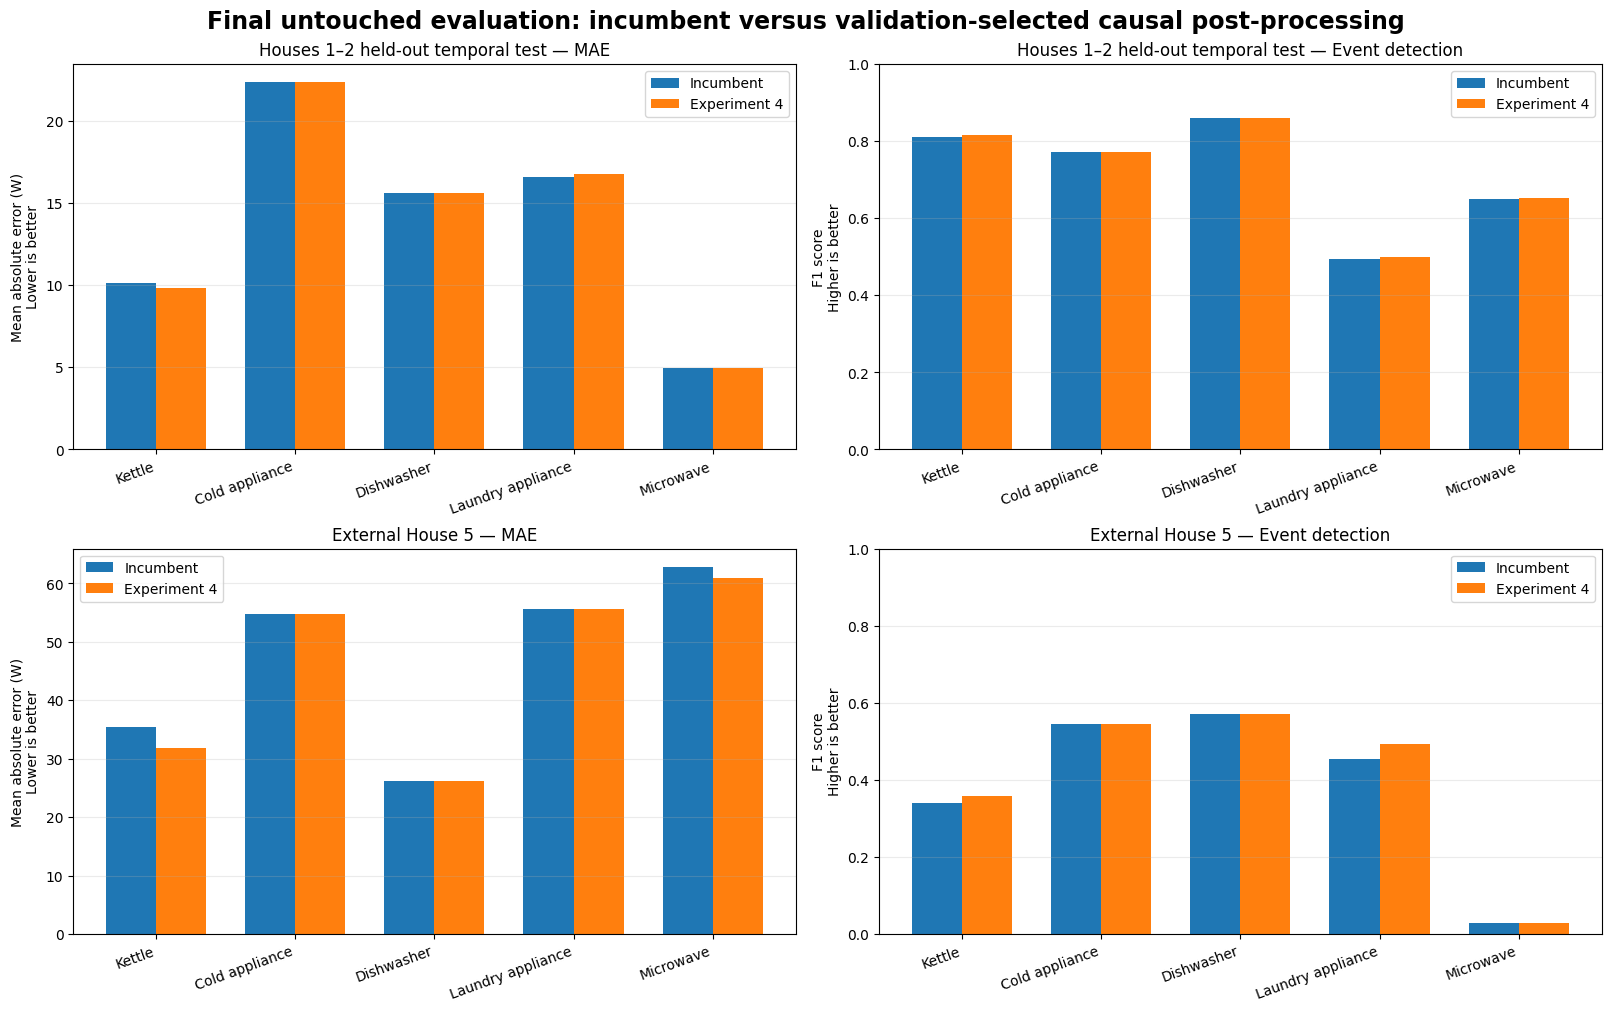

In [138]:
experiment_4_macro = (
    macro_df[macro_df["variant"] == "Experiment 4"]
    .drop(columns=["variant", "houses"])
    .rename(columns={
        "mae_w": "experiment_4_mae_w",
        "rmse_w": "experiment_4_rmse_w",
        "sae_pct": "experiment_4_sae_pct",
        "nde": "experiment_4_nde",
        "precision": "experiment_4_precision",
        "recall": "experiment_4_recall",
        "f1_score": "experiment_4_f1_score",
    })
)

delta_df = incumbent_macro.merge(
    experiment_4_macro,
    on=["evaluation_stage", "category"],
    how="inner",
)

delta_df["mae_change_w"] = (
    delta_df["experiment_4_mae_w"]
    - delta_df["incumbent_mae_w"]
)

delta_df["mae_change_pct"] = (
    100.0
    * delta_df["mae_change_w"]
    / delta_df["incumbent_mae_w"].clip(lower=1e-12)
)

delta_df["sae_change_pct_points"] = (
    delta_df["experiment_4_sae_pct"]
    - delta_df["incumbent_sae_pct"]
)

delta_df["f1_change"] = (
    delta_df["experiment_4_f1_score"]
    - delta_df["incumbent_f1_score"]
)

delta_df["mae_improved"] = delta_df["mae_change_w"] < 0
delta_df["sae_improved"] = (
    delta_df["sae_change_pct_points"] < 0
)
delta_df["f1_improved"] = delta_df["f1_change"] > 0

# ---------------------------------------------------------------------------
# 16. Overall summaries
# ---------------------------------------------------------------------------

overall_df = (
    macro_df
    .groupby(["evaluation_stage", "variant"], as_index=False)
    .agg(
        mean_mae_w=("mae_w", "mean"),
        median_mae_w=("mae_w", "median"),
        mean_sae_pct=("sae_pct", "mean"),
        median_sae_pct=("sae_pct", "median"),
        mean_f1_score=("f1_score", "mean"),
        median_f1_score=("f1_score", "median"),
    )
)

# ---------------------------------------------------------------------------
# 17. Save tables
# ---------------------------------------------------------------------------

MACRO_PATH = OUTPUT_ROOT / "final_untouched_macro.csv"
DELTA_PATH = OUTPUT_ROOT / "final_untouched_deltas.csv"
OVERALL_PATH = OUTPUT_ROOT / "final_untouched_overall.csv"

detail_df.to_csv(DETAIL_PATH, index=False)
macro_df.to_csv(MACRO_PATH, index=False)
delta_df.to_csv(DELTA_PATH, index=False)
overall_df.to_csv(OVERALL_PATH, index=False)

# ---------------------------------------------------------------------------
# 18. Save final incumbent-versus-post-processing comparison figure
# ---------------------------------------------------------------------------

plot_categories = CATEGORIES
x = np.arange(len(plot_categories))
bar_width = 0.36

# Confirm that both final evaluation stages exist
expected_stages = {
    "source_temporal_test",
    "external_test",
}

available_stages = set(
    macro_df["evaluation_stage"].dropna().unique()
)

assert expected_stages.issubset(available_stages), (
    f"Missing evaluation stage(s). "
    f"Available stages: {sorted(available_stages)}"
)

stage_labels = {
    "source_temporal_test":
        "Houses 1–2 held-out temporal test",

    "external_test":
        "External House 5",
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10),
    constrained_layout=True,
)

for row_index, stage in enumerate([
    "source_temporal_test",
    "external_test",
]):

    stage_data = macro_df[
        macro_df["evaluation_stage"].eq(stage)
    ].copy()

    incumbent_data = (
        stage_data[
            stage_data["variant"].eq("Incumbent")
        ]
        .set_index("category")
        .reindex(plot_categories)
    )

    experiment4_data = (
        stage_data[
            stage_data["variant"].eq("Experiment 4")
        ]
        .set_index("category")
        .reindex(plot_categories)
    )

    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    axes[row_index, 0].bar(
        x - bar_width / 2,
        incumbent_data["mae_w"],
        width=bar_width,
        label="Incumbent",
    )

    axes[row_index, 0].bar(
        x + bar_width / 2,
        experiment4_data["mae_w"],
        width=bar_width,
        label="Experiment 4",
    )

    axes[row_index, 0].set_title(
        f"{stage_labels[stage]} — MAE"
    )

    axes[row_index, 0].set_ylabel(
        "Mean absolute error (W)\nLower is better"
    )

    # --------------------------------------------------------
    # F1
    # --------------------------------------------------------

    axes[row_index, 1].bar(
        x - bar_width / 2,
        incumbent_data["f1_score"],
        width=bar_width,
        label="Incumbent",
    )

    axes[row_index, 1].bar(
        x + bar_width / 2,
        experiment4_data["f1_score"],
        width=bar_width,
        label="Experiment 4",
    )

    axes[row_index, 1].set_title(
        f"{stage_labels[stage]} — Event detection"
    )

    axes[row_index, 1].set_ylabel(
        "F1 score\nHigher is better"
    )

    axes[row_index, 1].set_ylim(0.0, 1.0)

    # --------------------------------------------------------
    # Shared formatting
    # --------------------------------------------------------

    for axis in axes[row_index]:
        axis.set_xticks(x)

        axis.set_xticklabels(
            [DISPLAY_NAMES[c] for c in plot_categories],
            rotation=20,
            ha="right",
        )

        axis.grid(
            axis="y",
            alpha=0.25,
        )

        axis.legend()

fig.suptitle(
    "Final untouched evaluation: incumbent versus "
    "validation-selected causal post-processing",
    fontsize=17,
    fontweight="bold",
)

FIGURE_PATH = (
    OUTPUT_ROOT
    / "final_untouched_incumbent_vs_experiment4.png"
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------------------------
# 19. Save immutable evaluation protocol
# ---------------------------------------------------------------------------

protocol = {
    "evaluation_name": "final_untouched_incumbent_vs_experiment_4",
    "evaluation_time_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "experiment_root": str(EXPERIMENT_ROOT),
    "incumbent_package": str(PACKAGE_ROOT),
    "incumbent_policy_source": str(incumbent_policy_path),
    "experiment_4_root": str(EXPERIMENT_4_ROOT),
    "experiment_4_policy_source": str(
        experiment_4_policy_path
    ),
    "development_houses": [1, 2],
    "source_temporal_test_houses": [1, 2],
    "external_evaluation_house": 5,
    "categories": CATEGORIES,
    "feature_count": len(FEATURE_COLUMNS),
    "test_data_used_for_selection": False,
    "training_performed": False,
    "tuning_performed": False,
    "model_reselection_performed": False,
    "existing_reproducible_package_modified": False,
    "detail_results": str(DETAIL_PATH),
    "macro_results": str(MACRO_PATH),
    "delta_results": str(DELTA_PATH),
    "overall_results": str(OVERALL_PATH),
    "figure": str(FIGURE_PATH),
    "experiment_4_policy": (
        experiment_4_policy_df
        .replace({np.nan: None})
        .to_dict(orient="records")
    ),
}

protocol_text = json.dumps(
    protocol,
    indent=2,
    sort_keys=True,
)

protocol["protocol_sha256"] = hashlib.sha256(
    protocol_text.encode("utf-8")
).hexdigest()

PROTOCOL_PATH = (
    OUTPUT_ROOT
    / "final_untouched_evaluation_protocol.json"
)

with open(PROTOCOL_PATH, "w", encoding="utf-8") as file:
    json.dump(protocol, file, indent=2, sort_keys=True)

In [134]:
# ============================================================
# FINAL V2 RESULTS — CLEAN REPORTING SUMMARY
# Read-only display of the completed untouched evaluation
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Headline averages across the five appliance categories
# ------------------------------------------------------------

headline_results = (
    macro_df
    .groupby(["evaluation_stage", "variant"], as_index=False)[
        ["mae_w", "sae_pct", "f1_score"]
    ]
    .mean()
)

headline_results["evaluation_stage"] = headline_results[
    "evaluation_stage"
].replace({
    "source_temporal_test": "Houses 1–2 held-out temporal test",
    "external_test": "External House 5"
})

headline_results = headline_results.rename(columns={
    "evaluation_stage": "Evaluation stage",
    "variant": "Policy",
    "mae_w": "Mean MAE (W)",
    "sae_pct": "Mean SAE (%)",
    "f1_score": "Mean F1"
})

print("=" * 75)
print("FINAL UNTOUCHED EVALUATION — HEADLINE RESULTS")
print("=" * 75)

display(
    headline_results.style.format({
        "Mean MAE (W)": "{:.4f}",
        "Mean SAE (%)": "{:.4f}",
        "Mean F1": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 2. Final V2 policy only — appliance-level results
# ------------------------------------------------------------

final_v2_results = (
    macro_df[
        macro_df["variant"].eq("Experiment 4")
    ][
        [
            "evaluation_stage",
            "category",
            "mae_w",
            "sae_pct",
            "precision",
            "recall",
            "f1_score"
        ]
    ]
    .copy()
)

final_v2_results["evaluation_stage"] = final_v2_results[
    "evaluation_stage"
].replace({
    "source_temporal_test": "Houses 1–2 temporal test",
    "external_test": "External House 5"
})

final_v2_results["category"] = final_v2_results["category"].replace({
    "kettle": "Kettle",
    "cold_appliance": "Cold appliance",
    "dishwasher": "Dishwasher",
    "laundry_appliance": "Laundry appliance",
    "microwave": "Microwave"
})

final_v2_results = final_v2_results.rename(columns={
    "evaluation_stage": "Evaluation stage",
    "category": "Appliance category",
    "mae_w": "MAE (W)",
    "sae_pct": "SAE (%)",
    "precision": "Precision",
    "recall": "Recall",
    "f1_score": "F1"
})

print("\n" + "=" * 75)
print("FINAL V2 — APPLIANCE-LEVEL PERFORMANCE")
print("=" * 75)

display(
    final_v2_results.style.format({
        "MAE (W)": "{:.2f}",
        "SAE (%)": "{:.2f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}"
    })
)


# ------------------------------------------------------------
# 3. Reproduction check against the frozen reference results
# ------------------------------------------------------------

check_df = (
    macro_df[
        macro_df["variant"].eq("Experiment 4")
    ]
    .groupby("evaluation_stage")[
        ["mae_w", "sae_pct", "f1_score"]
    ]
    .mean()
)

assert np.isclose(
    check_df.loc["source_temporal_test", "mae_w"],
    13.8960,
    atol=0.0001
)

assert np.isclose(
    check_df.loc["source_temporal_test", "sae_pct"],
    24.0936,
    atol=0.0001
)

assert np.isclose(
    check_df.loc["source_temporal_test", "f1_score"],
    0.7191,
    atol=0.0001
)

assert np.isclose(
    check_df.loc["external_test", "mae_w"],
    45.8818,
    atol=0.0001
)

assert np.isclose(
    check_df.loc["external_test", "sae_pct"],
    79.8156,
    atol=0.0001
)

assert np.isclose(
    check_df.loc["external_test", "f1_score"],
    0.3995,
    atol=0.0001
)
# ------------------------------------------------------------
# Reproduction check against the frozen reference results
# ------------------------------------------------------------

check_df = (
    macro_df[macro_df["variant"].eq("Experiment 4")]
    .groupby("evaluation_stage")[["mae_w", "sae_pct", "f1_score"]]
    .mean()
)

# Frozen reference values from the completed final experiment
expected = {
    "source_temporal_test": {
        "mae_w": 13.8960,
        "sae_pct": 24.0936,
        "f1_score": 0.7191
    },
    "external_test": {
        "mae_w": 45.8818,
        "sae_pct": 79.8156,
        "f1_score": 0.3995
    }
}

for stage, values in expected.items():
    for metric, reference_value in values.items():
        actual_value = check_df.loc[stage, metric]
        assert np.isclose(
            actual_value,
            reference_value,
            atol=0.0001
        ), (
            f"FAILED: {stage} {metric}: "
            f"actual={actual_value:.4f}, "
            f"expected={reference_value:.4f}"
        )

print("FINAL V2 REFERENCE RESULT CHECK: PASS")

for stage in ["source_temporal_test", "external_test"]:
    row = check_df.loc[stage]
    label = (
        "Source temporal test"
        if stage == "source_temporal_test"
        else "External House 5"
    )

    print(
        f"{label:<22}: "
        f"{row['mae_w']:.4f} W | "
        f"{row['sae_pct']:.4f}% | "
        f"F1 {row['f1_score']:.4f}"
    )

FINAL UNTOUCHED EVALUATION — HEADLINE RESULTS


,Evaluation stage,Policy,Mean MAE (W),Mean SAE (%),Mean F1
0,External House 5,Experiment 4,45.8818,79.8156,0.3995
1,External House 5,Incumbent,46.9819,90.3964,0.3883
2,Houses 1–2 held-out temporal test,Experiment 4,13.8960,24.0936,0.7191
3,Houses 1–2 held-out temporal test,Incumbent,13.9186,25.9329,0.7170



FINAL V2 — APPLIANCE-LEVEL PERFORMANCE


,Evaluation stage,Appliance category,MAE (W),SAE (%),Precision,Recall,F1
5,Houses 1–2 temporal test,Kettle,9.85,28.92,0.771,0.879,0.815
6,Houses 1–2 temporal test,Cold appliance,22.34,8.33,0.768,0.776,0.771
7,Houses 1–2 temporal test,Dishwasher,15.58,23.75,0.824,0.925,0.860
8,Houses 1–2 temporal test,Laundry appliance,16.76,26.91,0.475,0.602,0.498
9,Houses 1–2 temporal test,Microwave,4.95,32.55,0.556,0.861,0.652
15,External House 5,Kettle,31.86,176.60,0.233,0.781,0.358
16,External House 5,Cold appliance,54.72,65.87,0.390,0.902,0.545
17,External House 5,Dishwasher,26.26,85.45,0.477,0.712,0.571
18,External House 5,Laundry appliance,55.69,10.51,0.416,0.606,0.494
19,External House 5,Microwave,60.88,60.65,0.015,0.467,0.030


FINAL V2 REFERENCE RESULT CHECK: PASS
Source temporal test  : 13.8960 W | 24.0936% | F1 0.7191
External House 5      : 45.8818 W | 79.8156% | F1 0.3995


In [135]:
# ============================================================
# FREEZE EXPERIMENT 4 AS THE FINAL EVALUATED MODEL PACKAGE V2
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
import shutil
import hashlib
from datetime import datetime, timezone

# ------------------------------------------------------------
# 1. Locate the completed experiment
# ------------------------------------------------------------

drive_root = Path("/content/drive")

package_candidates = [
    path for path in drive_root.rglob("final_reproducible_model_v1")
    if path.is_dir()
]

valid_locations = []

for package_path in package_candidates:
    experiment_root = package_path.parent.parent
    experiment_4_root = (
        experiment_root /
        "improvement_experiment_4_causal_postprocessing"
    )

    if experiment_4_root.exists():
        valid_locations.append(
            (package_path, experiment_root, experiment_4_root)
        )

assert valid_locations, (
    "Could not locate the completed model package and Experiment 4."
)

# Prefer the most recently modified valid package.
package_v1, experiment_root, experiment_4_root = max(
    valid_locations,
    key=lambda item: item[0].stat().st_mtime
)
# ------------------------------------------------------------
# 2. Recover the frozen Experiment 4 validation policy
# ------------------------------------------------------------

required_categories = {
    "kettle",
    "cold_appliance",
    "dishwasher",
    "laundry_appliance",
    "microwave",
}

policy_candidates = []

for path in experiment_4_root.rglob("*.csv"):
    try:
        frame = pd.read_csv(path, nrows=10)
    except Exception:
        continue

    columns = set(frame.columns)

    if {
        "category",
        "candidate_id",
        "processor_mode",
        "power_scale",
    }.issubset(columns):
        categories = set(frame["category"].dropna().astype(str))

        if required_categories.issubset(categories):
            policy_candidates.append(path)

assert policy_candidates, (
    "Could not locate the frozen Experiment 4 policy."
)

experiment_4_policy_path = max(
    policy_candidates,
    key=lambda path: path.stat().st_mtime
)

experiment_4_policy = pd.read_csv(experiment_4_policy_path)
experiment_4_policy = (
    experiment_4_policy[
        experiment_4_policy["category"].isin(required_categories)
    ]
    .drop_duplicates("category", keep="last")
    .sort_values("category")
    .reset_index(drop=True)
)

assert set(experiment_4_policy["category"]) == required_categories
assert len(experiment_4_policy) == 5


# ------------------------------------------------------------
# 3. Recover the untouched final-evaluation results
# ------------------------------------------------------------

evaluation_candidates = []

for path in experiment_4_root.rglob("*.csv"):
    if "final" not in path.name.lower() and "untouched" not in path.name.lower():
        continue

    try:
        frame = pd.read_csv(path)
    except Exception:
        continue

    required_columns = {
        "evaluation_stage",
        "house",
        "category",
        "variant",
        "mae_w",
        "sae_pct",
        "f1_score",
    }

    if required_columns.issubset(frame.columns):
        evaluation_candidates.append((path, frame))

assert evaluation_candidates, (
    "Could not locate the final untouched evaluation detail."
)

evaluation_path, evaluation_detail = max(
    evaluation_candidates,
    key=lambda item: len(item[1])
)

evaluation_detail = evaluation_detail.copy()

assert set(evaluation_detail["variant"]) >= {
    "Incumbent",
    "Experiment 4",
}

assert set(evaluation_detail["category"]) == required_categories
assert len(evaluation_detail) >= 30

overall_summary = (
    evaluation_detail
    .groupby(
        ["evaluation_stage", "variant"],
        as_index=False
    )[["mae_w", "sae_pct", "f1_score"]]
    .mean()
    .sort_values(["evaluation_stage", "variant"])
    .reset_index(drop=True)
)
# ------------------------------------------------------------
# 4. Create the final Version 2 model package
# ------------------------------------------------------------

package_v2 = (
    experiment_root /
    "evaluation" /
    "final_reproducible_model_v2"
)

package_v2.mkdir(parents=True, exist_ok=True)

# Copy the complete restart-safe Version 1 package.
shutil.copytree(
    package_v1,
    package_v2,
    dirs_exist_ok=True,
)

config_directory = package_v2 / "config"
evaluation_directory = package_v2 / "final_evaluation"

config_directory.mkdir(parents=True, exist_ok=True)
evaluation_directory.mkdir(parents=True, exist_ok=True)

final_policy_path = (
    config_directory /
    "final_causal_postprocessing_policy.csv"
)

final_results_path = (
    evaluation_directory /
    "final_untouched_house_level_results.csv"
)

final_summary_path = (
    evaluation_directory /
    "final_untouched_overall_summary.csv"
)

experiment_4_policy.to_csv(final_policy_path, index=False)
evaluation_detail.to_csv(final_results_path, index=False)
overall_summary.to_csv(final_summary_path, index=False)

# Copy every saved final figure and table from the untouched evaluation.
for source in experiment_4_root.rglob("*"):
    if not source.is_file():
        continue

    lower_name = source.name.lower()

    if (
        "final_untouched" in lower_name
        or "incumbent_vs_experiment4" in lower_name
    ):
        destination = evaluation_directory / source.name

        if source.resolve() != destination.resolve():
            shutil.copy2(source, destination)

# ------------------------------------------------------------
# 5. Create a reproducibility manifest
# ------------------------------------------------------------

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()

    with open(path, "rb") as file_handle:
        while True:
            block = file_handle.read(chunk_size)

            if not block:
                break

            digest.update(block)

    return digest.hexdigest()


artifact_rows = []

for artifact_path in sorted(package_v2.rglob("*")):
    if not artifact_path.is_file():
        continue

    if artifact_path.name == "final_model_v2_manifest.json":
        continue

    artifact_rows.append(
        {
            "relative_path": str(
                artifact_path.relative_to(package_v2)
            ),
            "size_bytes": int(artifact_path.stat().st_size),
            "sha256": sha256_file(artifact_path),
        }
    )

artifact_manifest = pd.DataFrame(artifact_rows)

artifact_manifest_path = (
    package_v2 /
    "final_model_v2_artifact_manifest.csv"
)

artifact_manifest.to_csv(
    artifact_manifest_path,
    index=False,
)

manifest = {
    "model_version": "final_reproducible_model_v2",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "base_model_package": str(package_v1),
    "experiment_4_directory": str(experiment_4_root),
    "experiment_4_validation_policy_source": str(
        experiment_4_policy_path
    ),
    "untouched_evaluation_source": str(evaluation_path),
    "development_houses": [1, 2],
    "unseen_external_test_house": 5,
    "categories": sorted(required_categories),
    "model_input": (
        "24 causal features derived solely from aggregate mains"
    ),
    "selection_rule": (
        "Models and post-processing were selected using source "
        "validation data only."
    ),
    "test_use": (
        "Held-out temporal tests and unseen House 5 were used "
        "once for final reporting only."
    ),
    "experiment_3_status": (
        "Rejected because exact transient-feature formula "
        "reproduction was incomplete."
    ),
    "experiment_4_status": (
        "Frozen validation-selected causal post-processing, "
        "evaluated once on untouched test data."
    ),
    "remaining_limitation": (
        "Cross-house microwave event detection remains weak."
    ),
    "postprocessing_policy": experiment_4_policy.to_dict(
        orient="records"
    ),
    "final_evaluation_summary": overall_summary.to_dict(
        orient="records"
    ),
}
manifest_path = package_v2 / "final_model_v2_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as file_handle:
    json.dump(manifest, file_handle, indent=2)

In [136]:
# ------------------------------------------------------------
# 6. Final integrity checks
# ------------------------------------------------------------

assert final_policy_path.exists()
assert final_results_path.exists()
assert final_summary_path.exists()
assert artifact_manifest_path.exists()
assert manifest_path.exists()

joblib_files = list(package_v2.rglob("*.joblib"))

assert len(joblib_files) >= 8, (
    f"Expected at least 8 model artifacts; found "
    f"{len(joblib_files)}."
)

In [139]:
# ============================================================
# FINAL REPRODUCTION COMPLETION CHECK
# ============================================================

import numpy as np
import pandas as pd

final_summary_path = (
    package_v2
    / "final_evaluation"
    / "final_untouched_overall.csv"
)

assert final_summary_path.exists(), final_summary_path
assert final_policy_path.exists(), final_policy_path
assert final_results_path.exists(), final_results_path
assert artifact_manifest_path.exists(), artifact_manifest_path
assert manifest_path.exists(), manifest_path

joblib_files = list(package_v2.rglob("*.joblib"))

assert len(joblib_files) >= 8, (
    f"Expected at least 8 model artifacts; "
    f"found {len(joblib_files)}."
)

final_summary_df = pd.read_csv(final_summary_path)

final_v2_summary_df = (
    final_summary_df[
        final_summary_df["variant"].eq("Experiment 4")
    ][
        [
            "evaluation_stage",
            "mean_mae_w",
            "mean_sae_pct",
            "mean_f1_score",
        ]
    ]
    .reset_index(drop=True)
)

required_stages = {
    "source_temporal_test",
    "external_test",
}

assert set(
    final_v2_summary_df["evaluation_stage"]
) == required_stages

metric_columns = [
    "mean_mae_w",
    "mean_sae_pct",
    "mean_f1_score",
]

assert np.isfinite(
    final_v2_summary_df[metric_columns].to_numpy()
).all()

print("FINAL UNTOUCHED EVALUATION: PASS")
print("FINAL REPRODUCIBLE MODEL V2 FREEZE: PASS")
print("FULL REPRODUCTION PIPELINE: PASS")

display(final_v2_summary_df.round(4))

FINAL UNTOUCHED EVALUATION: PASS
FINAL REPRODUCIBLE MODEL V2 FREEZE: PASS
FULL REPRODUCTION PIPELINE: PASS


,evaluation_stage,mean_mae_w,mean_sae_pct,mean_f1_score
0,external_test,45.8818,79.8156,0.3995
1,source_temporal_test,13.8960,24.0936,0.7191


## Completion criteria

A successful run must finish with both:

- `FINAL UNTOUCHED EVALUATION: PASS`
- `FINAL REPRODUCIBLE MODEL V2 FREEZE: PASS`

Run `02_final_results_and_report_figures.ipynb` afterward to generate the
dissertation figures, and use `03_v2_inference_demo.ipynb` for the
restart-safe prototype demonstration.

The reproduction output is separate from the original development
package. Compare the resulting policy identities and headline metrics;
do not overwrite or silently replace the reference results.